# Recurring Operations: Group Comparison Analysis

Methods covered:
  1. Kaplan-Meier + log-rank (time to first re-operation)
  2. Cox Proportional Hazards (time to first re-operation)
  3. Andersen-Gill model (all re-operations, independent increments)
  4. Prentice-Williams-Peterson (PWP) model (ordered recurring events)
  5. Negative Binomial regression (total count of re-operations)
  6. Mean Cumulative Function (MCF) plot

# Customization

In [1]:
# ---- 0. Install / load packages ----
pkgs <- c(
    "survival", "survminer", "MASS", "dplyr", "ggplot2", "tibble",
    "readxl", "lubridate", "ggbeeswarm"
)
new_pkgs <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(new_pkgs)) install.packages(new_pkgs)
invisible(lapply(pkgs, library, character.only = TRUE))

set.seed(42)


Loading required package: ggplot2



Loading required package: ggpubr




Attaching package: 'survminer'




The following object is masked from 'package:survival':

    myeloma





Attaching package: 'dplyr'




The following object is masked from 'package:MASS':

    select




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





Attaching package: 'lubridate'




The following objects are masked from 'package:base':

    date, intersect, setdiff, union




In [2]:
# ---- Plot dimensions (width x height in inches) ----
options(repr.plot.width = 12, repr.plot.height = 9)
options(warn = -1)


# LOAD DATA
Read from `lor.xlsx`, sheet **"данные"**.

Columns used:
- `группа`
- `id` — идентификатор пациента
- `возраст`
- `пол`
- `длительность заболевания`
- `удаление полипов в анамнезе` — количество предыдущих удалений полипов
- `аллергия.домашняя пыль` — аллергия на домашнюю пыль (да/нет)
- `аллергия.пылевые клещи` — аллергия на пылевых клещей (да/нет)
- `аллергия.растения` — аллергия на растения (да/нет)
- `аллергия.животные` — аллергия на животных (да/нет)
- `хронический ринит` — наличие хронического ринита (да/нет)
- `АР` — наличие аллергического ринита (да/нет)
- `БА` — наличие бронхиальной астмы (да/нет)
- `искривление носовой перегородки` — наличие искривления носовой перегородки (да/нет)
- `дата операции` — дата индексной операции
- `оперированные пазухи` — количество оперированных пазух
- `операция 1` / `дата операции 1` — 1-я повторная операция (да/нет + дата)
- `операция 2` / `дата операции 2` — 2-я повторная операция (да/нет + дата)

Длительность наблюдения измеряется в **днях** с момента индексной операции.  
Пациенты без последующего события цензурированы на последнюю дату, наблюдаемую в наборе данных.  
Для удобства используется константа `six_months_days = 365.25 / 2 ≈ 182.6` для интервалов на оси.


In [3]:
# ---- Read raw data ----
raw <- read_excel(
  "C:\\Analysis\\OTOLARING\\Nidelko\\lor.xlsx",
  sheet = "данные"
)


In [4]:
stop_date <- as.Date("2026-02-01")


In [5]:
# Parameters
product = "time-event.html"


In [6]:
# ---- Helper: days between two dates ----
days_diff <- function(d_start, d_end) {
  as.numeric(difftime(as.Date(d_end), as.Date(d_start), units = "days"))
}

# ---- Select and rename columns ----
data <- raw |>
  transmute(
    id = as.character(`id`),
    group = factor(`группа`),
    age = as.integer(`возраст`),
    sex = `пол`,
    ill_dur = as.integer(`длительность заболевания`),
    polyps = as.integer(`удаление полипов в анамнезе`),
    allergy_dust = factor(`аллергия.домашняя пыль`),
    allergy_plants = factor(`аллергия.растения`),
    allergy_mites = factor(`аллергия.пылевые клещи`),
    allergy_animals = factor(`аллергия.животные`),
    chronic_rhinitis = factor(`хронический ринит`),
    AR = factor(`АР`),
    BA = factor(`БА`),
    nasal_septum_deviation = factor(`искривление носовой перегородки`),
    date_operation = as.Date(`дата операции`),
    sinuses = `оперированные пазухи`,
    followup = days_diff(as.Date(`дата операции`), stop_date),
    reop1 = ifelse(is.na(`дата операции 1`), 0, 1),
    date_reoperation1 = as.Date(`дата операции 1`),
    reop2 = ifelse(is.na(`дата операции 2`), 0, 1),
    date_reoperation2 = as.Date(`дата операции 2`)
  )

# 6 months in days (used for axis breaks)
six_months_days <- 365.25 / 2 # 182.625

# ---- Study end = latest date observed across all patients ----
study_end <- max(c(data$date_reoperation2, data$date_reoperation1, data$date_operation), na.rm = TRUE)
cat(sprintf("Study end date (latest observed): %s\n\n", as.character(study_end)))

# ---- Patient-level summary (one row per patient) ----
patient_df <- data |>
  dplyr::mutate(
    n_reops  = reop1 + reop2,
    followup = days_diff(date_operation, study_end)
  )

cat(sprintf("Patients loaded: %d\n", nrow(patient_df)))
cat(sprintf("Groups: %s\n\n", paste(levels(patient_df$group), collapse = ", ")))

print(patient_df)


Study end date (latest observed): 2026-01-21



Patients loaded: 50


Groups: КГ, ОГ1, ОГ2



# A tibble: 50 × 22
   id    group   age sex   ill_dur polyps allergy_dust allergy_plants
   <chr> <fct> <int> <chr>   <int>  <int> <fct>        <fct>         
 1 1     ОГ1      48 муж.       10      3 нет          нет           
 2 2     ОГ1      32 муж.       20      1 нет          да            
 3 4     ОГ1      50 муж.       15      3 нет          нет           
 4 5     ОГ1      28 муж.        8      7 да           да            
 5 6     ОГ1      37 муж.        8      3 нет          нет           
 6 7     ОГ1      23 жен.        8      2 нет          да            
 7 9     ОГ1      58 муж.       10      3 нет          да            
 8 10    ОГ1      63 муж.       15      4 нет          нет           
 9 11    ОГ1      43 муж.       25      3 нет          нет           
10 12    ОГ1      55 муж.       15      2 нет          нет           
# ℹ 40 more rows
# ℹ 14 more variables: allergy_mites <fct>, allergy_animals <fct>,
#   chronic_rhinitis <fct>, AR <fct>, BA <fct>, nasal_se

In [7]:
# ---- Patient-level summary table ----
cat("=== Patient summary ===\n")
patient_df |>
  group_by(group) |>
  summarise(
    n            = n(),
    median_fup   = round(median(followup), 1),
    mean_reops   = round(mean(n_reops), 2),
    pct_any_reop = round(mean(n_reops > 0) * 100, 1)
  ) |>
  print()


=== Patient summary ===


# A tibble: 3 × 5
  group     n median_fup mean_reops pct_any_reop
  <fct> <int>      <dbl>      <dbl>        <dbl>
1 КГ       25      1071        0.44         36  
2 ОГ1      12      1368.       0.17         16.7
3 ОГ2      13      1022        0.08          7.7


In [8]:
# ---- Derive palette from actual group levels ----
group_levels <- levels(patient_df$group)
n_groups <- length(group_levels)

# Base set of distinguishable colors; extend if more groups are added
base_colors <- c(
    "#E74C3C", "#2ECC71", "#3498DB", "#9B59B6",
    "#F39C12", "#1ABC9C", "#E67E22", "#2980B9"
)
group_palette <- setNames(base_colors[seq_len(n_groups)], group_levels)

cat(sprintf("Groups (%d): %s\n", n_groups, paste(group_levels, collapse = ", ")))
cat("Palette:\n")
print(group_palette)


Groups (3): КГ, ОГ1, ОГ2


Palette:


       КГ       ОГ1       ОГ2 
"#E74C3C" "#2ECC71" "#3498DB" 


In [9]:
# ---- Combined groups: ОГ1 + ОГ2 → ОГ ----
# patient_df_og is used in all "Part 2" analyses below
patient_df_og <- patient_df |>
  dplyr::mutate(group = factor(
    ifelse(as.character(group) %in% c("ОГ1", "ОГ2"), "ОГ", as.character(group))
  ))

group_levels_og <- levels(patient_df_og$group)
n_groups_og <- length(group_levels_og)
group_palette_og <- setNames(base_colors[seq_len(n_groups_og)], group_levels_og)

cat(sprintf("Combined groups (%d): %s\n", n_groups_og, paste(group_levels_og, collapse = ", ")))
print(group_palette_og)


Combined groups (2): КГ, ОГ


       КГ        ОГ 
"#E74C3C" "#2ECC71" 


# DATA FORMATS

## Follow-up time description

Длительность наблюдения -- это количество дней с момента индексной операции до даты окончания исследования (административное цензурирование).

### Все группы

In [10]:
# ---- Follow-up time: basic statistics ----
fup_stats <- function(x) {
  tibble::tibble(
    n      = length(x),
    mean   = round(mean(x), 1),
    sd     = round(sd(x), 1),
    median = round(median(x), 1),
    q1     = round(quantile(x, 0.25), 1),
    q3     = round(quantile(x, 0.75), 1),
    min    = round(min(x), 1),
    max    = round(max(x), 1)
  )
}

cat("=== Follow-up time (days) — all patients ===\n")
print(fup_stats(patient_df$followup))

cat("\n=== Follow-up time (days) — by group ===\n")
patient_df |>
  group_by(group) |>
  summarise(fup_stats(followup), .groups = "drop") |>
  print()


=== Follow-up time (days) — all patients ===


# A tibble: 1 × 8
      n  mean    sd median    q1    q3   min   max
  <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
1    50 1149.  193.   1087 1020.  1342   826  1518



=== Follow-up time (days) — by group ===


# A tibble: 3 × 9
  group     n  mean    sd median    q1    q3   min   max
  <fct> <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
1 КГ       25 1107. 183.   1071   994  1141    826  1497
2 ОГ1      12 1365. 126.   1368. 1339. 1462.  1091  1518
3 ОГ2      13 1030.  74.8  1022  1007  1041    901  1167


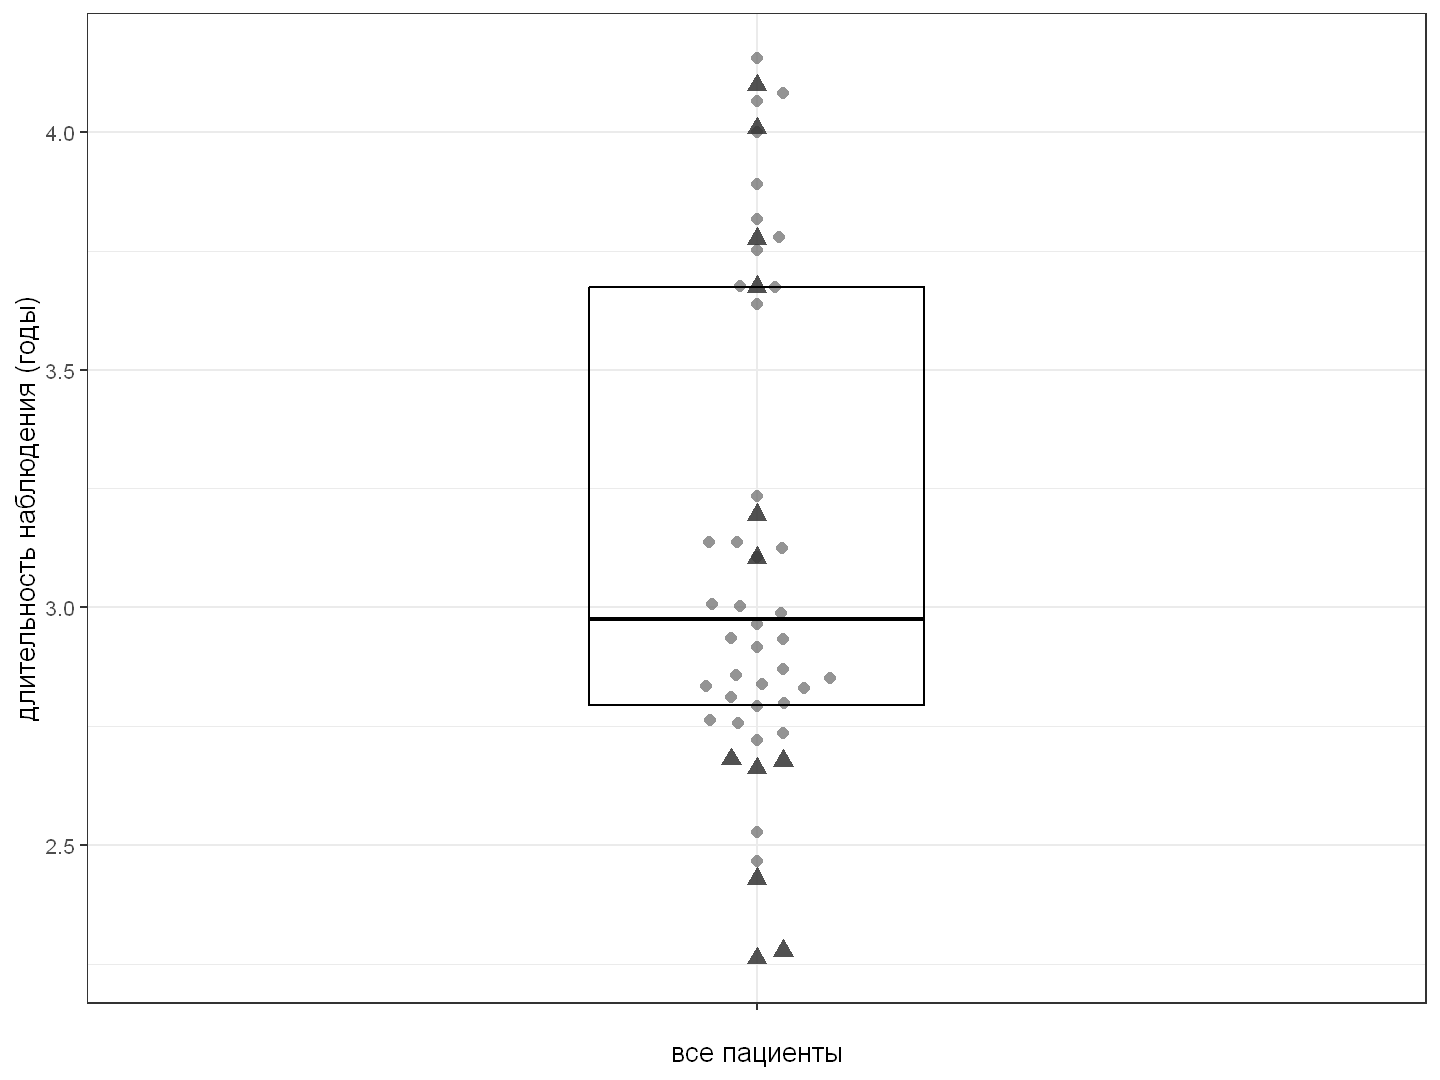

In [11]:
# ---- Follow-up time: beeswarm — all patients ----

fup_all_df <- patient_df |>
  dplyr::mutate(fup_years = followup / 365.25)

y_breaks <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_all <- ggplot(fup_all_df, aes(x = "", y = fup_years)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 3.0, shape = 16, alpha = 0.7, colour = "grey40"
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 4, shape = 17, alpha = 0.85, colour = "grey20"
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "все пациенты",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_all)

# head(fup_all_df, n=50)


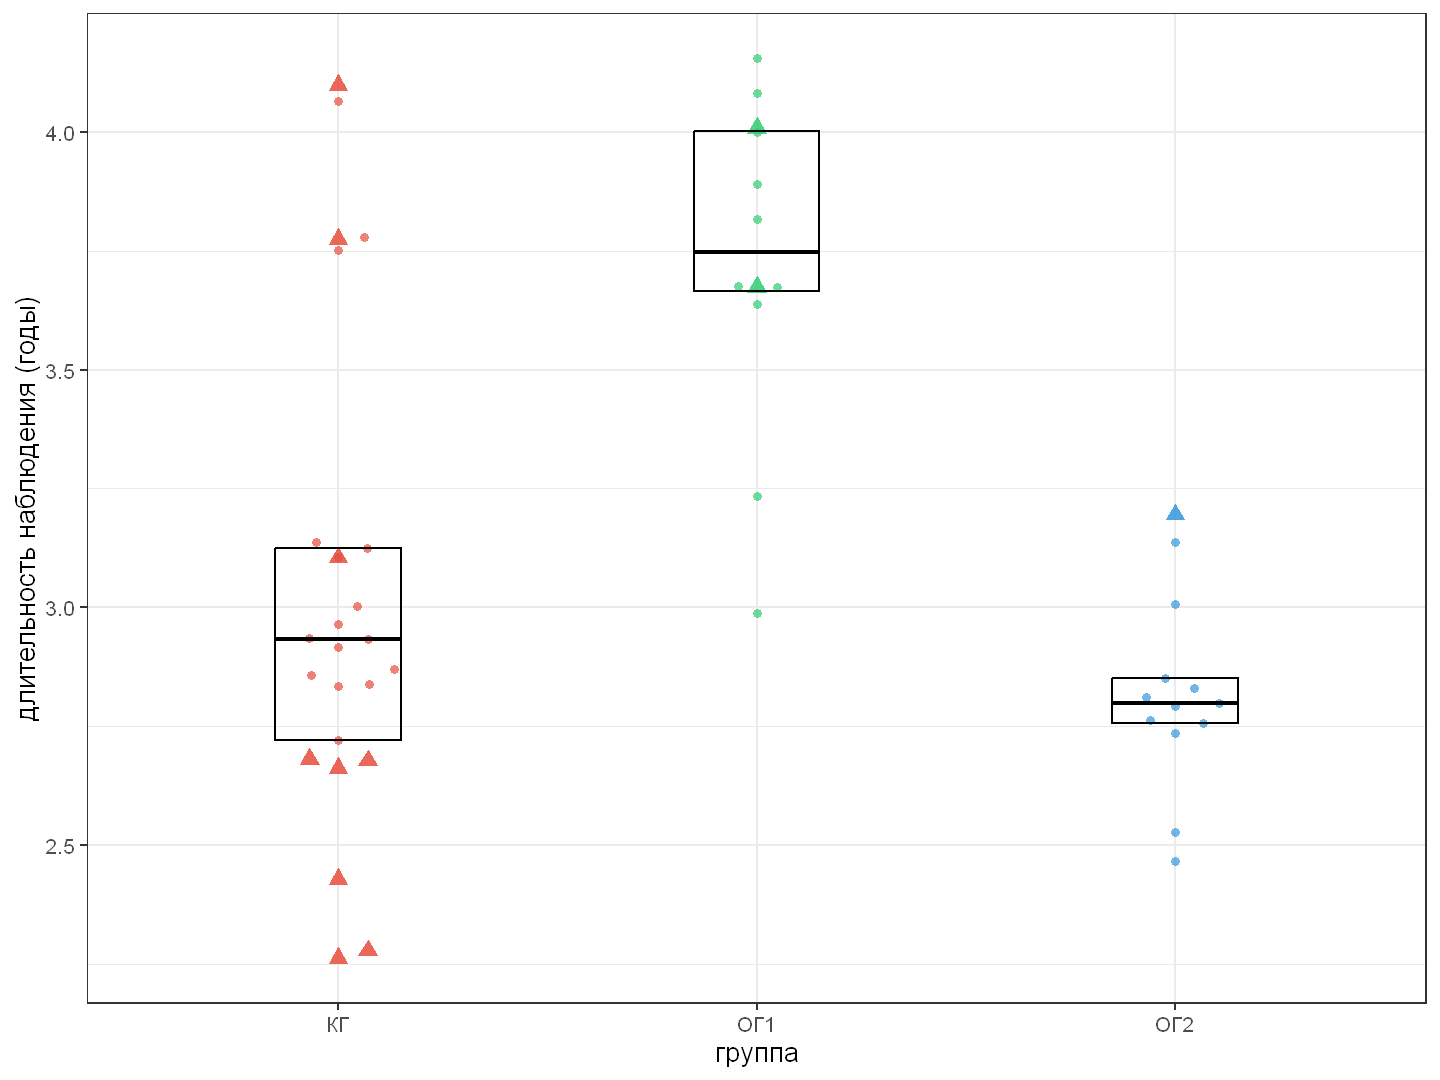

In [12]:
# ---- Follow-up time: beeswarm — by group ----

fup_grp_df <- patient_df |>
  dplyr::mutate(fup_years = followup / 365.25)

fup_beeswarm_grp <- ggplot(fup_grp_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette, guide = "none") +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "группа",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_grp)


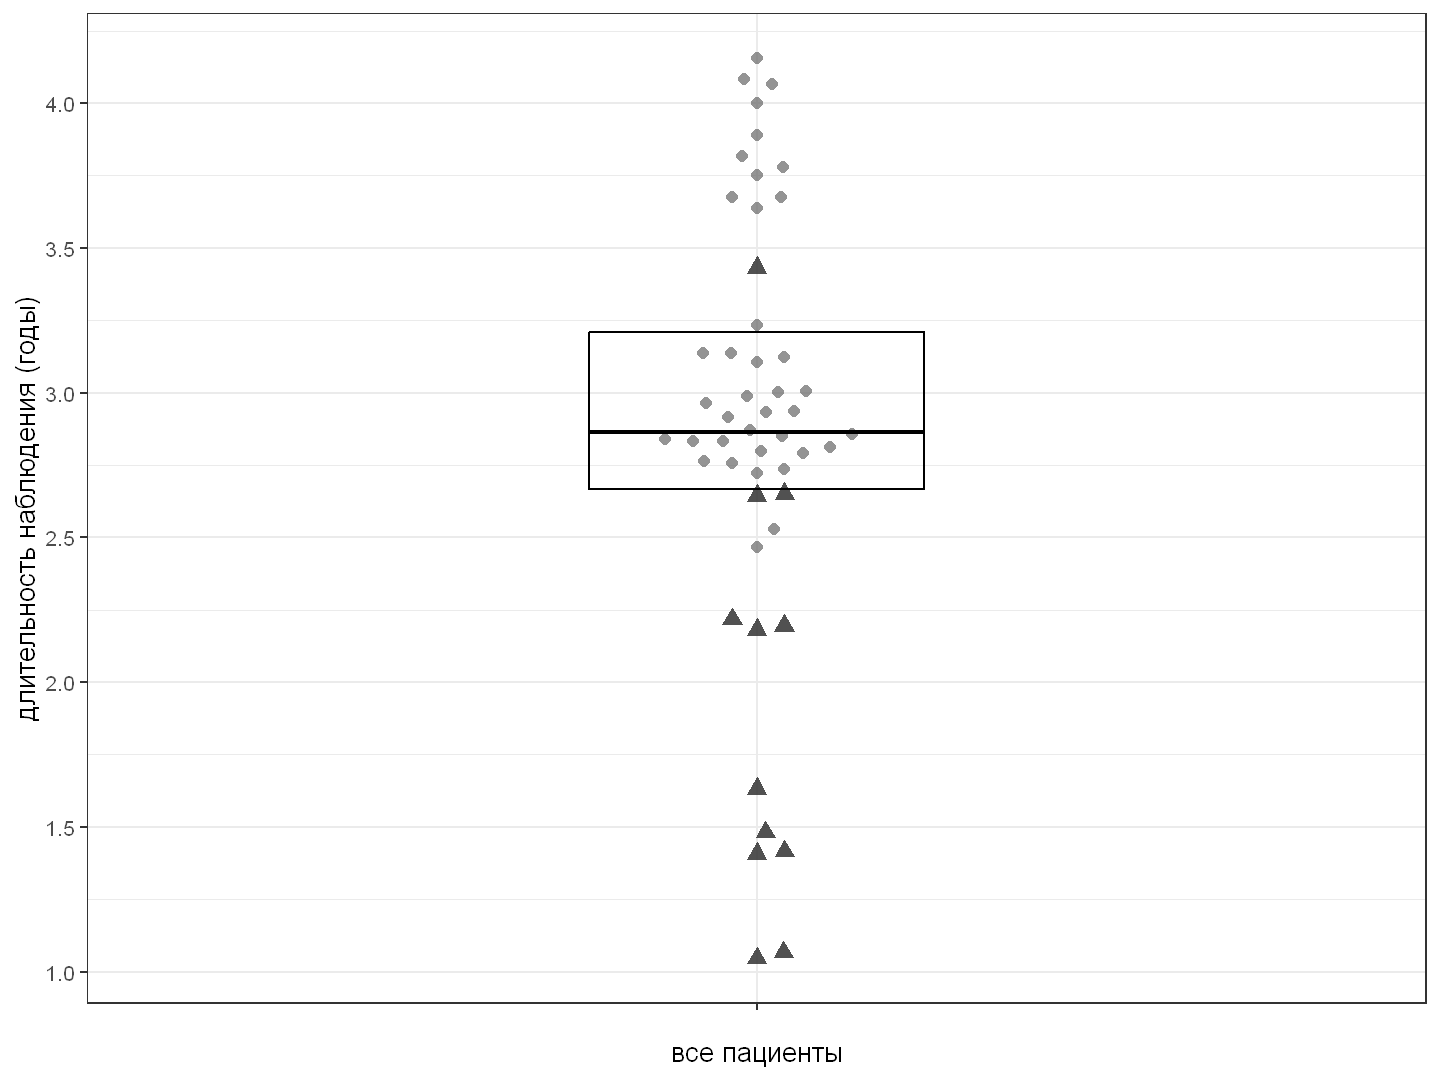

In [13]:
# ---- Reoperation times: beeswarm — all patients ----
# One point per reoperation event; shape distinguishes 1st vs 2nd reoperation.
# Patients who never had a reoperation are NOT plotted (nothing to show).

# ---- Follow-up time: beeswarm — all patients ----

fup_all_df <- patient_df |>
  dplyr::mutate(fup_years = ifelse(reop1 == 1, days_diff(date_operation, date_reoperation1) / 365.25, followup / 365.25))

y_breaks <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_all <- ggplot(fup_all_df, aes(x = "", y = fup_years)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 3.0, shape = 16, alpha = 0.7, colour = "grey40"
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 4, shape = 17, alpha = 0.85, colour = "grey20"
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "все пациенты",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_all)


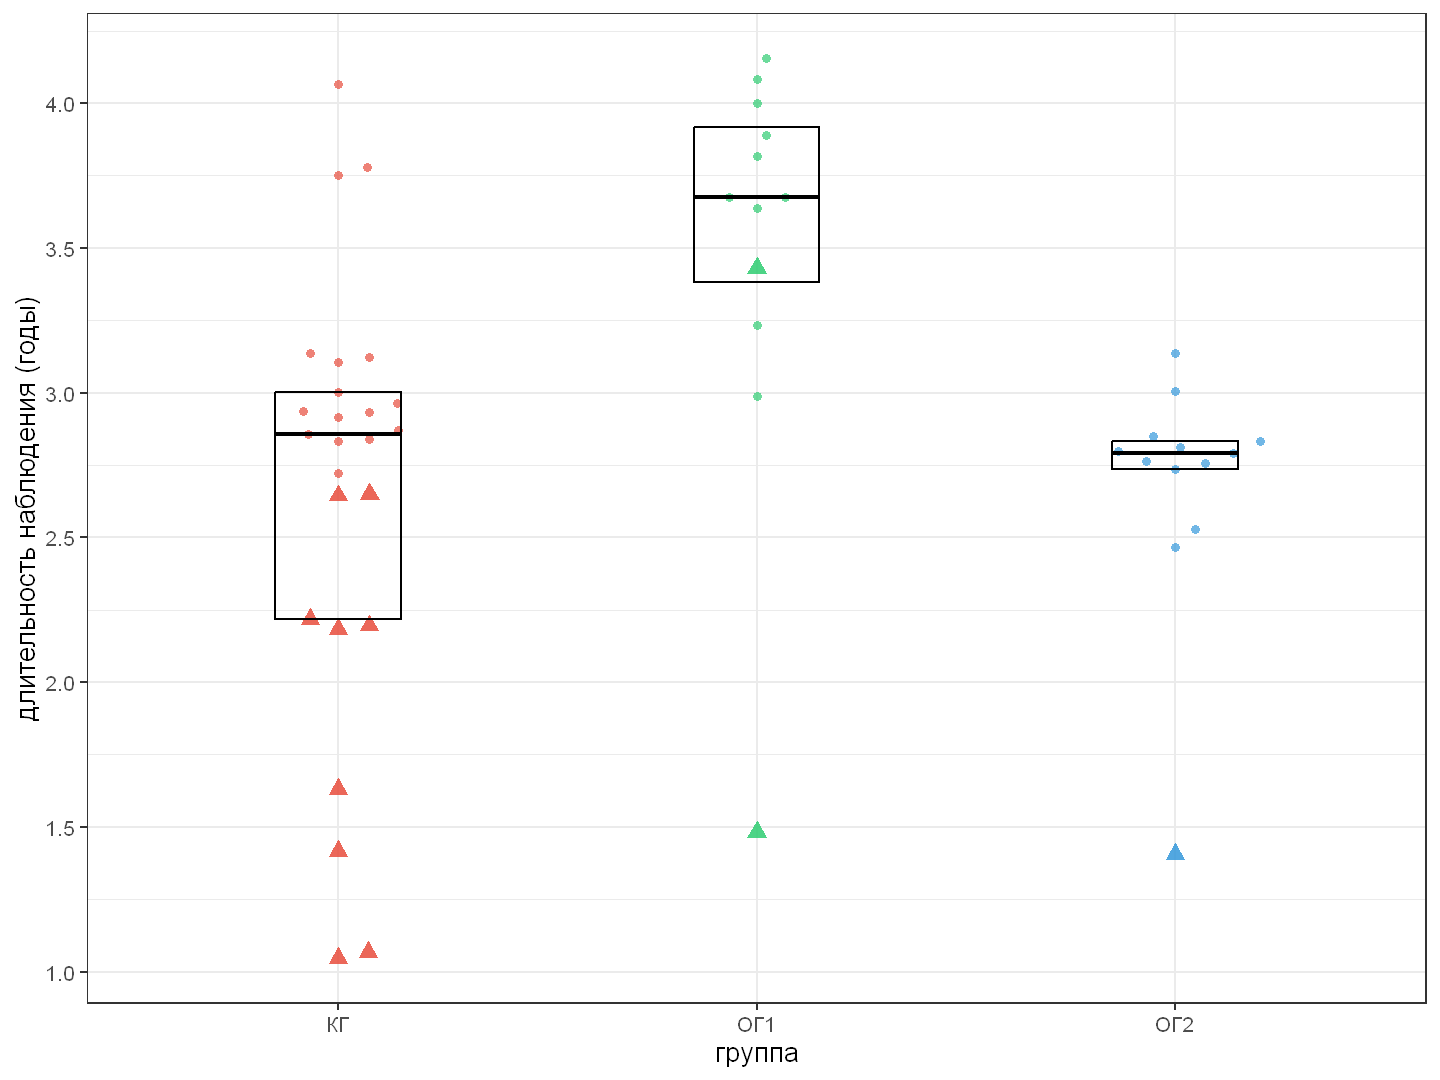

In [14]:
# ---- Reoperation times: beeswarm — by group (all groups) ----
# One point per reoperation event; shape distinguishes 1st vs 2nd reoperation.

fup_all_df <- patient_df |>
  dplyr::mutate(fup_years = ifelse(reop1 == 1, days_diff(date_operation, date_reoperation1) / 365.25, followup / 365.25))


y_breaks_reop <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_grp <- ggplot(fup_all_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette, guide = "none") +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "группа",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_grp)


#### ОГ1+ОГ2 vs КГ — длительность наблюдения

In [15]:
# ---- Follow-up time: basic statistics — ОГ combined ----
cat("=== Follow-up time (days) — ОГ combined vs КГ ===\n")
patient_df_og |>
  group_by(group) |>
  summarise(fup_stats(followup), .groups = "drop") |>
  print()


=== Follow-up time (days) — ОГ combined vs КГ ===


# A tibble: 2 × 9
  group     n  mean    sd median    q1    q3   min   max
  <fct> <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
1 КГ       25 1107.  183.   1071   994  1141   826  1497
2 ОГ       25 1191.  198.   1146  1022  1343   901  1518


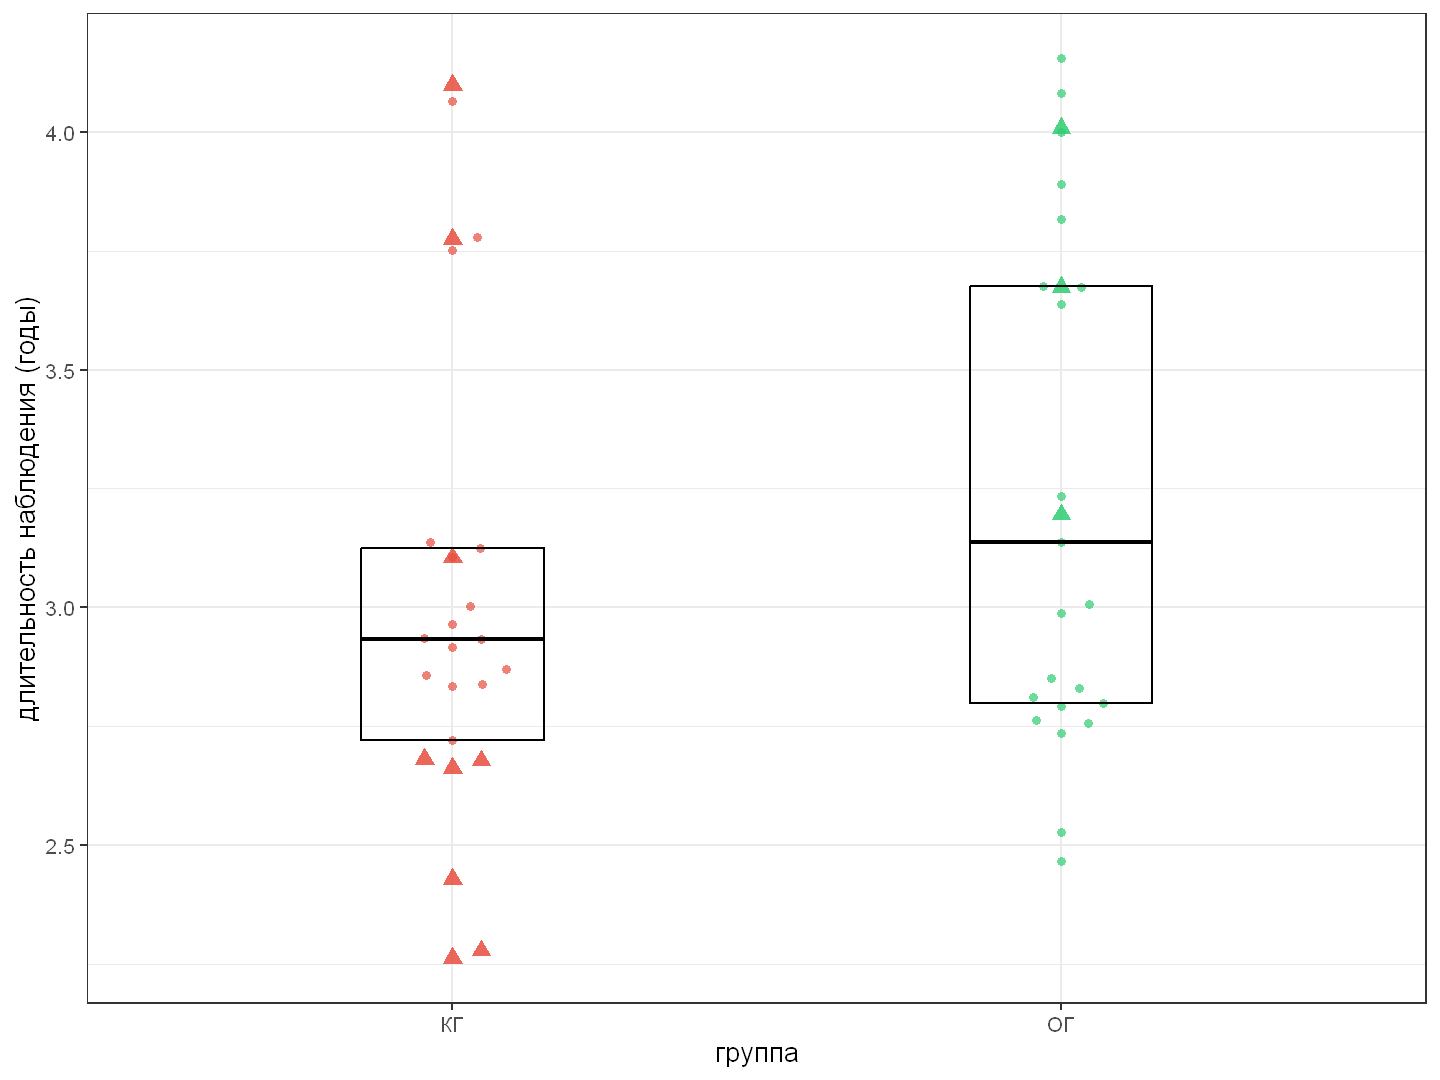

In [16]:
# ---- Follow-up time: beeswarm — ОГ combined vs КГ ----
fup_og_df <- patient_df_og |>
  dplyr::mutate(fup_years = followup / 365.25)

y_breaks_og <- seq(0, ceiling(max(fup_og_df$fup_years)), by = 0.5)

fup_beeswarm_og <- ggplot(fup_og_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette_og, guide = "none") +
  scale_y_continuous(breaks = y_breaks_og) +
  labs(
    x = "группа",
    y = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)

print(fup_beeswarm_og)


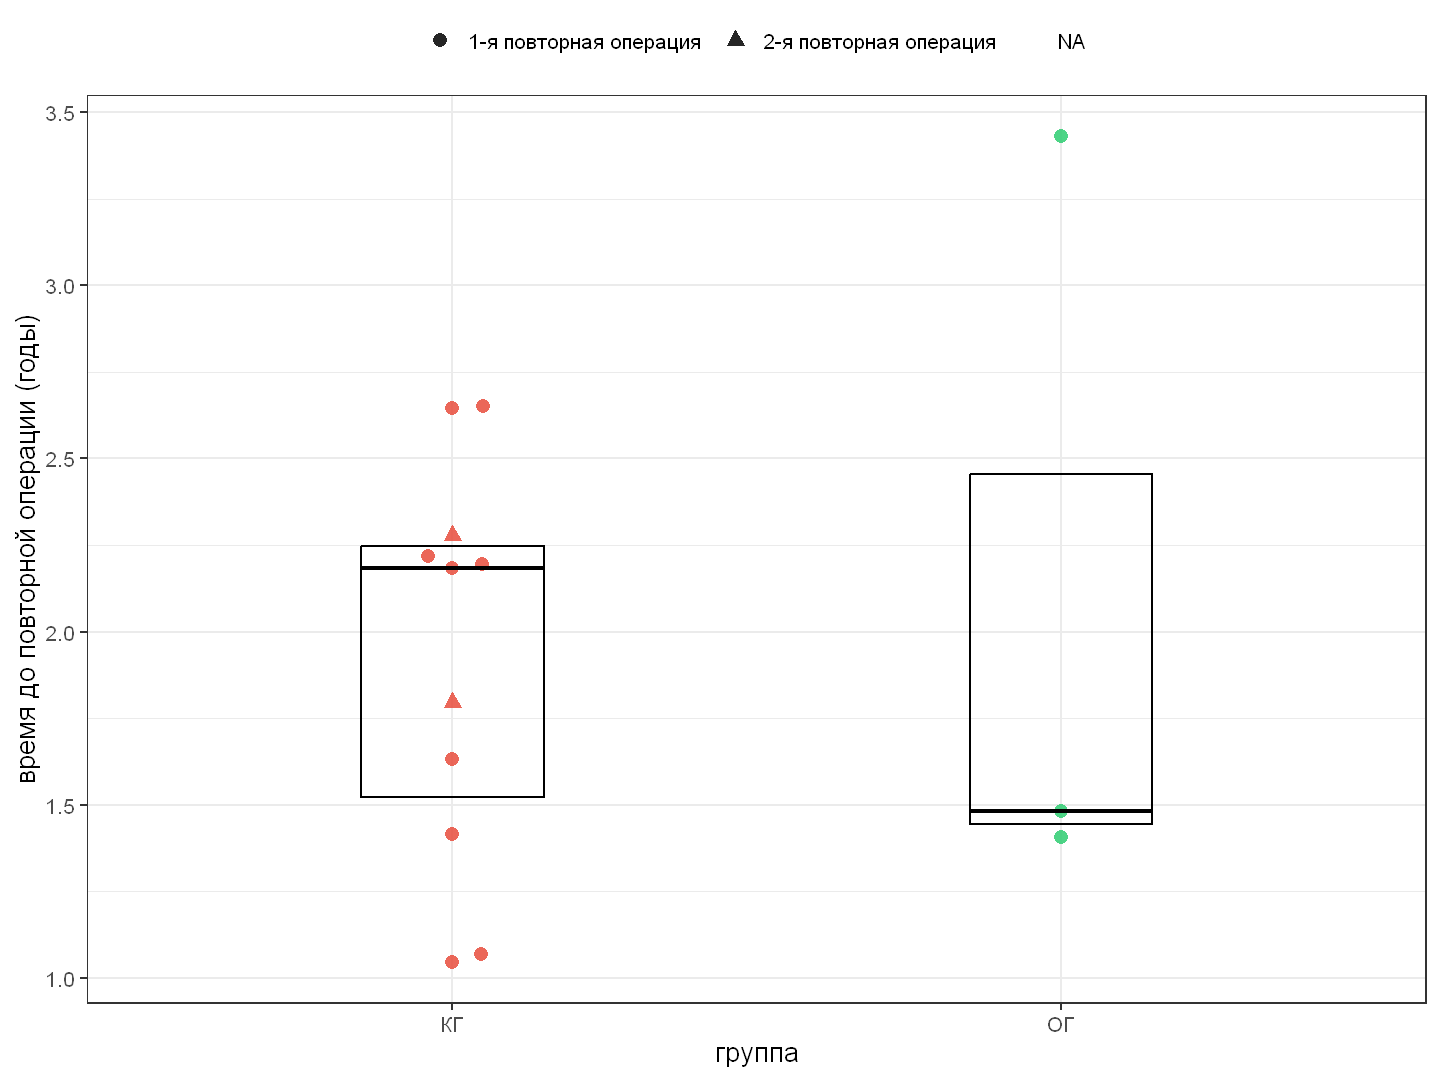

In [17]:
# ---- Reoperation times: beeswarm — ОГ combined vs КГ ----

reop_times_og_df <- bind_rows(
  patient_df_og |>
    filter(reop1 == 1) |>
    transmute(
      id, group,
      reop_year = days_diff(date_operation, date_reoperation1) / 365.25,
      reop_num = "1-я повторная операция"
    ),
  patient_df_og |>
    filter(reop2 == 1) |>
    transmute(
      id, group,
      reop_year = days_diff(date_operation, date_reoperation2) / 365.25,
      reop_num = "2-я повторная операция"
    )
) |>
  dplyr::mutate(reop_num = factor(reop_num,
    levels = c(
      "1-я повторная операция",
      "2-я повторная операция"
    )
  ))

# y axis breaks

y_breaks_reop_og <- seq(0, ceiling(max(reop_times_og_df$reop_year)), by = 0.5)


reop_beeswarm_og <- ggplot(
  reop_times_og_df,
  aes(
    x = group, y = reop_year,
    colour = group, shape = reop_num
  )
) +
  geom_beeswarm(cex = 2.5, size = 3.5, alpha = 0.85) +
  stat_summary(
    aes(group = group),
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette_og, guide = "none") +
  scale_shape_manual(
    values = c(
      "1-я повторная операция" = 16,
      "2-я повторная операция" = 17
    ),
    name = NULL
  ) +
  scale_y_continuous(breaks = y_breaks_reop_og) +
  labs(
    x = "группа",
    y = "время до повторной операции (годы)"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(reop_beeswarm_og)


In [18]:
first_reop_df <- patient_df |>
  dplyr::mutate(
    time_first = ifelse(
      reop1 == 1,
      days_diff(date_operation, date_reoperation1),
      followup
    ),
    event_first = as.integer(reop1 == 1)
  )
head(first_reop_df)


id,group,age,sex,ill_dur,polyps,allergy_dust,allergy_plants,allergy_mites,allergy_animals,⋯,date_operation,sinuses,followup,reop1,date_reoperation1,reop2,date_reoperation2,n_reops,time_first,event_first
<chr>,<fct>,<int>,<chr>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,⋯,<date>,<dbl>,<dbl>,<dbl>,<date>,<dbl>,<date>,<dbl>,<dbl>,<int>
1,ОГ1,48,муж.,10,3,нет,нет,нет,нет,⋯,2021-11-25,4,1518,0,NA,0,NA,0,1518,0
2,ОГ1,32,муж.,20,1,нет,да,нет,нет,⋯,2022-01-21,2,1461,0,NA,0,NA,0,1461,0
4,ОГ1,50,муж.,15,3,нет,нет,нет,нет,⋯,2021-12-22,8,1491,0,NA,0,NA,0,1491,0
5,ОГ1,28,муж.,8,7,да,да,нет,да,⋯,2022-01-18,4,1464,1,2023-07-13,0,NA,1,541,1
6,ОГ1,37,муж.,8,3,нет,нет,нет,нет,⋯,2022-03-02,1,1421,0,NA,0,NA,0,1421,0
7,ОГ1,23,жен.,8,2,нет,да,нет,да,⋯,2022-03-29,8,1394,0,NA,0,NA,0,1394,0


In [19]:
# ---- 2a (Part 2): Wide format — ОГ1+ОГ2 combined ----
first_reop_df_og <- patient_df_og |>
  dplyr::mutate(
    time_first = ifelse(
      reop1 == 1,
      days_diff(date_operation, date_reoperation1),
      followup
    ),
    event_first = as.integer(reop1 == 1)
  )
head(first_reop_df_og)


id,group,age,sex,ill_dur,polyps,allergy_dust,allergy_plants,allergy_mites,allergy_animals,⋯,date_operation,sinuses,followup,reop1,date_reoperation1,reop2,date_reoperation2,n_reops,time_first,event_first
<chr>,<fct>,<int>,<chr>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,⋯,<date>,<dbl>,<dbl>,<dbl>,<date>,<dbl>,<date>,<dbl>,<dbl>,<int>
1,ОГ,48,муж.,10,3,нет,нет,нет,нет,⋯,2021-11-25,4,1518,0,NA,0,NA,0,1518,0
2,ОГ,32,муж.,20,1,нет,да,нет,нет,⋯,2022-01-21,2,1461,0,NA,0,NA,0,1461,0
4,ОГ,50,муж.,15,3,нет,нет,нет,нет,⋯,2021-12-22,8,1491,0,NA,0,NA,0,1491,0
5,ОГ,28,муж.,8,7,да,да,нет,да,⋯,2022-01-18,4,1464,1,2023-07-13,0,NA,1,541,1
6,ОГ,37,муж.,8,3,нет,нет,нет,нет,⋯,2022-03-02,1,1421,0,NA,0,NA,0,1421,0
7,ОГ,23,жен.,8,2,нет,да,нет,да,⋯,2022-03-29,8,1394,0,NA,0,NA,0,1394,0


In [20]:
# ---- 2b. Long (counting process) format: one row per event interval ----
# Format:  id | group | tstart | tstop | status | event_num
# Used for: Andersen-Gill, PWP, MCF
make_long_format <- function(df) {
  rows <- vector("list", nrow(df))

  for (i in seq_len(nrow(df))) {
    pid <- df$id[i]
    grp <- as.character(df$group[i])
    fup <- df$followup[i]

    # Event times in days from index operation
    et <- numeric(0)
    if (df$reop1[i] == 1) et <- c(et, days_diff(df$date_operation[i], df$date_reoperation1[i]))
    if (df$reop2[i] == 1) et <- c(et, days_diff(df$date_operation[i], df$date_reoperation2[i]))
    et <- sort(et)

    if (length(et) == 0) {
      # No events: single censored interval [0, followup)
      rows[[i]] <- tibble::tibble(
        id        = pid,
        group     = grp,
        tstart    = 0,
        tstop     = fup,
        status    = 0L,
        event_num = 1L
      )
    } else {
      times <- c(0, et, fup)
      n_int <- length(times) - 1
      rows[[i]] <- tibble::tibble(
        id        = pid,
        group     = grp,
        tstart    = times[1:n_int],
        tstop     = times[2:(n_int + 1)],
        status    = c(rep(1L, length(et)), 0L),
        event_num = seq_len(n_int)
      )
    }
  }

  dplyr::bind_rows(rows) |>
    dplyr::mutate(group = factor(group))
}


In [21]:
# ---- Build long-format datasets for Part 1 and Part 2 ----
long_df <- make_long_format(patient_df)
long_df_og <- make_long_format(patient_df_og)

cat(sprintf("long_df rows:    %d  |  events: %d\n", nrow(long_df), sum(long_df$status)))
cat(sprintf("long_df_og rows: %d  |  events: %d\n", nrow(long_df_og), sum(long_df_og$status)))


long_df rows:    64  |  events: 14


long_df_og rows: 64  |  events: 14


# FULL FOLLOW UP

## 1. KAPLAN-MEIER + LOG-RANK  (time to first re-operation)

### Все группы

Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

           n events median 0.95LCL 0.95UCL
group=КГ  25      9     NA     968      NA
group=ОГ1 12      2     NA      NA      NA
group=ОГ2 13      1     NA      NA      NA



Log-rank test:


Call:
survdiff(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

           N Observed Expected (O-E)^2/E (O-E)^2/V
group=КГ  25        9     5.48     2.262      4.23
group=ОГ1 12        2     3.58     0.701      1.10
group=ОГ2 13        1     2.94     1.277      1.74

 Chisq= 4.3  on 2 degrees of freedom, p= 0.1 


Log-rank p-value: 0.1177


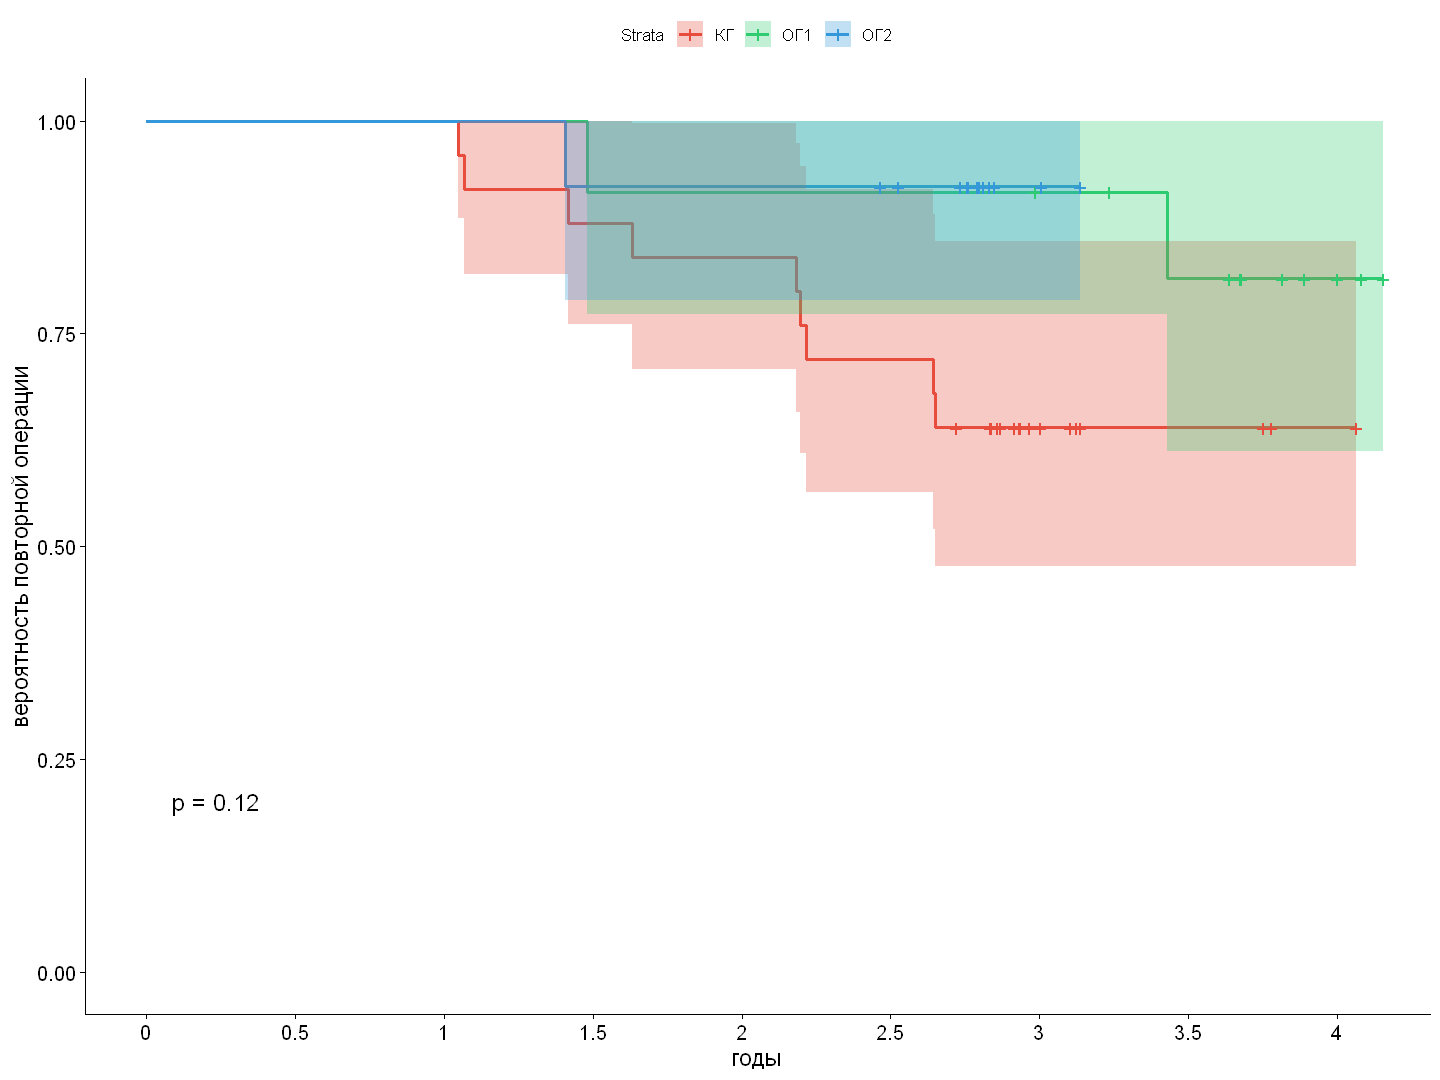

In [22]:
km_fit <- survfit(Surv(time_first, event_first) ~ group, data = first_reop_df)
print(km_fit)

# Log-rank test
logrank <- survdiff(Surv(time_first, event_first) ~ group, data = first_reop_df)
cat("\nLog-rank test:\n")
print(logrank)

# P-value
p_logrank <- pchisq(logrank$chisq, df = length(logrank$n) - 1, lower.tail = FALSE)
cat(sprintf("Log-rank p-value: %.4f\n", p_logrank))

# Plot
km_plot <- ggsurvplot(
  km_fit,
  data           = first_reop_df,
  pval           = TRUE,
  conf.int       = TRUE,
  risk.table     = FALSE,
  palette        = group_palette,
  xlab           = "годы",
  ylab           = "вероятность повторной операции",
  legend.labs    = group_levels,
  break.time.by  = six_months_days, # tick every 0.5 years
  xscale         = 365.25 # convert day values to year labels
)

print(km_plot)


In [23]:
# Survival estimates at every 6 months (half-year intervals)
half_year_times <- seq(six_months_days,
    max(first_reop_df$time_first, na.rm = TRUE),
    by = six_months_days
)
km_summary <- summary(km_fit, times = half_year_times, extend = TRUE)
print(km_summary)


Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

                group=КГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0     1.00  0.0000        1.000        1.000
  365     25       0     1.00  0.0000        1.000        1.000
  548     22       3     0.88  0.0650        0.761        1.000
  730     21       1     0.84  0.0733        0.708        0.997
  913     18       3     0.72  0.0898        0.564        0.919
 1096      7       2     0.64  0.0960        0.477        0.859
 1278      3       0     0.64  0.0960        0.477        0.859
 1461      1       0     0.64  0.0960        0.477        0.859

                group=ОГ1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     12       0    1.000  0.0000        1.000            1
  365     12       0    1.000  0.0000        1.000            1
  548     11       1    0.917  0.0798        0.773            1
  730     11       0    0.91

#### ОГ1+ОГ2 vs КГ

Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

          n events median 0.95LCL 0.95UCL
group=КГ 25      9     NA     968      NA
group=ОГ 25      3     NA      NA      NA



Log-rank test:


Call:
survdiff(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

          N Observed Expected (O-E)^2/E (O-E)^2/V
group=КГ 25        9     5.48      2.26      4.23
group=ОГ 25        3     6.52      1.90      4.23

 Chisq= 4.2  on 1 degrees of freedom, p= 0.04 


Log-rank p-value: 0.0396


Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

                group=КГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0     1.00  0.0000        1.000        1.000
  365     25       0     1.00  0.0000        1.000        1.000
  548     22       3     0.88  0.0650        0.761        1.000
  730     21       1     0.84  0.0733        0.708        0.997
  913     18       3     0.72  0.0898        0.564        0.919
 1096      7       2     0.64  0.0960        0.477        0.859
 1278      3       0     0.64  0.0960        0.477        0.859
 1461      1       0     0.64  0.0960        0.477        0.859

                group=ОГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0    1.000  0.0000        1.000            1
  365     25       0    1.000  0.0000        1.000            1
  548     23       2    0.920  0.0543        0.820            1
  730     23       0    0.

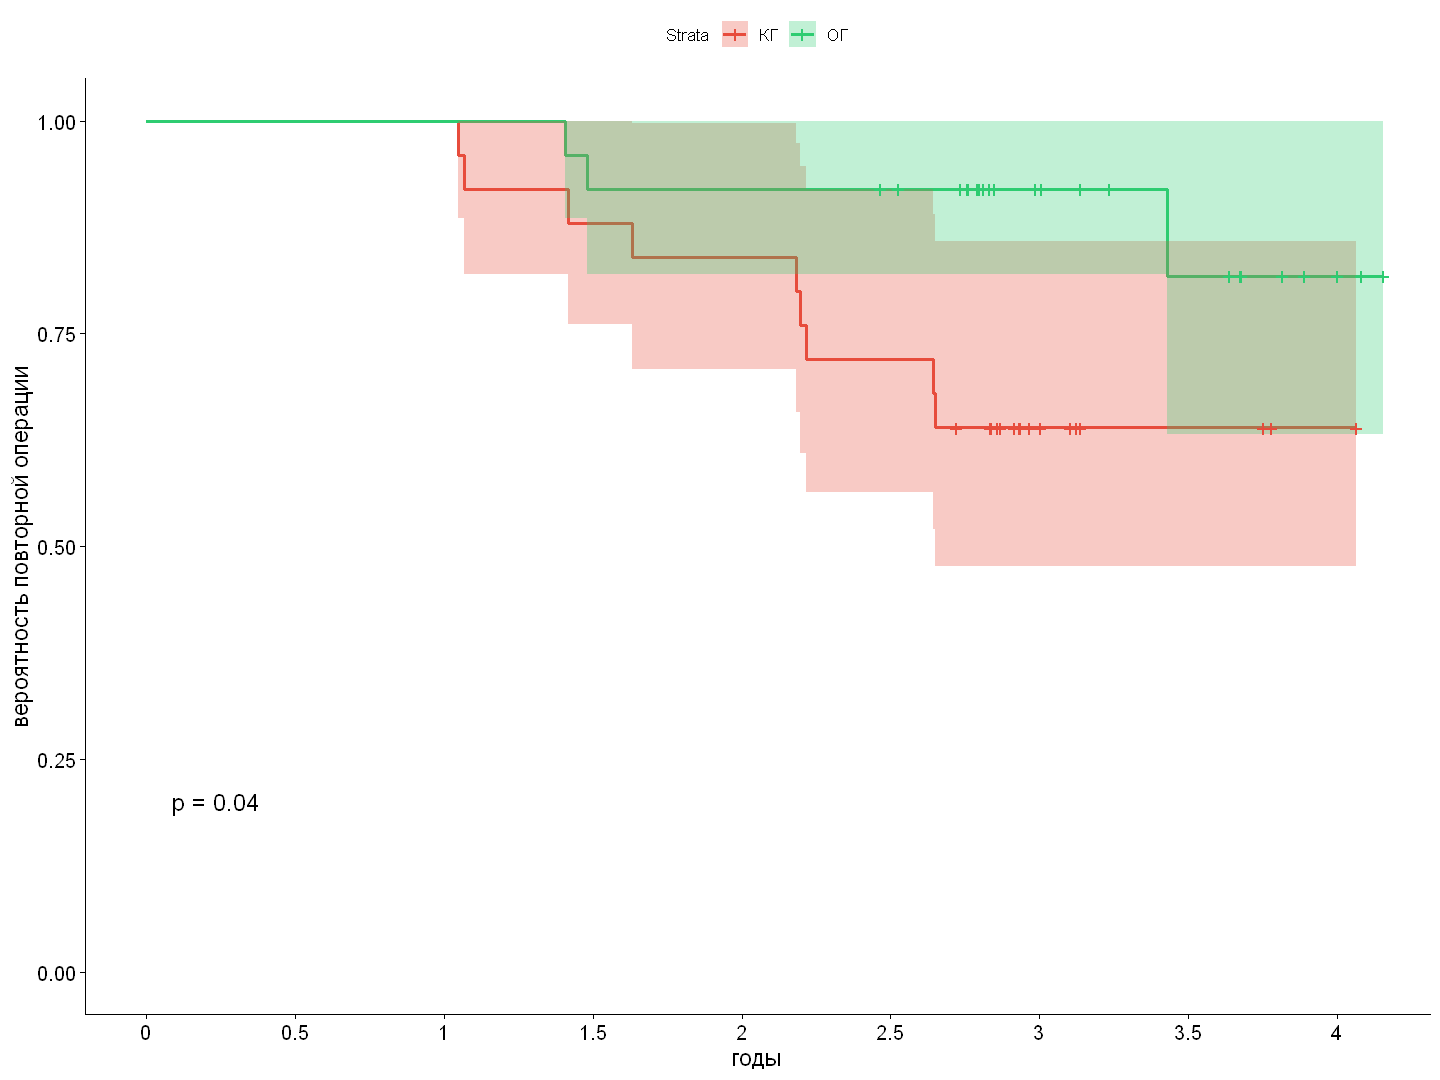

In [24]:
km_fit_og <- survfit(Surv(time_first, event_first) ~ group, data = first_reop_df_og)
print(km_fit_og)

logrank_og <- survdiff(Surv(time_first, event_first) ~ group, data = first_reop_df_og)
cat("\nLog-rank test:\n")
print(logrank_og)

p_logrank_og <- pchisq(logrank_og$chisq, df = length(logrank_og$n) - 1, lower.tail = FALSE)
cat(sprintf("Log-rank p-value: %.4f\n", p_logrank_og))

km_plot_og <- ggsurvplot(
  km_fit_og,
  data           = first_reop_df_og,
  pval           = TRUE,
  conf.int       = TRUE,
  risk.table     = FALSE,
  palette        = group_palette_og,
  xlab           = "годы",
  ylab           = "вероятность повторной операции",
  legend.labs    = group_levels_og,
  break.time.by  = six_months_days,
  xscale         = 365.25
)
print(km_plot_og)

half_year_times_og <- seq(six_months_days,
  max(first_reop_df_og$time_first, na.rm = TRUE),
  by = six_months_days
)
print(summary(km_fit_og, times = half_year_times_og, extend = TRUE))


## 2. COX PROPORTIONAL HAZARDS  (time to first re-operation)

### 2.1  Unadjusted — group only


#### Все группы

In [25]:
cox_fit <- coxph(Surv(time_first, event_first) ~ group, data = first_reop_df)
cat("\nCox PH model summary (group only):\n")
print(summary(cox_fit))



Cox PH model summary (group only):


Call:
coxph(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.1196    0.3264   0.8091 -1.384    0.166
groupОГ2 -1.5632    0.2095   1.0560 -1.480    0.139

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3264      3.064   0.06684     1.594
groupОГ2    0.2095      4.774   0.02644     1.659

Concordance= 0.663  (se = 0.068 )
Likelihood ratio test= 4.49  on 2 df,   p=0.1
Wald test            = 3.68  on 2 df,   p=0.2
Score (logrank) test = 4.28  on 2 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group   1.13  2 0.57
GLOBAL  1.13  2 0.57


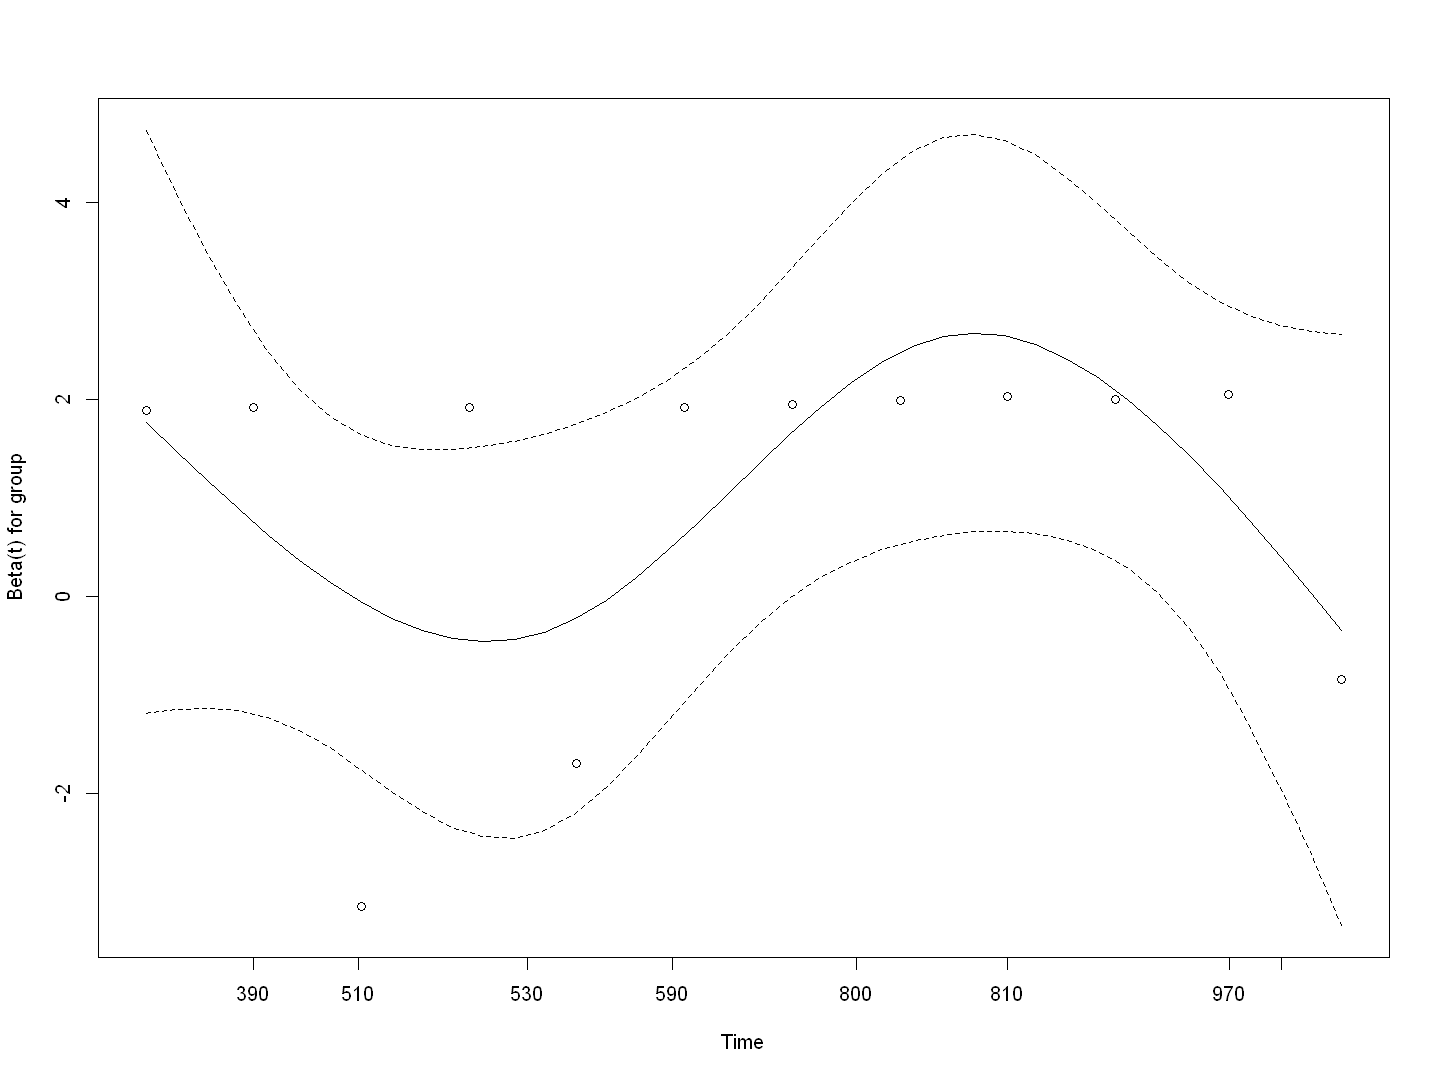

In [26]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test <- cox.zph(cox_fit)
print(ph_test)
# p > 0.05 → PH assumption not violated
plot(ph_test)


#### ОГ1+ОГ2 vs КГ

In [27]:
cox_fit_og <- coxph(Surv(time_first, event_first) ~ group, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group only):\n")
print(summary(cox_fit_og))



Cox PH model summary — ОГ combined (group only):


Call:
coxph(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.2980    0.2731   0.6735 -1.927   0.0539 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2731      3.662   0.07295     1.022

Concordance= 0.663  (se = 0.065 )
Likelihood ratio test= 4.36  on 1 df,   p=0.04
Wald test            = 3.71  on 1 df,   p=0.05
Score (logrank) test = 4.23  on 1 df,   p=0.04




Test of PH assumption:


        chisq df    p
group  0.0378  1 0.85
GLOBAL 0.0378  1 0.85


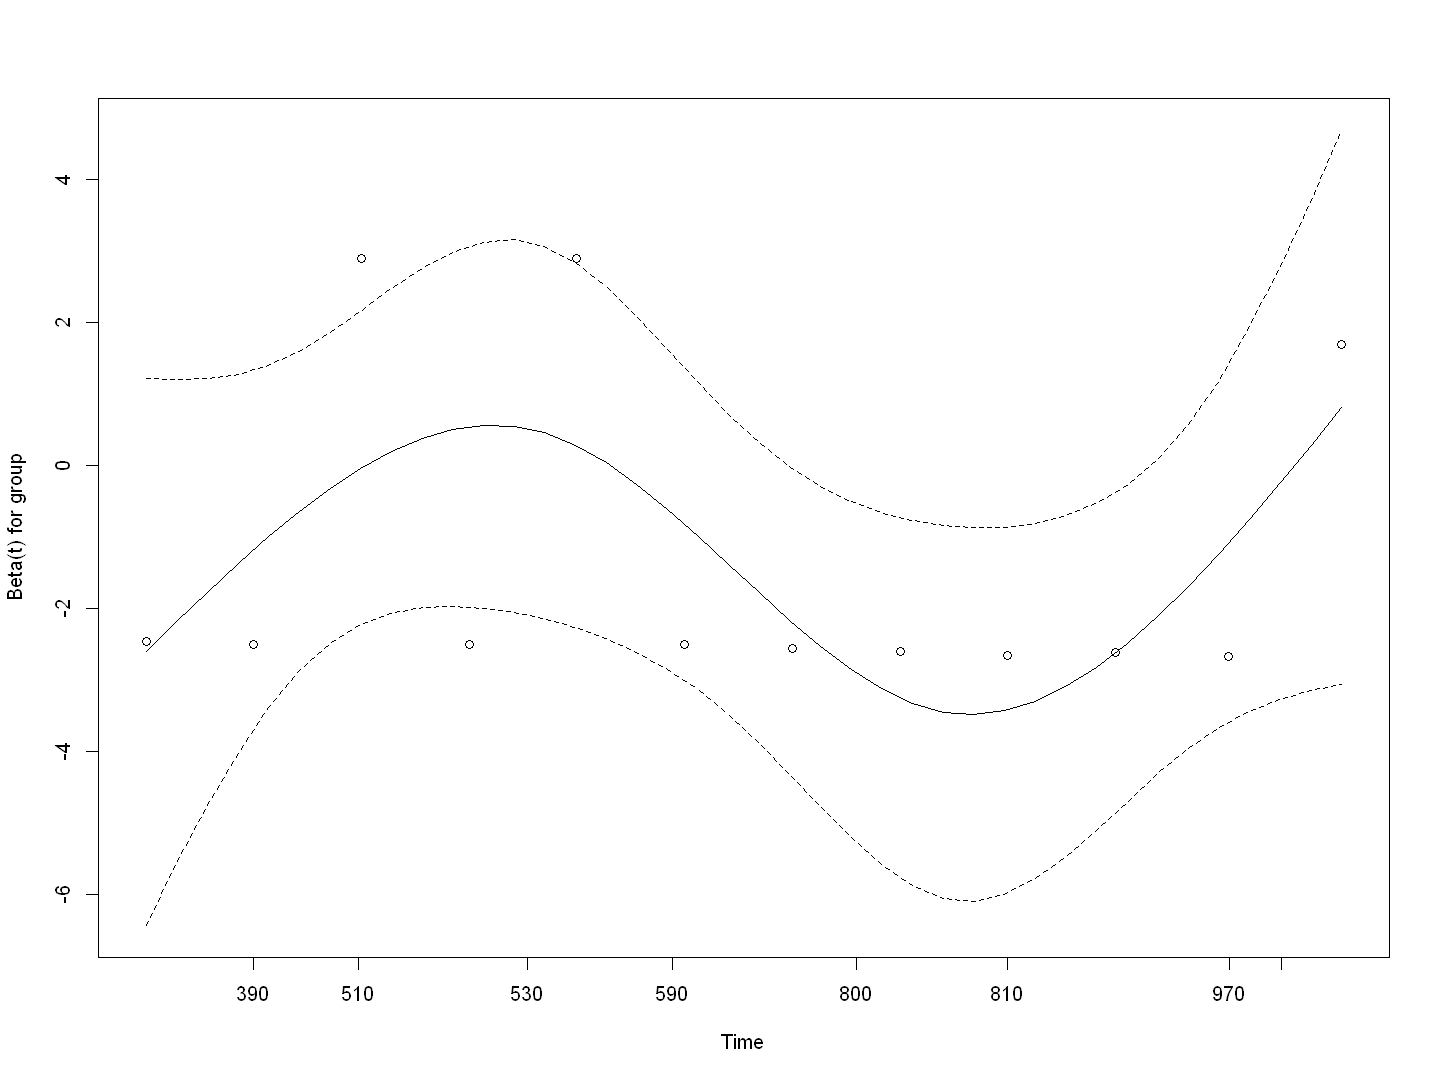

In [28]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption:\n")
ph_test <- cox.zph(cox_fit_og)
print(ph_test)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test)


### 2.2  Adjusted — group + оперированные пазухи (sinuses)


#### Все группы

In [29]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + sinuses, data = first_reop_df)
cat("\nCox PH model summary (group + sinuses):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + sinuses):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sinuses, 
    data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ1 -1.5597    0.2102   0.8457 -1.844   0.0652 .
groupОГ2 -1.0879    0.3369   1.1034 -0.986   0.3242  
sinuses  -0.2474    0.7808   0.1318 -1.877   0.0605 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2102      4.757   0.04006     1.103
groupОГ2    0.3369      2.968   0.03875     2.929
sinuses     0.7808      1.281   0.60310     1.011

Concordance= 0.74  (se = 0.069 )
Likelihood ratio test= 8.13  on 3 df,   p=0.04
Wald test            = 7.51  on 3 df,   p=0.06
Score (logrank) test = 8.41  on 3 df,   p=0.04




Test of PH assumption (Schoenfeld residuals):


         chisq df    p
group   1.1752  2 0.56
sinuses 0.0204  1 0.89
GLOBAL  1.4831  3 0.69


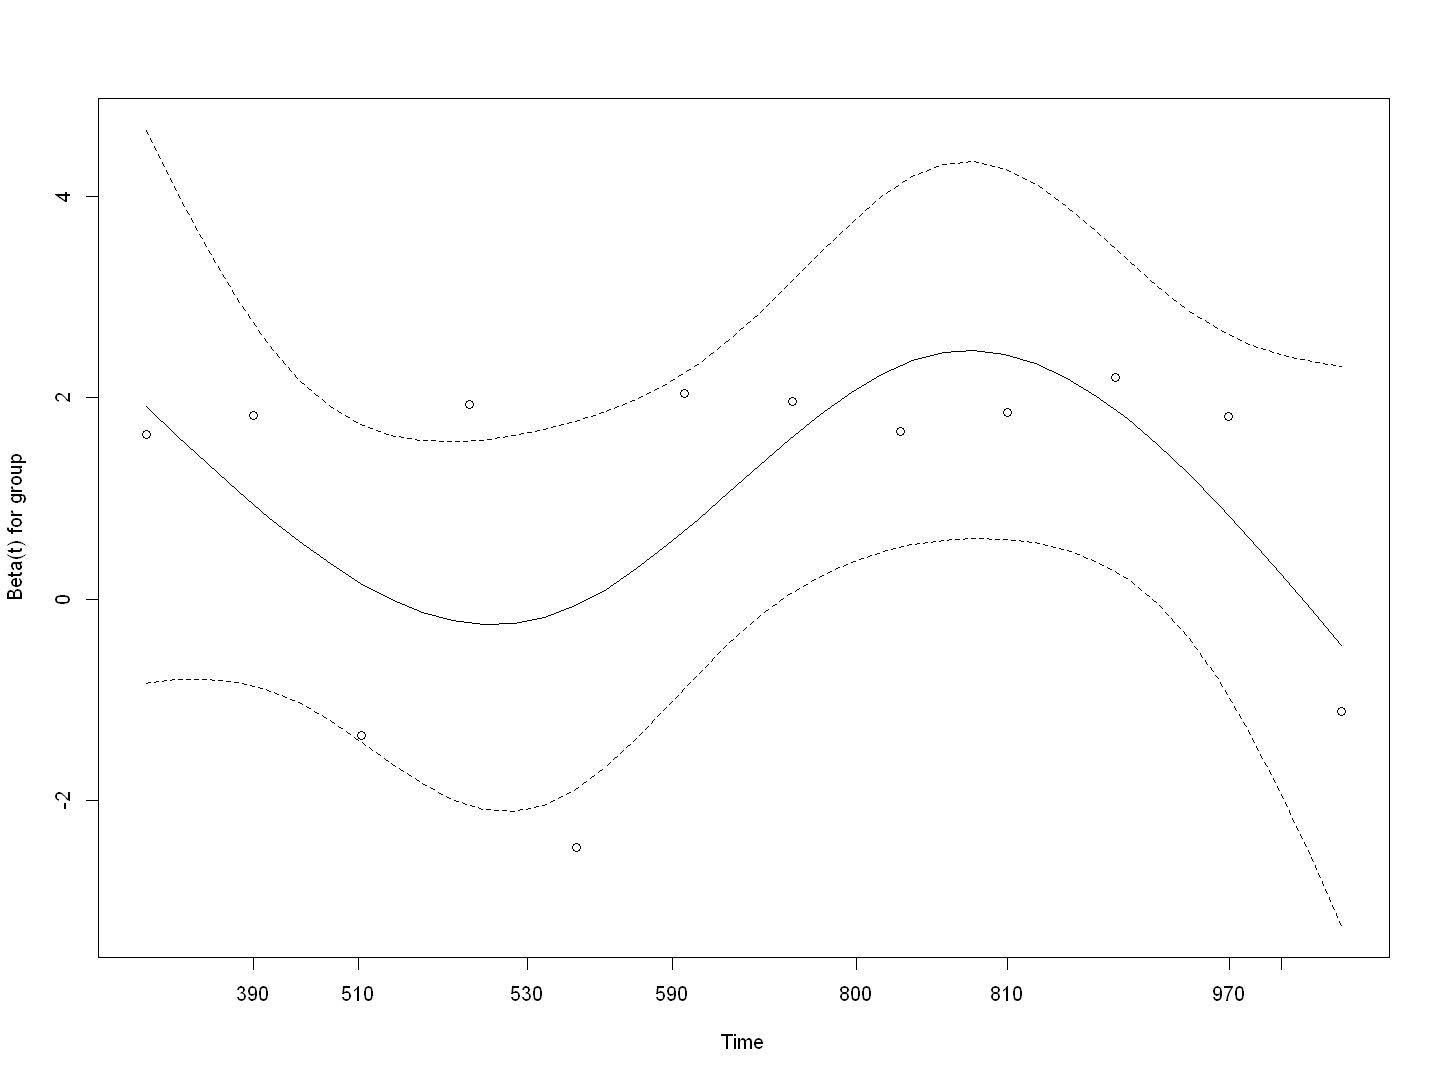

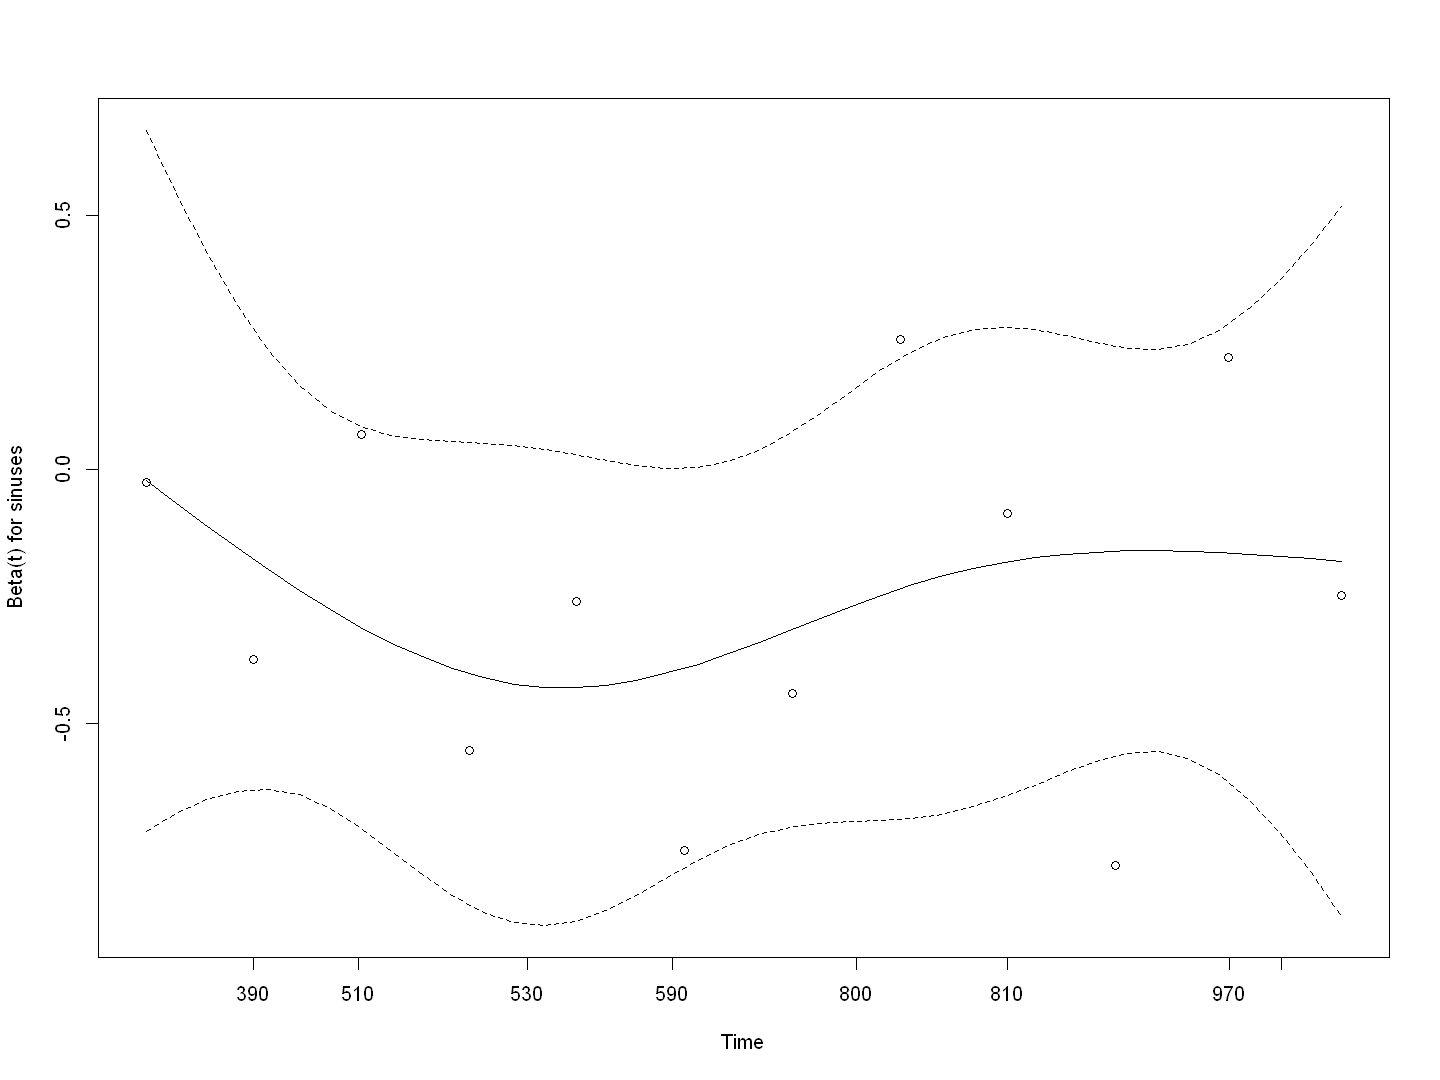

In [30]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [31]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + sinuses, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + sinuses):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + sinuses):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sinuses, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.4035    0.2457   0.6859 -2.046   0.0407 *
sinuses -0.2304    0.7942   0.1208 -1.907   0.0565 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2457      4.069   0.06407    0.9425
sinuses    0.7942      1.259   0.62679    1.0064

Concordance= 0.741  (se = 0.068 )
Likelihood ratio test= 8.01  on 2 df,   p=0.02
Wald test            = 7.02  on 2 df,   p=0.03
Score (logrank) test = 7.85  on 2 df,   p=0.02




Test of PH assumption:


         chisq df    p
group   0.1383  1 0.71
sinuses 0.0219  1 0.88
GLOBAL  0.1459  2 0.93


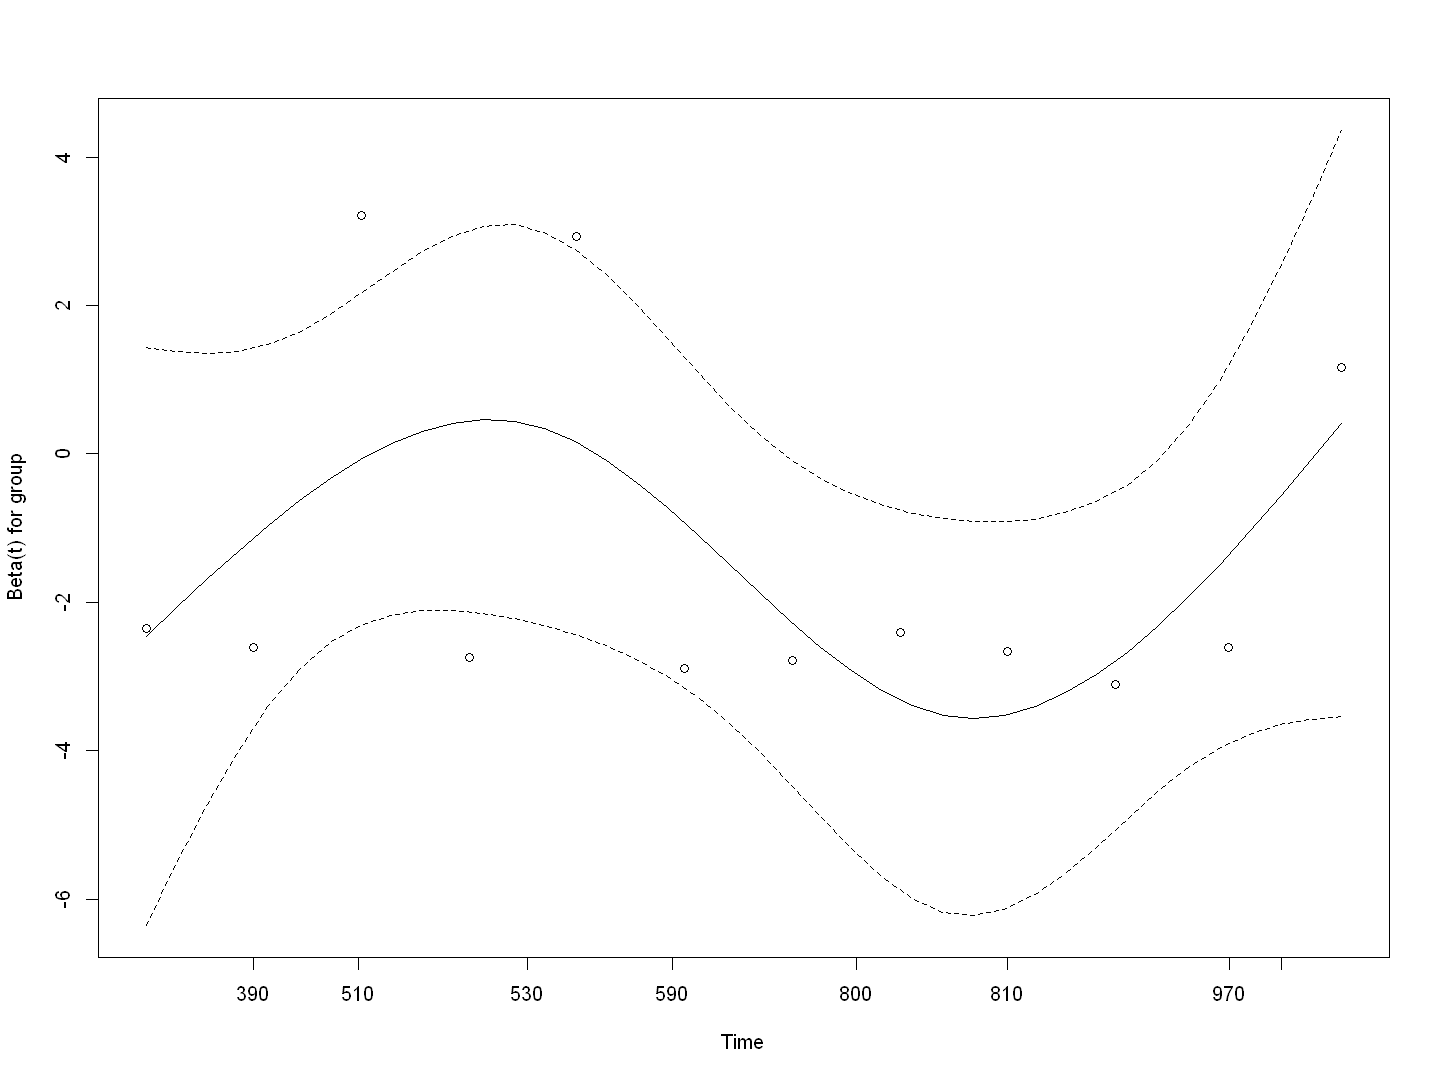

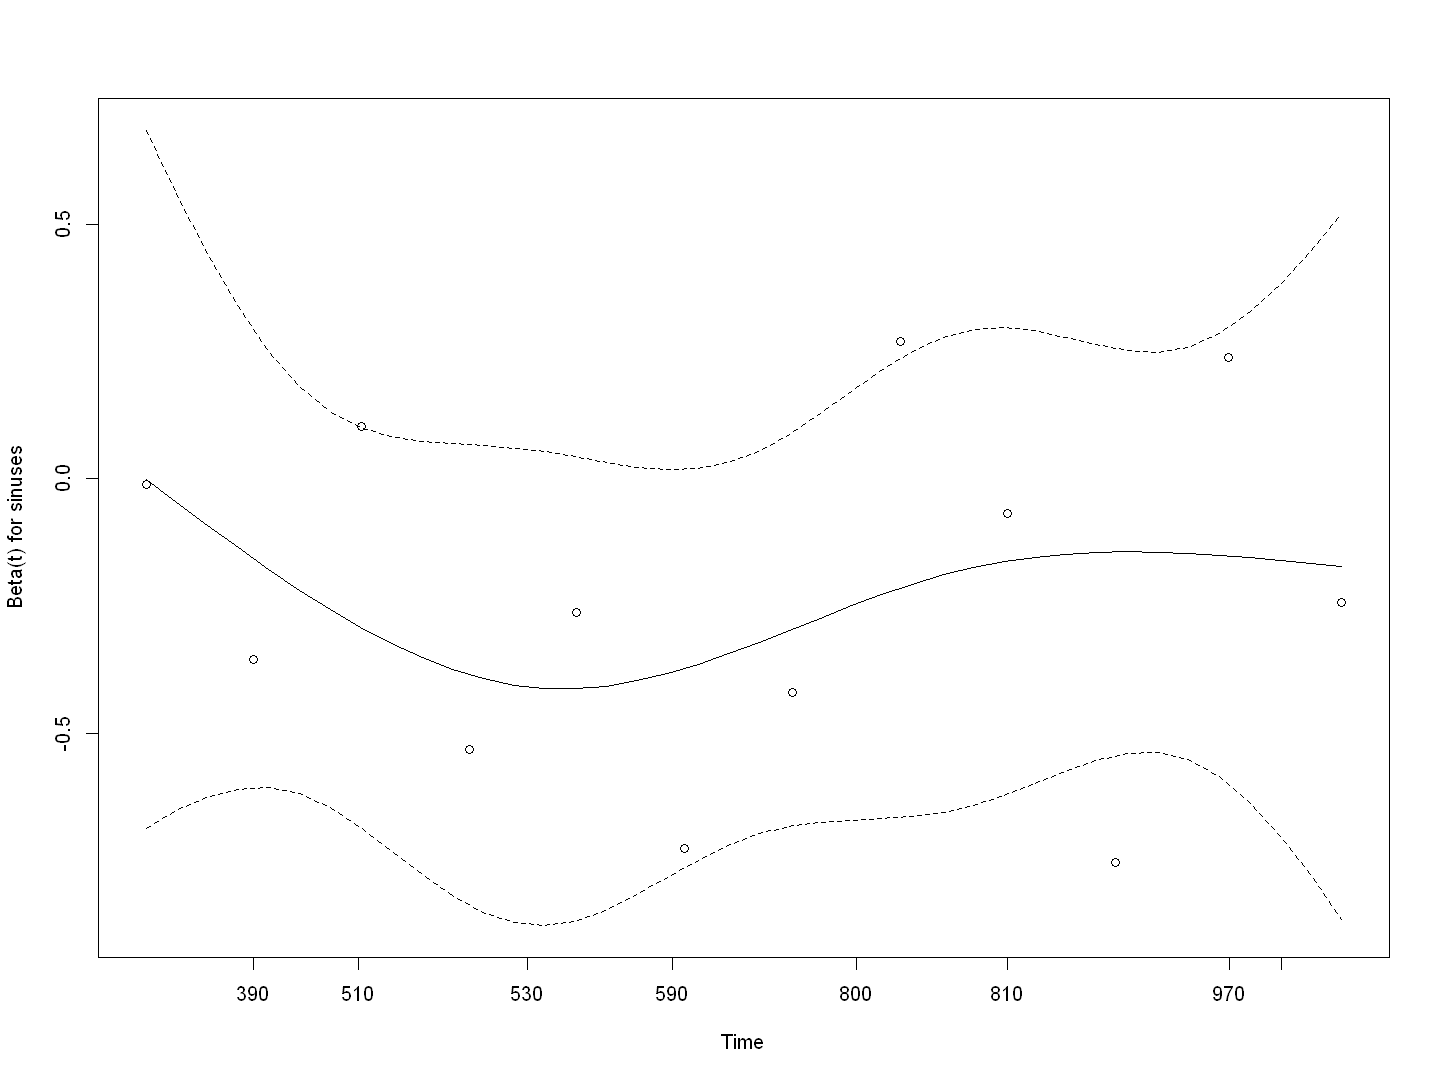

In [32]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + возраст


#### Все группы

In [33]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + age, data = first_reop_df)
cat("\nCox PH model summary (group + age):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + age):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + age, 
    data = first_reop_df)

  n= 50, number of events= 12 

              coef exp(coef)  se(coef)      z Pr(>|z|)
groupОГ1 -1.116432  0.327446  0.803147 -1.390    0.165
groupОГ2 -1.588341  0.204264  1.057546 -1.502    0.133
age      -0.009407  0.990637  0.022136 -0.425    0.671

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3274      3.054   0.06784     1.580
groupОГ2    0.2043      4.896   0.02570     1.623
age         0.9906      1.009   0.94858     1.035

Concordance= 0.665  (se = 0.072 )
Likelihood ratio test= 4.67  on 3 df,   p=0.2
Wald test            = 3.89  on 3 df,   p=0.3
Score (logrank) test = 4.49  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


        chisq df    p
group  1.1542  2 0.56
age    0.0594  1 0.81
GLOBAL 1.1821  3 0.76


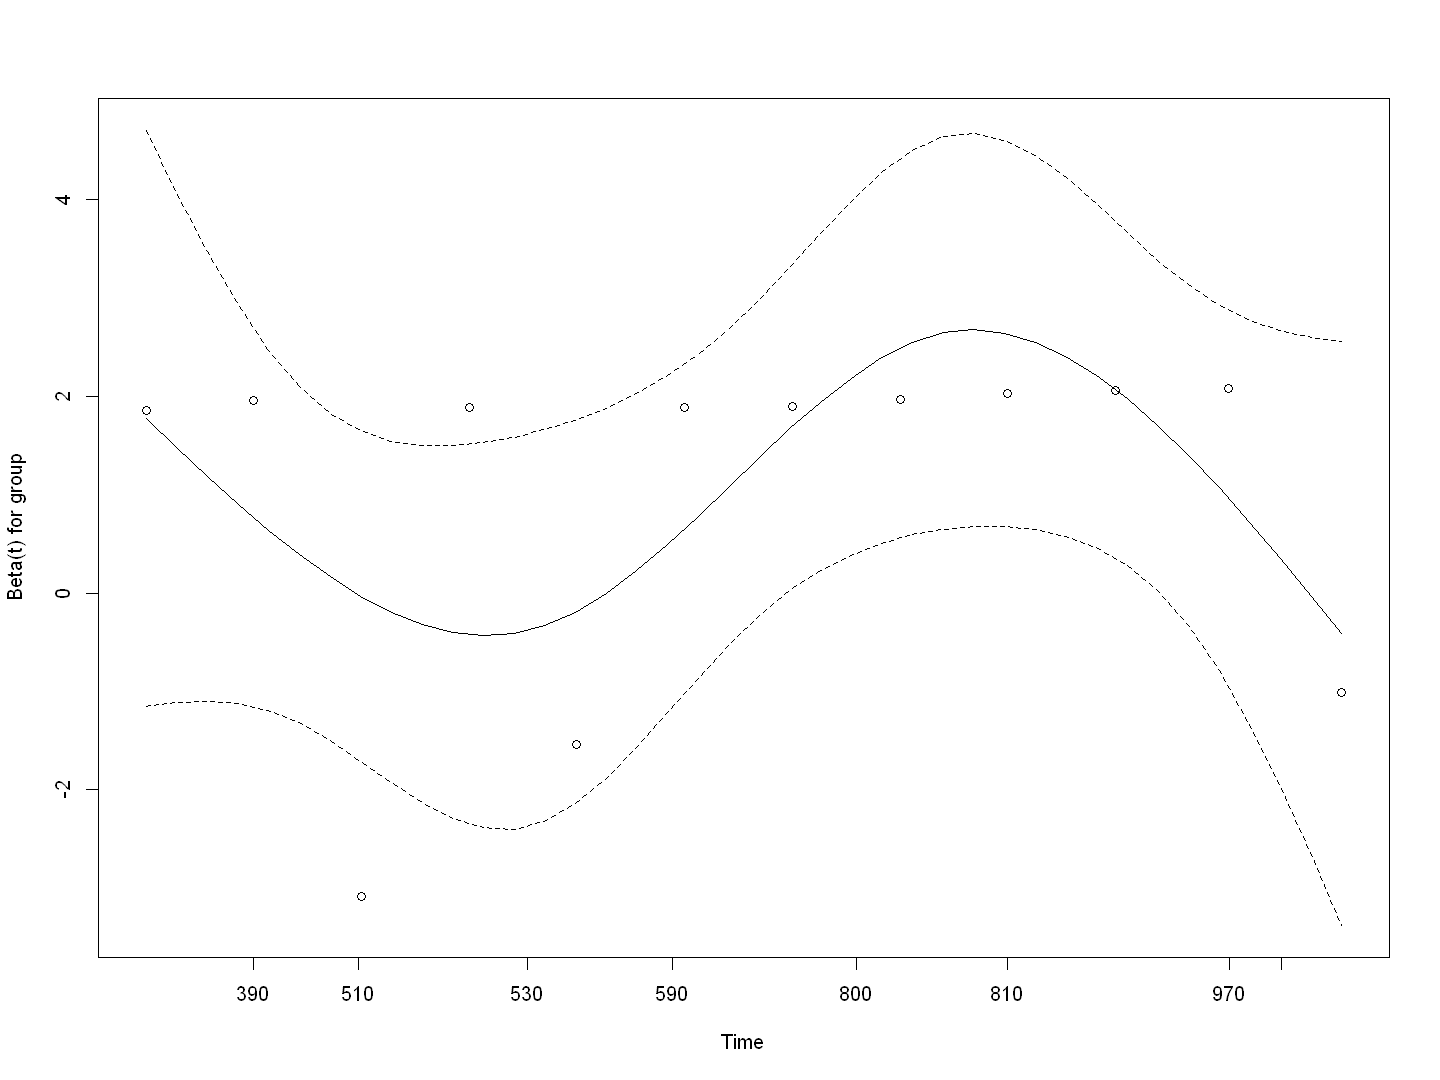

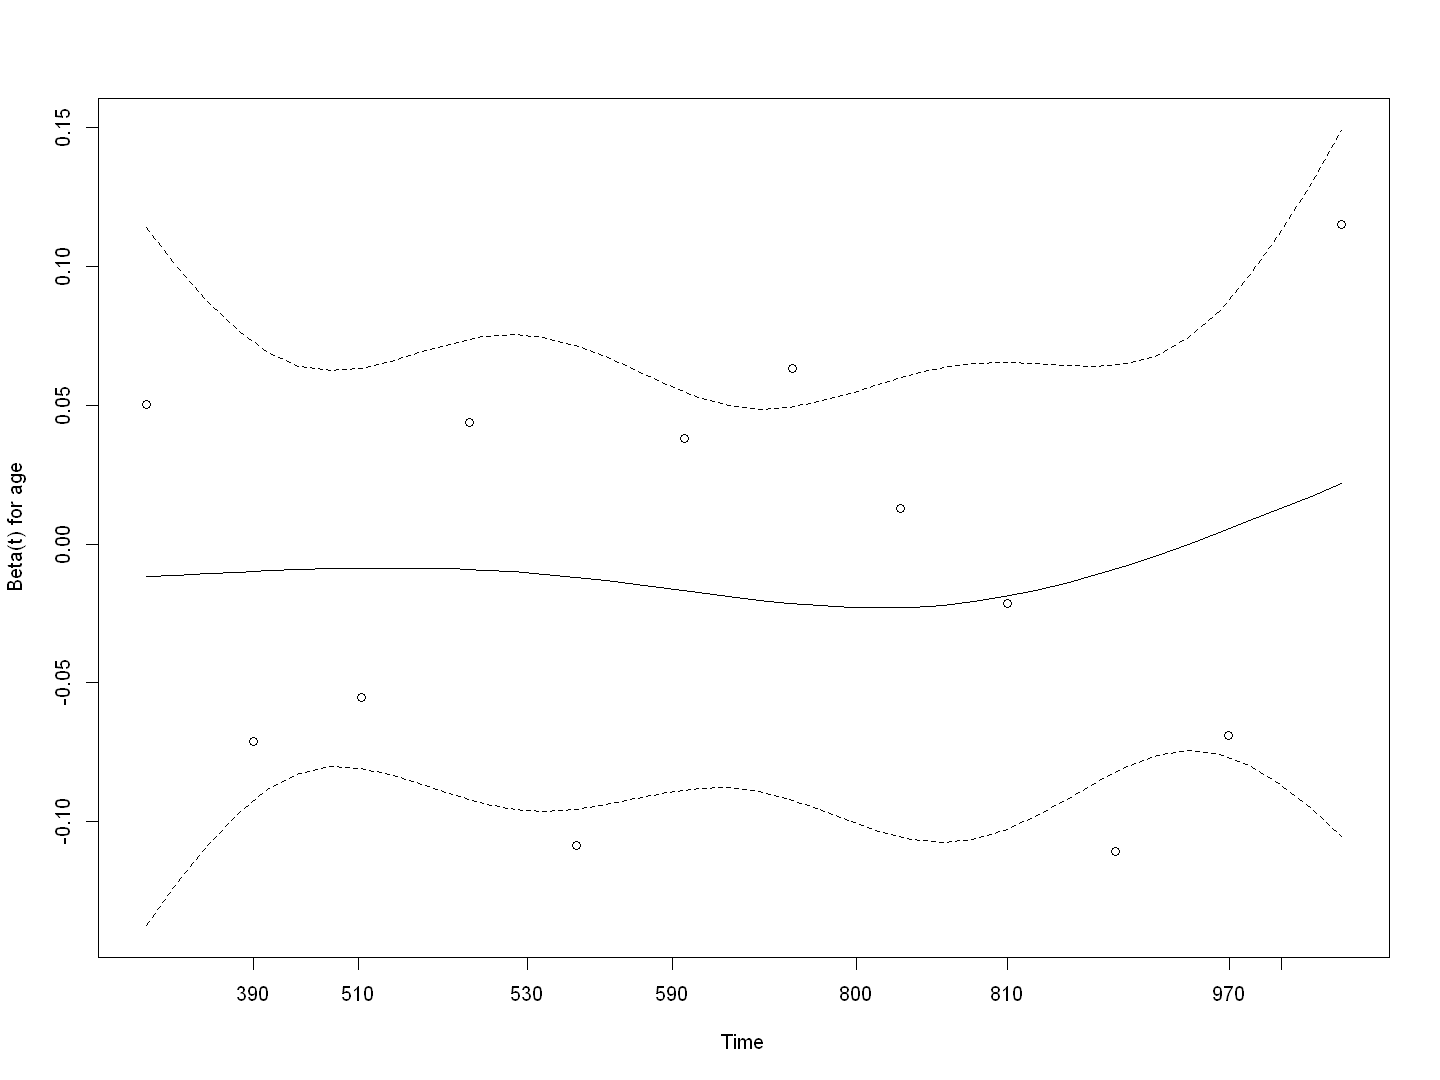

In [34]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [35]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + age, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + age):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + age):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + age, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

             coef exp(coef)  se(coef)      z Pr(>|z|)  
groupОГ -1.305467  0.271046  0.671472 -1.944   0.0519 .
age     -0.008938  0.991101  0.022180 -0.403   0.6870  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2710      3.689   0.07269     1.011
age        0.9911      1.009   0.94894     1.035

Concordance= 0.681  (se = 0.065 )
Likelihood ratio test= 4.52  on 2 df,   p=0.1
Wald test            = 3.91  on 2 df,   p=0.1
Score (logrank) test = 4.44  on 2 df,   p=0.1




Test of PH assumption:


        chisq df    p
group  0.0213  1 0.88
age    0.0716  1 0.79
GLOBAL 0.0974  2 0.95


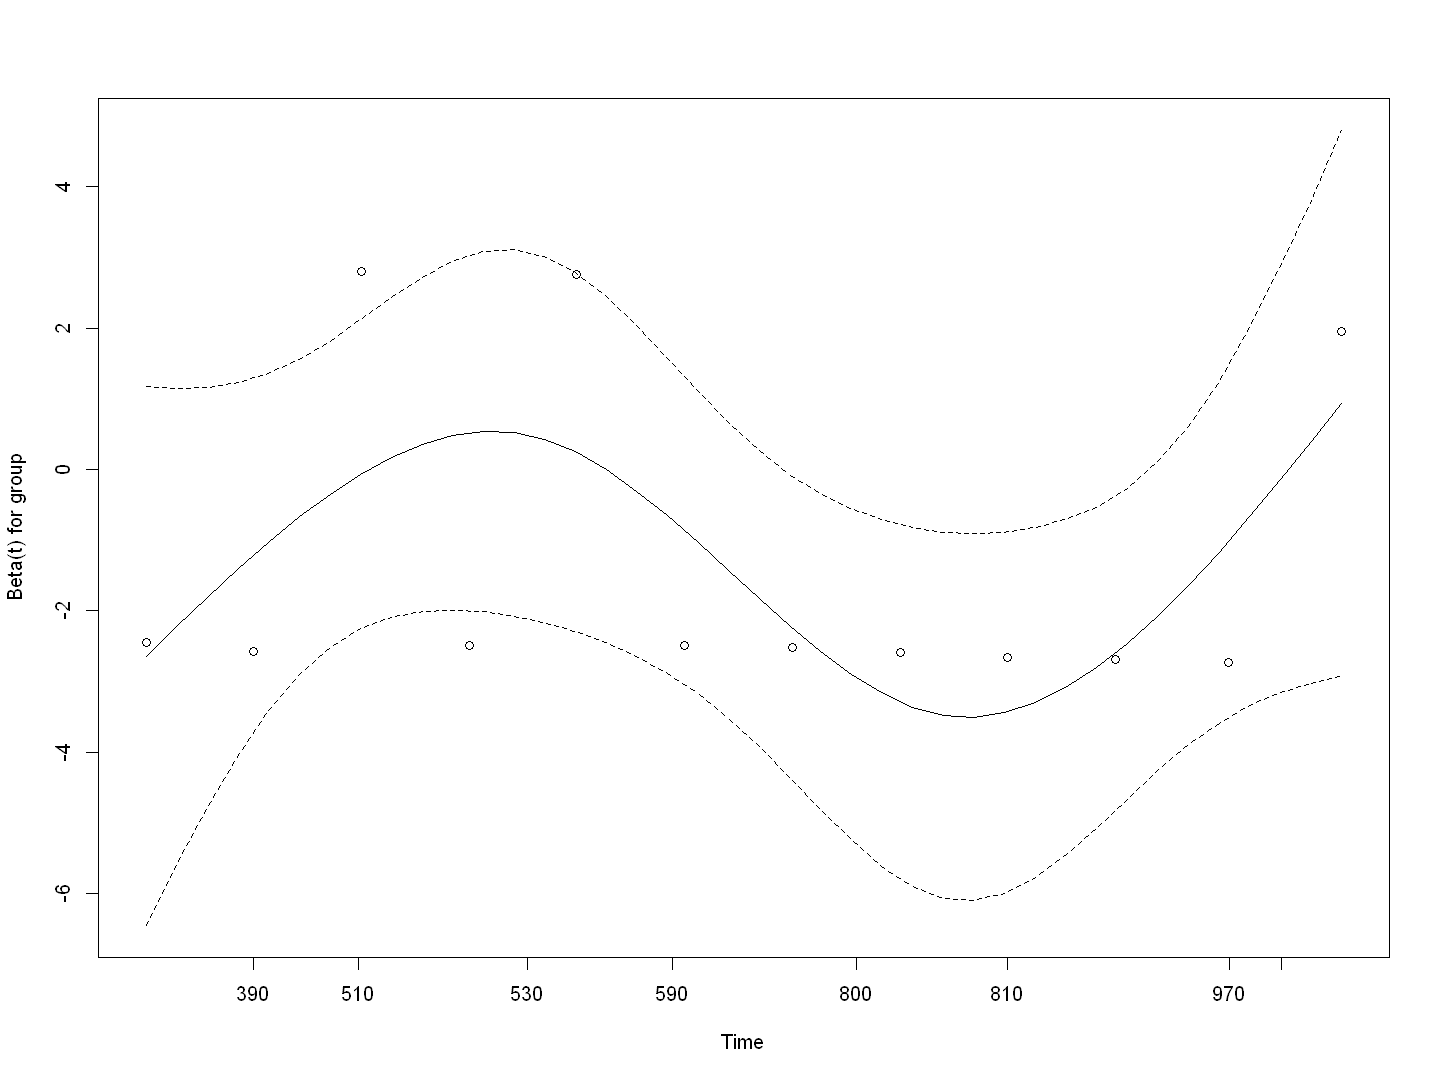

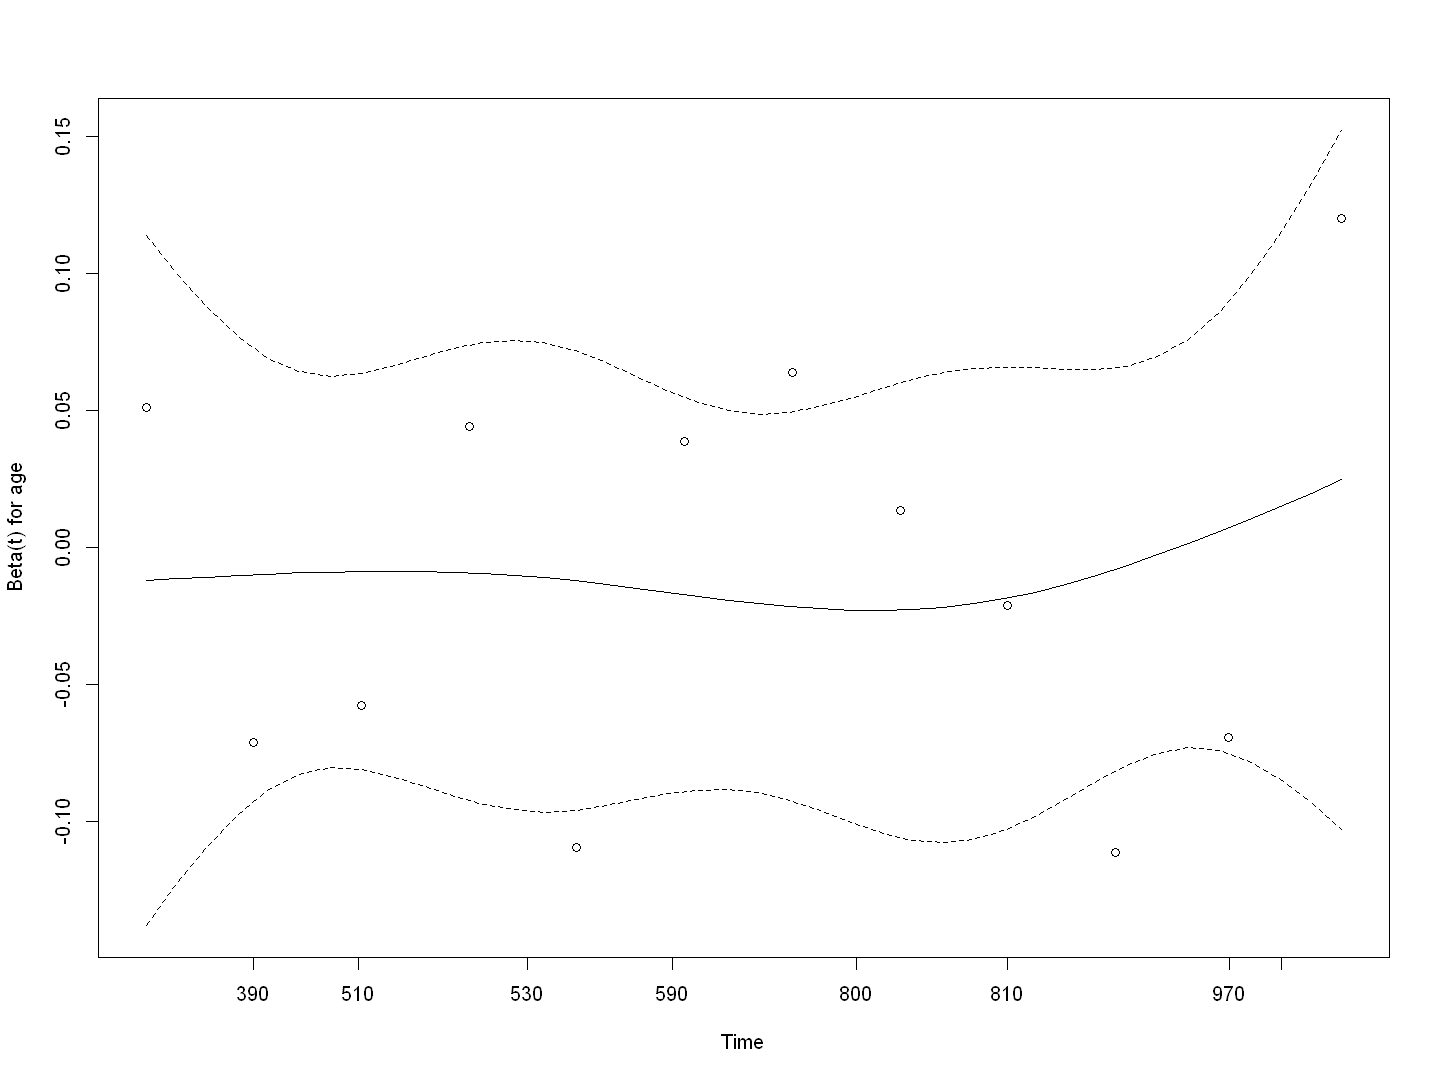

In [36]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + пол


#### Все группы

In [37]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + sex, data = first_reop_df)
cat("\nCox PH model summary (group + sex):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + sex):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sex, 
    data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.0865    0.3374   0.8243 -1.318    0.187
groupОГ2 -1.5606    0.2100   1.0559 -1.478    0.139
sexмуж.  -0.8174    0.4416   0.5925 -1.379    0.168

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3374      2.964   0.06707     1.697
groupОГ2    0.2100      4.762   0.02651     1.664
sexмуж.     0.4416      2.265   0.13825     1.411

Concordance= 0.715  (se = 0.086 )
Likelihood ratio test= 6.27  on 3 df,   p=0.1
Wald test            = 5.51  on 3 df,   p=0.1
Score (logrank) test = 6.28  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


       chisq df     p
group   1.20  2 0.550
sex     3.00  1 0.083
GLOBAL  4.22  3 0.239


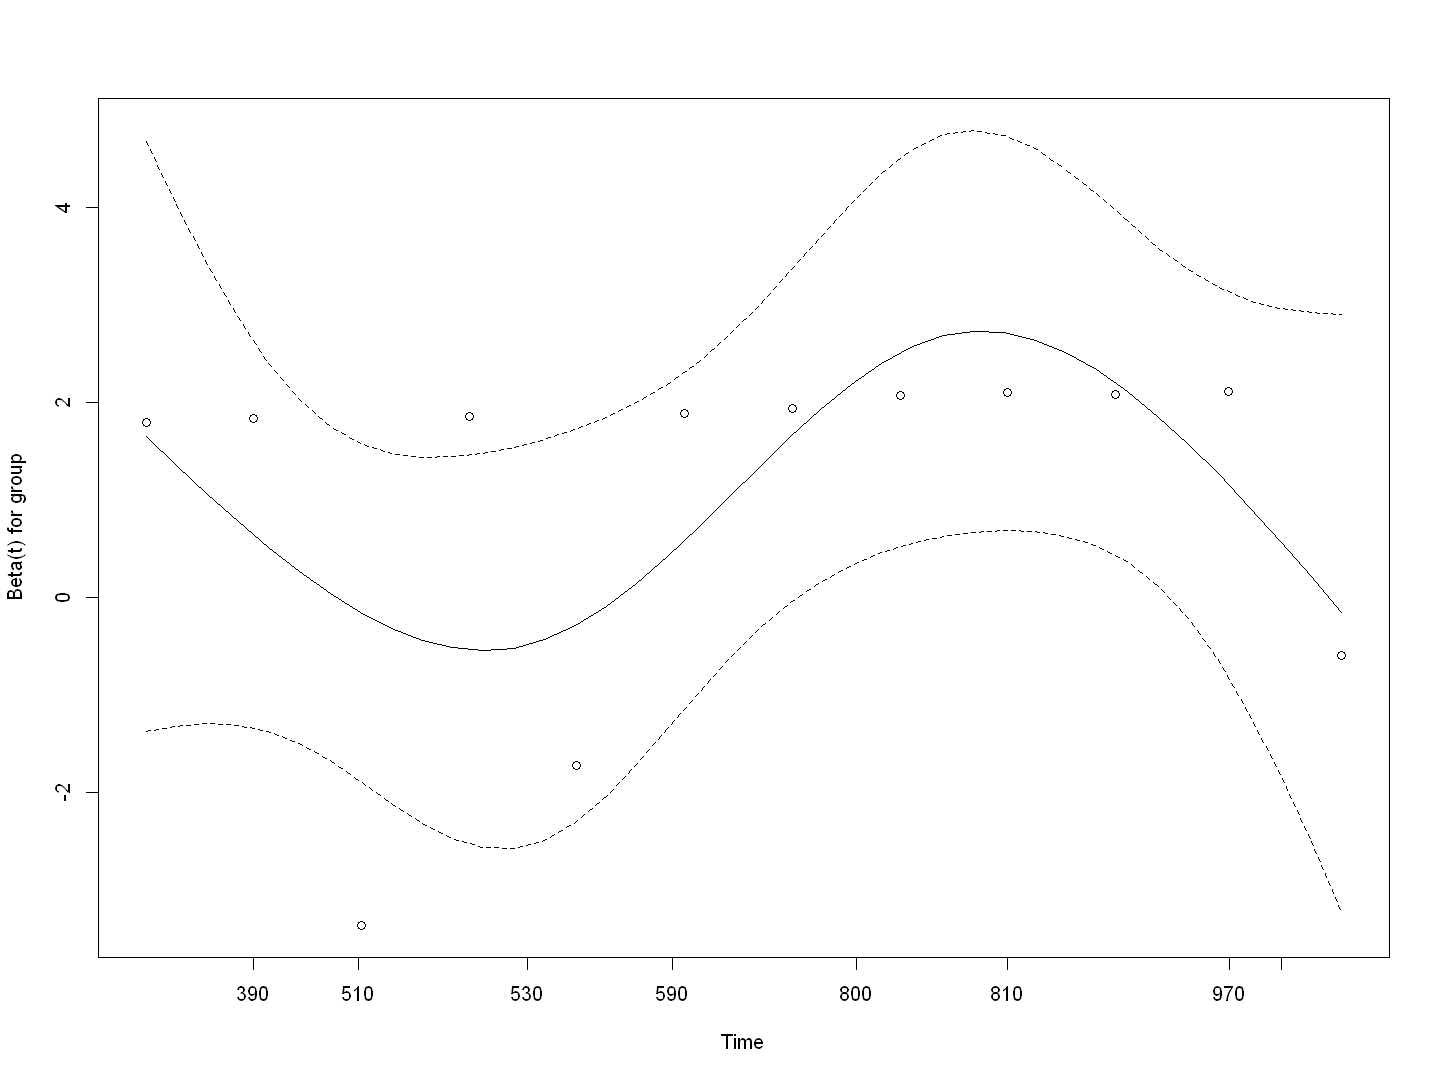

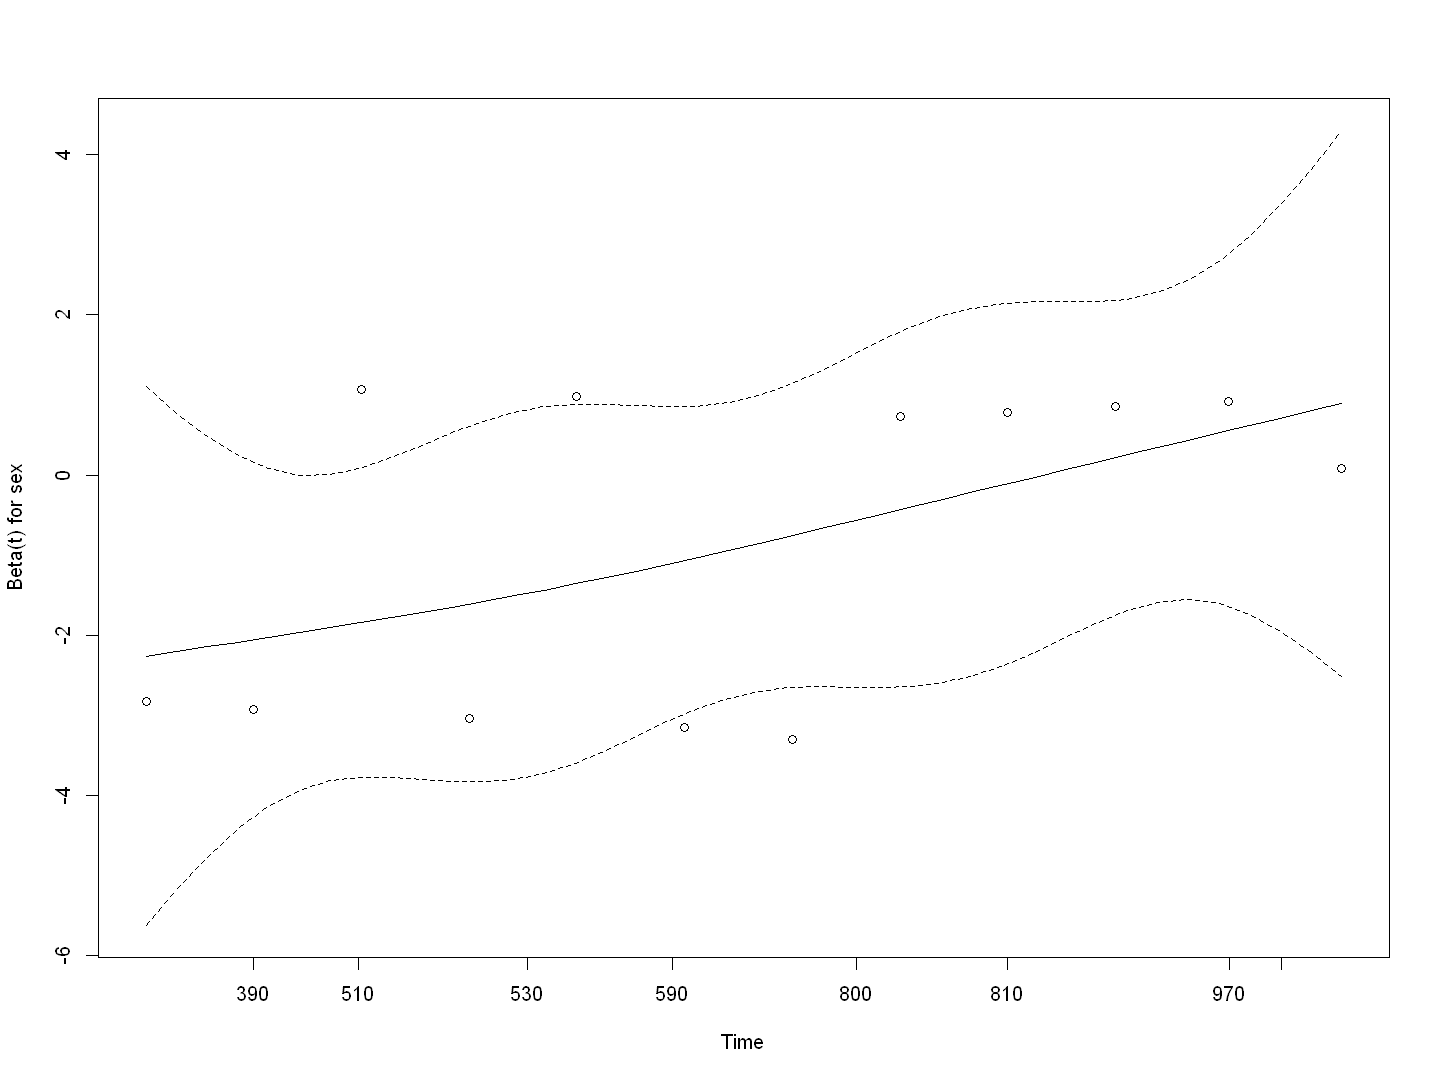

In [38]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [39]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + sex, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + sex):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + sex):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sex, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.2834    0.2771   0.6791 -1.890   0.0588 .
sexмуж. -0.8141    0.4430   0.5932 -1.372   0.1699  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2771      3.609   0.07321     1.049
sexмуж.    0.4430      2.257   0.13852     1.417

Concordance= 0.716  (se = 0.083 )
Likelihood ratio test= 6.12  on 2 df,   p=0.05
Wald test            = 5.51  on 2 df,   p=0.06
Score (logrank) test = 6.2  on 2 df,   p=0.05




Test of PH assumption:


       chisq df     p
group  0.114  1 0.735
sex    2.974  1 0.085
GLOBAL 3.051  2 0.218


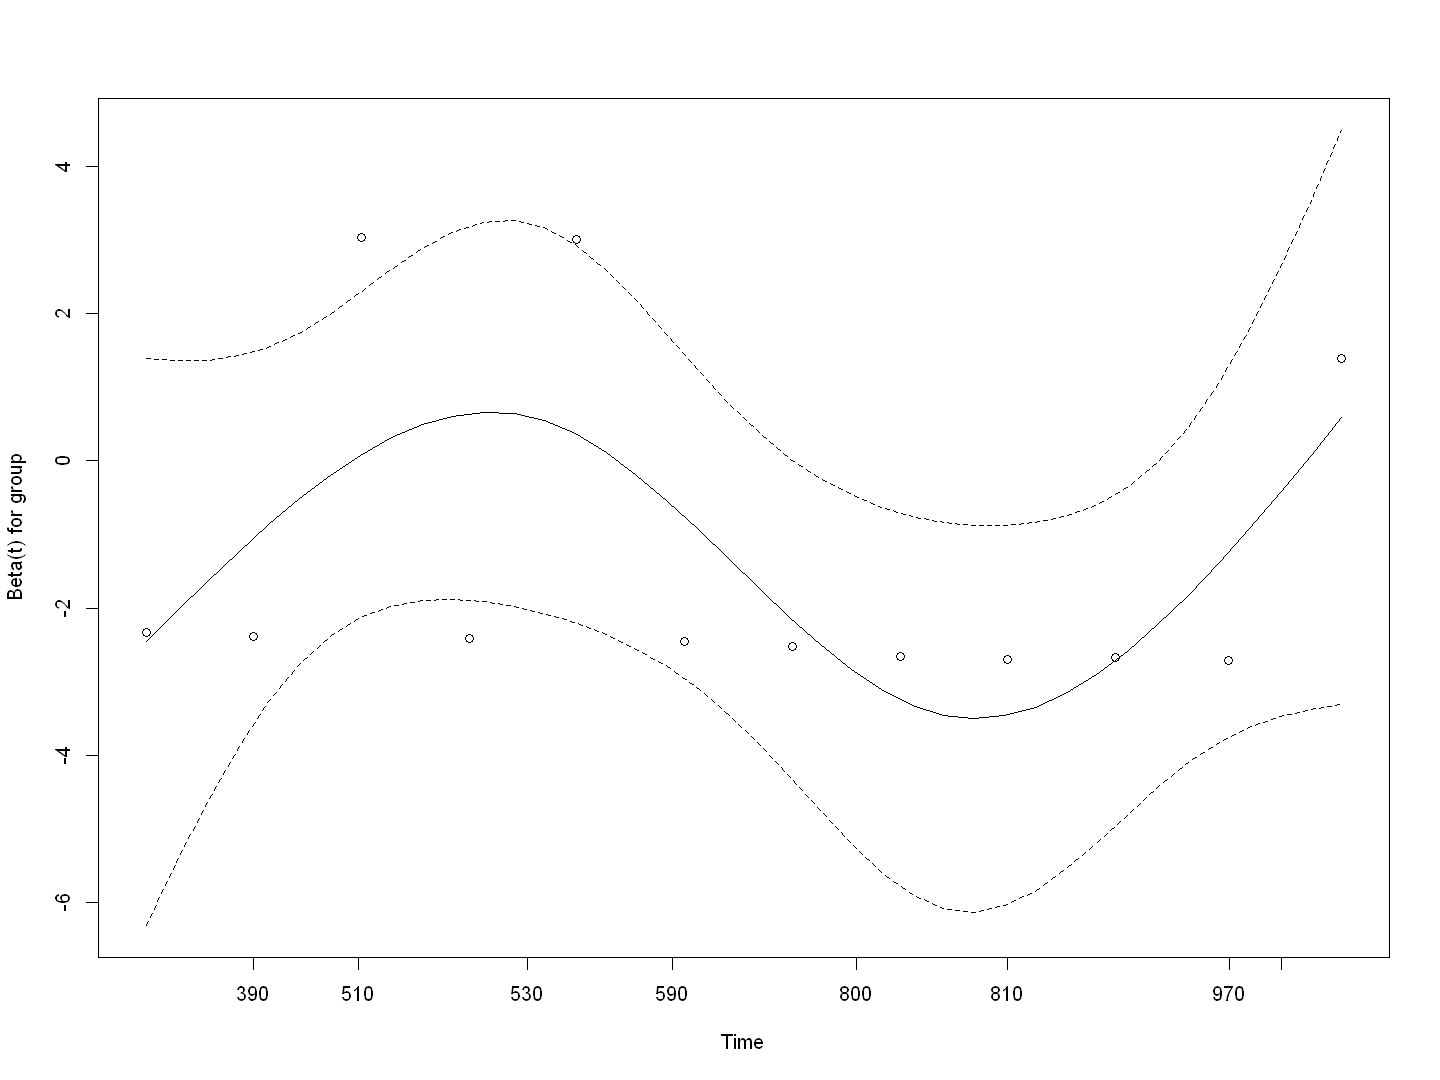

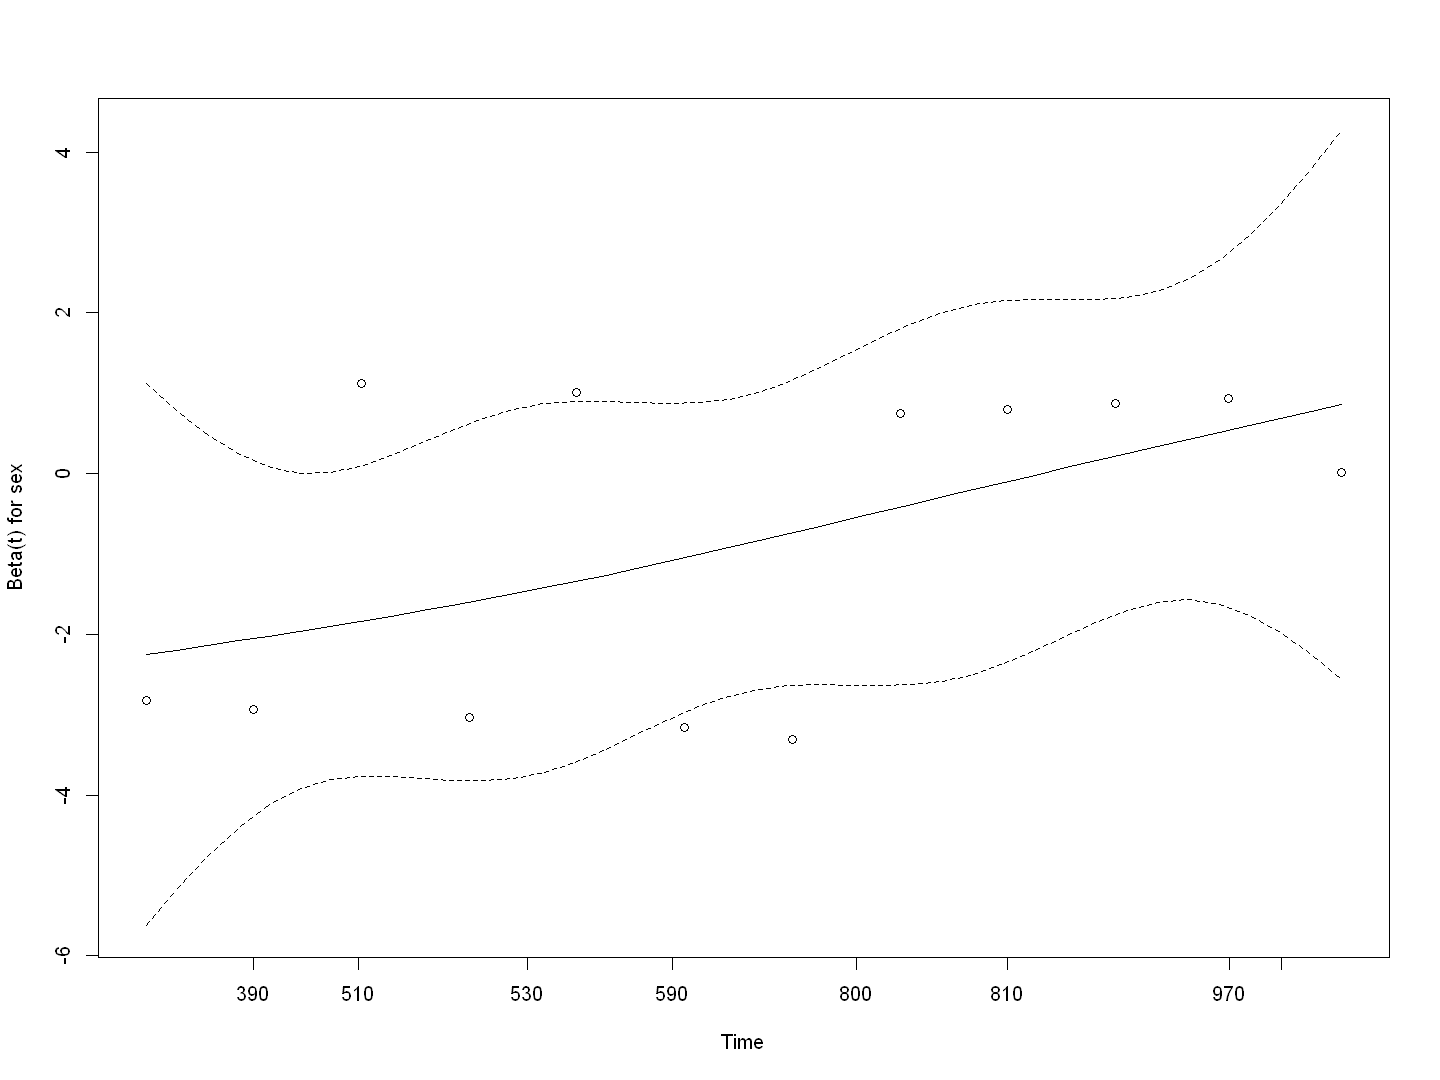

In [40]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + длительность заболевания


#### Все группы

In [41]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + ill_dur, data = first_reop_df)
cat("\nCox PH model summary (group + ill_dur):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + ill_dur):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + ill_dur, 
    data = first_reop_df)

  n= 50, number of events= 12 

             coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.19039   0.30410  0.83939 -1.418    0.156
groupОГ2 -1.57342   0.20733  1.05649 -1.489    0.136
ill_dur   0.01597   1.01609  0.04927  0.324    0.746

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3041     3.2884   0.05869     1.576
groupОГ2    0.2073     4.8231   0.02614     1.644
ill_dur     1.0161     0.9842   0.92256     1.119

Concordance= 0.688  (se = 0.085 )
Likelihood ratio test= 4.59  on 3 df,   p=0.2
Wald test            = 3.78  on 3 df,   p=0.3
Score (logrank) test = 4.38  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


        chisq df    p
group   1.131  2 0.57
ill_dur 0.668  1 0.41
GLOBAL  1.721  3 0.63


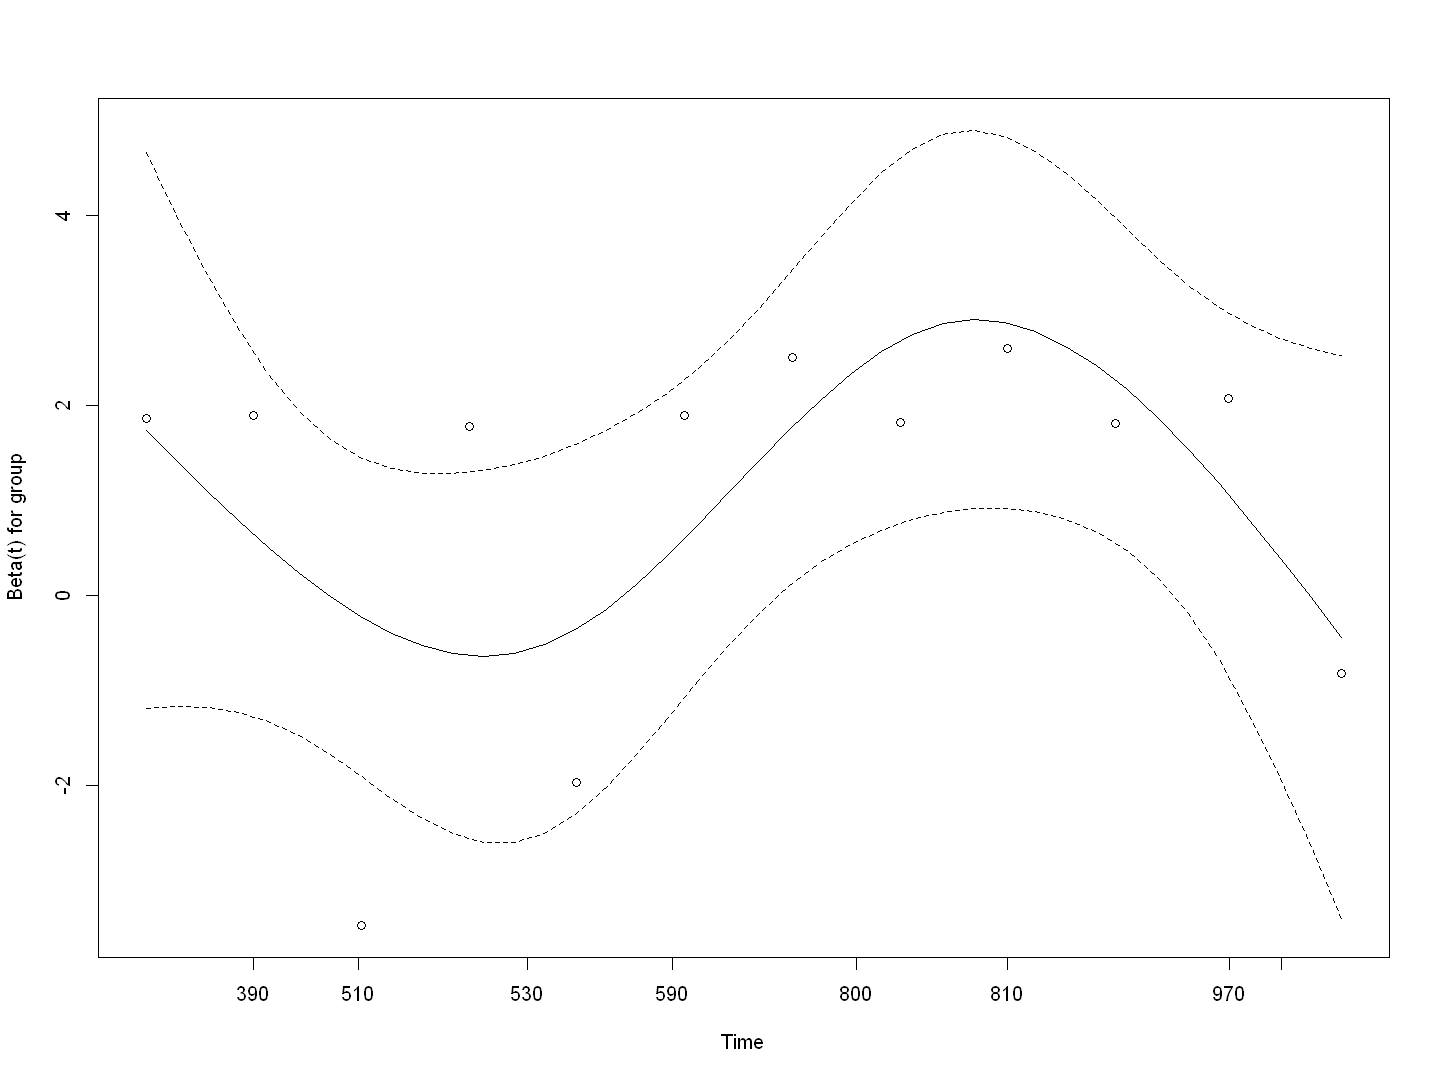

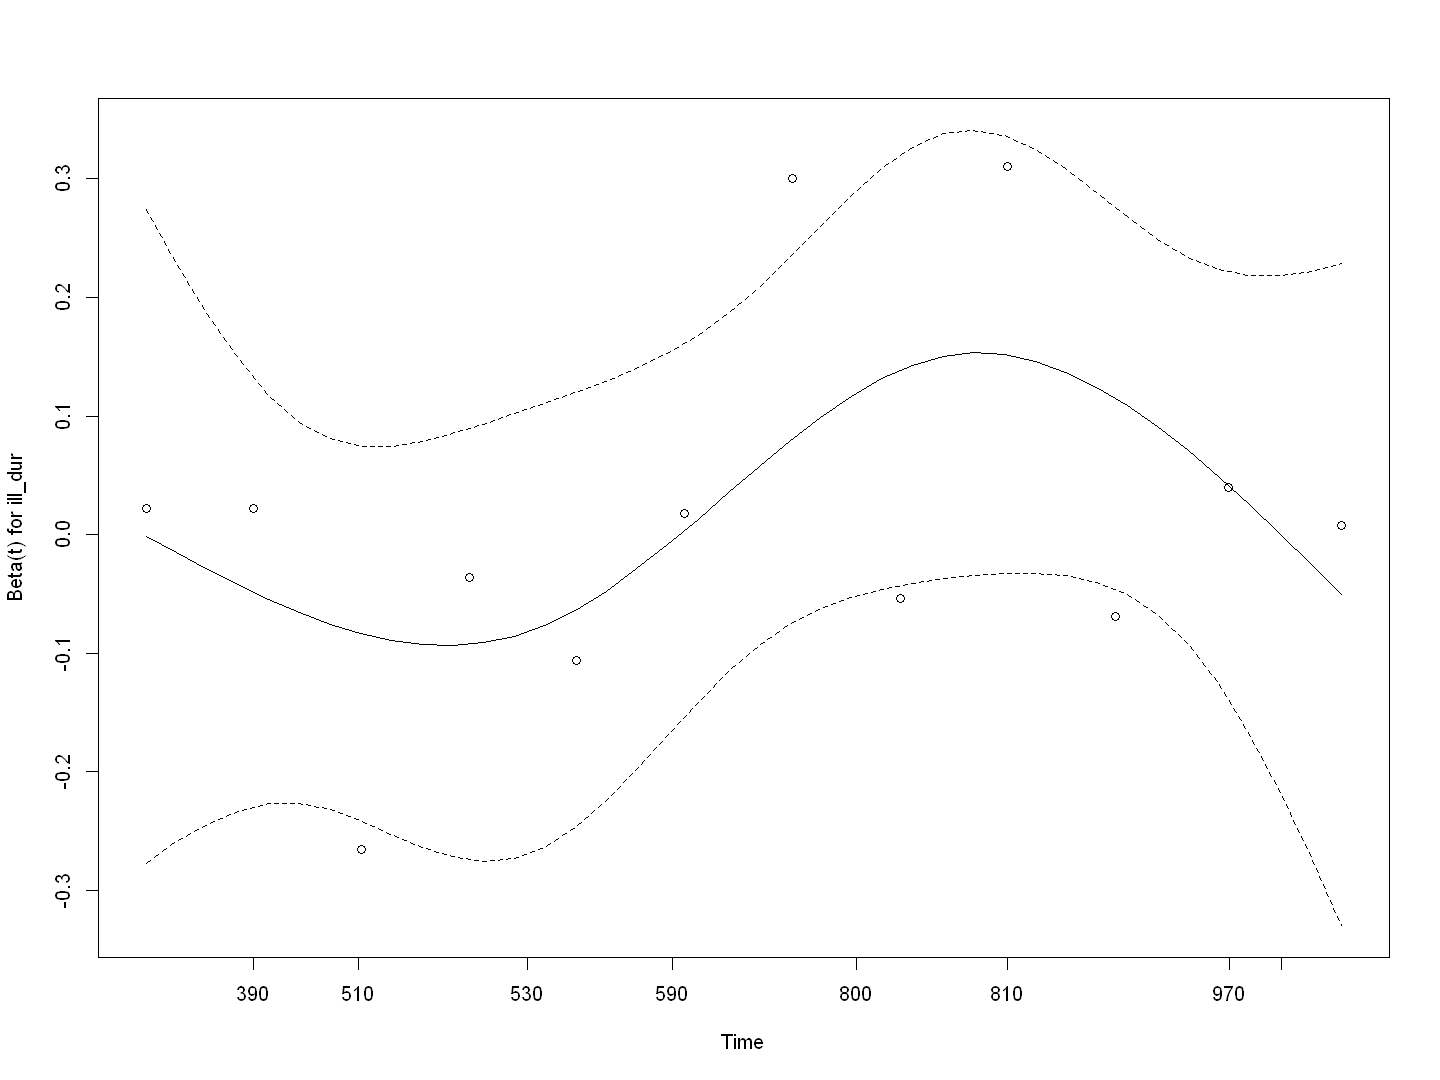

In [42]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [43]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + ill_dur, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + ill_dur):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + ill_dur):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + ill_dur, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.34858   0.25961  0.68835 -1.959   0.0501 .
ill_dur  0.01819   1.01836  0.04838  0.376   0.7069  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2596      3.852   0.06736     1.001
ill_dur    1.0184      0.982   0.92622     1.120

Concordance= 0.674  (se = 0.091 )
Likelihood ratio test= 4.5  on 2 df,   p=0.1
Wald test            = 3.84  on 2 df,   p=0.1
Score (logrank) test = 4.36  on 2 df,   p=0.1




Test of PH assumption:


         chisq df    p
group   0.0515  1 0.82
ill_dur 0.6986  1 0.40
GLOBAL  0.9160  2 0.63


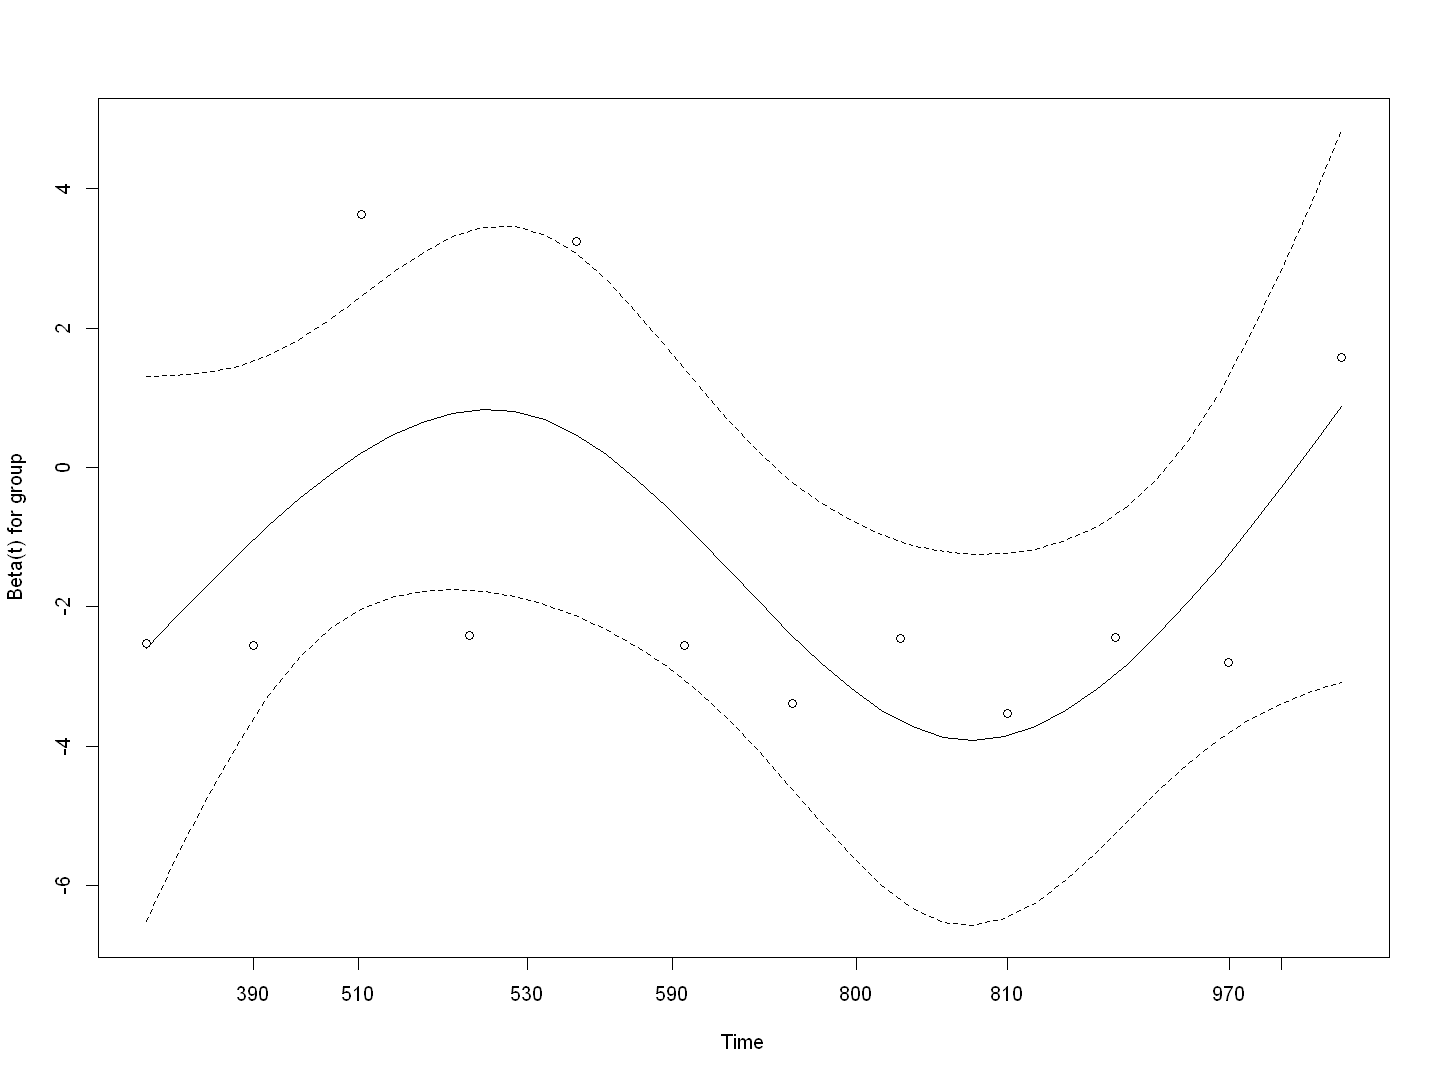

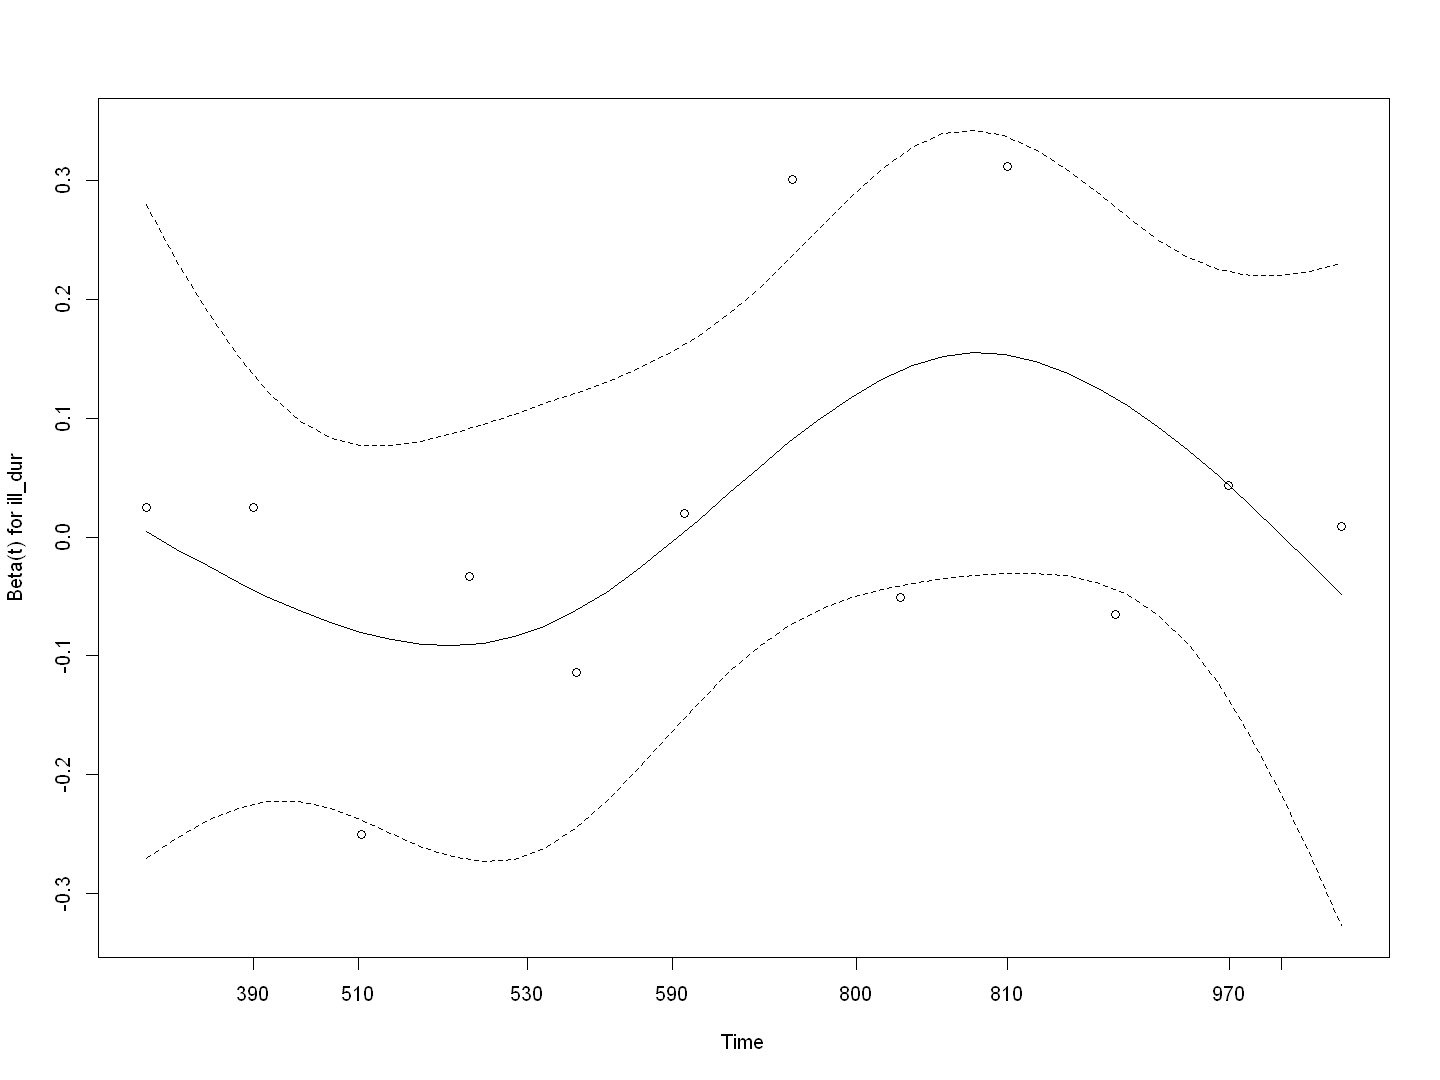

In [44]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + удаление полипов в анамнезе (polyps)


#### Все группы

In [45]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + polyps, data = first_reop_df)
cat("\nCox PH model summary (group + polyps):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + polyps):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + polyps, 
    data = first_reop_df)

  n= 50, number of events= 12 

             coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.11485   0.32796  0.81687 -1.365    0.172
groupОГ2 -1.52915   0.21672  1.05792 -1.445    0.148
polyps    0.09211   1.09648  0.12749  0.722    0.470

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3280      3.049   0.06615     1.626
groupОГ2    0.2167      4.614   0.02725     1.723
polyps      1.0965      0.912   0.85404     1.408

Concordance= 0.698  (se = 0.074 )
Likelihood ratio test= 4.96  on 3 df,   p=0.2
Wald test            = 4.26  on 3 df,   p=0.2
Score (logrank) test = 4.92  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group  1.119  2 0.57
polyps 0.179  1 0.67
GLOBAL 1.239  3 0.74


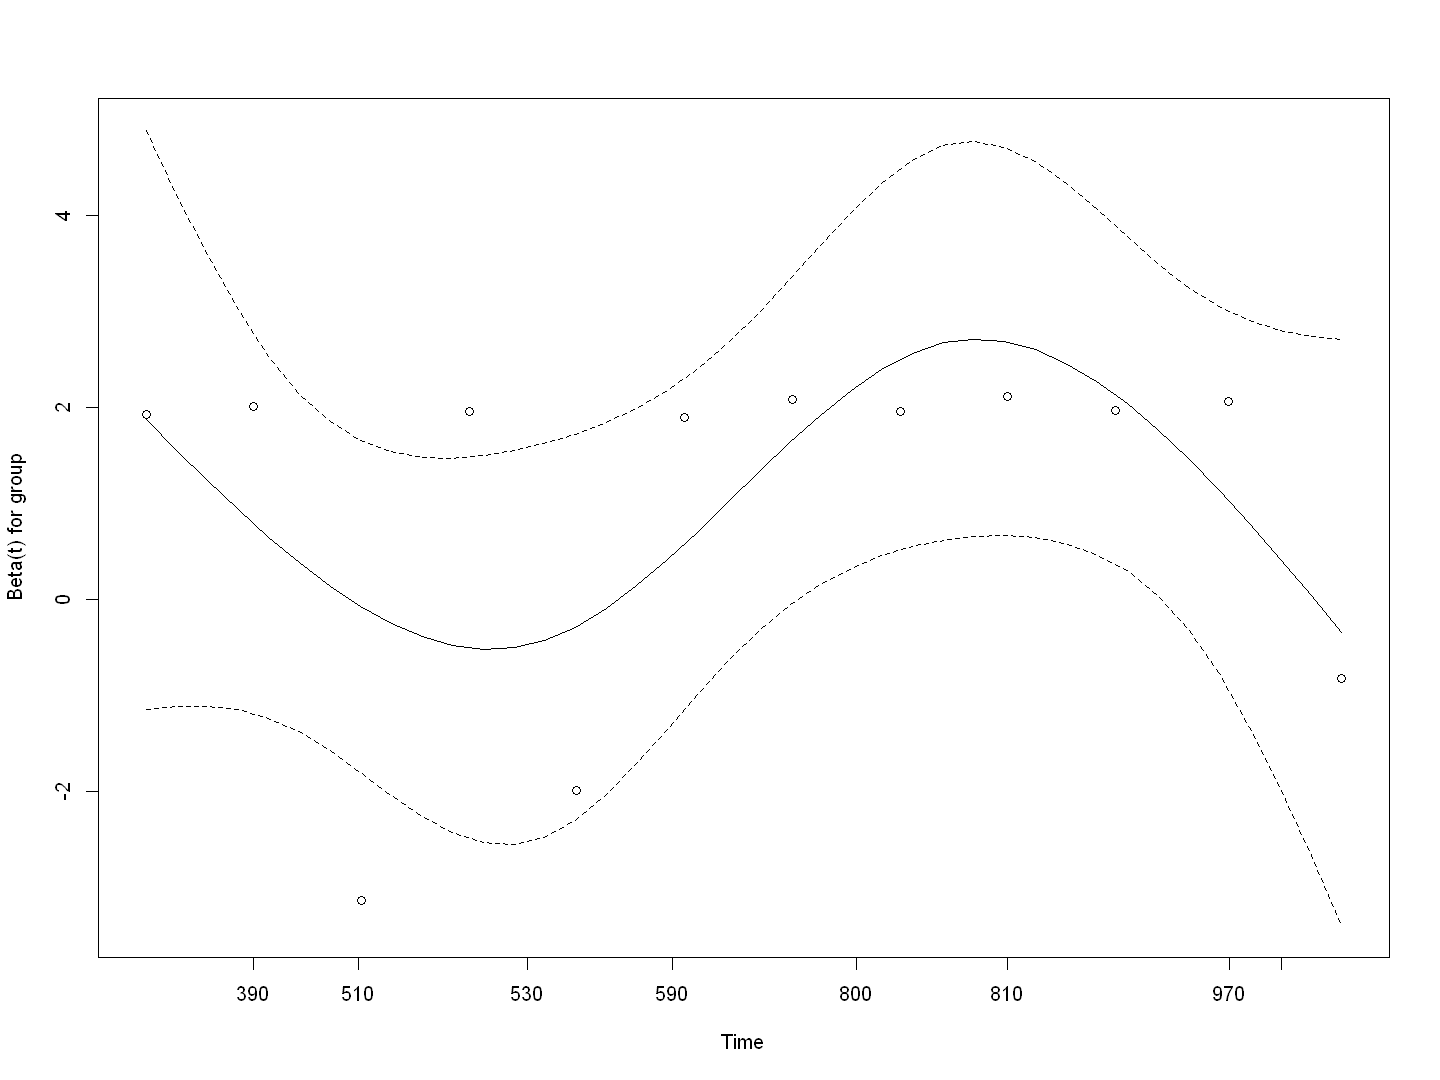

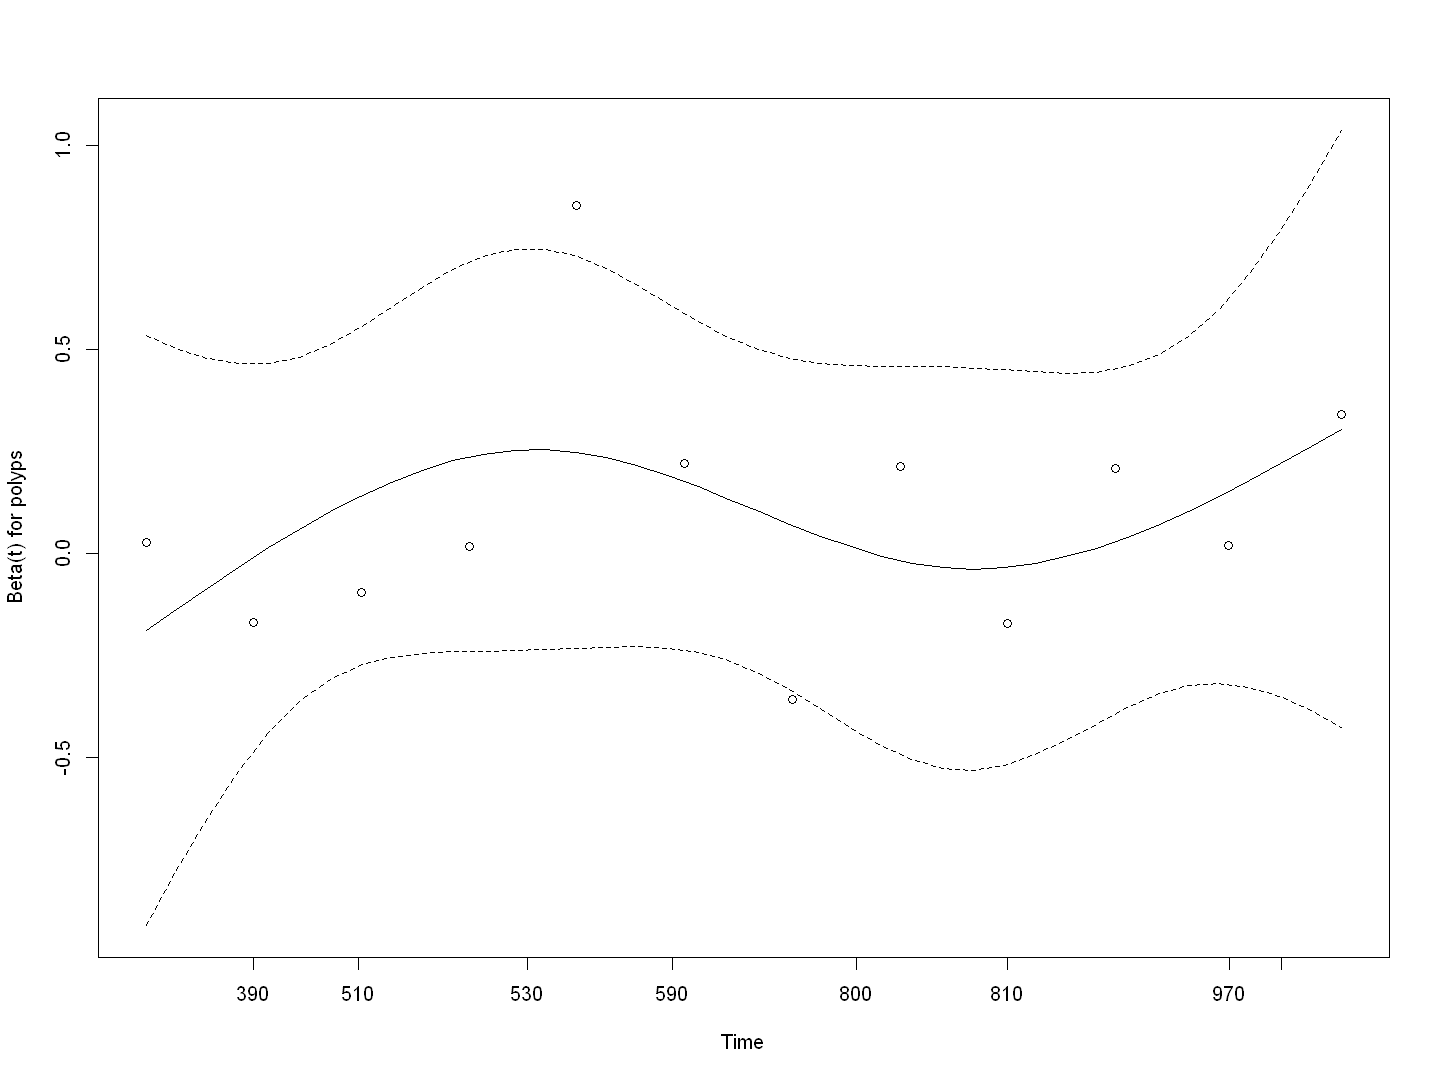

In [46]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [47]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + polyps, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + polyps):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + polyps):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + polyps, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.28165   0.27758  0.67780 -1.891   0.0586 .
polyps   0.09361   1.09813  0.12713  0.736   0.4616  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2776     3.6026   0.07353     1.048
polyps     1.0981     0.9106   0.85593     1.409

Concordance= 0.704  (se = 0.07 )
Likelihood ratio test= 4.85  on 2 df,   p=0.09
Wald test            = 4.31  on 2 df,   p=0.1
Score (logrank) test = 4.89  on 2 df,   p=0.09




Test of PH assumption:


        chisq df    p
group  0.0516  1 0.82
polyps 0.1863  1 0.67
GLOBAL 0.2404  2 0.89


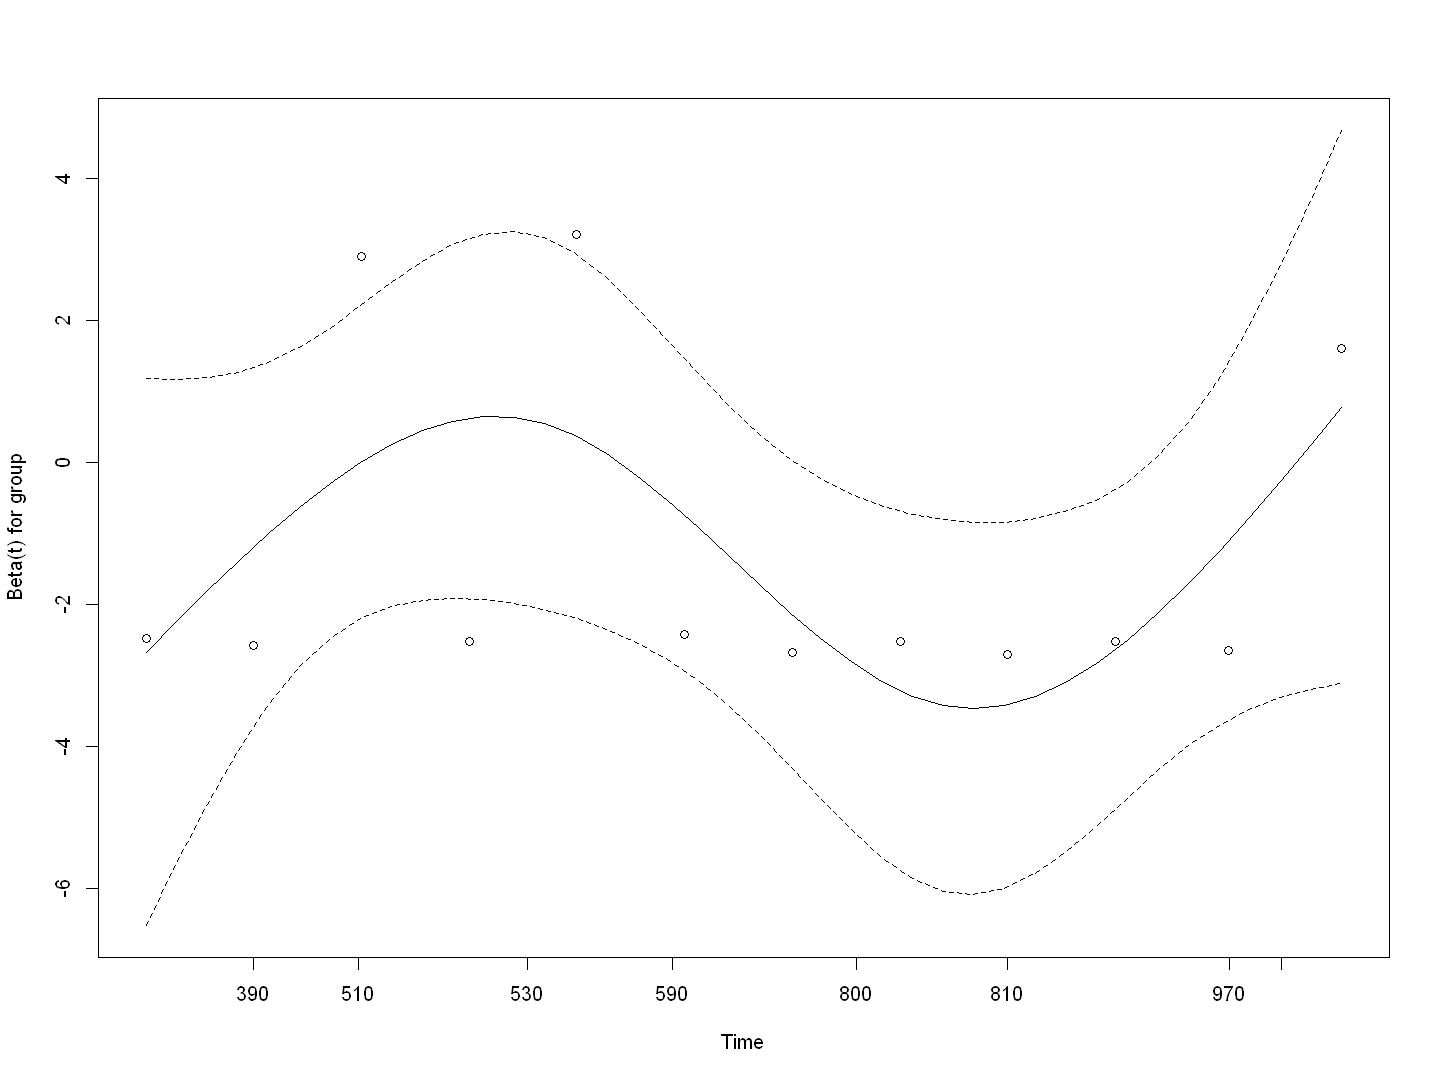

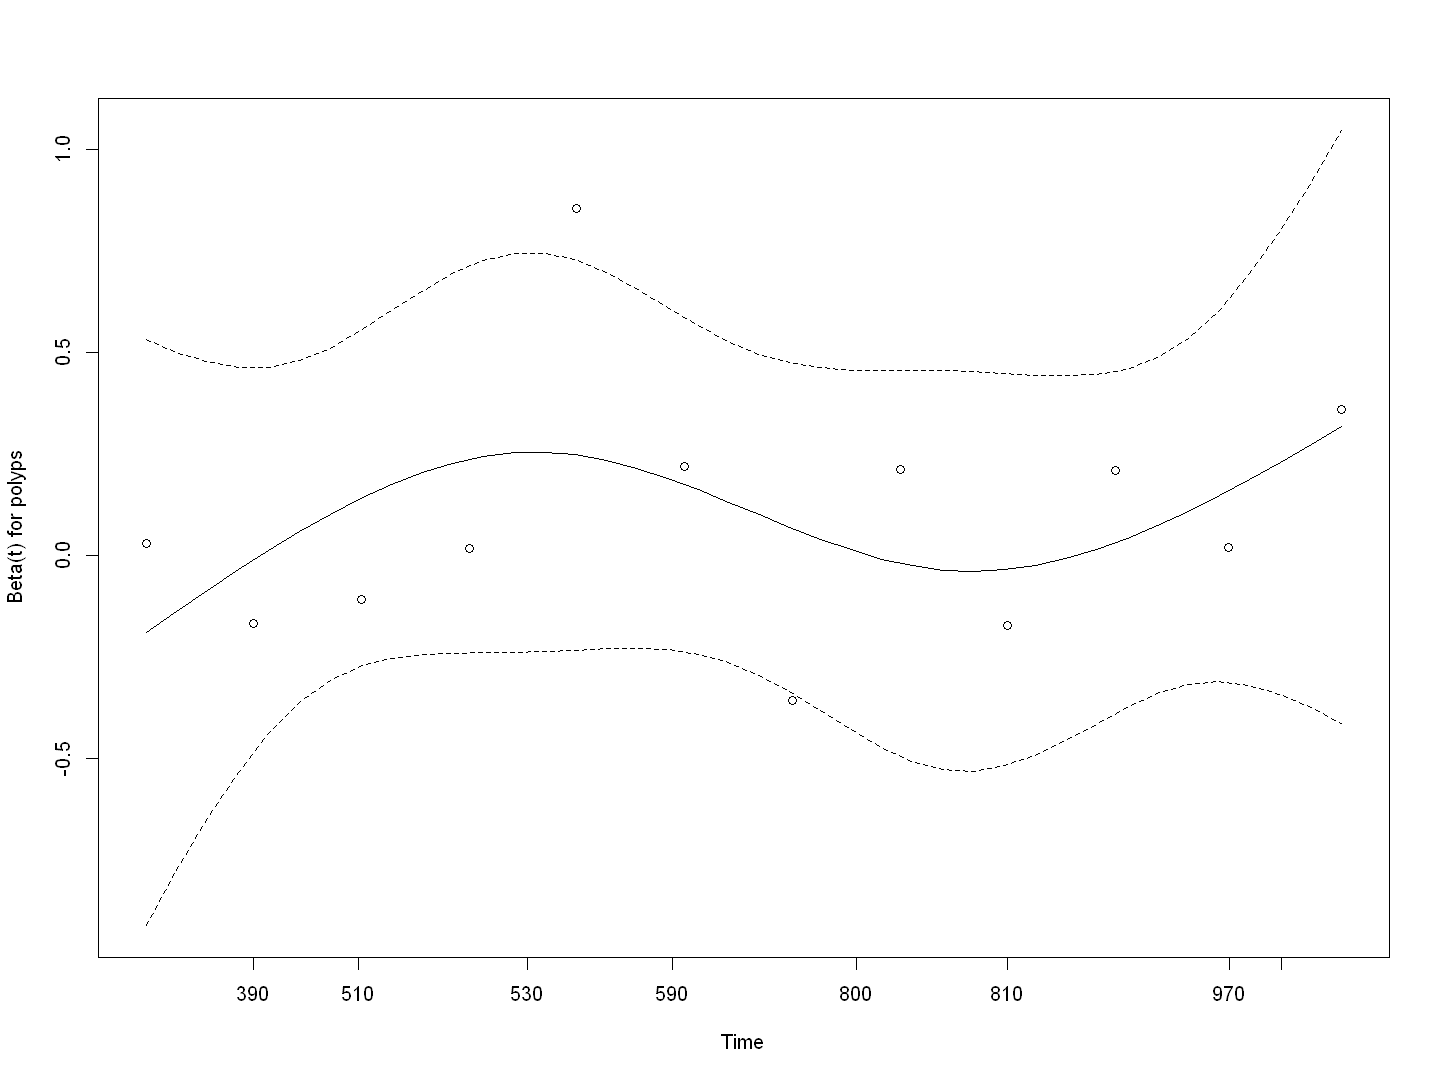

In [48]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + аллергия.домашняя пыль


#### Все группы

In [49]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + allergy_dust, data = first_reop_df)
cat("\nCox PH model summary (group + allergy_dust):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + allergy_dust):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_dust, 
    data = first_reop_df)

  n= 50, number of events= 12 

                   coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1        -1.0629    0.3455   0.8176 -1.300    0.194
groupОГ2        -1.5184    0.2191   1.0587 -1.434    0.152
allergy_dustнет -0.5620    0.5700   0.7899 -0.712    0.477

                exp(coef) exp(-coef) lower .95 upper .95
groupОГ1           0.3455      2.895   0.06957     1.715
groupОГ2           0.2191      4.565   0.02751     1.745
allergy_dustнет    0.5700      1.754   0.12121     2.681

Concordance= 0.667  (se = 0.068 )
Likelihood ratio test= 4.94  on 3 df,   p=0.2
Wald test            = 4.25  on 3 df,   p=0.2
Score (logrank) test = 4.92  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


             chisq df    p
group        1.121  2 0.57
allergy_dust 0.354  1 0.55
GLOBAL       1.419  3 0.70


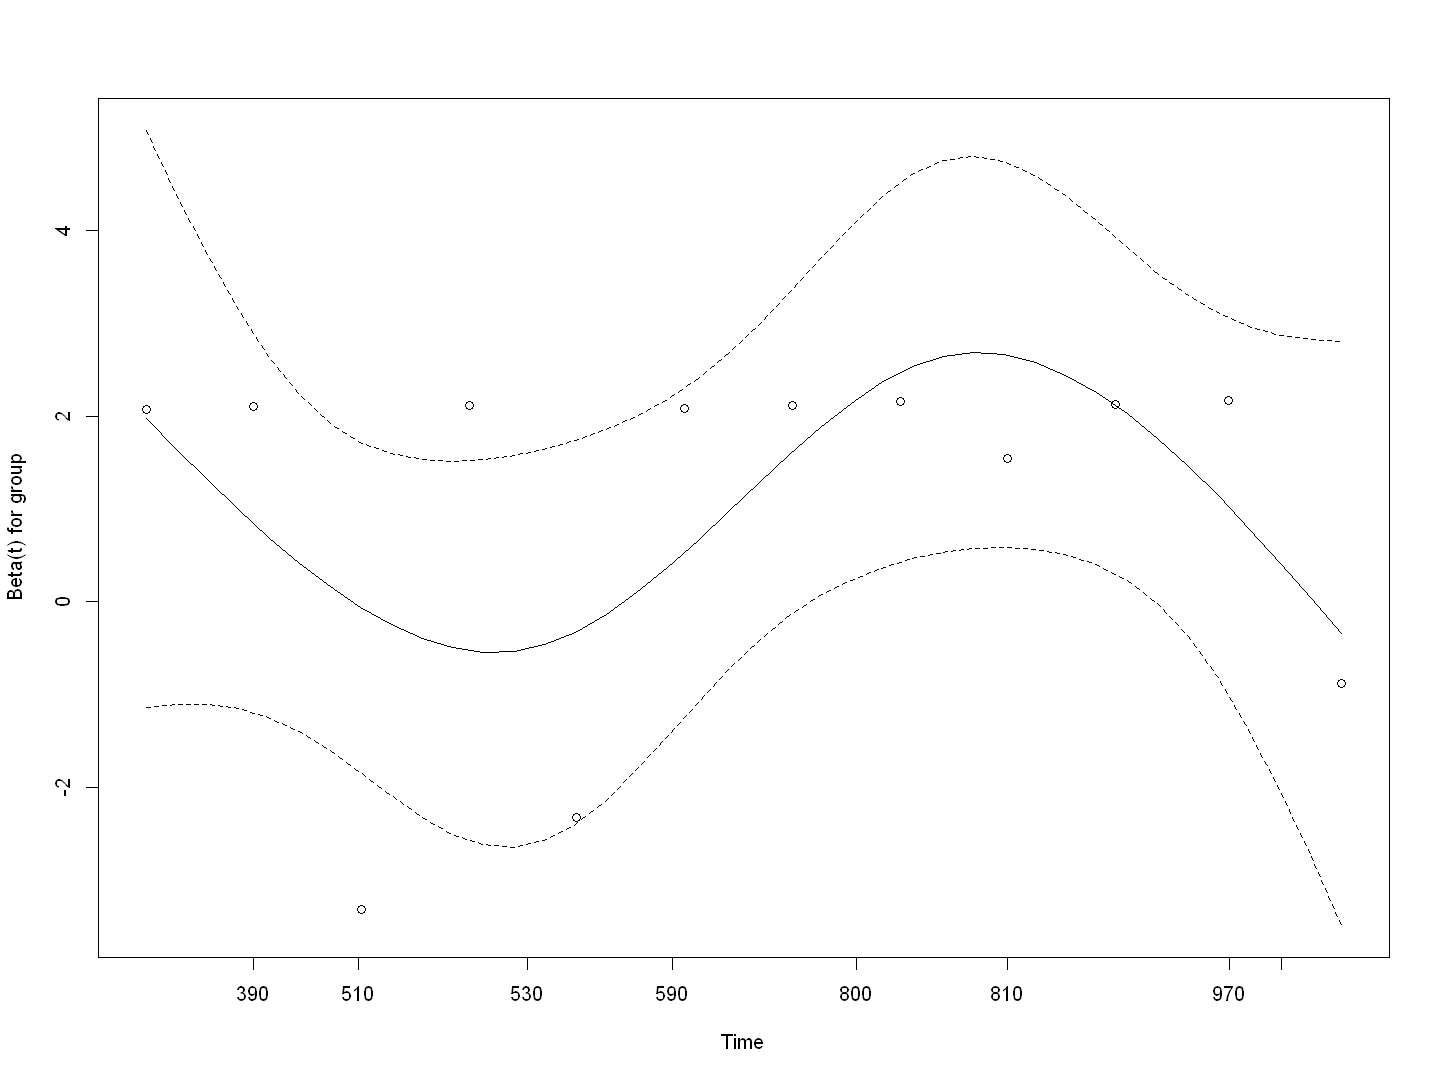

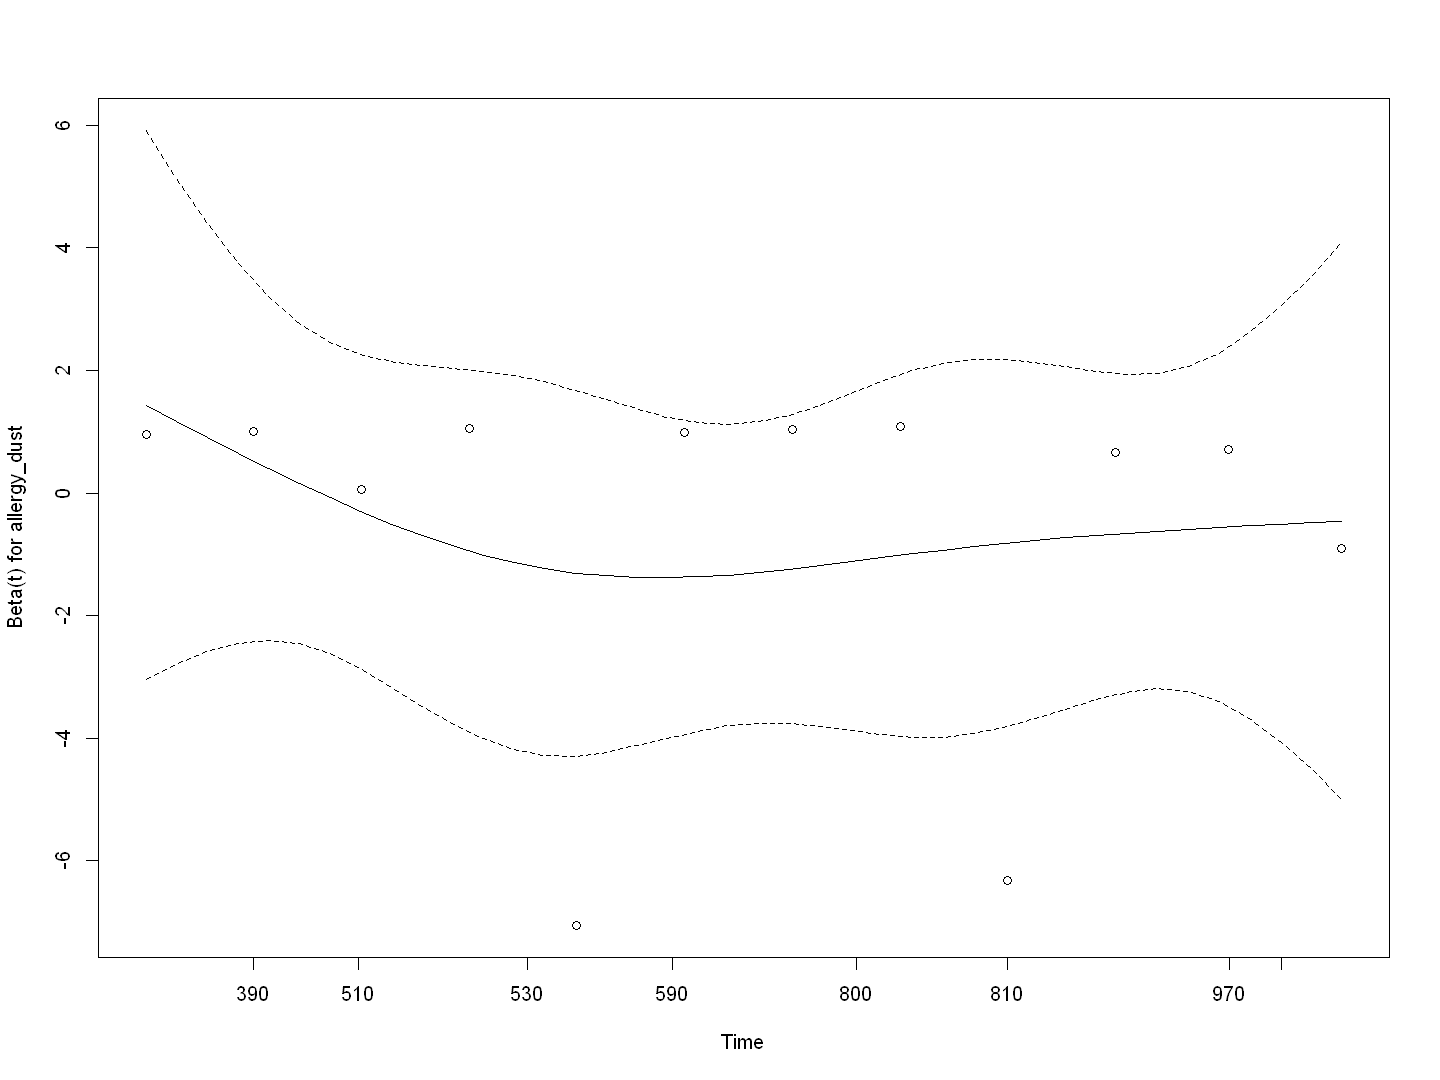

In [50]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [51]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + allergy_dust, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + allergy_dust):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + allergy_dust):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_dust, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                   coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ         -1.2480    0.2871   0.6798 -1.836   0.0664 .
allergy_dustнет -0.5573    0.5728   0.7893 -0.706   0.4802  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                exp(coef) exp(-coef) lower .95 upper .95
groupОГ            0.2871      3.483   0.07575     1.088
allergy_dustнет    0.5728      1.746   0.12192     2.691

Concordance= 0.677  (se = 0.061 )
Likelihood ratio test= 4.8  on 2 df,   p=0.09
Wald test            = 4.27  on 2 df,   p=0.1
Score (logrank) test = 4.86  on 2 df,   p=0.09




Test of PH assumption:


              chisq df    p
group        0.0337  1 0.85
allergy_dust 0.3484  1 0.56
GLOBAL       0.3627  2 0.83


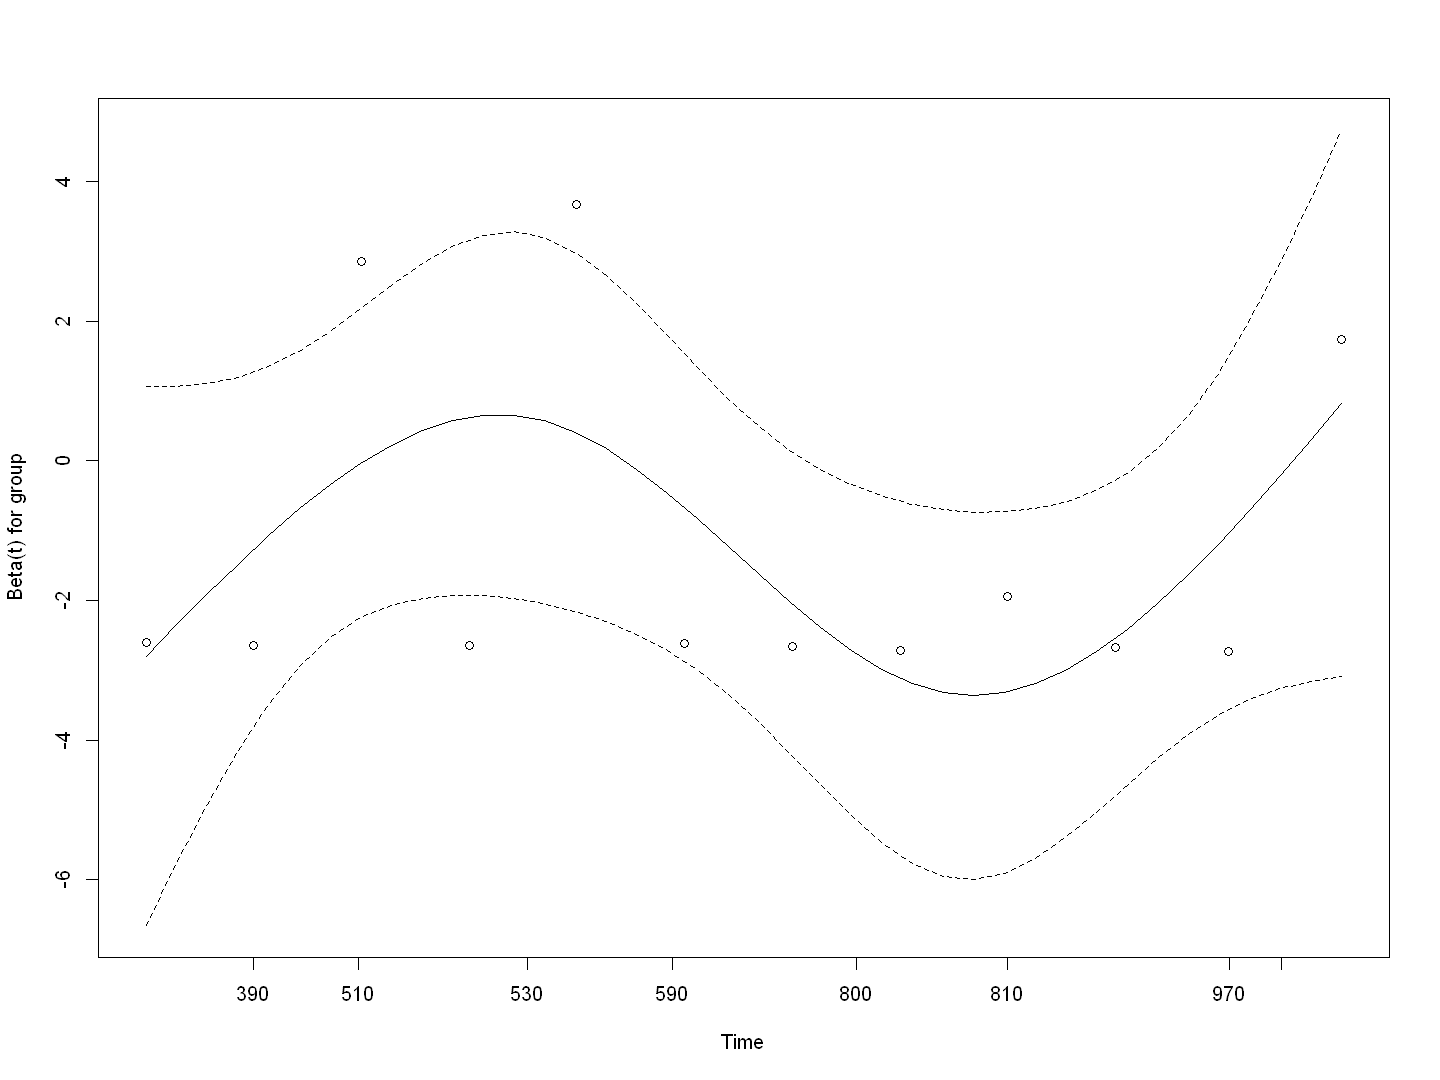

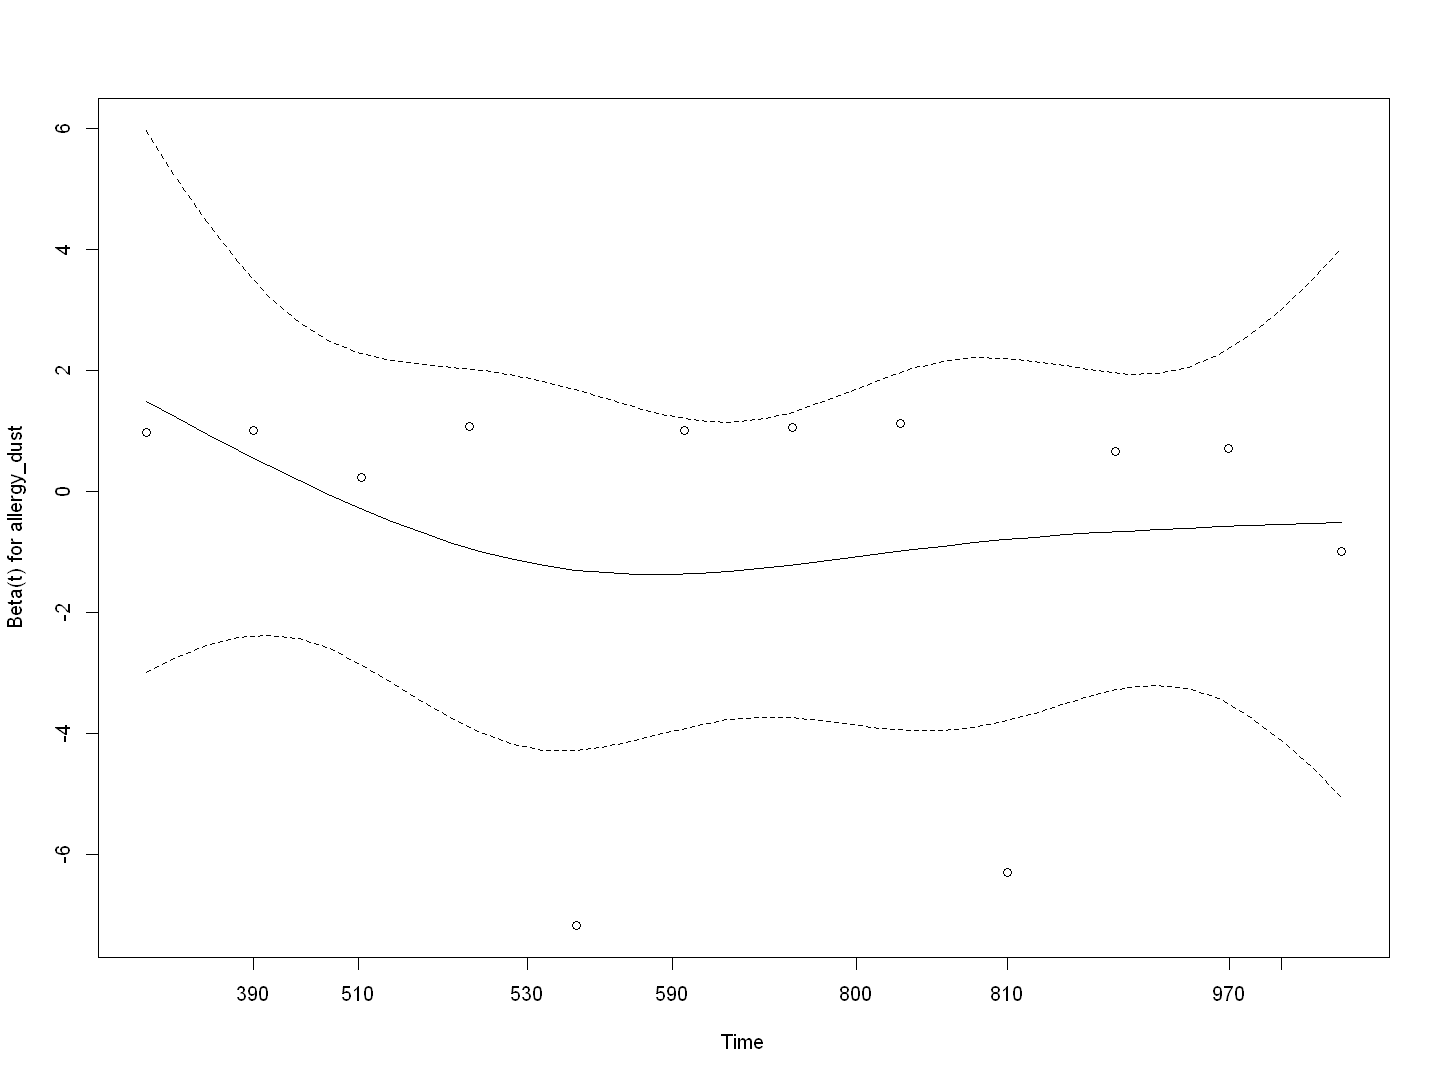

In [52]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + аллергия.растения


#### Все группы

In [53]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + allergy_plants, data = first_reop_df)
cat("\nCox PH model summary (group + allergy_plants):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + allergy_plants):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_plants, 
    data = first_reop_df)

  n= 50, number of events= 12 

                     coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1          -1.2233    0.2943   0.8198 -1.492    0.136
groupОГ2          -1.6940    0.1838   1.0715 -1.581    0.114
allergy_plantsнет -0.4866    0.6147   0.6330 -0.769    0.442

                  exp(coef) exp(-coef) lower .95 upper .95
groupОГ1             0.2943      3.398   0.05901     1.467
groupОГ2             0.1838      5.441   0.02250     1.501
allergy_plantsнет    0.6147      1.627   0.17777     2.126

Concordance= 0.683  (se = 0.059 )
Likelihood ratio test= 5.05  on 3 df,   p=0.2
Wald test            = 4.24  on 3 df,   p=0.2
Score (logrank) test = 4.8  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


                chisq df    p
group          1.1251  2 0.57
allergy_plants 0.0314  1 0.86
GLOBAL         1.1996  3 0.75


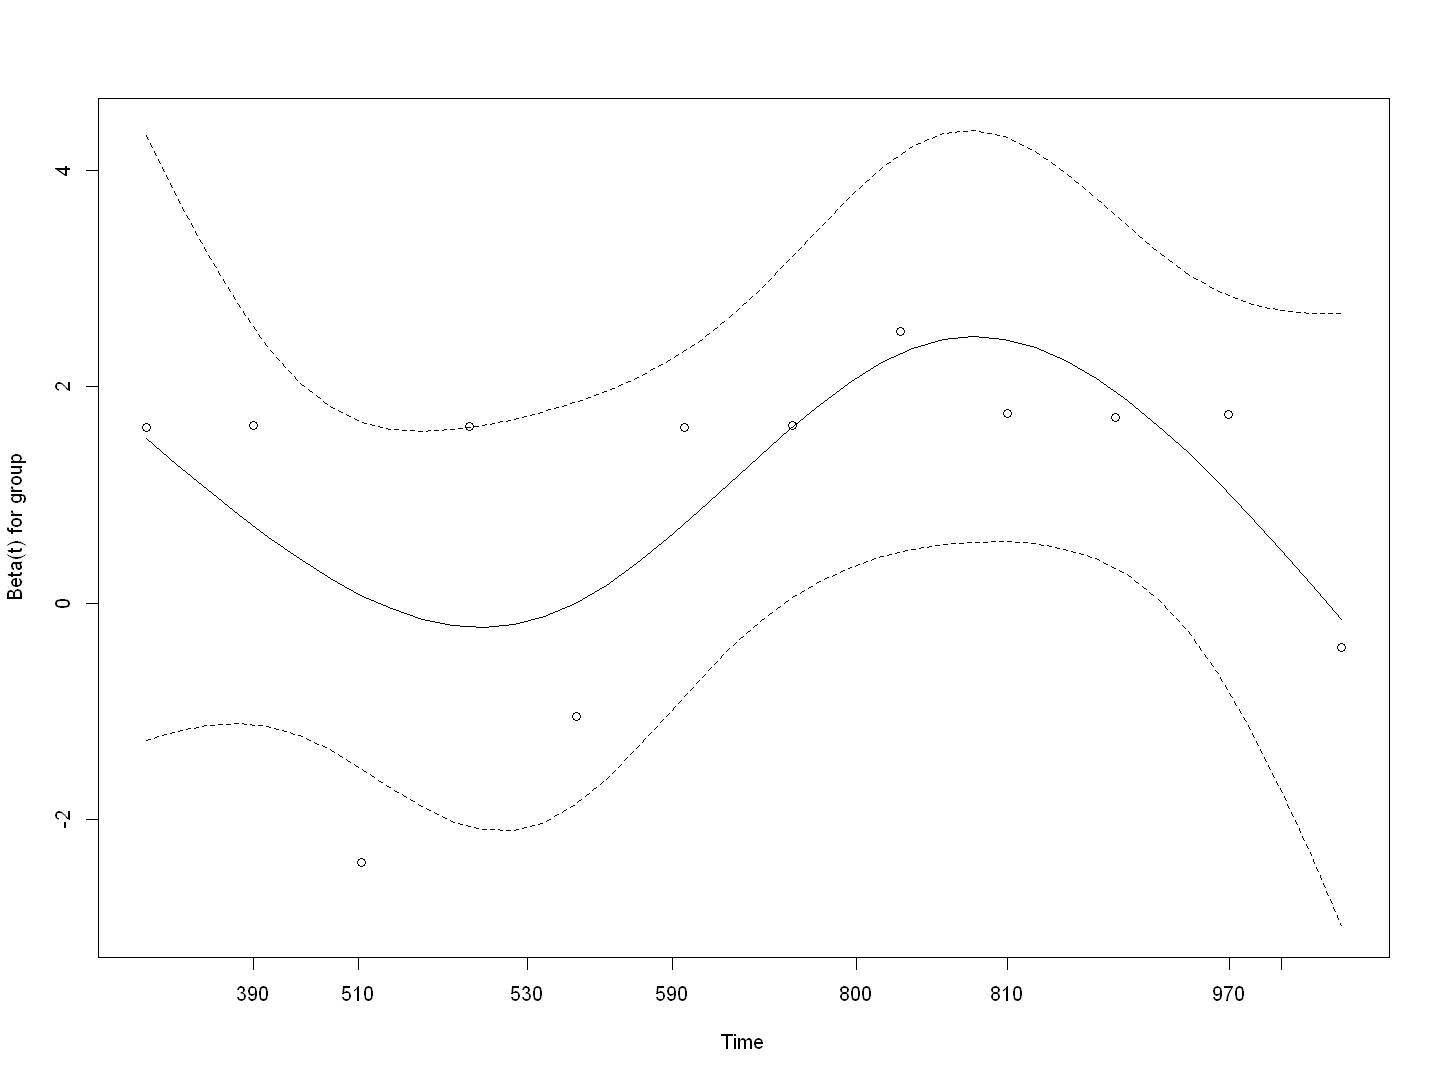

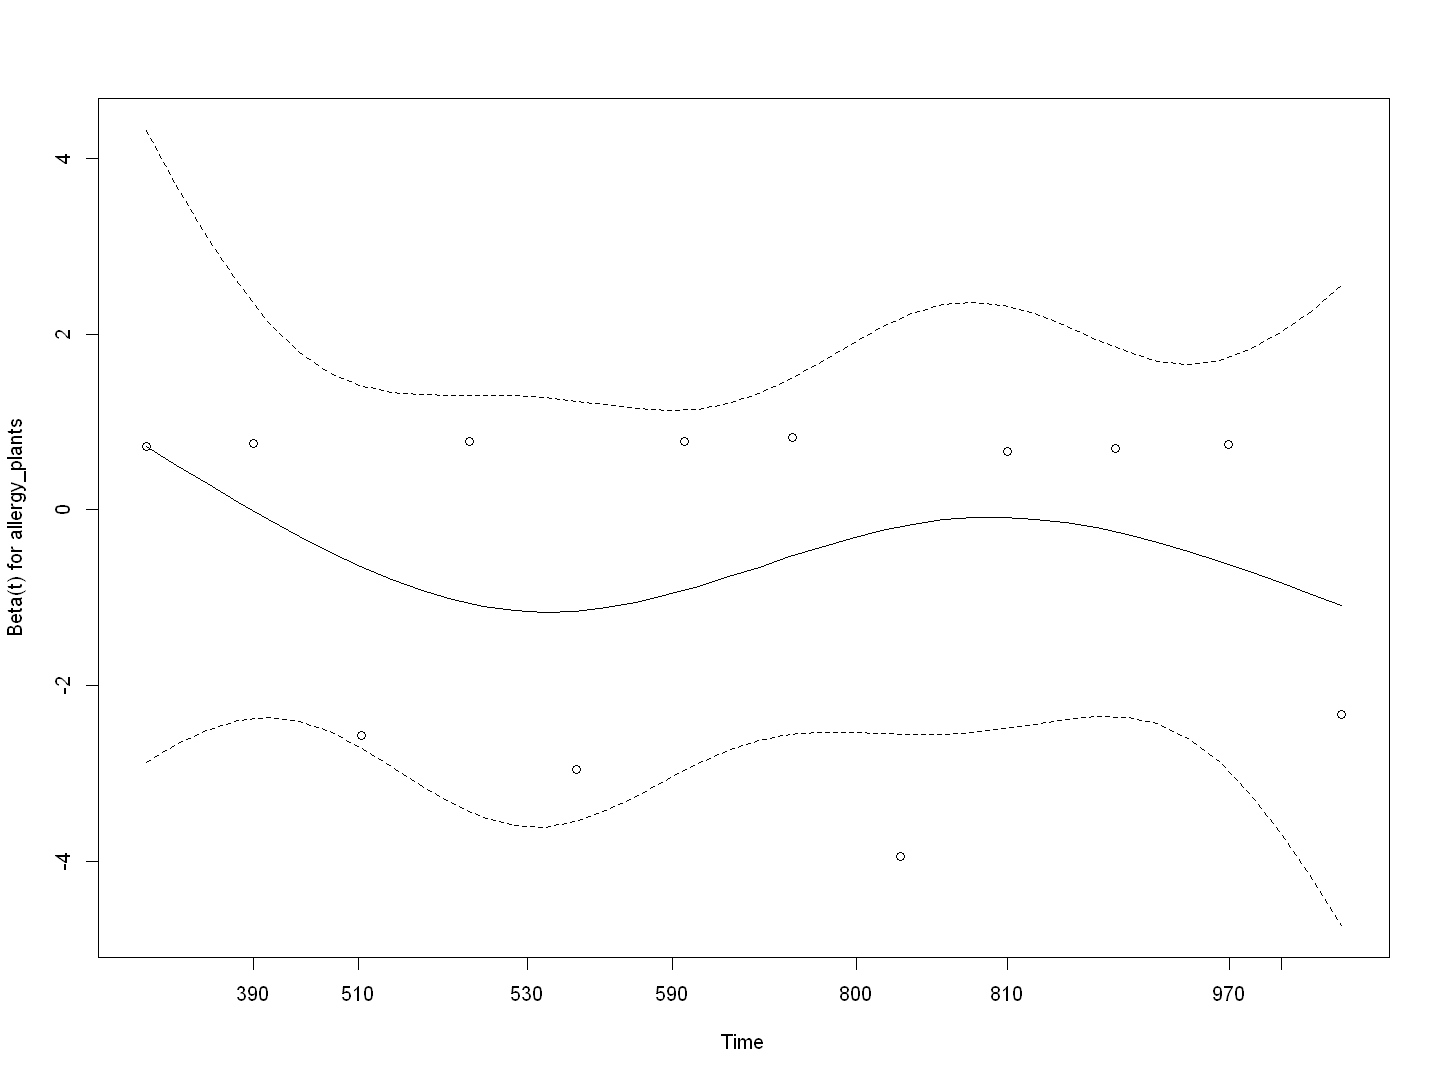

In [54]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [55]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + allergy_plants, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + allergy_plants):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + allergy_plants):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_plants, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                     coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ           -1.4114    0.2438   0.6913 -2.042   0.0412 *
allergy_plantsнет -0.4790    0.6194   0.6331 -0.757   0.4493  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                  exp(coef) exp(-coef) lower .95 upper .95
groupОГ              0.2438      4.102   0.06289     0.945
allergy_plantsнет    0.6194      1.614   0.17908     2.142

Concordance= 0.683  (se = 0.058 )
Likelihood ratio test= 4.9  on 2 df,   p=0.09
Wald test            = 4.25  on 2 df,   p=0.1
Score (logrank) test = 4.75  on 2 df,   p=0.09




Test of PH assumption:


                chisq df    p
group          0.0267  1 0.87
allergy_plants 0.0346  1 0.85
GLOBAL         0.0793  2 0.96


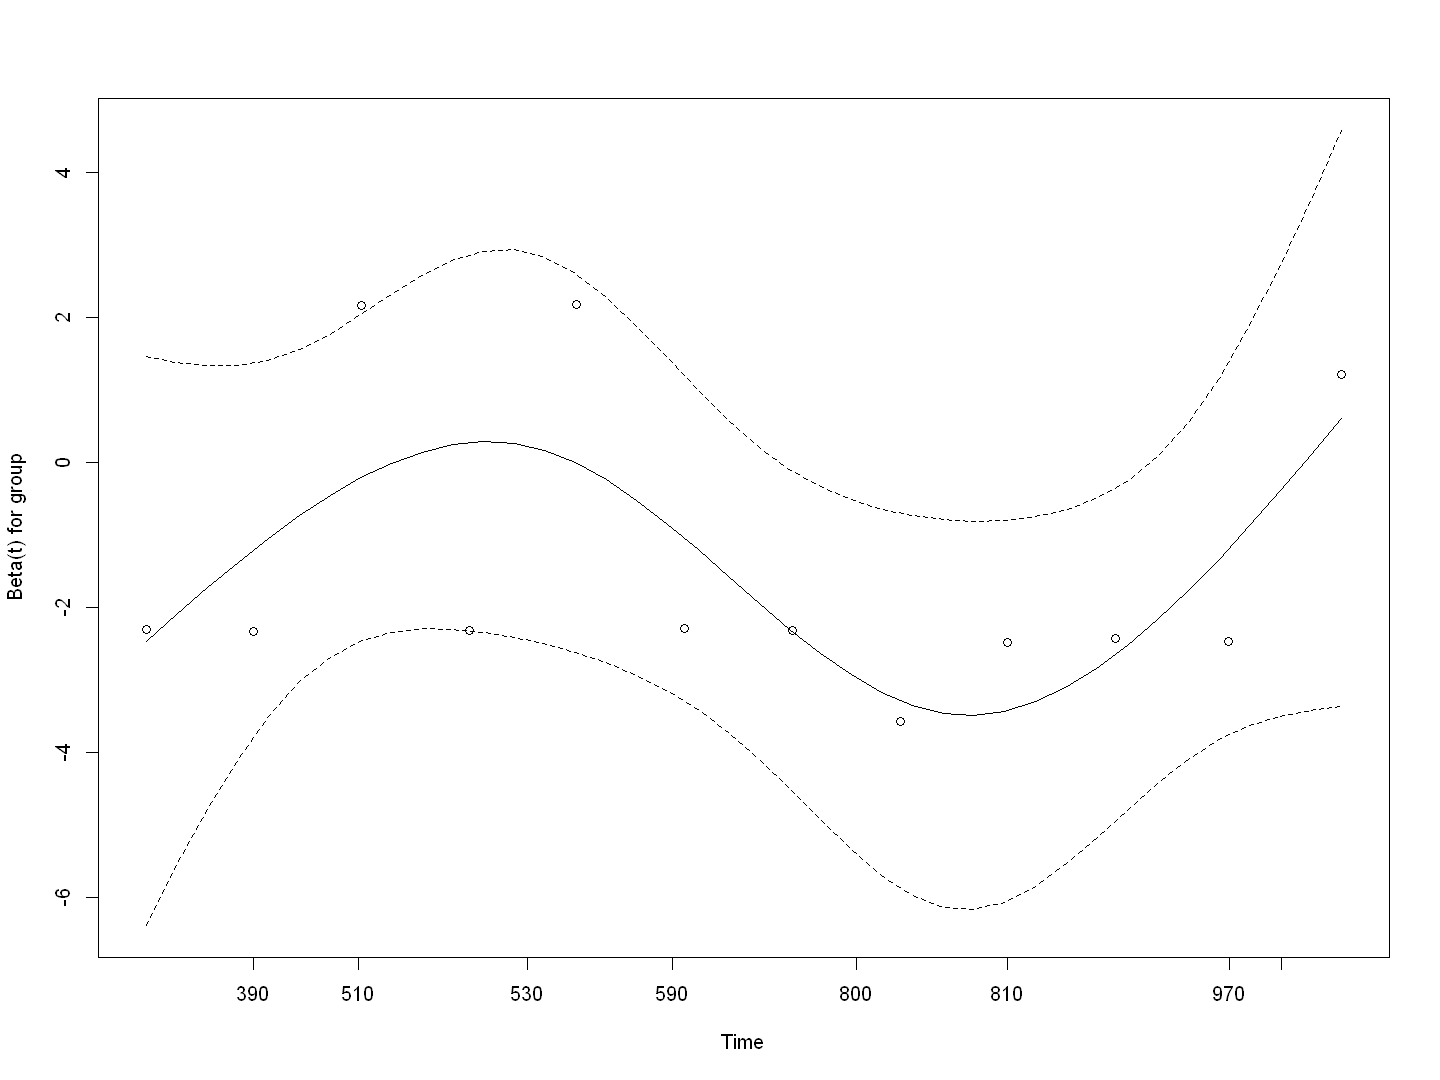

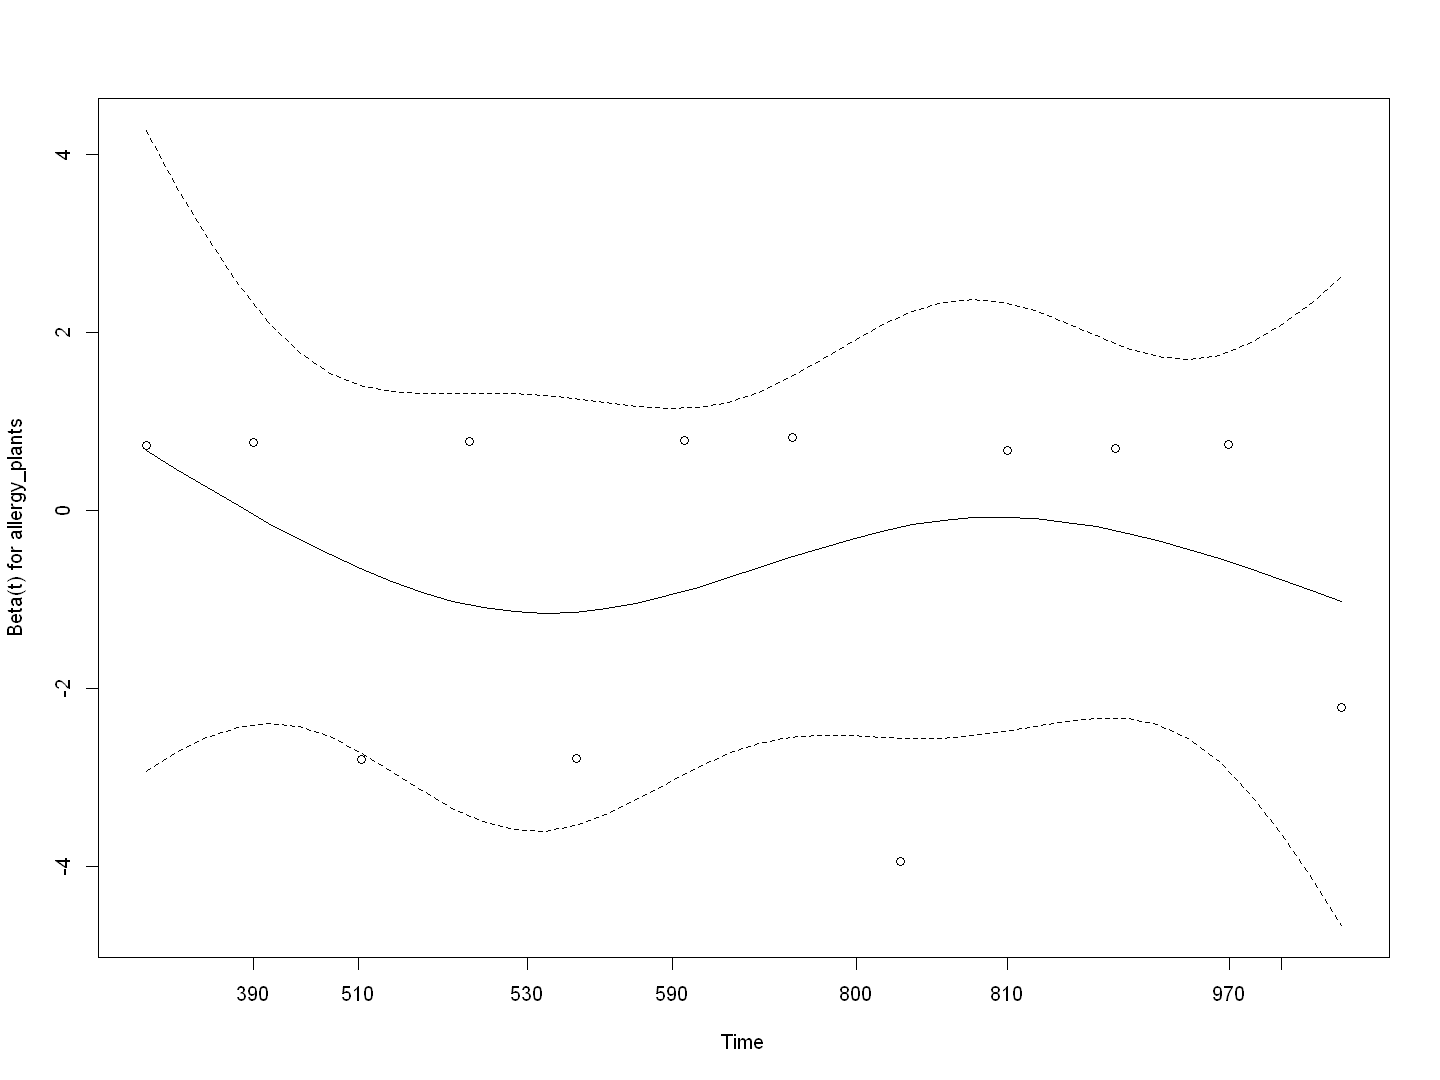

In [56]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + аллергия.животные


#### Все группы

In [57]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + allergy_animals, data = first_reop_df)
cat("\nCox PH model summary (group + allergy_animals):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + allergy_animals):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_animals, 
    data = first_reop_df)

  n= 50, number of events= 12 

                      coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1           -1.3965    0.2475   0.8601 -1.624    0.104
groupОГ2           -1.4757    0.2286   1.0610 -1.391    0.164
allergy_animalsнет -1.0923    0.3354   0.8279 -1.319    0.187

                   exp(coef) exp(-coef) lower .95 upper .95
groupОГ1              0.2475      4.041   0.04586     1.335
groupОГ2              0.2286      4.374   0.02858     1.829
allergy_animalsнет    0.3354      2.981   0.06621     1.700

Concordance= 0.67  (se = 0.068 )
Likelihood ratio test= 5.91  on 3 df,   p=0.1
Wald test            = 5.28  on 3 df,   p=0.2
Score (logrank) test = 5.9  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


                chisq df    p
group           1.140  2 0.57
allergy_animals 0.573  1 0.45
GLOBAL          1.462  3 0.69


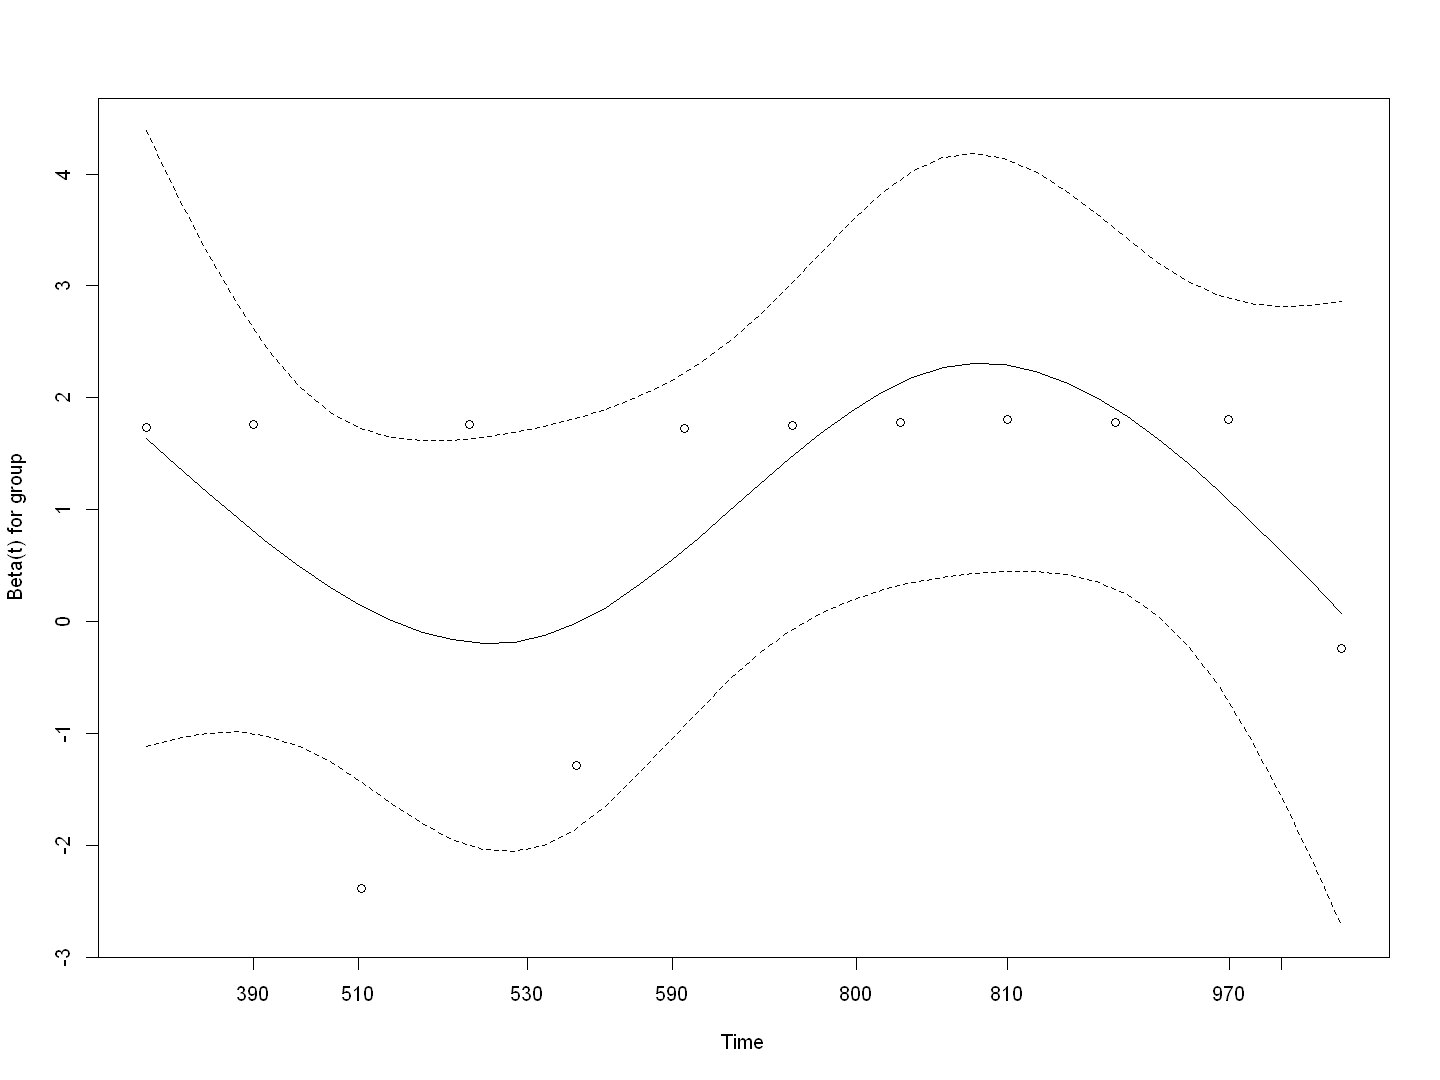

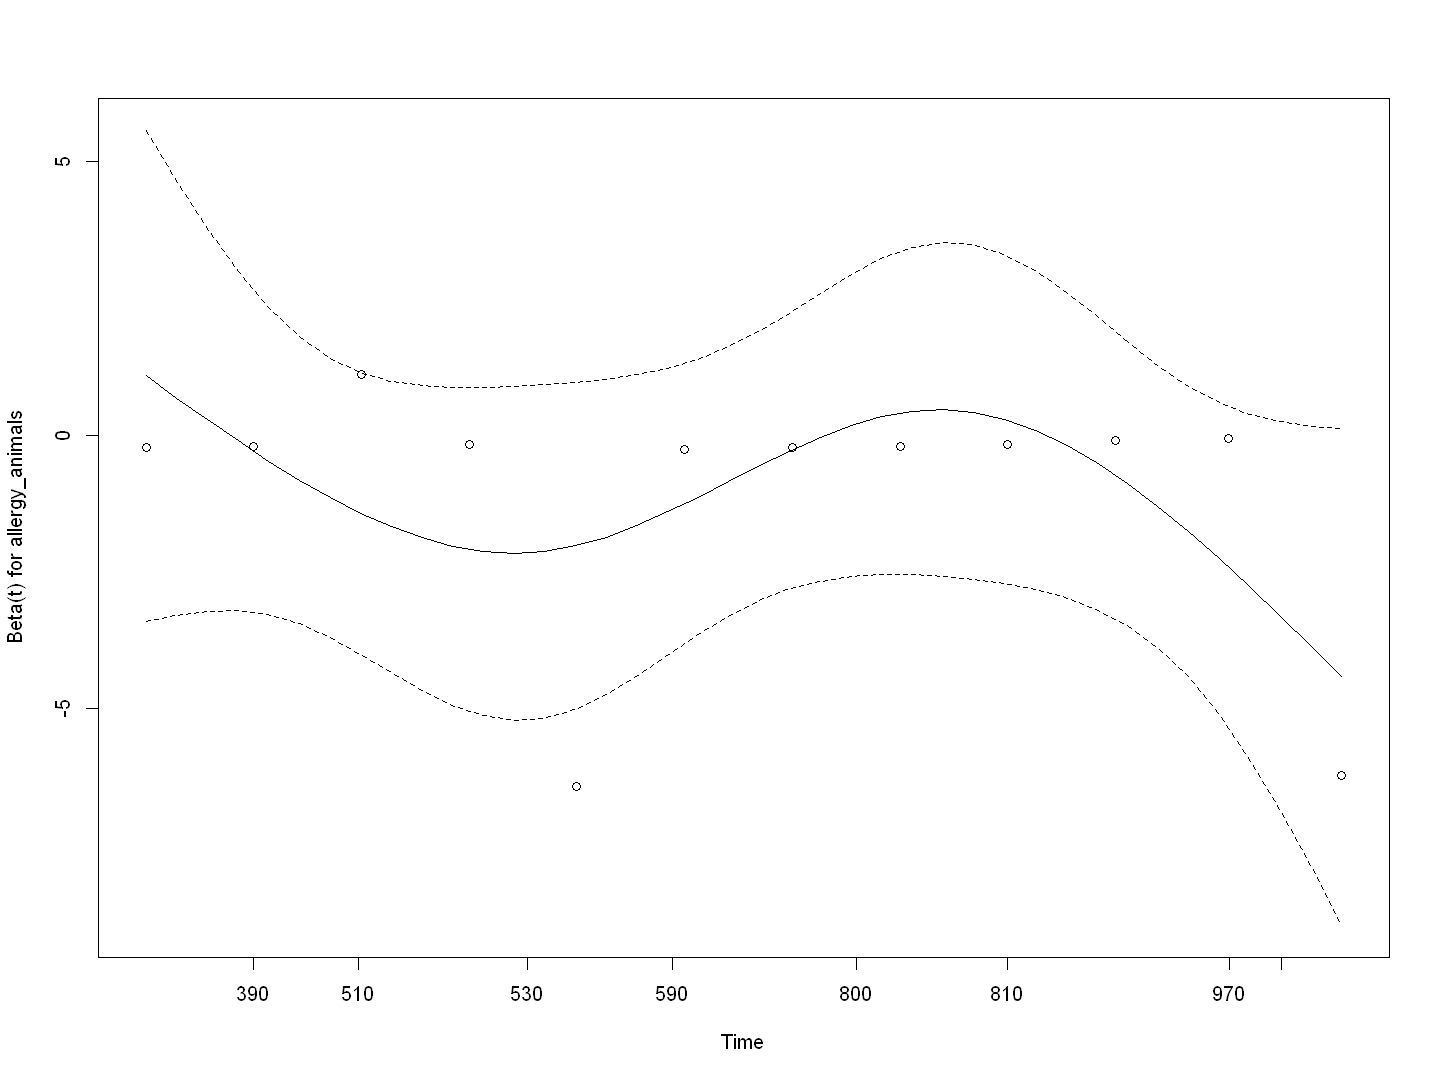

In [58]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [59]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + allergy_animals, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + allergy_animals):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + allergy_animals):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_animals, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                      coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ            -1.4279    0.2398   0.6907 -2.067   0.0387 *
allergy_animalsнет -1.1071    0.3305   0.7906 -1.400   0.1614  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
groupОГ               0.2398      4.170   0.06194    0.9286
allergy_animalsнет    0.3305      3.026   0.07019    1.5565

Concordance= 0.679  (se = 0.063 )
Likelihood ratio test= 5.91  on 2 df,   p=0.05
Wald test            = 5.32  on 2 df,   p=0.07
Score (logrank) test = 5.88  on 2 df,   p=0.05




Test of PH assumption:


                 chisq df    p
group           0.0517  1 0.82
allergy_animals 0.5727  1 0.45
GLOBAL          0.7689  2 0.68


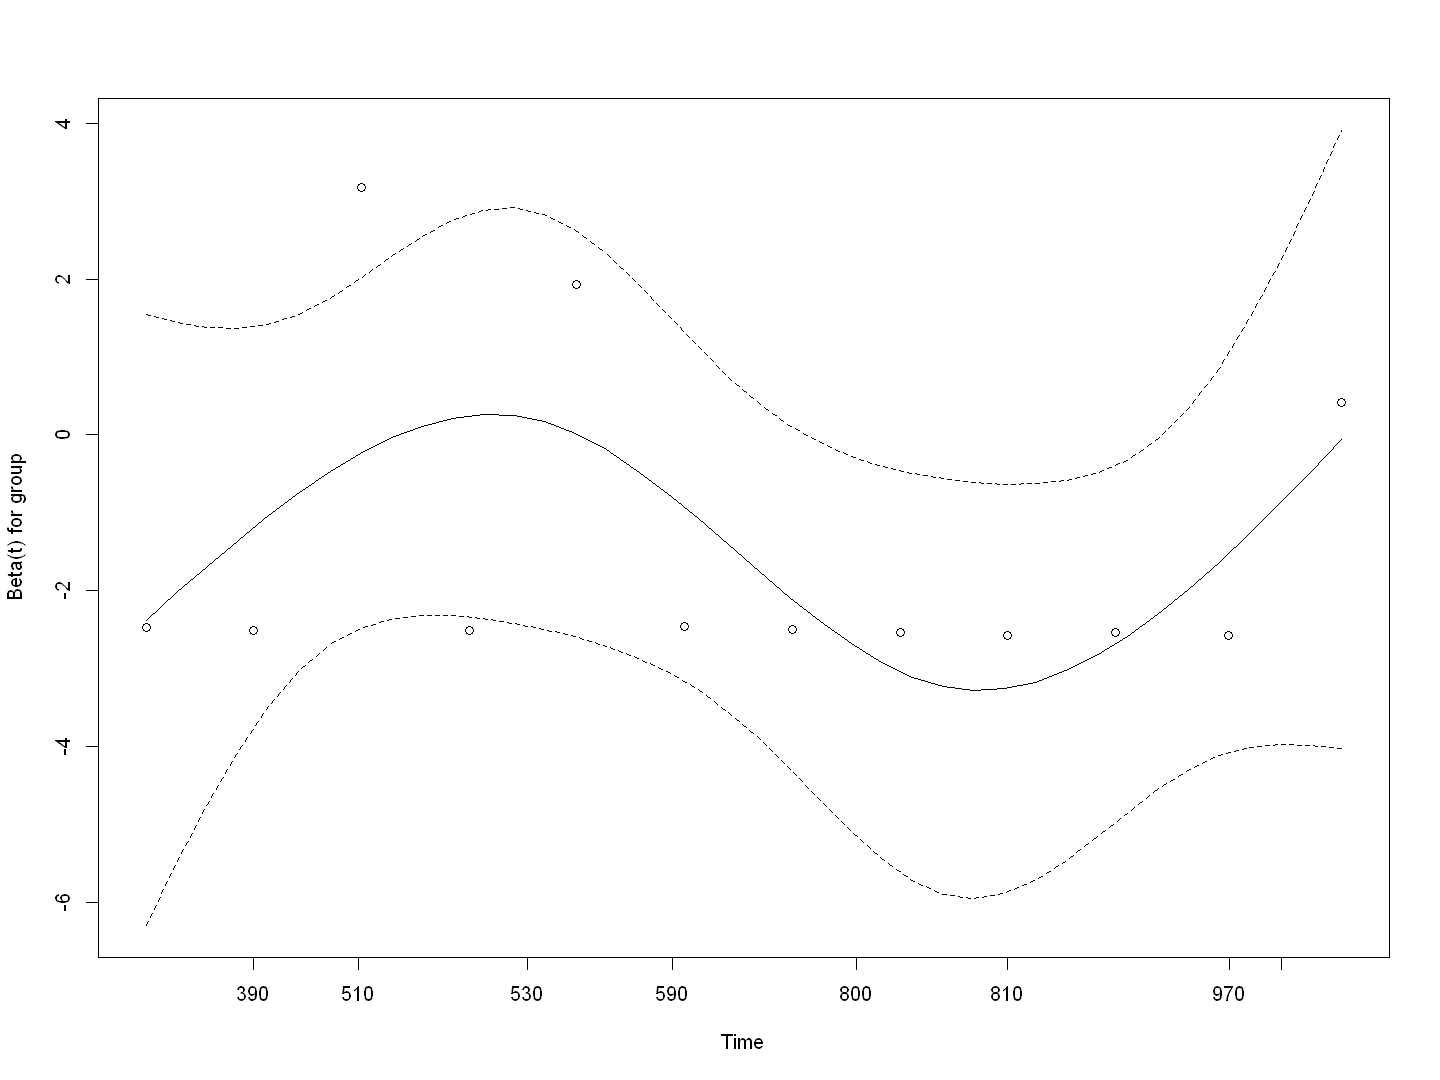

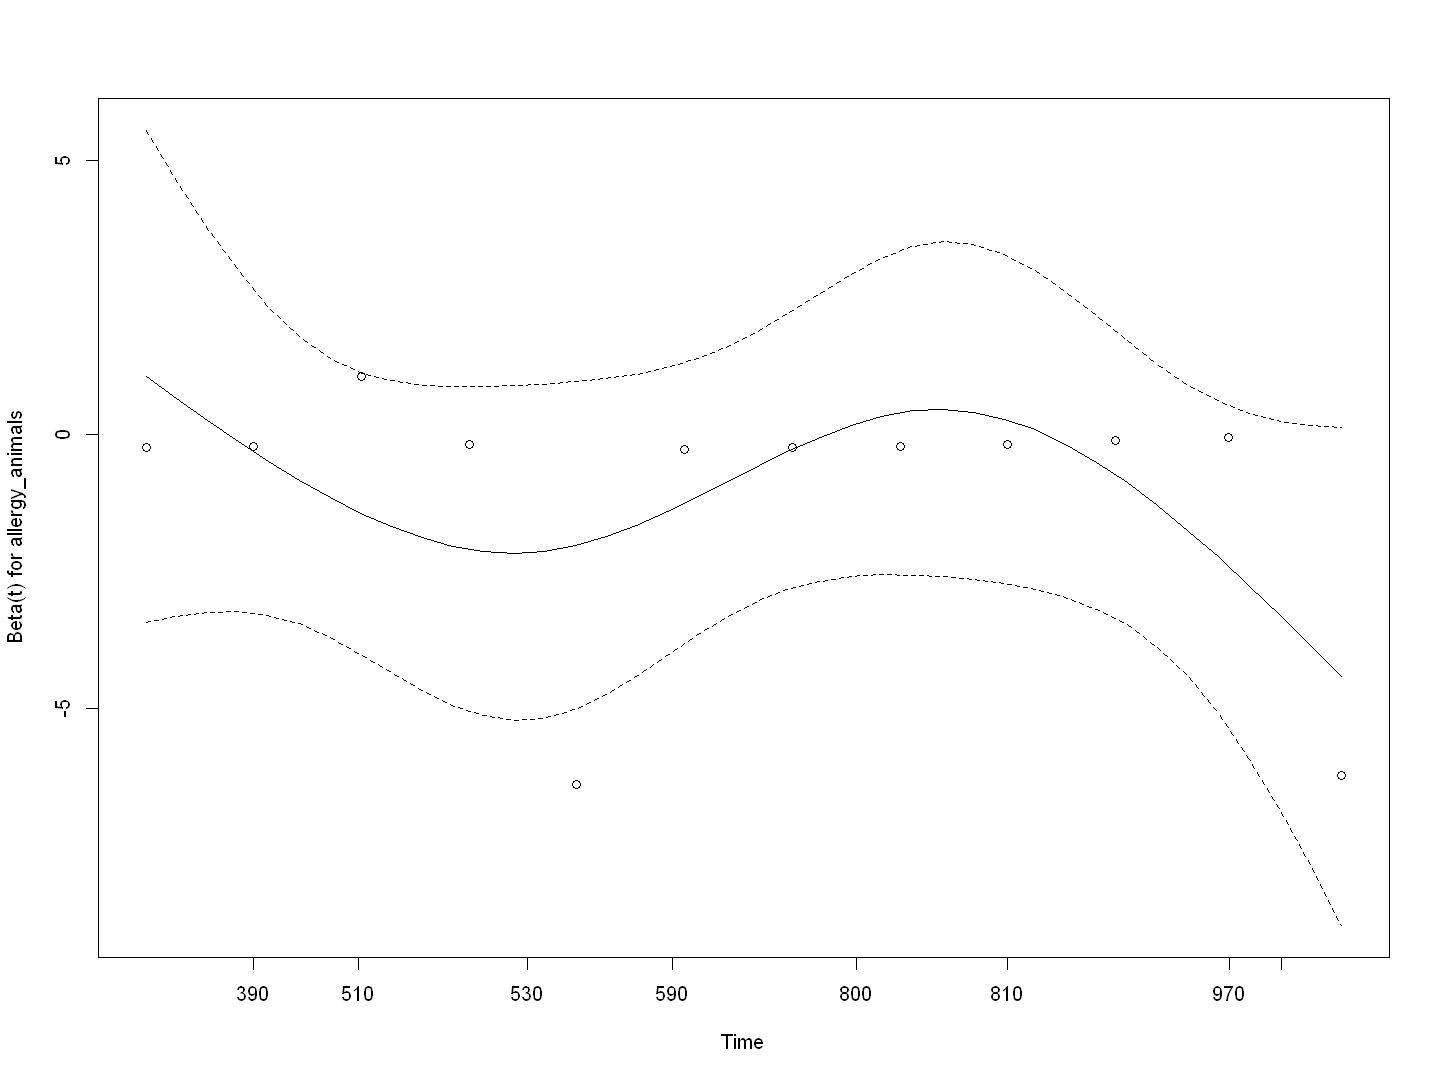

In [60]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + хронический ринит


#### Все группы

In [61]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + chronic_rhinitis, data = first_reop_df)
cat("\nCox PH model summary (group + chronic_rhinitis):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + chronic_rhinitis):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + chronic_rhinitis, 
    data = first_reop_df)

  n= 50, number of events= 12 

                       coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1            -1.0637    0.3452   0.8127 -1.309    0.191
groupОГ2            -1.5786    0.2063   1.0560 -1.495    0.135
chronic_rhinitisнет  0.9888    2.6879   1.0494  0.942    0.346

                    exp(coef) exp(-coef) lower .95 upper .95
groupОГ1               0.3452      2.897   0.07019     1.697
groupОГ2               0.2063      4.848   0.02604     1.634
chronic_rhinitisнет    2.6879      0.372   0.34370    21.020

Concordance= 0.688  (se = 0.067 )
Likelihood ratio test= 5.65  on 3 df,   p=0.1
Wald test            = 4.52  on 3 df,   p=0.2
Score (logrank) test = 5.21  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


                    chisq df    p
group            1.14e+00  2 0.57
chronic_rhinitis 3.99e-05  1 0.99
GLOBAL           1.14e+00  3 0.77


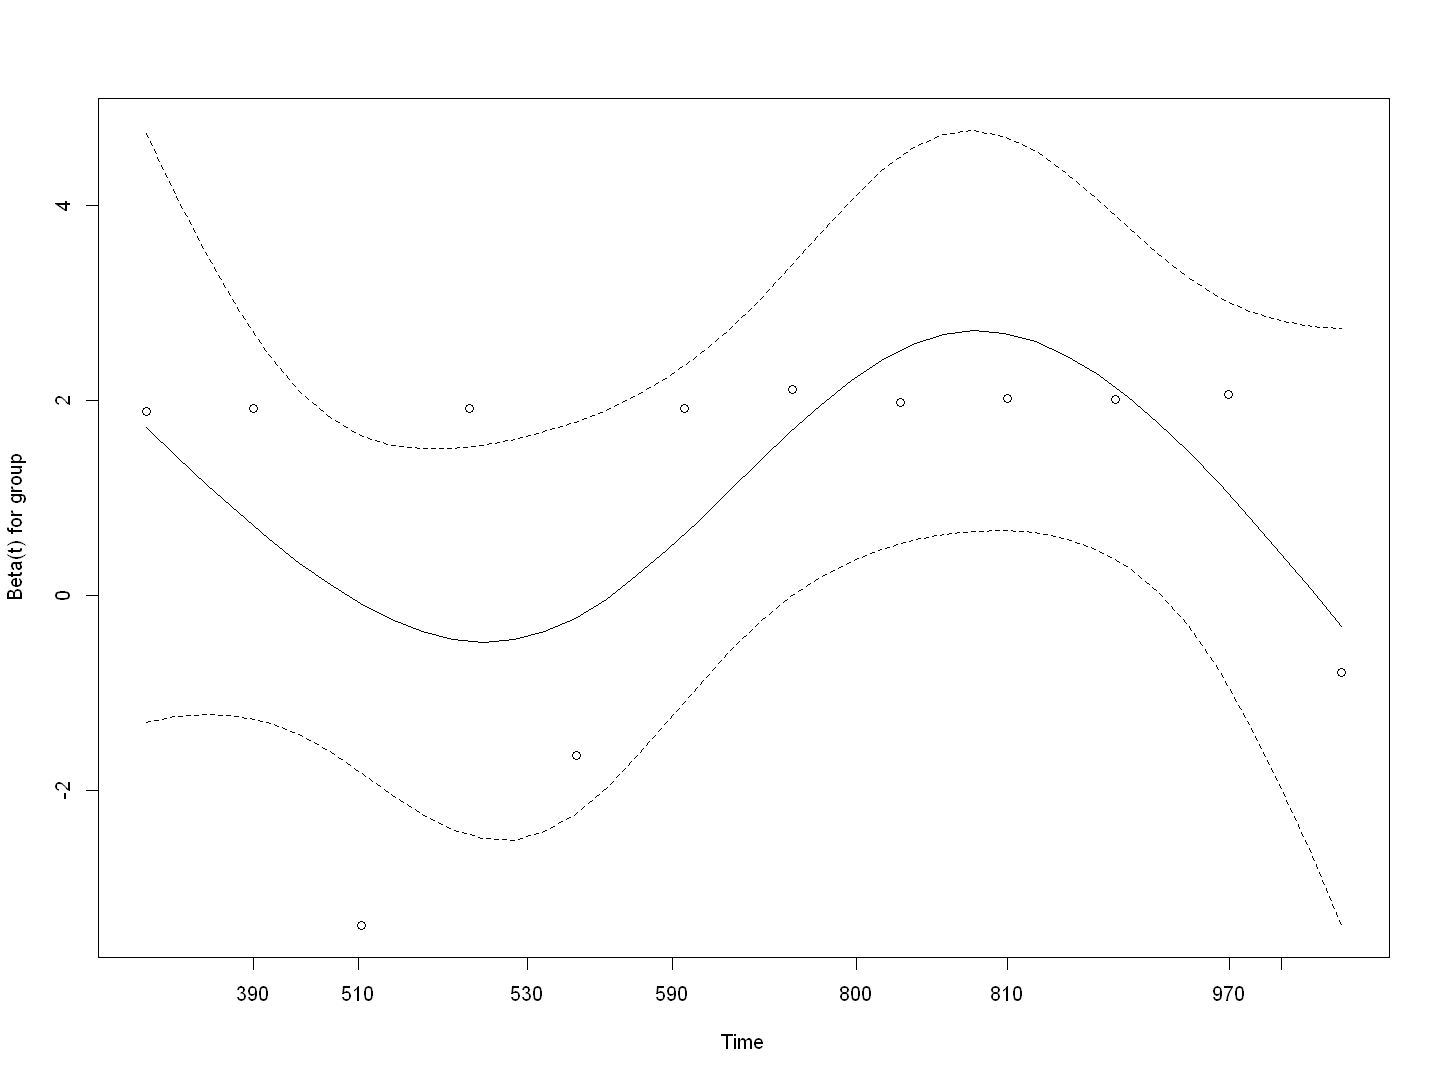

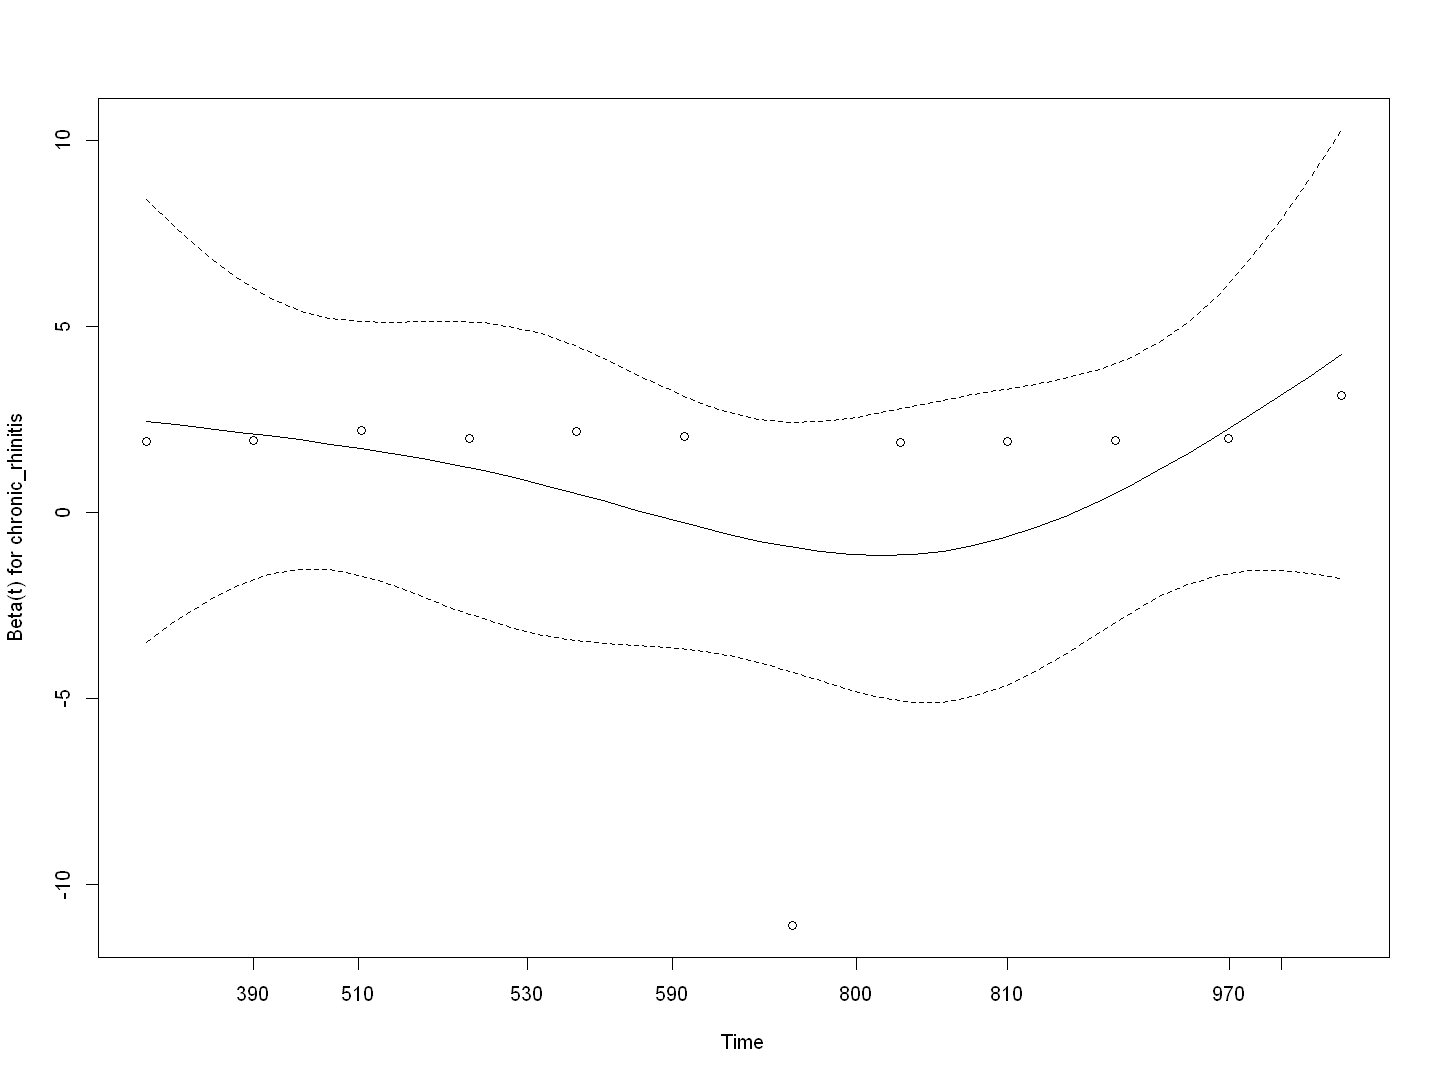

In [62]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [63]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + chronic_rhinitis, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + chronic_rhinitis):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + chronic_rhinitis):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + chronic_rhinitis, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                       coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ             -1.2760    0.2791   0.6740 -1.893   0.0583 .
chronic_rhinitisнет  0.9704    2.6391   1.0485  0.926   0.3547  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                    exp(coef) exp(-coef) lower .95 upper .95
groupОГ                0.2791     3.5824   0.07449     1.046
chronic_rhinitisнет    2.6391     0.3789   0.33805    20.602

Concordance= 0.687  (se = 0.065 )
Likelihood ratio test= 5.47  on 2 df,   p=0.06
Wald test            = 4.53  on 2 df,   p=0.1
Score (logrank) test = 5.12  on 2 df,   p=0.08




Test of PH assumption:


                    chisq df    p
group            4.02e-02  1 0.84
chronic_rhinitis 3.58e-05  1 1.00
GLOBAL           4.03e-02  2 0.98


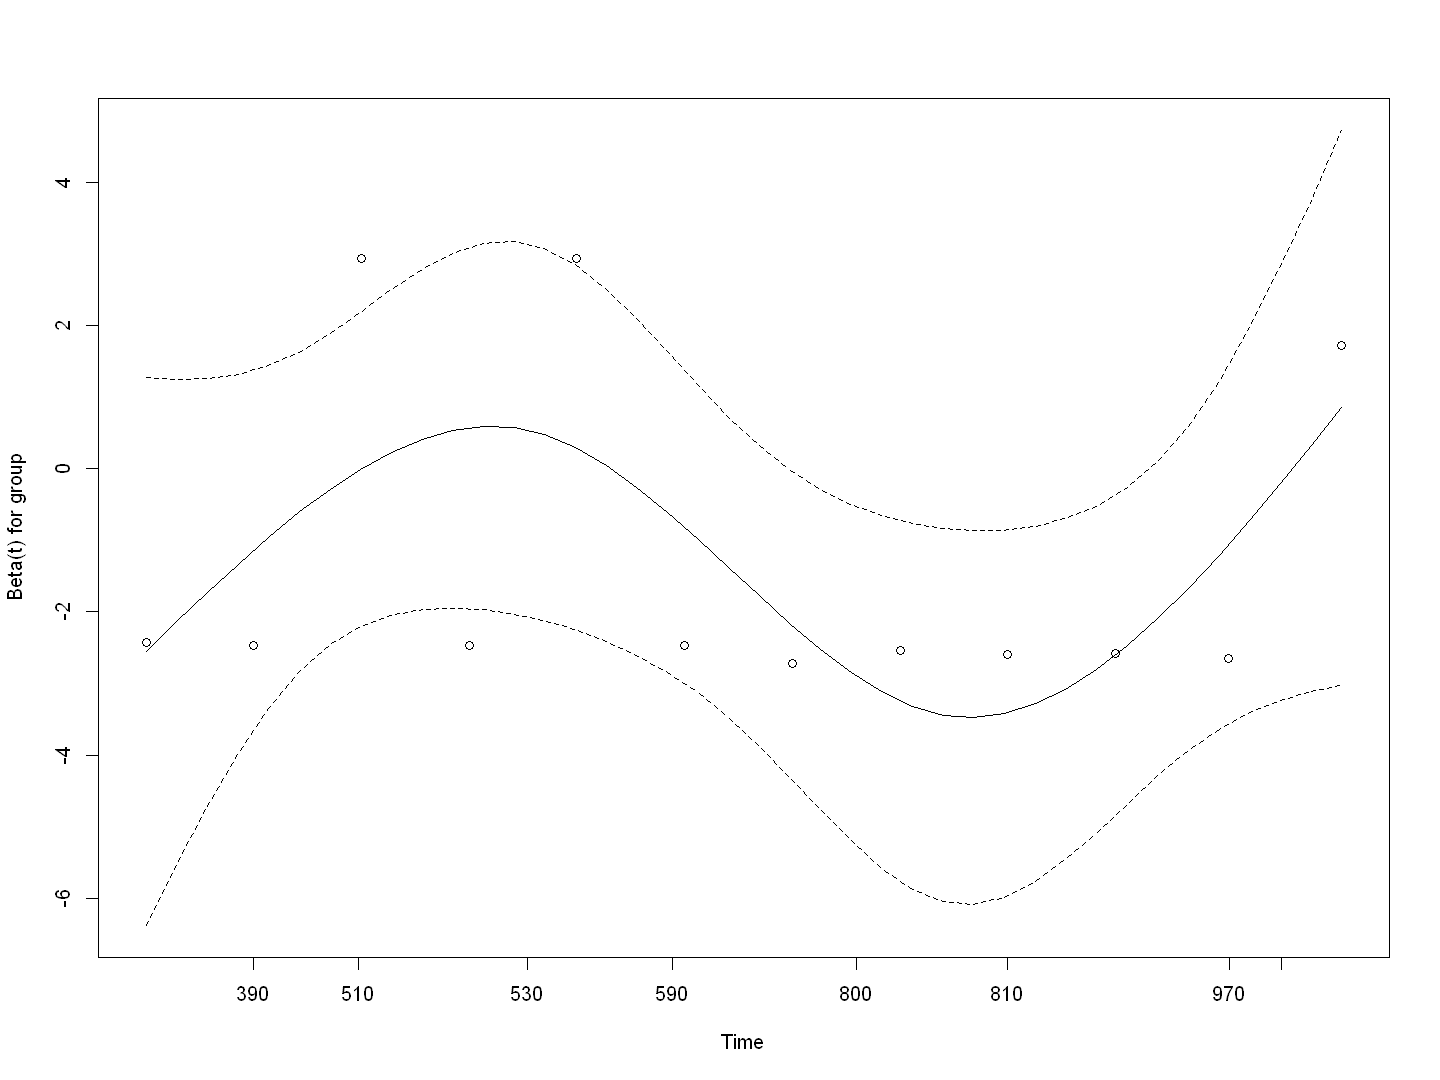

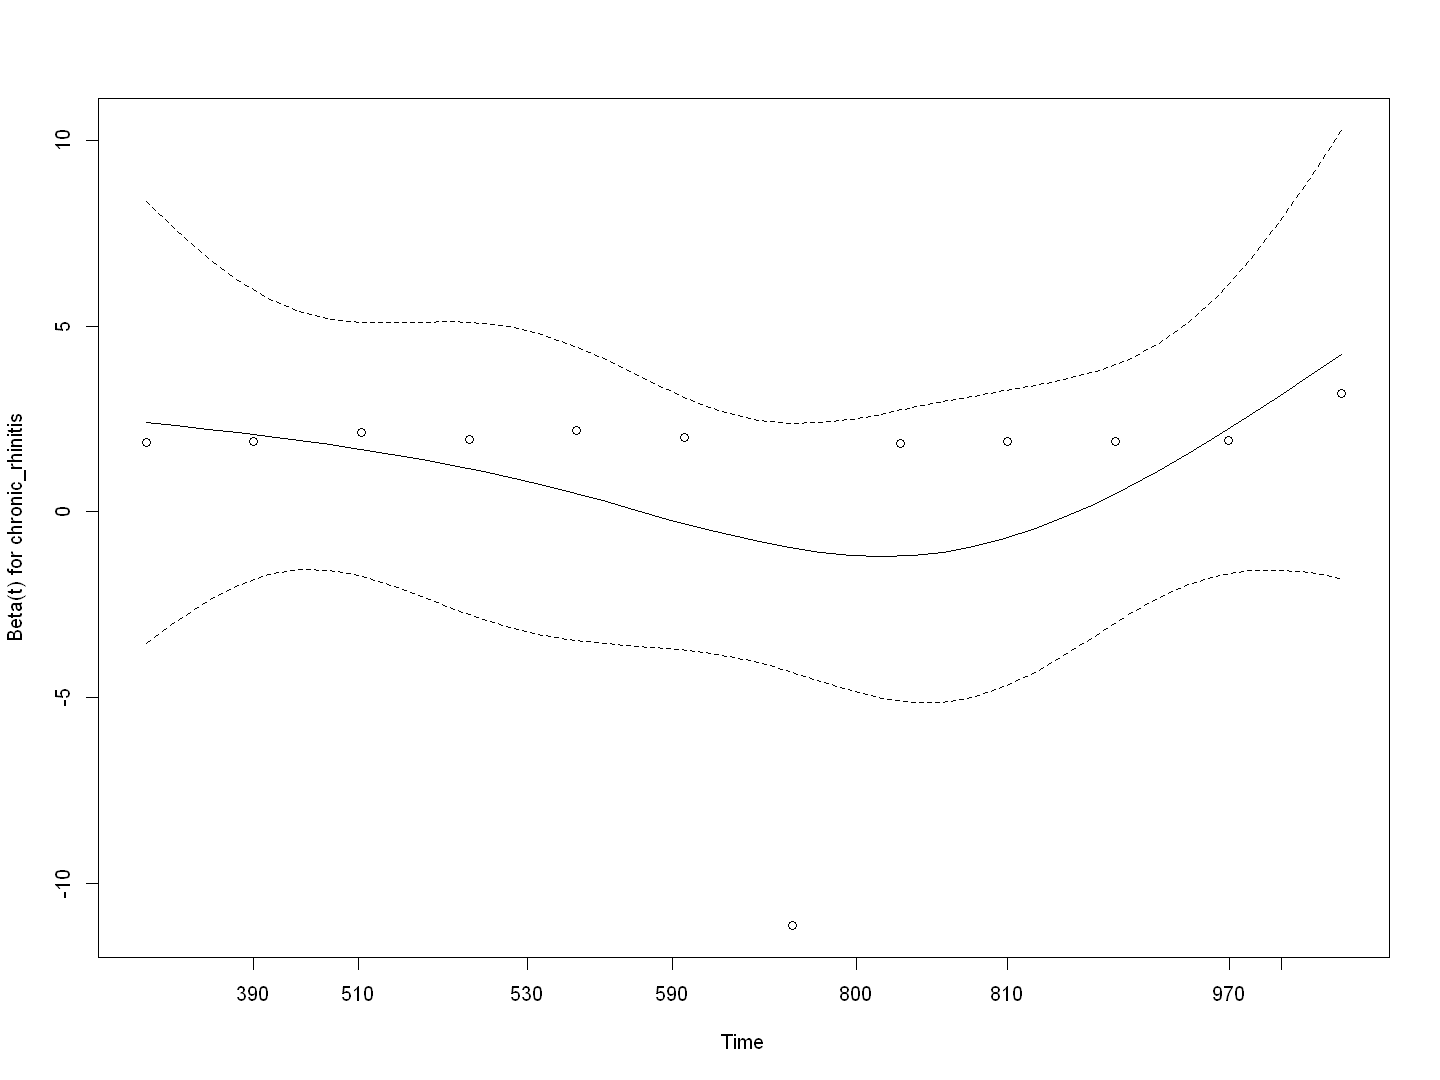

In [64]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + АР


#### Все группы

In [65]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + AR, data = first_reop_df)
cat("\nCox PH model summary (group + AR):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + AR):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + AR, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.1889    0.3046   0.8129 -1.463    0.144
groupОГ2 -1.6543    0.1912   1.0615 -1.558    0.119
ARнет    -0.5195    0.5948   0.5925 -0.877    0.381

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3046      3.283   0.06191     1.498
groupОГ2    0.1912      5.229   0.02388     1.531
ARнет       0.5948      1.681   0.18623     1.900

Concordance= 0.686  (se = 0.06 )
Likelihood ratio test= 5.23  on 3 df,   p=0.2
Wald test            = 4.43  on 3 df,   p=0.2
Score (logrank) test = 5.02  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group  1.115  2 0.57
AR     0.484  1 0.49
GLOBAL 1.699  3 0.64


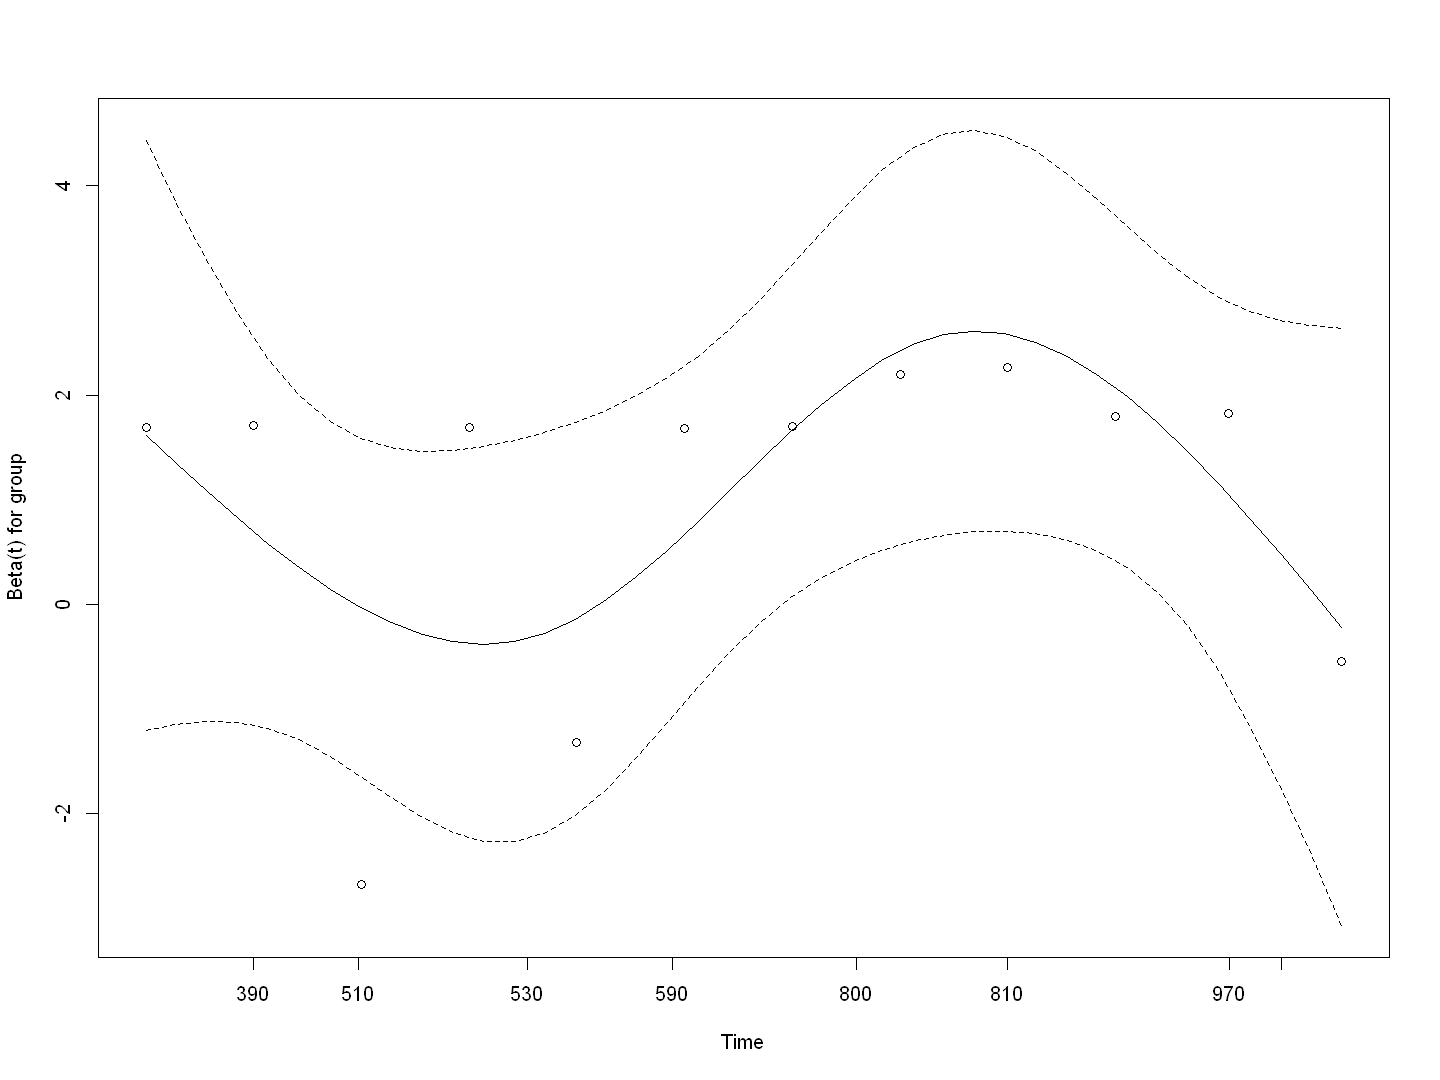

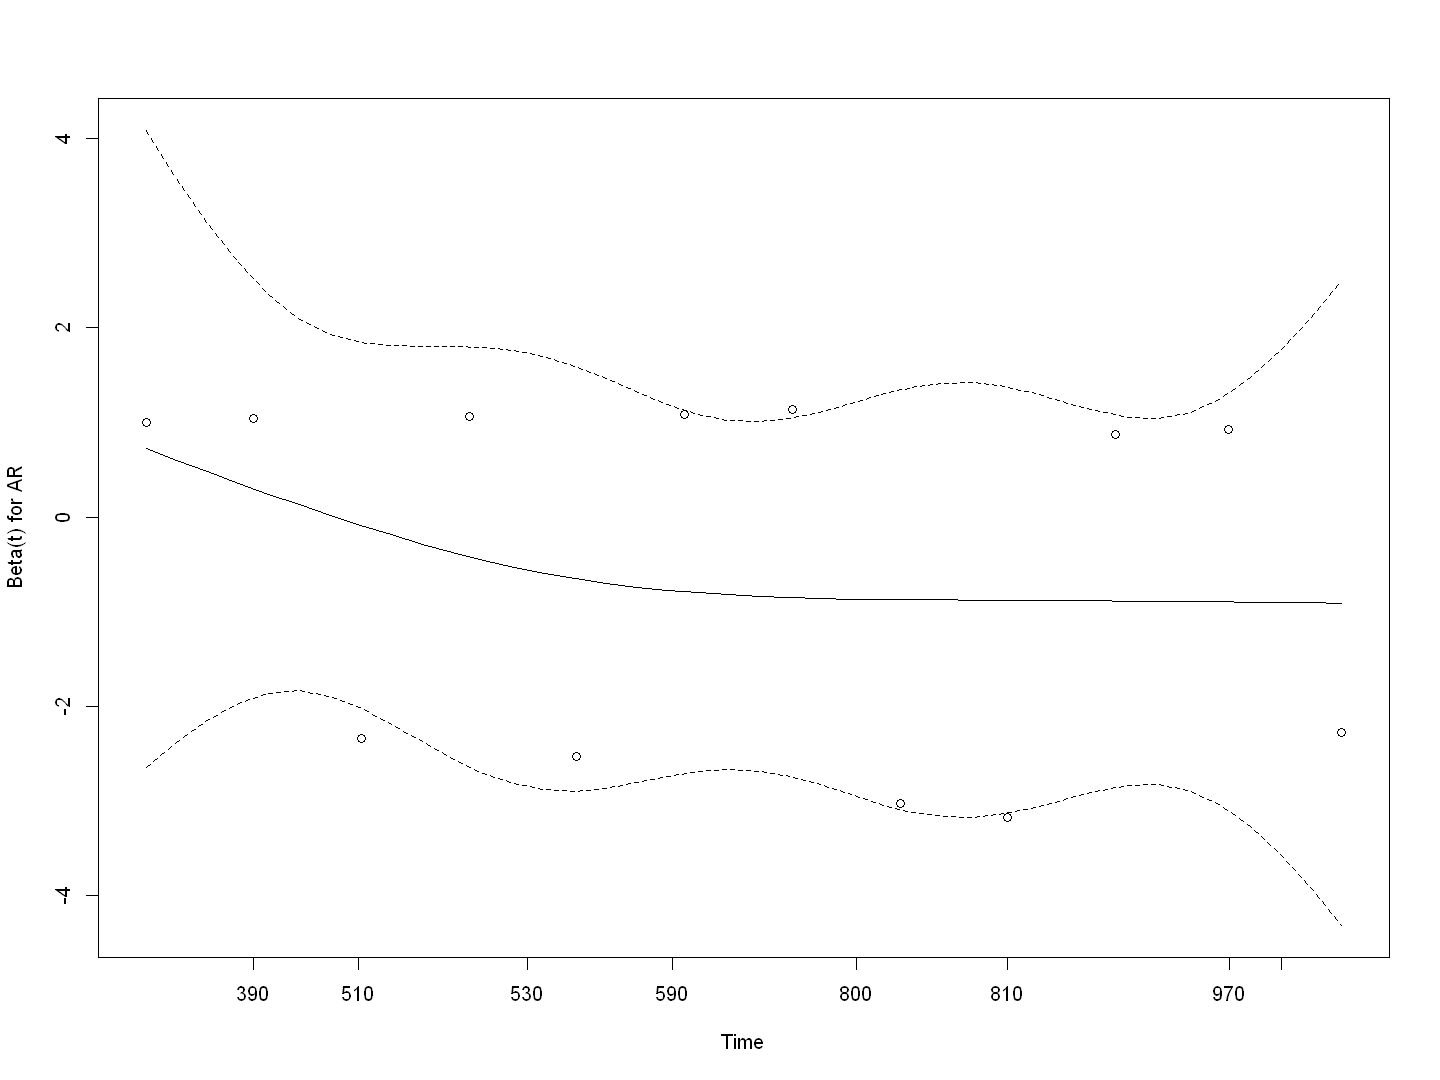

In [66]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [67]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + AR, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + AR):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + AR):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + AR, data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.3763    0.2525   0.6797 -2.025   0.0429 *
ARнет   -0.5147    0.5977   0.5926 -0.869   0.3850  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2525      3.960   0.06664    0.9568
ARнет      0.5977      1.673   0.18709    1.9092

Concordance= 0.686  (se = 0.059 )
Likelihood ratio test= 5.08  on 2 df,   p=0.08
Wald test            = 4.45  on 2 df,   p=0.1
Score (logrank) test = 4.96  on 2 df,   p=0.08




Test of PH assumption:


       chisq df    p
group  0.031  1 0.86
AR     0.493  1 0.48
GLOBAL 0.576  2 0.75


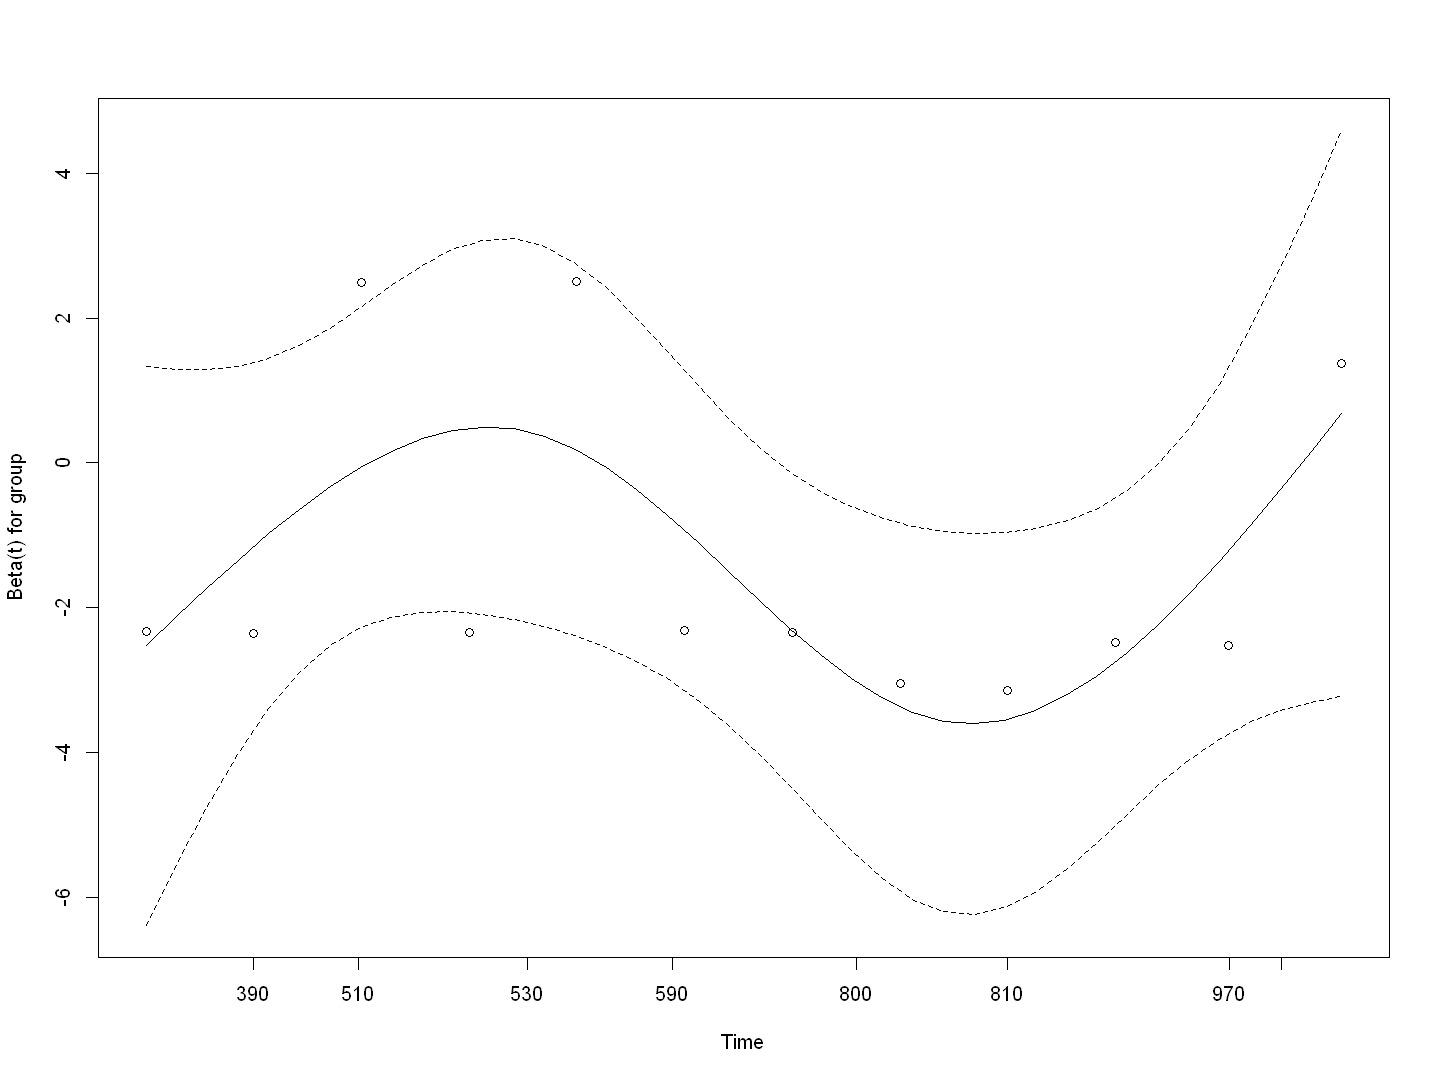

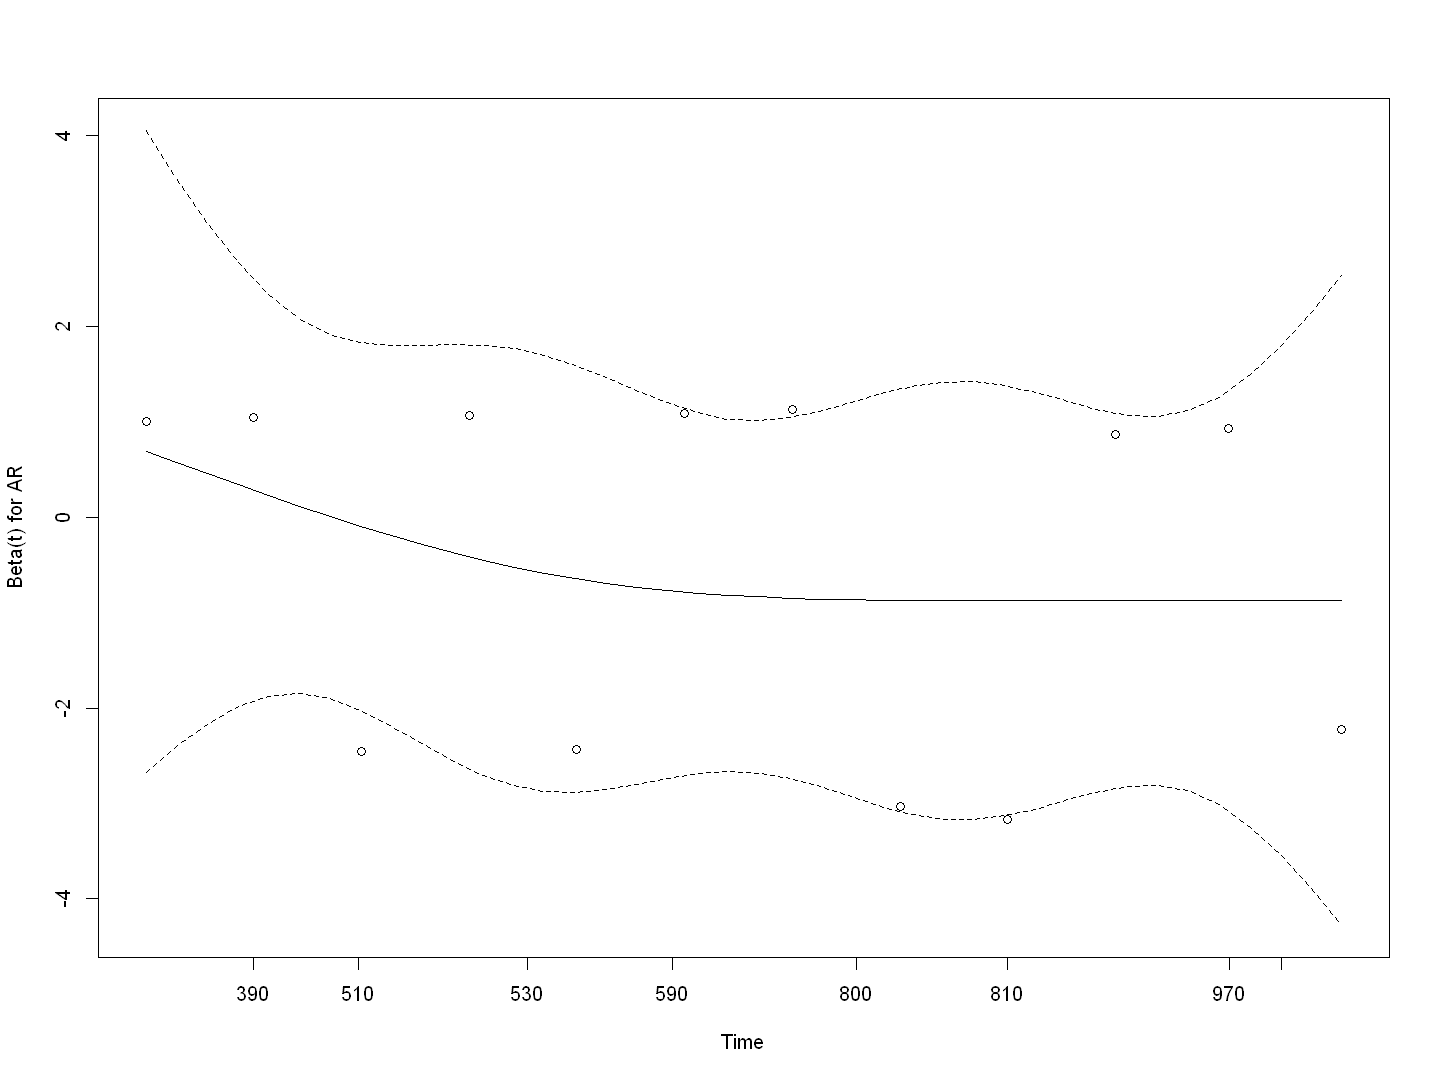

In [68]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + БА


#### Все группы

In [69]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + BA, data = first_reop_df)
cat("\nCox PH model summary (group + BA):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + BA):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + BA, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ1 -1.3743    0.2530   0.8412 -1.634   0.1023  
groupОГ2 -1.5507    0.2121   1.0554 -1.469   0.1418  
BAнет    -1.3441    0.2608   0.5975 -2.250   0.0245 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2530      3.952   0.04865    1.3157
groupОГ2    0.2121      4.715   0.02680    1.6786
BAнет       0.2608      3.835   0.08086    0.8411

Concordance= 0.736  (se = 0.065 )
Likelihood ratio test= 9.59  on 3 df,   p=0.02
Wald test            = 8.58  on 3 df,   p=0.04
Score (logrank) test = 9.84  on 3 df,   p=0.02




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group  1.027  2 0.60
BA     0.371  1 0.54
GLOBAL 1.495  3 0.68


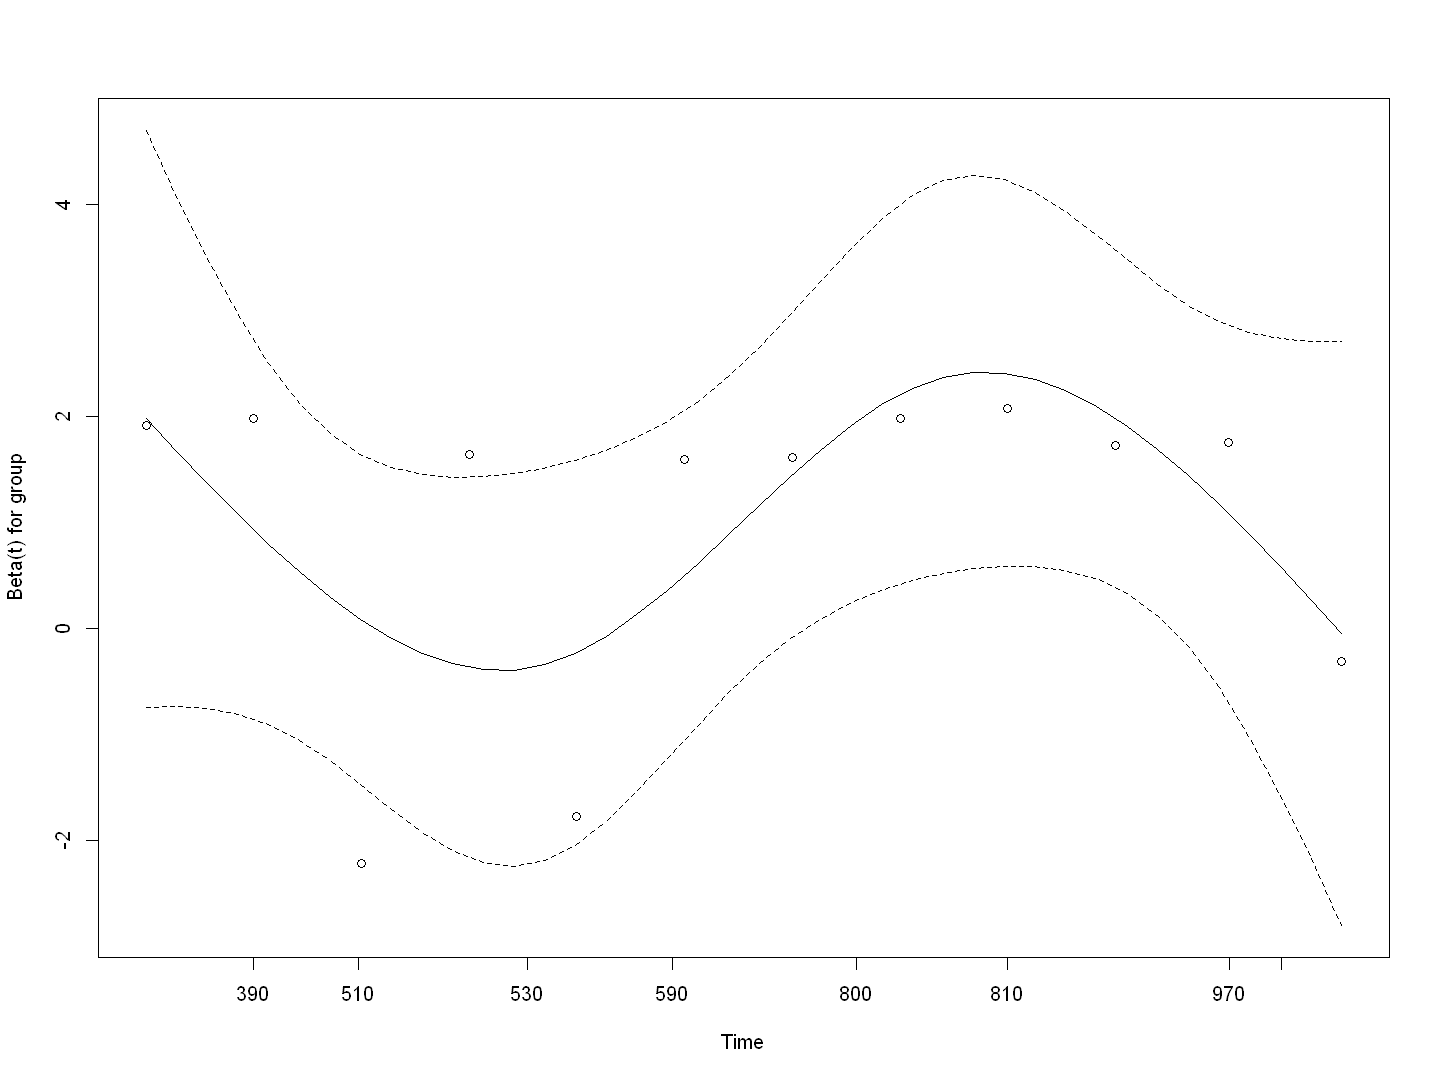

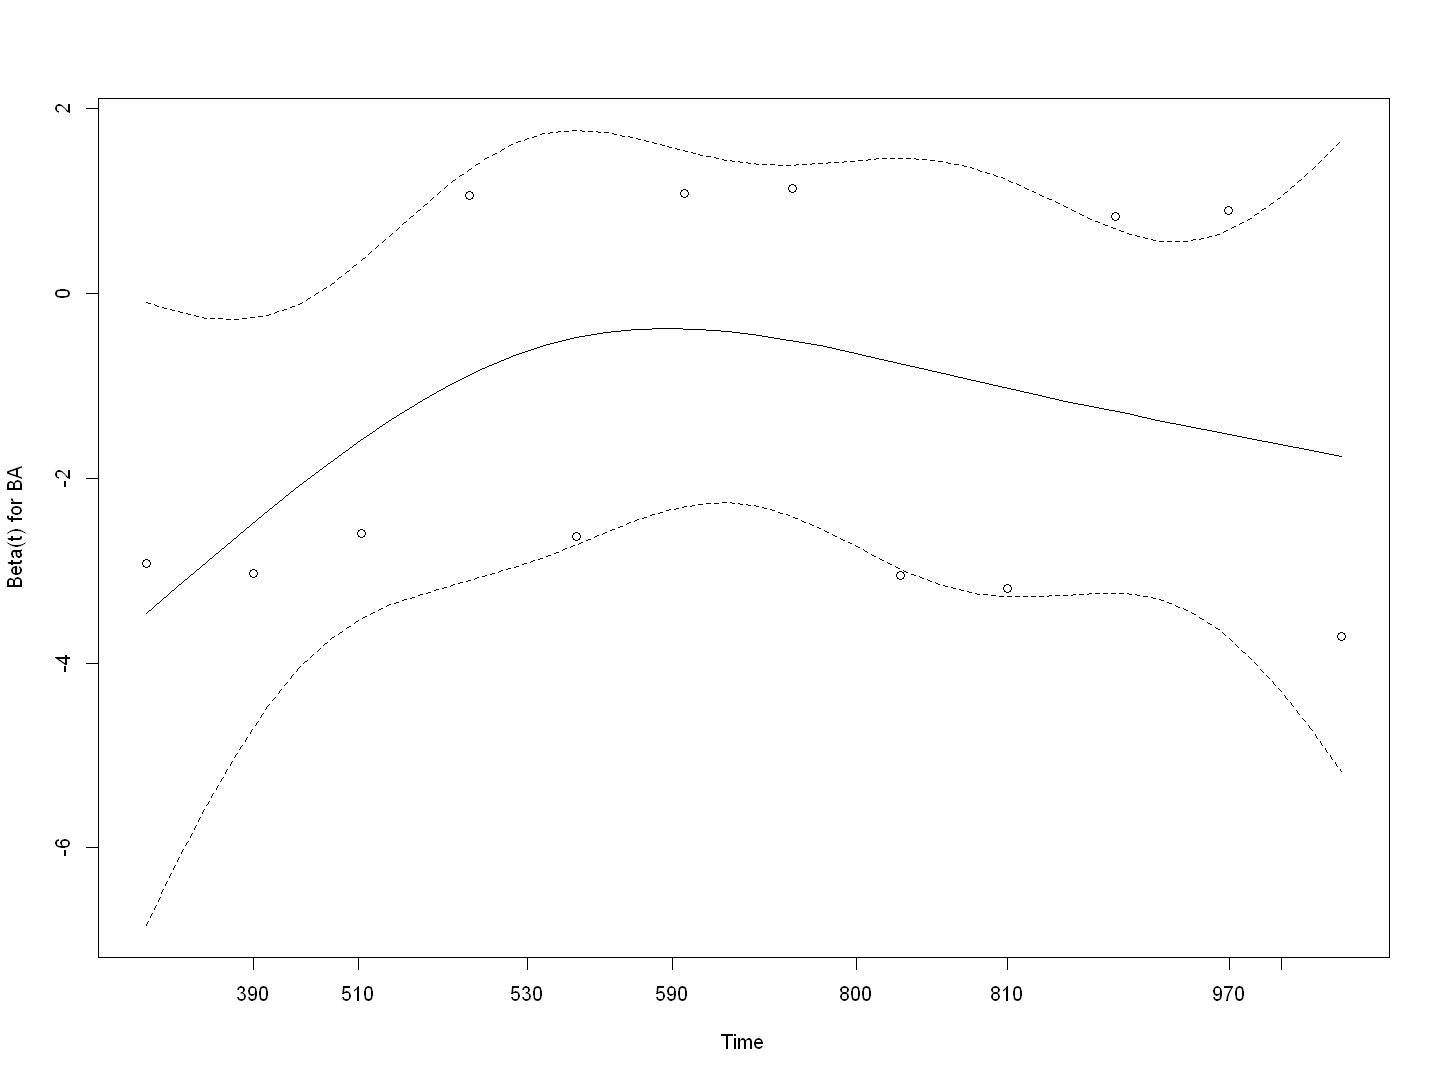

In [70]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [71]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + BA, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + BA):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + BA):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + BA, data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.4438    0.2360   0.6894 -2.094   0.0362 *
BAнет   -1.3528    0.2585   0.5945 -2.276   0.0229 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2360      4.237   0.06111    0.9116
BAнет      0.2585      3.868   0.08062    0.8289

Concordance= 0.738  (se = 0.063 )
Likelihood ratio test= 9.57  on 2 df,   p=0.008
Wald test            = 8.63  on 2 df,   p=0.01
Score (logrank) test = 9.83  on 2 df,   p=0.007




Test of PH assumption:


       chisq df    p
group  0.113  1 0.74
BA     0.357  1 0.55
GLOBAL 0.406  2 0.82


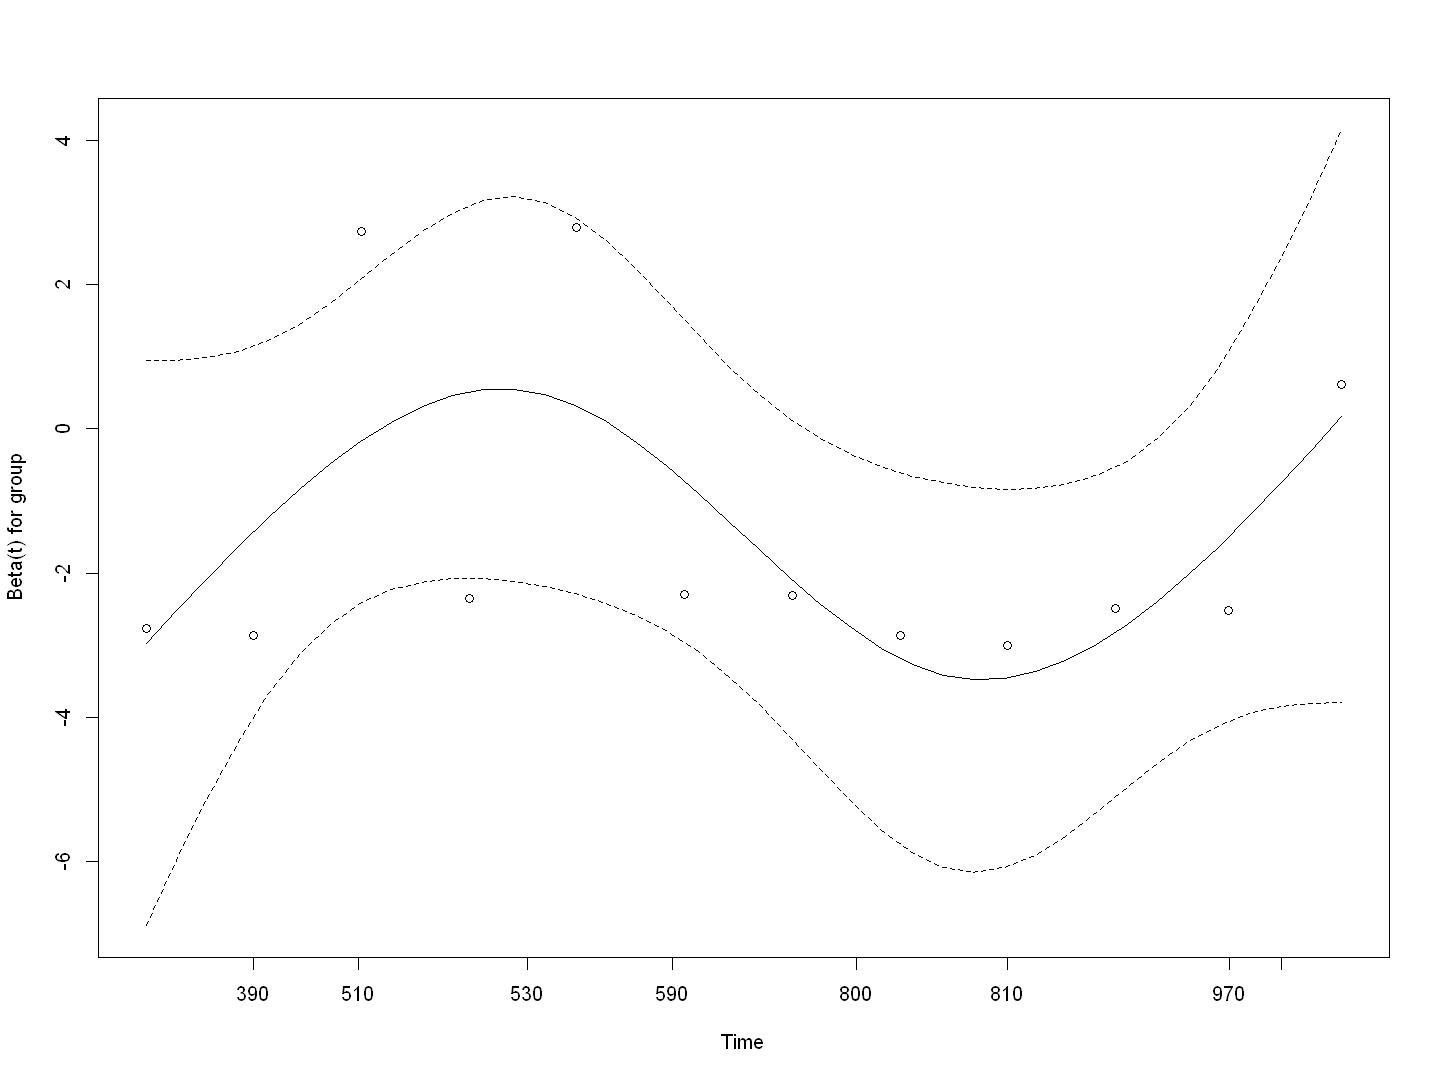

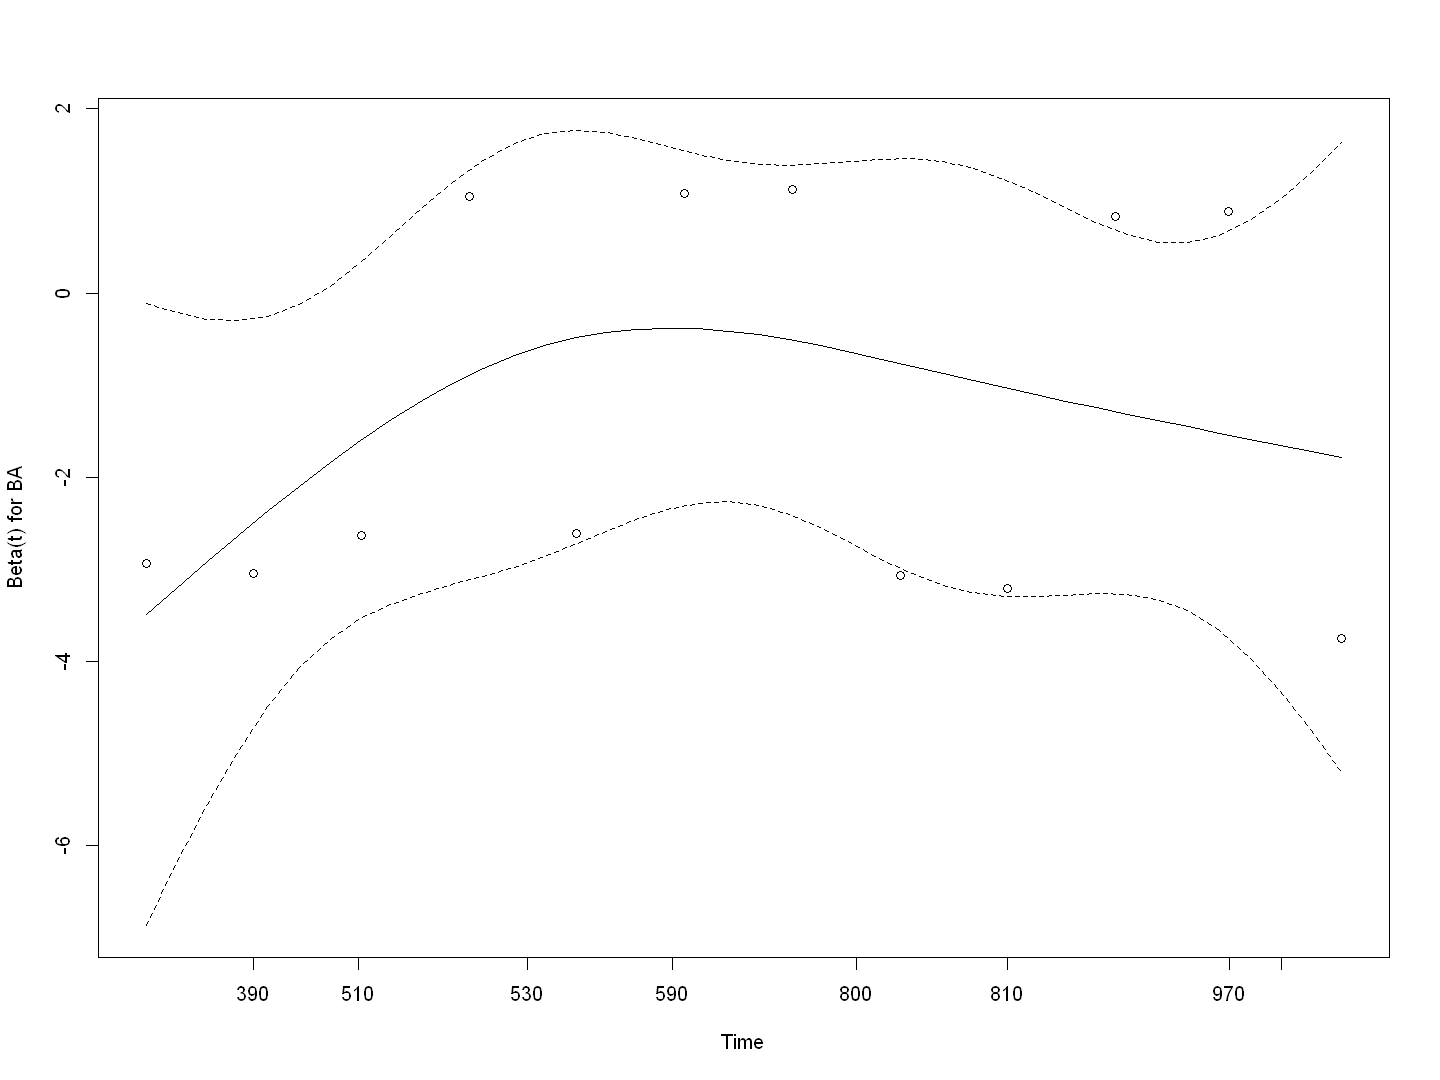

In [72]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + искривление носовой перегородки


#### Все группы

In [73]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + nasal_septum_deviation, data = first_reop_df)
cat("\nCox PH model summary (group + nasal_septum_deviation):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + nasal_septum_deviation):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + nasal_septum_deviation, 
    data = first_reop_df)

  n= 50, number of events= 12 

                              coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1                  -1.12501   0.32465  0.81021 -1.389    0.165
groupОГ2                  -1.56076   0.20998  1.05621 -1.478    0.139
nasal_septum_deviationнет -0.07816   0.92482  0.66984 -0.117    0.907

                          exp(coef) exp(-coef) lower .95 upper .95
groupОГ1                     0.3246      3.080   0.06634     1.589
groupОГ2                     0.2100      4.762   0.02649     1.664
nasal_septum_deviationнет    0.9248      1.081   0.24882     3.437

Concordance= 0.658  (se = 0.064 )
Likelihood ratio test= 4.5  on 3 df,   p=0.2
Wald test            = 3.7  on 3 df,   p=0.3
Score (logrank) test = 4.29  on 3 df,   p=0.2




Test of PH assumption (Schoenfeld residuals):


                       chisq df    p
group                  1.132  2 0.57
nasal_septum_deviation 0.956  1 0.33
GLOBAL                 2.149  3 0.54


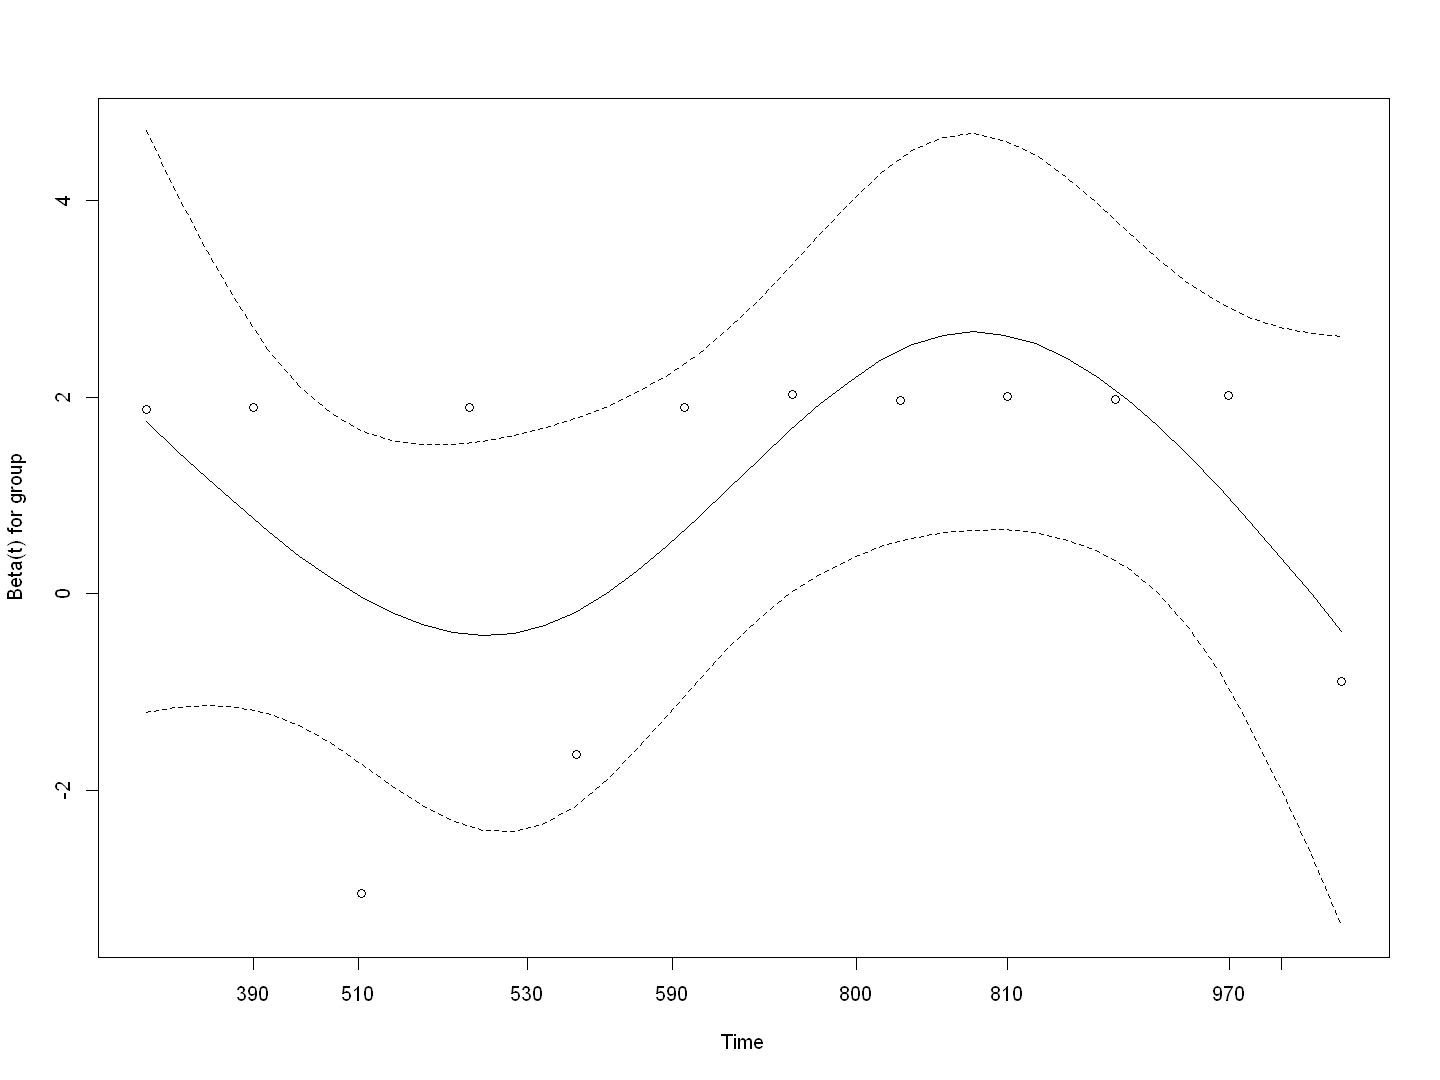

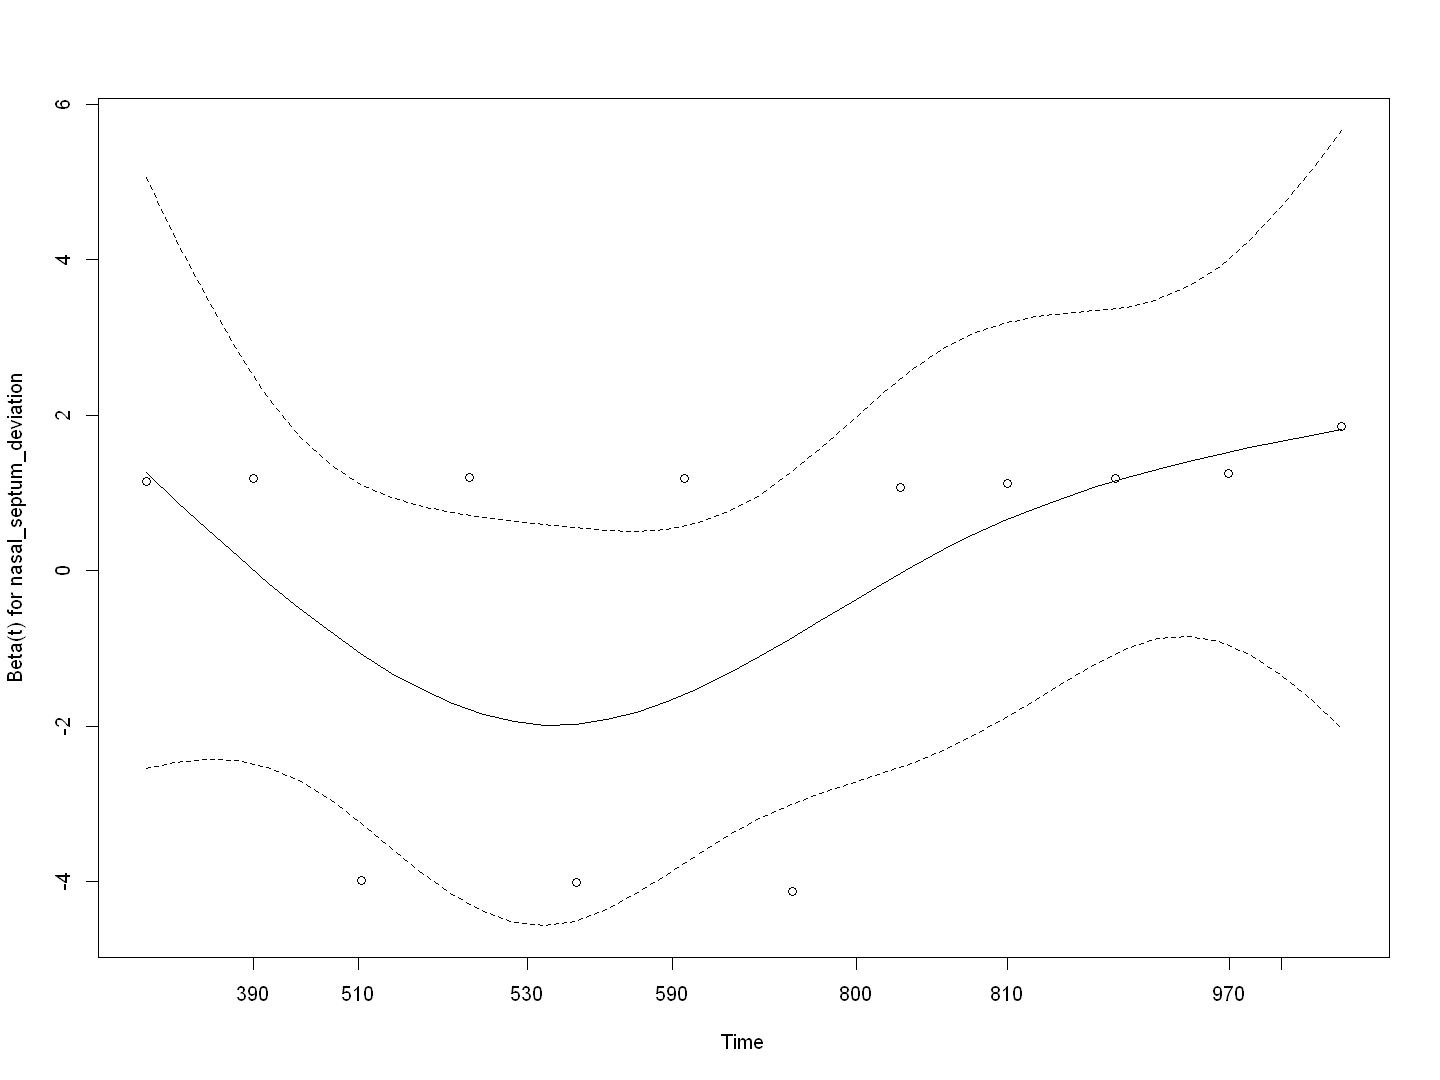

In [74]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [75]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + nasal_septum_deviation, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + nasal_septum_deviation):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + nasal_septum_deviation):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + nasal_septum_deviation, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                              coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ                   -1.30010   0.27250  0.67361 -1.930   0.0536 .
nasal_septum_deviationнет -0.09135   0.91270  0.66876 -0.137   0.8913  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                          exp(coef) exp(-coef) lower .95 upper .95
groupОГ                      0.2725      3.670   0.07278     1.020
nasal_septum_deviationнет    0.9127      1.096   0.24608     3.385

Concordance= 0.676  (se = 0.056 )
Likelihood ratio test= 4.38  on 2 df,   p=0.1
Wald test            = 3.73  on 2 df,   p=0.2
Score (logrank) test = 4.25  on 2 df,   p=0.1




Test of PH assumption:


                        chisq df    p
group                  0.0365  1 0.85
nasal_septum_deviation 0.9630  1 0.33
GLOBAL                 0.9871  2 0.61


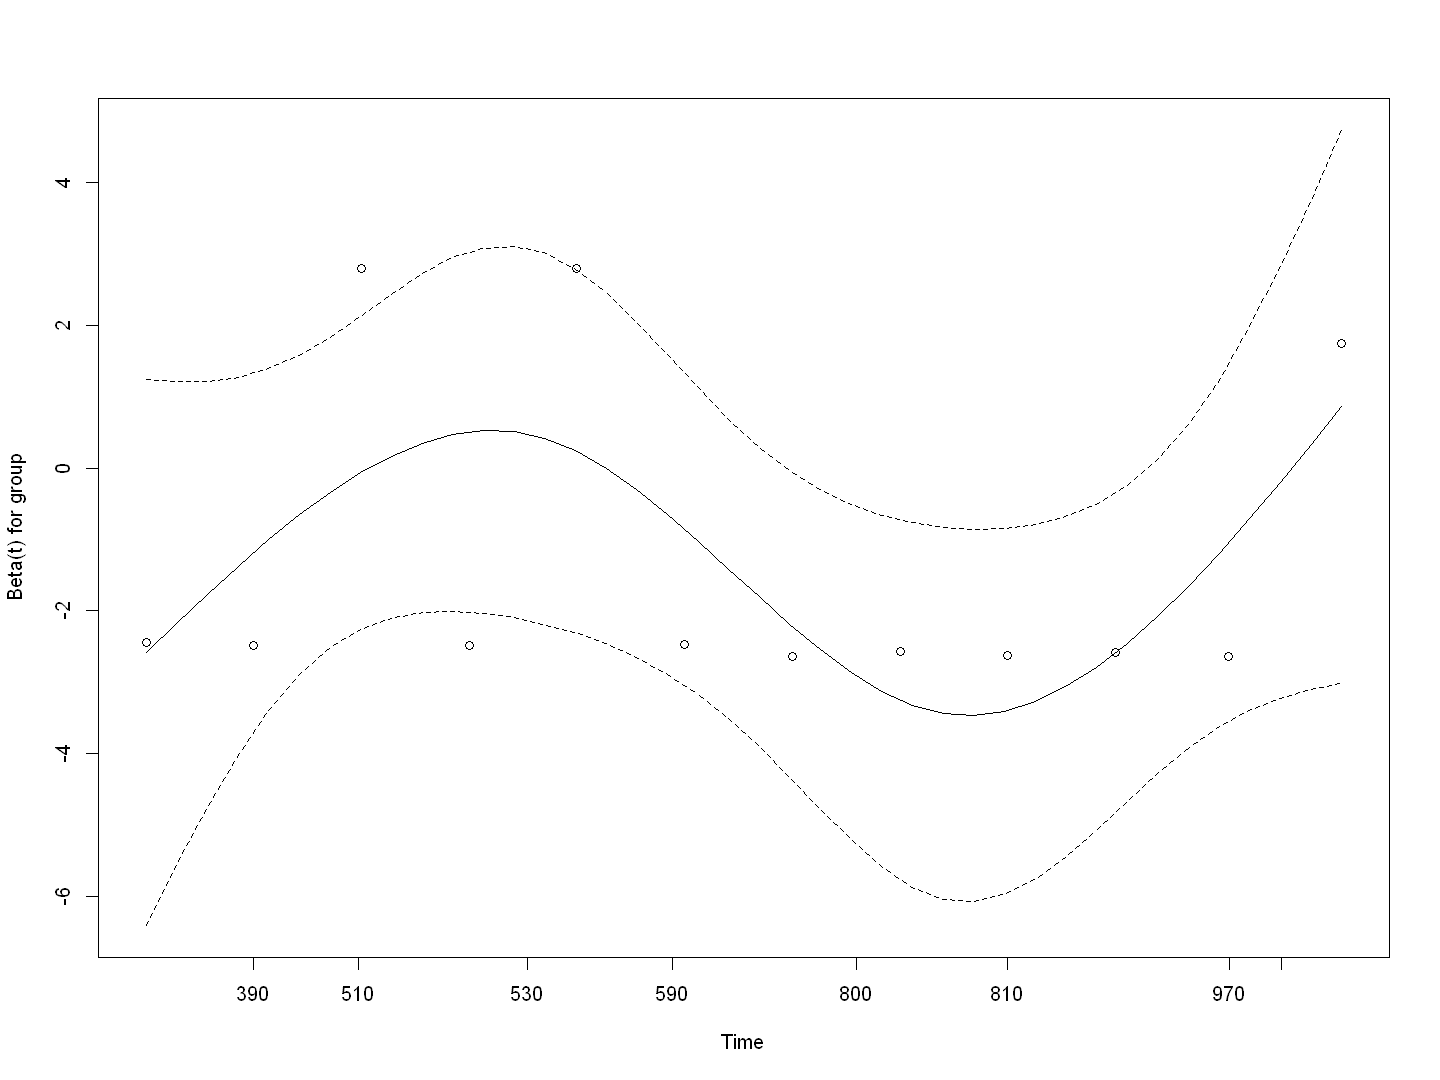

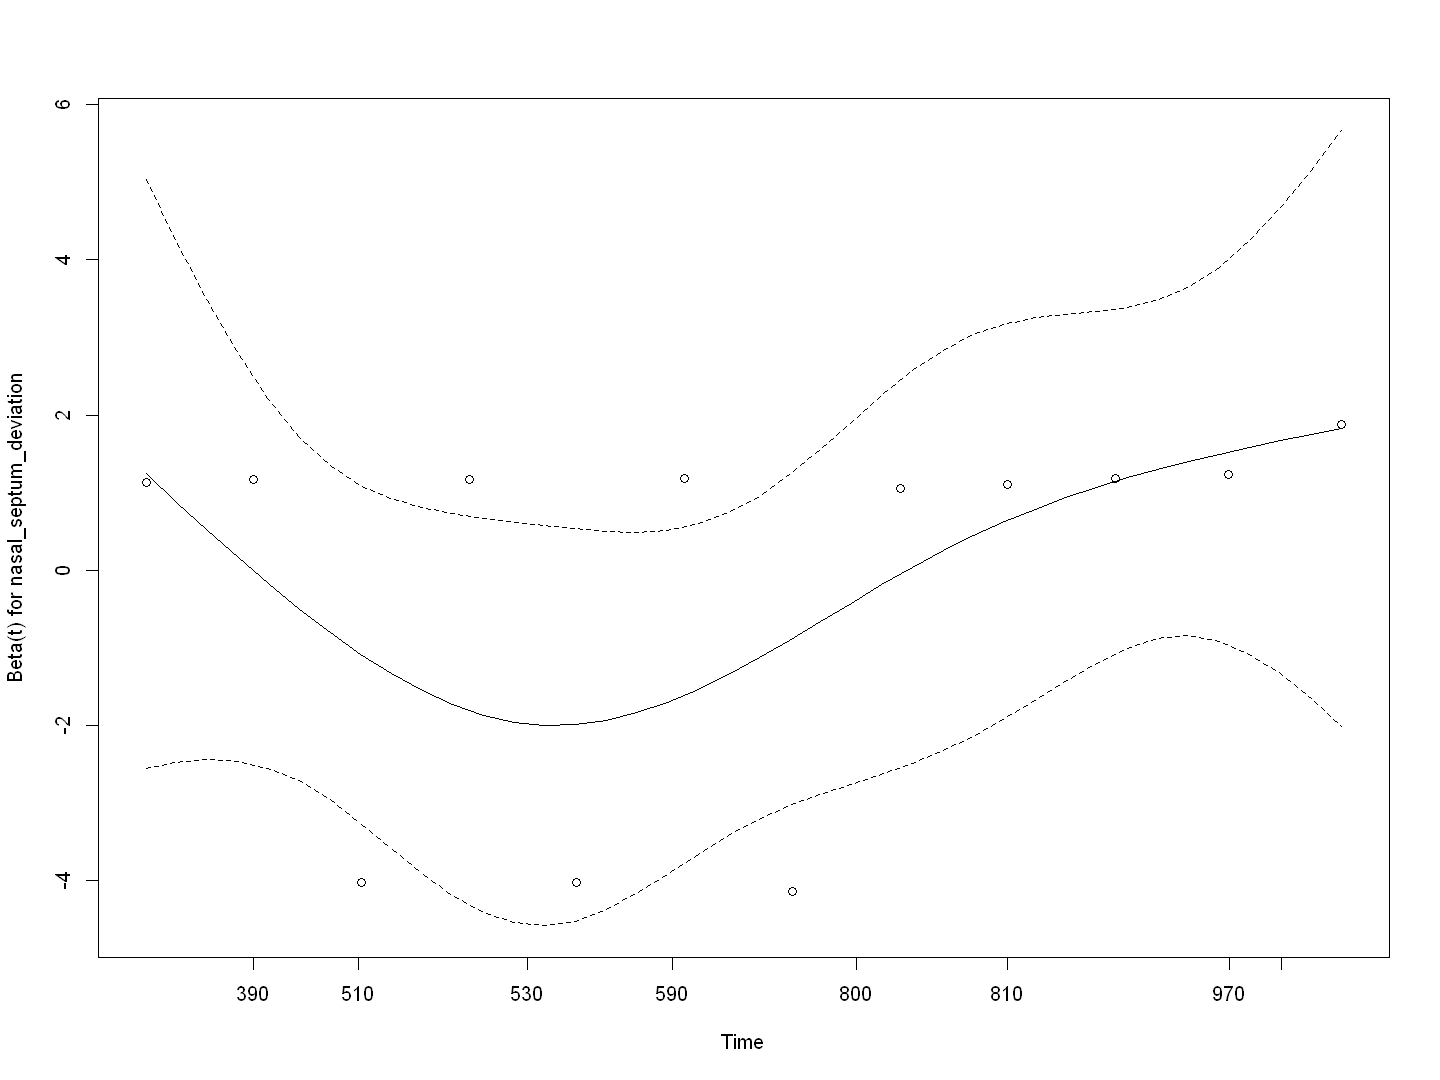

In [76]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


## 3. ANDERSEN-GILL MODEL  (all re-operations, independent increments)

### Все группы

In [77]:
# Assumes each event interval is independent (like multiple independent subjects)
# Uses (tstart, tstop] counting process notation

ag_fit <- coxph(
  Surv(tstart, tstop, status) ~ group + cluster(id),
  data   = long_df,
  method = "efron"
)
cat("\nAndersen-Gill model summary:\n")
print(summary(ag_fit))
cat("  HR > 1 means Group B has HIGHER re-op rate than Group A\n")
cat("  HR < 1 means Group B has LOWER  re-op rate (protective)\n")



Andersen-Gill model summary:


Call:
coxph(formula = Surv(tstart, tstop, status) ~ group, data = long_df, 
    method = "efron", cluster = id)

  n= 63, number of events= 14 
   (1 observation deleted due to missingness)

            coef exp(coef) se(coef) robust se      z Pr(>|z|)  
groupОГ1 -1.1523    0.3159   0.7825    0.6926 -1.664   0.0962 .
groupОГ2 -1.6840    0.1856   1.0461    1.0423 -1.616   0.1062  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.3159      3.165   0.08129     1.228
groupОГ2    0.1856      5.387   0.02407     1.432

Concordance= 0.67  (se = 0.052 )
Likelihood ratio test= 5.56  on 2 df,   p=0.06
Wald test            = 4.89  on 2 df,   p=0.09
Score (logrank) test = 5.15  on 2 df,   p=0.08,   Robust = 4.16  p=0.1

  (Note: the likelihood ratio and score tests assume independence of
     observations within a cluster, the Wald and robust score tests do not).


  HR > 1 means Group B has HIGHER re-op rate than Group A


  HR < 1 means Group B has LOWER  re-op rate (protective)



Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group   1.32  2 0.52
GLOBAL  1.32  2 0.52


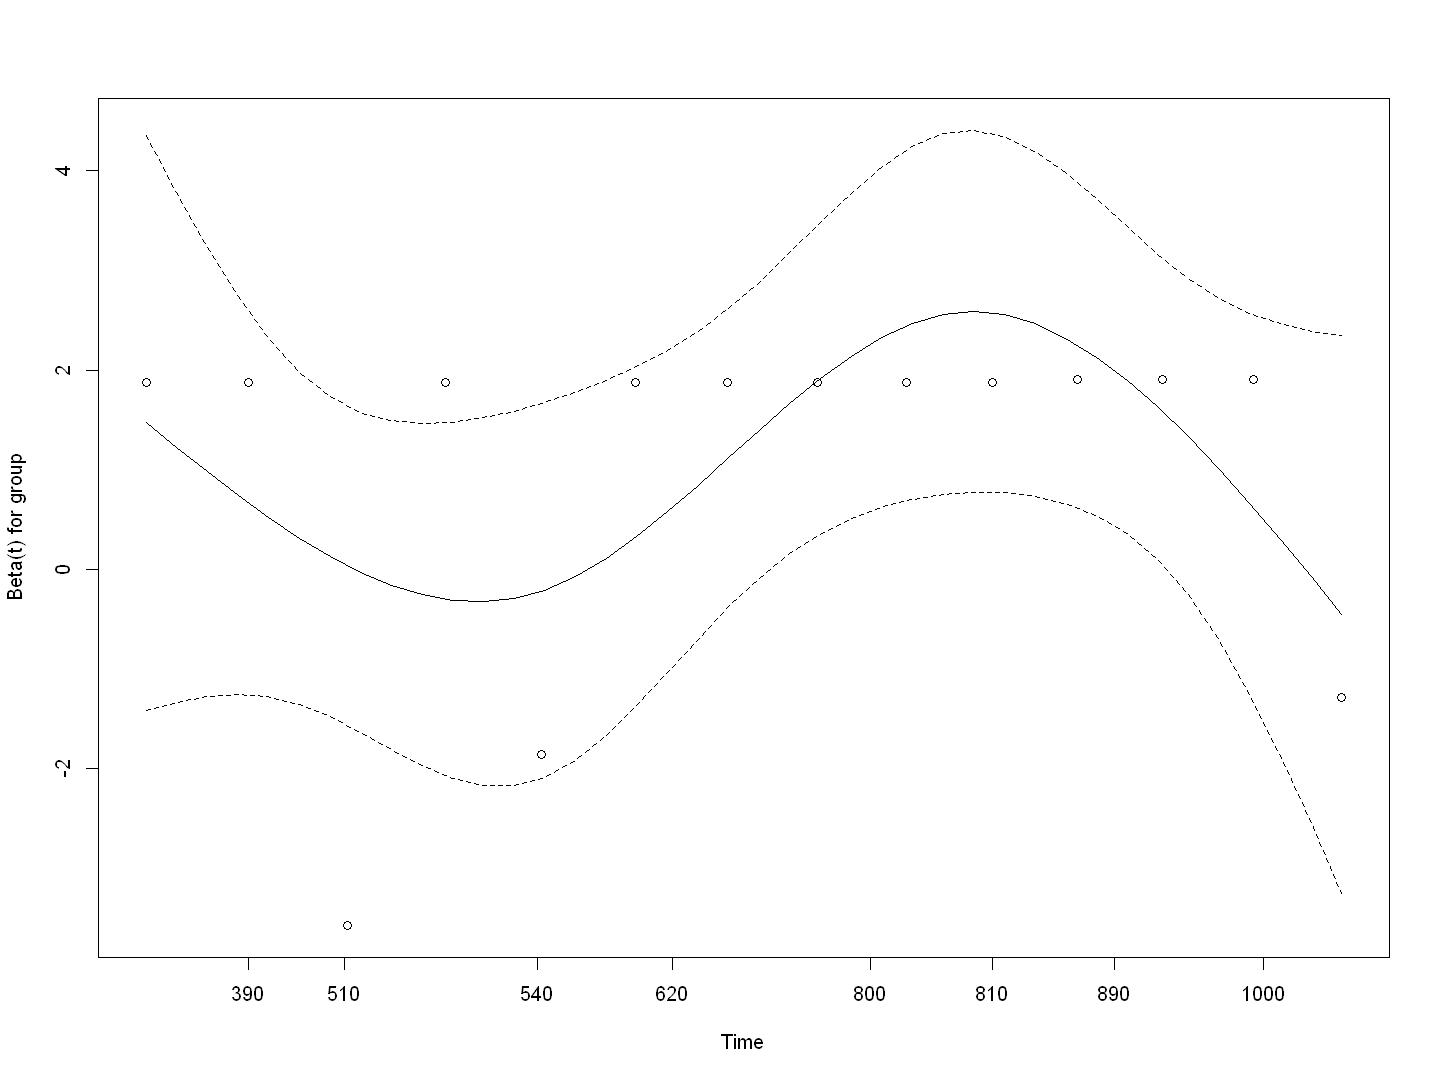

In [78]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(ag_fit)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [79]:
ag_fit_og <- coxph(
  Surv(tstart, tstop, status) ~ group + cluster(id),
  data   = long_df_og,
  method = "efron"
)
cat("\nAndersen-Gill model summary — ОГ combined:\n")
print(summary(ag_fit_og))



Andersen-Gill model summary — ОГ combined:


Call:
coxph(formula = Surv(tstart, tstop, status) ~ group, data = long_df_og, 
    method = "efron", cluster = id)

  n= 63, number of events= 14 
   (1 observation deleted due to missingness)

           coef exp(coef) se(coef) robust se      z Pr(>|z|)  
groupОГ -1.3667    0.2550   0.6536    0.6115 -2.235   0.0254 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ     0.255      3.922    0.0769    0.8452

Concordance= 0.669  (se = 0.051 )
Likelihood ratio test= 5.37  on 1 df,   p=0.02
Wald test            = 5  on 1 df,   p=0.03
Score (logrank) test = 5.08  on 1 df,   p=0.02,   Robust = 4.03  p=0.04

  (Note: the likelihood ratio and score tests assume independence of
     observations within a cluster, the Wald and robust score tests do not).



Test of PH assumption:


        chisq df    p
group  0.0567  1 0.81
GLOBAL 0.0567  1 0.81


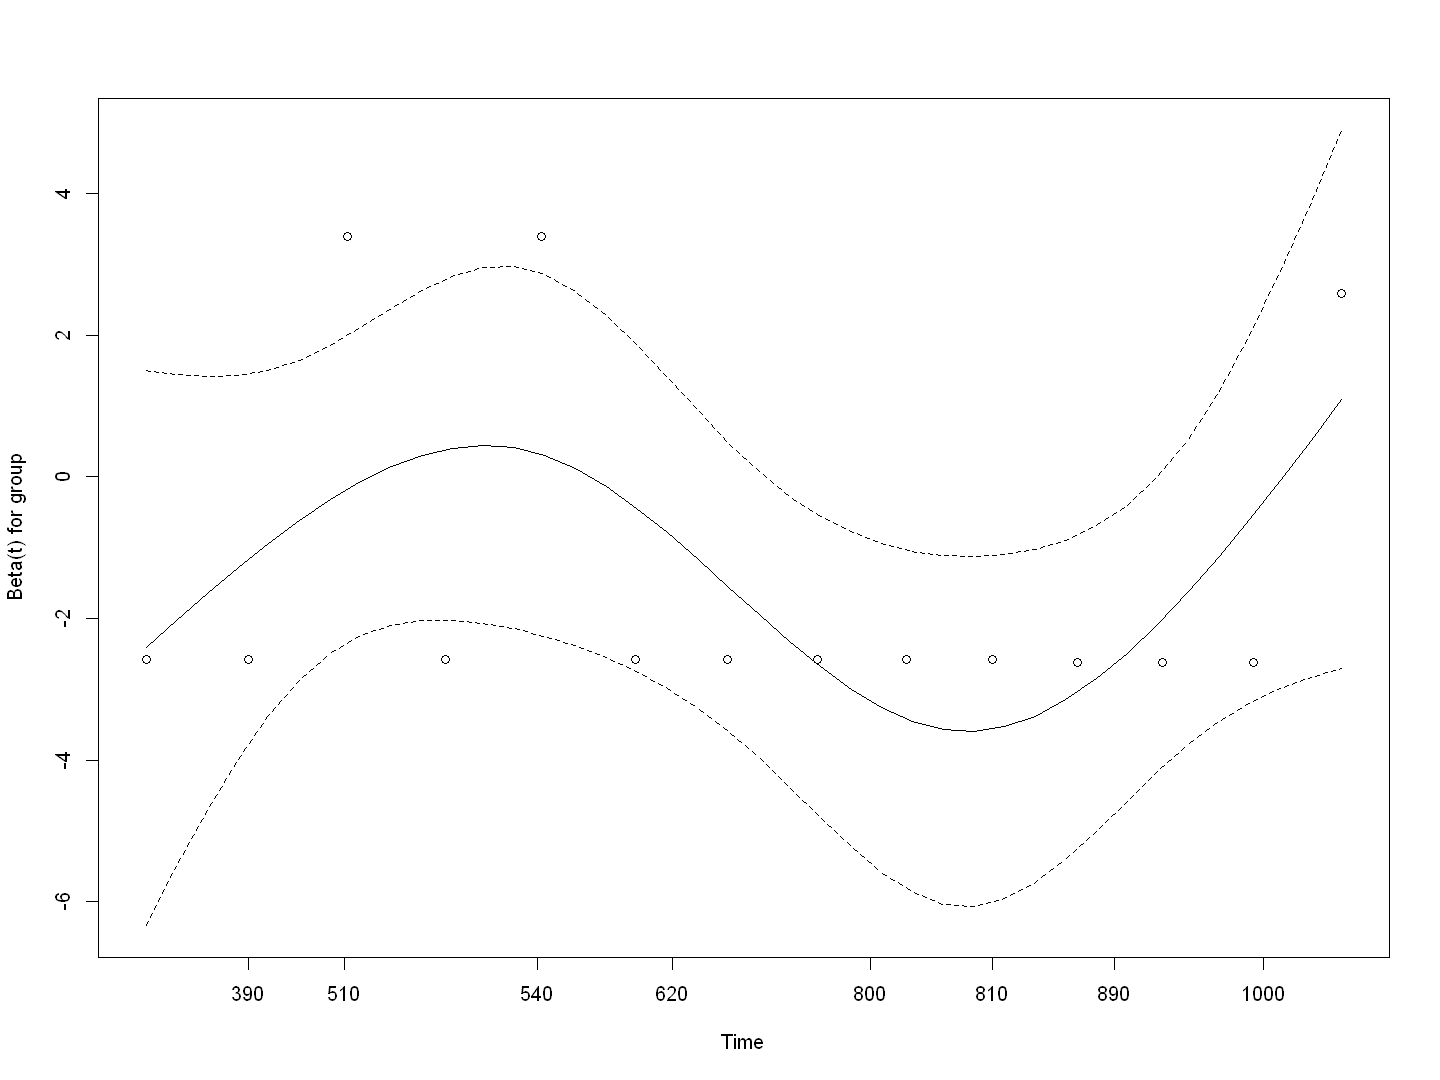

In [80]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(ag_fit_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


## 4. PRENTICE-WILLIAMS-PETERSON (PWP) MODEL  (ordered recurring events)

### Все группы

In [81]:
# Conditions on prior event â€” models k-th re-operation separately.
# stratify by event number so each stratum gets its own baseline hazard.

# Limit to events 1-3 (small strata beyond that)
pwp_df <- long_df |>
  filter(event_num <= 3) |>
  dplyr::mutate(strata = factor(event_num))

pwp_fit <- coxph(
  Surv(tstart, tstop, status) ~ group + strata(strata) + cluster(id),
  data   = pwp_df,
  method = "efron"
)
cat("\nPWP model summary:\n")
print(summary(pwp_fit))



PWP model summary:


Call:
coxph(formula = Surv(tstart, tstop, status) ~ group + strata(strata), 
    data = pwp_df, method = "efron", cluster = id)

  n= 63, number of events= 14 
   (1 observation deleted due to missingness)

            coef exp(coef) se(coef) robust se      z Pr(>|z|)  
groupОГ1 -1.2082    0.2987   0.7976    0.6855 -1.762    0.078 .
groupОГ2 -1.6635    0.1895   1.0484    1.0195 -1.632    0.103  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2987      3.347   0.07794     1.145
groupОГ2    0.1895      5.278   0.02569     1.397

Concordance= 0.663  (se = 0.066 )
Likelihood ratio test= 5.54  on 2 df,   p=0.06
Wald test            = 5.25  on 2 df,   p=0.07
Score (logrank) test = 5.15  on 2 df,   p=0.08,   Robust = 4.76  p=0.09

  (Note: the likelihood ratio and score tests assume independence of
     observations within a cluster, the Wald and robust score tests do not).



Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group    1.2  2 0.55
GLOBAL   1.2  2 0.55


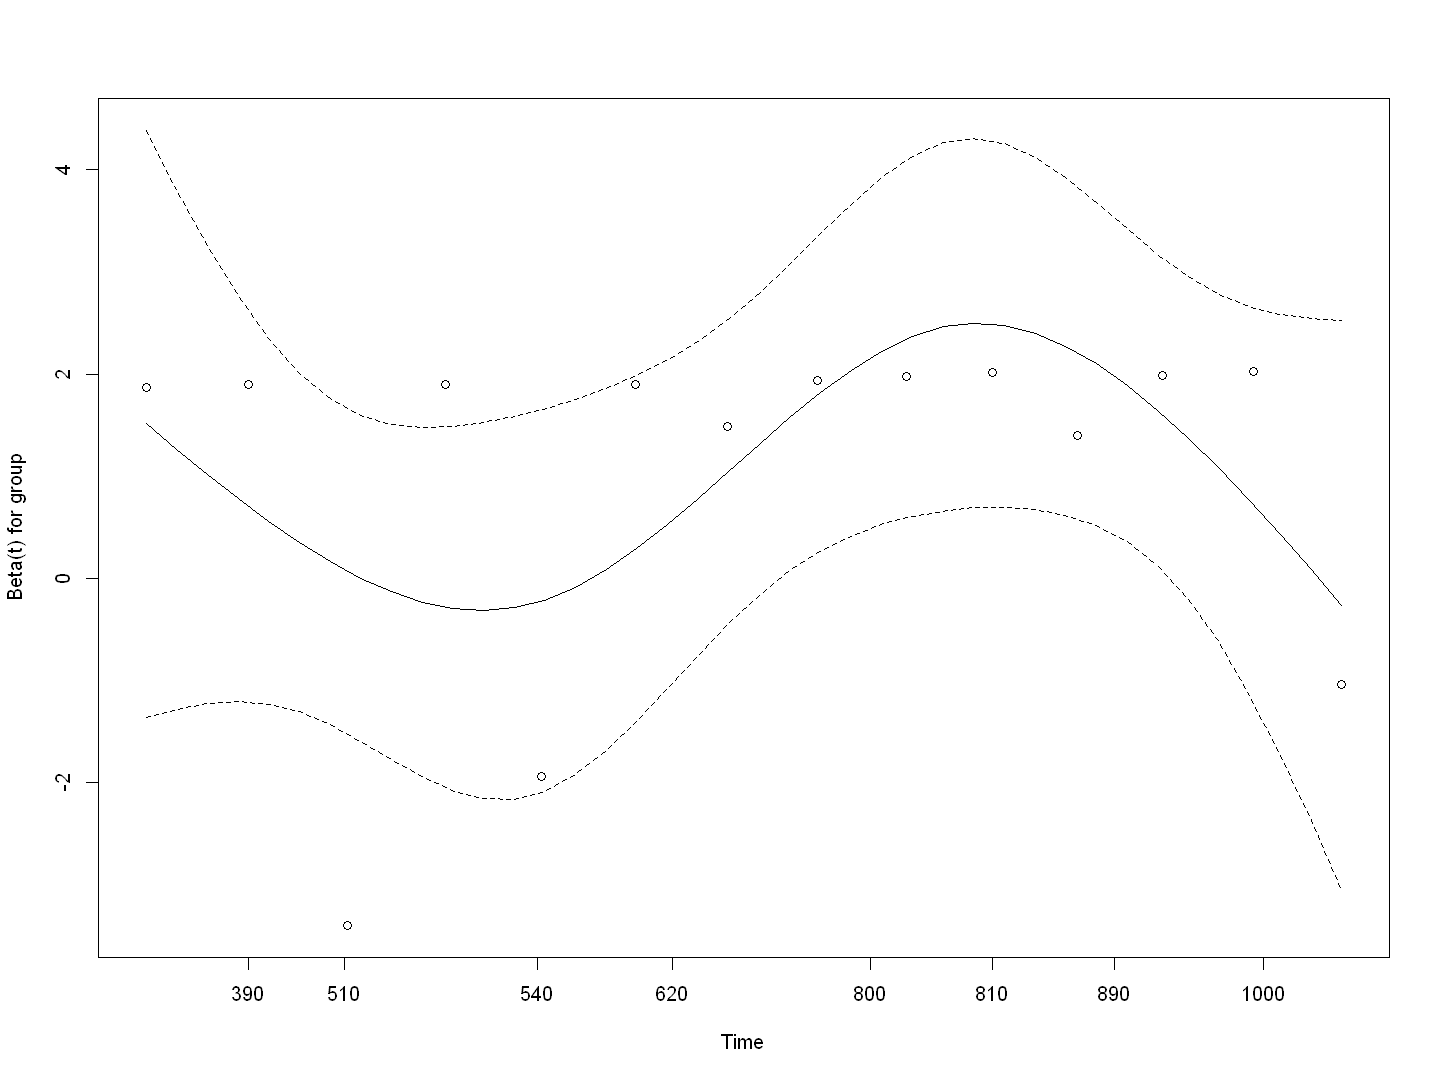

In [82]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(pwp_fit)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


In [83]:
# Per-stratum (per event number) analysis
cat("\nPer-event-number HRs:\n")
for (k in 1:3) {
  df_k <- long_df |> filter(event_num == k)
  if (sum(df_k$status) < 5) next # skip if too few events
  fit_k <- coxph(Surv(tstart, tstop, status) ~ group + cluster(id), data = df_k)
  s <- summary(fit_k)
  hr <- round(s$conf.int[1, 1], 3)
  lo <- round(s$conf.int[1, 3], 3)
  hi <- round(s$conf.int[1, 4], 3)
  pv <- round(s$coefficients[1, 5], 4)
  cat(sprintf(
    "  Event %d: HR = %.3f (95%% CI %.3fâ€“%.3f), p = %.4f\n",
    k, hr, lo, hi, pv
  ))
}



Per-event-number HRs:


  Event 1: HR = 0.326 (95% CI 0.074â€“1.434), p = -1.4828


#### ОГ1+ОГ2 vs КГ

In [84]:
pwp_df_og <- long_df_og |>
  filter(event_num <= 3) |>
  dplyr::mutate(strata = factor(event_num))

pwp_fit_og <- coxph(
  Surv(tstart, tstop, status) ~ group + strata(strata) + cluster(id),
  data   = pwp_df_og,
  method = "efron"
)
cat("\nPWP model summary — ОГ combined:\n")
print(summary(pwp_fit_og))



PWP model summary — ОГ combined:


Call:
coxph(formula = Surv(tstart, tstop, status) ~ group + strata(strata), 
    data = pwp_df_og, method = "efron", cluster = id)

  n= 63, number of events= 14 
   (1 observation deleted due to missingness)

           coef exp(coef) se(coef) robust se      z Pr(>|z|)  
groupОГ -1.3914    0.2487   0.6616    0.6000 -2.319   0.0204 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2487       4.02   0.07673    0.8063

Concordance= 0.663  (se = 0.063 )
Likelihood ratio test= 5.4  on 1 df,   p=0.02
Wald test            = 5.38  on 1 df,   p=0.02
Score (logrank) test = 5.11  on 1 df,   p=0.02,   Robust = 4.63  p=0.03

  (Note: the likelihood ratio and score tests assume independence of
     observations within a cluster, the Wald and robust score tests do not).



Test of PH assumption:


       chisq df    p
group  0.092  1 0.76
GLOBAL 0.092  1 0.76


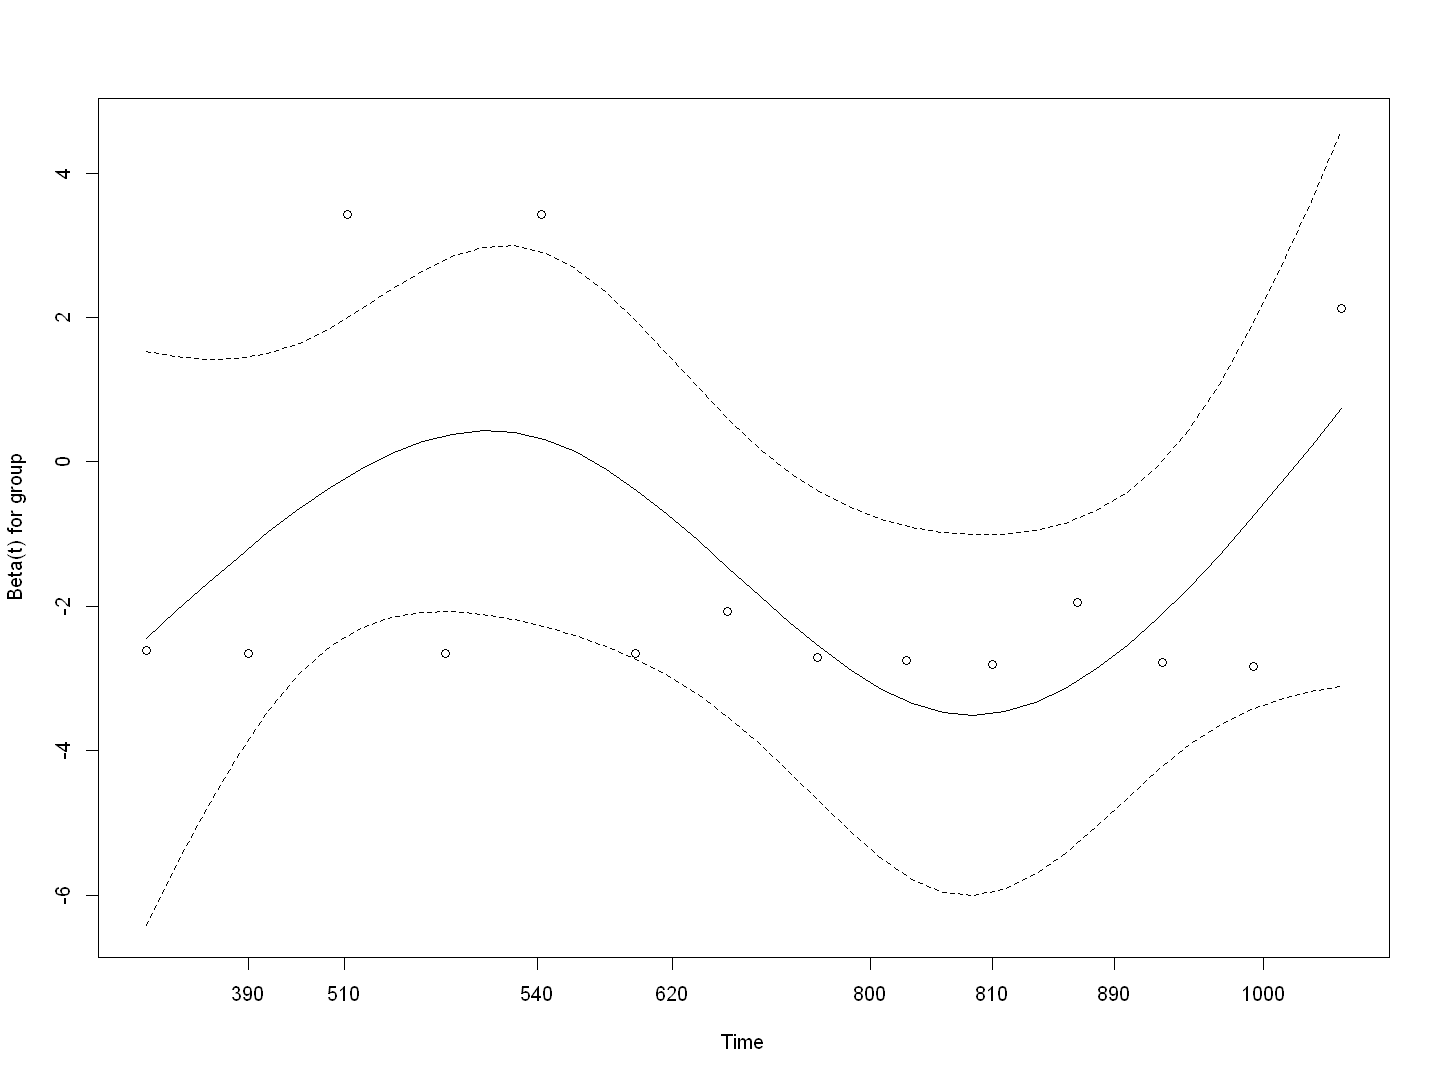

In [85]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(pwp_fit_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


In [86]:
cat("\nPer-event-number HRs — ОГ combined:\n")
for (k in 1:3) {
  df_k <- long_df_og |> filter(event_num == k)
  if (sum(df_k$status) < 5) next
  fit_k <- coxph(Surv(tstart, tstop, status) ~ group + cluster(id), data = df_k)
  s <- summary(fit_k)
  hr <- round(s$conf.int[1, 1], 3)
  lo <- round(s$conf.int[1, 3], 3)
  hi <- round(s$conf.int[1, 4], 3)
  pv <- round(s$coefficients[1, 5], 4)
  cat(sprintf("  Event %d: HR = %.3f (95%% CI %.3f\u2013%.3f), p = %.4f\n", k, hr, lo, hi, pv))
}



Per-event-number HRs — ОГ combined:


  Event 1: HR = 0.273 (95% CI 0.075–0.994), p = -1.9694


## 5. NEGATIVE BINOMIAL REGRESSION  (total re-operation count)

### Все группы

In [87]:
# offset(log(followup)) accounts for different observation lengths

nb_fit <- glm.nb(
  n_reops ~ group + offset(log(followup)),
  data = patient_df
)
cat("\nNegative Binomial model summary:\n")
print(summary(nb_fit))

# Rate ratio with CIs
rr <- exp(coef(nb_fit))
rr_ci <- exp(confint(nb_fit))
cat("\nRate Ratios (relative to Group A):\n")
print(cbind(RR = round(rr, 3), round(rr_ci, 3)))

cat(sprintf(
  "\nGroup B has %.1f%% %s re-operations per unit time compared to Group A\n",
  abs(1 - rr["groupB"]) * 100,
  ifelse(rr["groupB"] < 1, "fewer", "more")
))



Negative Binomial model summary:



Call:
glm.nb(formula = n_reops ~ group + offset(log(followup)), data = patient_df, 
    init.theta = 1894.980869, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -7.8308     0.3015 -25.969   <2e-16 ***
groupОГ1     -1.1797     0.7687  -1.535    0.125    
groupОГ2     -1.6718     1.0445  -1.601    0.109    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(1894.981) family taken to be 1)

    Null deviance: 43.454  on 49  degrees of freedom
Residual deviance: 37.826  on 47  degrees of freedom
AIC: 71.061

Number of Fisher Scoring iterations: 1


              Theta:  1895 
          Std. Err.:  72474 
Warning while fitting theta: iteration limit reached 

 2 x log-likelihood:  -63.061 


Waiting for profiling to be done...




Rate Ratios (relative to Group A):


               RR 2.5 % 97.5 %
(Intercept) 0.000 0.000  0.001
groupОГ1    0.307 0.048  1.145
groupОГ2    0.188 0.010  0.966



Group B has NA% NA re-operations per unit time compared to Group A


#### ОГ1+ОГ2 vs КГ

In [88]:
nb_fit_og <- glm.nb(
  n_reops ~ group + offset(log(followup)),
  data = patient_df_og
)
cat("\nNegative Binomial model summary — ОГ combined:\n")
print(summary(nb_fit_og))

rr_og <- exp(coef(nb_fit_og))
rr_ci_og <- exp(confint(nb_fit_og))
cat("\nRate Ratios (ОГ vs КГ):\n")
print(cbind(RR = round(rr_og, 3), round(rr_ci_og, 3)))



Negative Binomial model summary — ОГ combined:



Call:
glm.nb(formula = n_reops ~ group + offset(log(followup)), data = patient_df_og, 
    init.theta = 2043.097505, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -7.8308     0.3015 -25.969   <2e-16 ***
groupОГ      -1.3719     0.6514  -2.106   0.0352 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(2043.098) family taken to be 1)

    Null deviance: 43.454  on 49  degrees of freedom
Residual deviance: 37.995  on 48  degrees of freedom
AIC: 69.23

Number of Fisher Scoring iterations: 1


              Theta:  2043 
          Std. Err.:  82812 
Warning while fitting theta: iteration limit reached 

 2 x log-likelihood:  -63.23 


Waiting for profiling to be done...




Rate Ratios (ОГ vs КГ):


               RR 2.5 % 97.5 %
(Intercept) 0.000 0.000  0.001
groupОГ     0.254 0.057  0.812


## 6. MEAN CUMULATIVE FUNCTION (MCF)

### Все группы

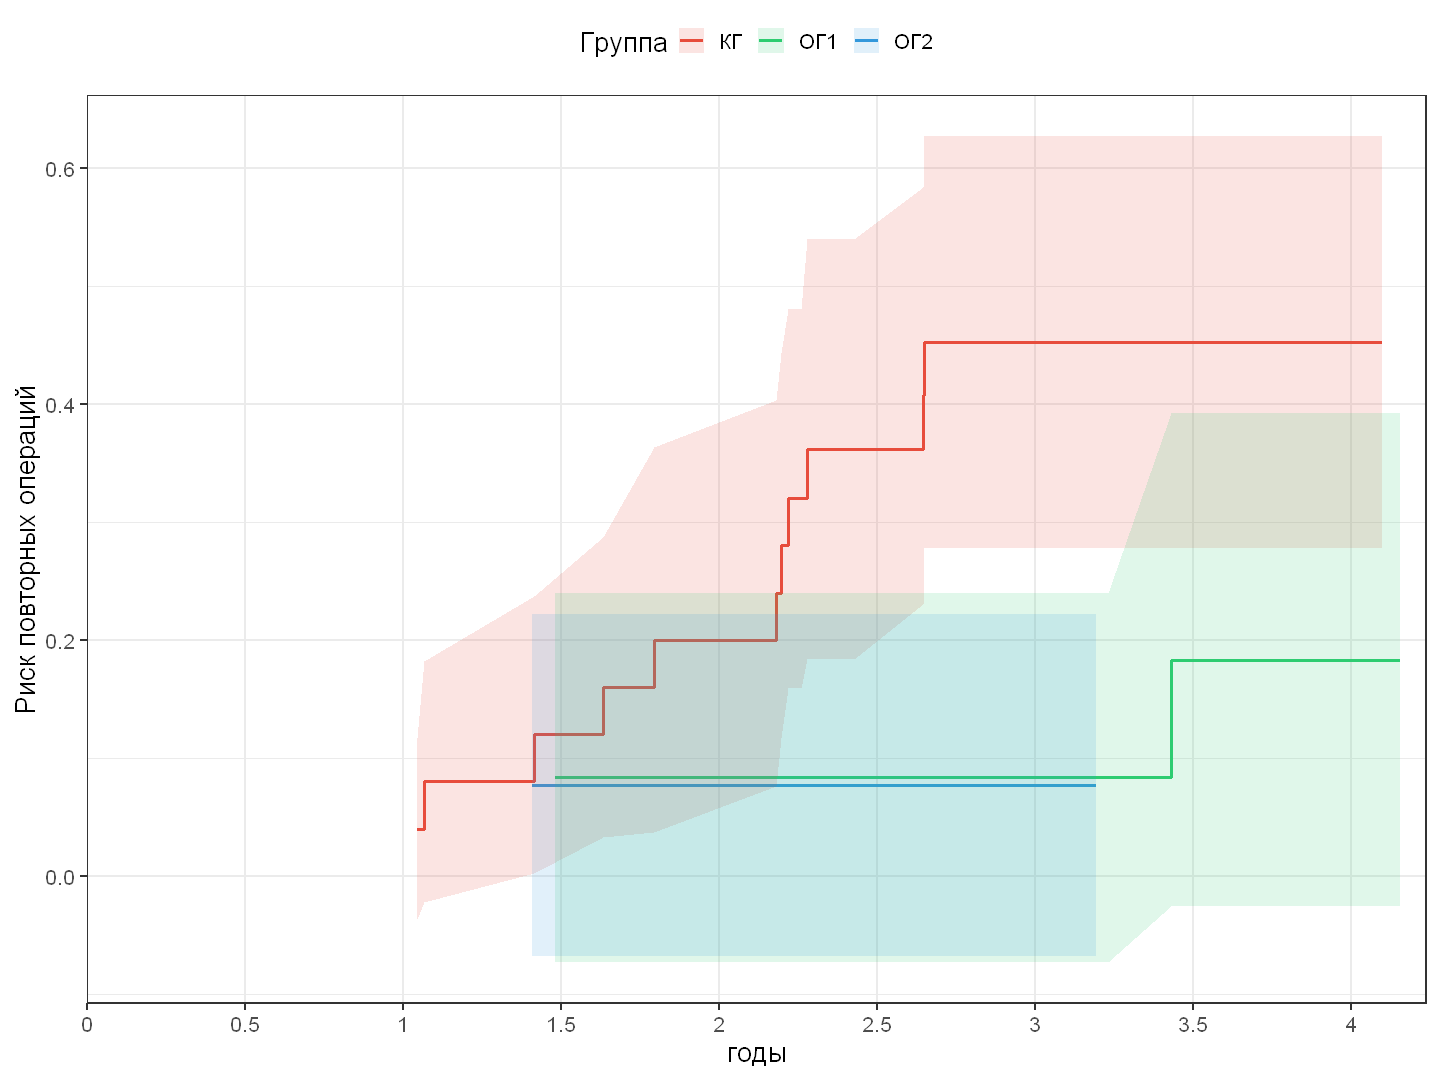

In [89]:
# Uses the Nelson-Aalen estimator applied to recurring events.
# survfit() with id= argument computes the MCF.

mcf_fit <- survfit(
  Surv(tstart, tstop, status) ~ group,
  data = long_df,
  id   = id # identifies subject; cumhaz gives the MCF for recurring events
)

# Extract MCF data for all groups dynamically
mcf_data <- bind_rows(lapply(seq_along(group_levels), function(i) {
  tibble(
    time  = mcf_fit[i]$time,
    mcf   = mcf_fit[i]$cumhaz,
    lower = mcf_fit[i]$cumhaz - 1.96 * mcf_fit[i]$std.err,
    upper = mcf_fit[i]$cumhaz + 1.96 * mcf_fit[i]$std.err,
    group = group_levels[i]
  )
}))

mcf_plot <- ggplot(mcf_data, aes(x = time, y = mcf, color = group, fill = group)) +
  geom_step(linewidth = 1) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  scale_color_manual(values = group_palette) +
  scale_fill_manual(values = group_palette) +
  scale_x_continuous(
    limits       = c(0, NA),
    breaks       = seq(0, max(mcf_data$time), by = six_months_days),
    labels       = function(x) round(x / 365.25, 1),
    minor_breaks = NULL,
    expand       = expansion(mult = c(0, 0.02))
  ) +
  labs(
    # title    = "Среднее значение кумулятивной функции (MCF) повторных операций",
    # subtitle = "Ожидаемое кумулятивное количество повторных операций на пациента с течением времени",
    x        = "годы",
    y        = "Риск повторных операций",
    color    = "Группа",
    fill     = "Группа"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(mcf_plot)


#### ОГ1+ОГ2 vs КГ

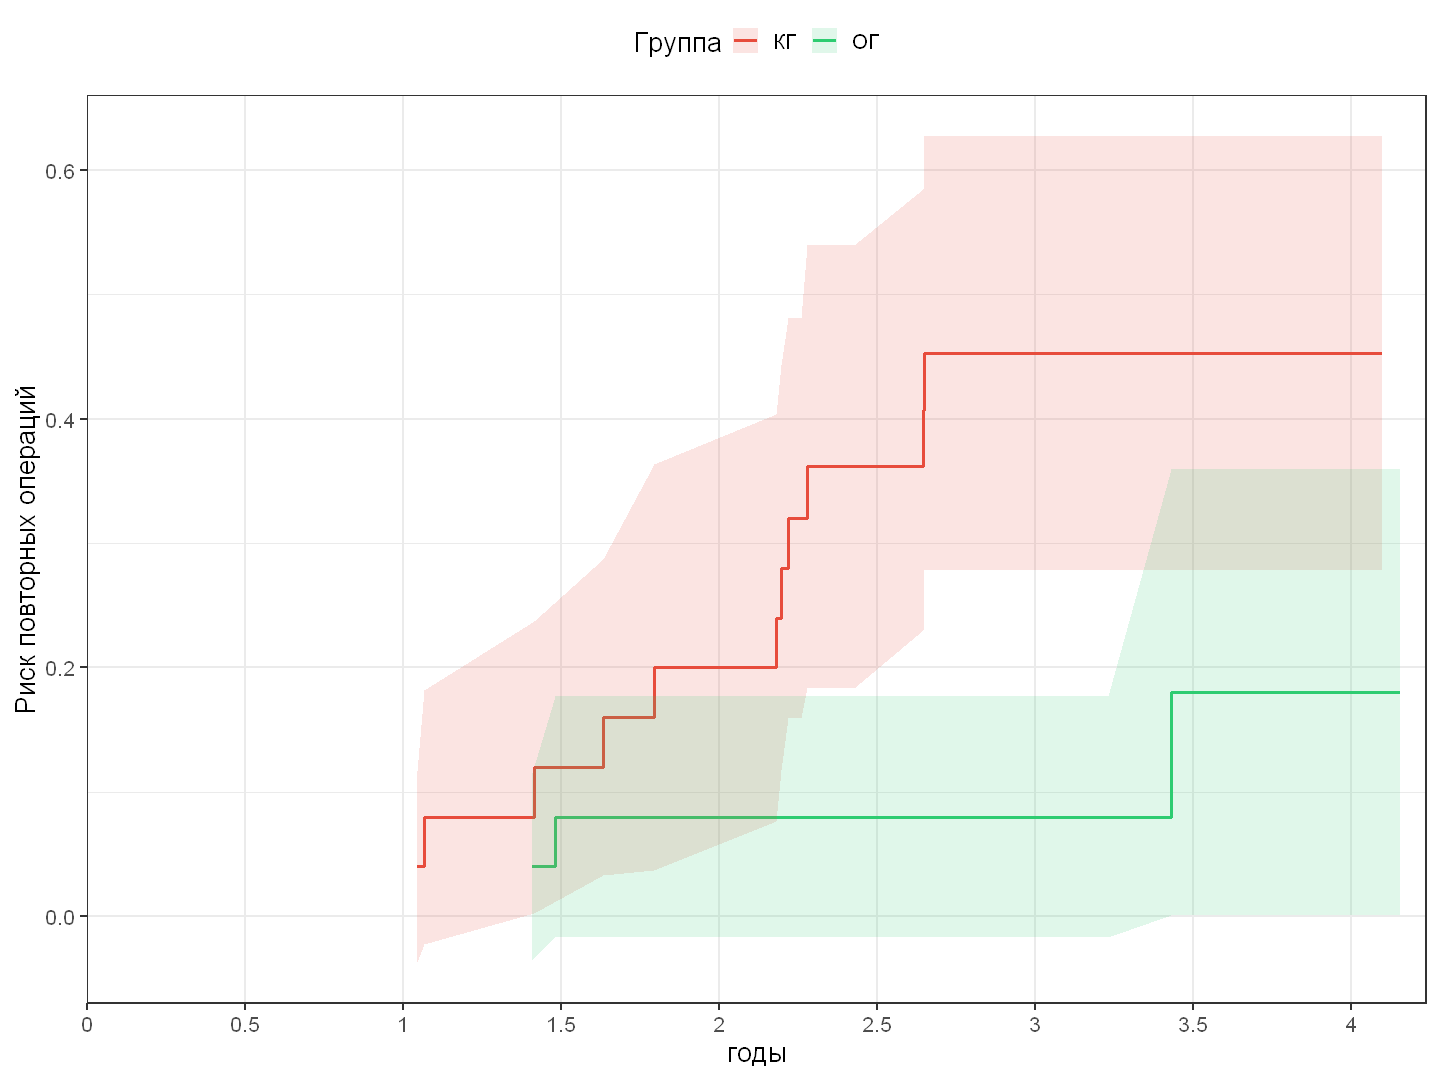

In [90]:
mcf_fit_og <- survfit(
  Surv(tstart, tstop, status) ~ group,
  data = long_df_og,
  id   = id
)

mcf_data_og <- bind_rows(lapply(seq_along(group_levels_og), function(i) {
  tibble(
    time  = mcf_fit_og[i]$time,
    mcf   = mcf_fit_og[i]$cumhaz,
    lower = mcf_fit_og[i]$cumhaz - 1.96 * mcf_fit_og[i]$std.err,
    upper = mcf_fit_og[i]$cumhaz + 1.96 * mcf_fit_og[i]$std.err,
    group = group_levels_og[i]
  )
}))

mcf_plot_og <- ggplot(mcf_data_og, aes(x = time, y = mcf, color = group, fill = group)) +
  geom_step(linewidth = 1) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  scale_color_manual(values = group_palette_og) +
  scale_fill_manual(values = group_palette_og) +
  scale_x_continuous(
    limits       = c(0, NA),
    breaks       = seq(0, max(mcf_data_og$time), by = six_months_days),
    labels       = function(x) round(x / 365.25, 1),
    minor_breaks = NULL,
    expand       = expansion(mult = c(0, 0.02))
  ) +
  labs(
    x     = "годы",
    y     = "Риск повторных операций",
    color = "Группа",
    fill  = "Группа"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(mcf_plot_og)


## FOREST PLOT — all effect estimates in one figure

### Все группы

Waiting for profiling to be done...



`height` was translated to `width`.


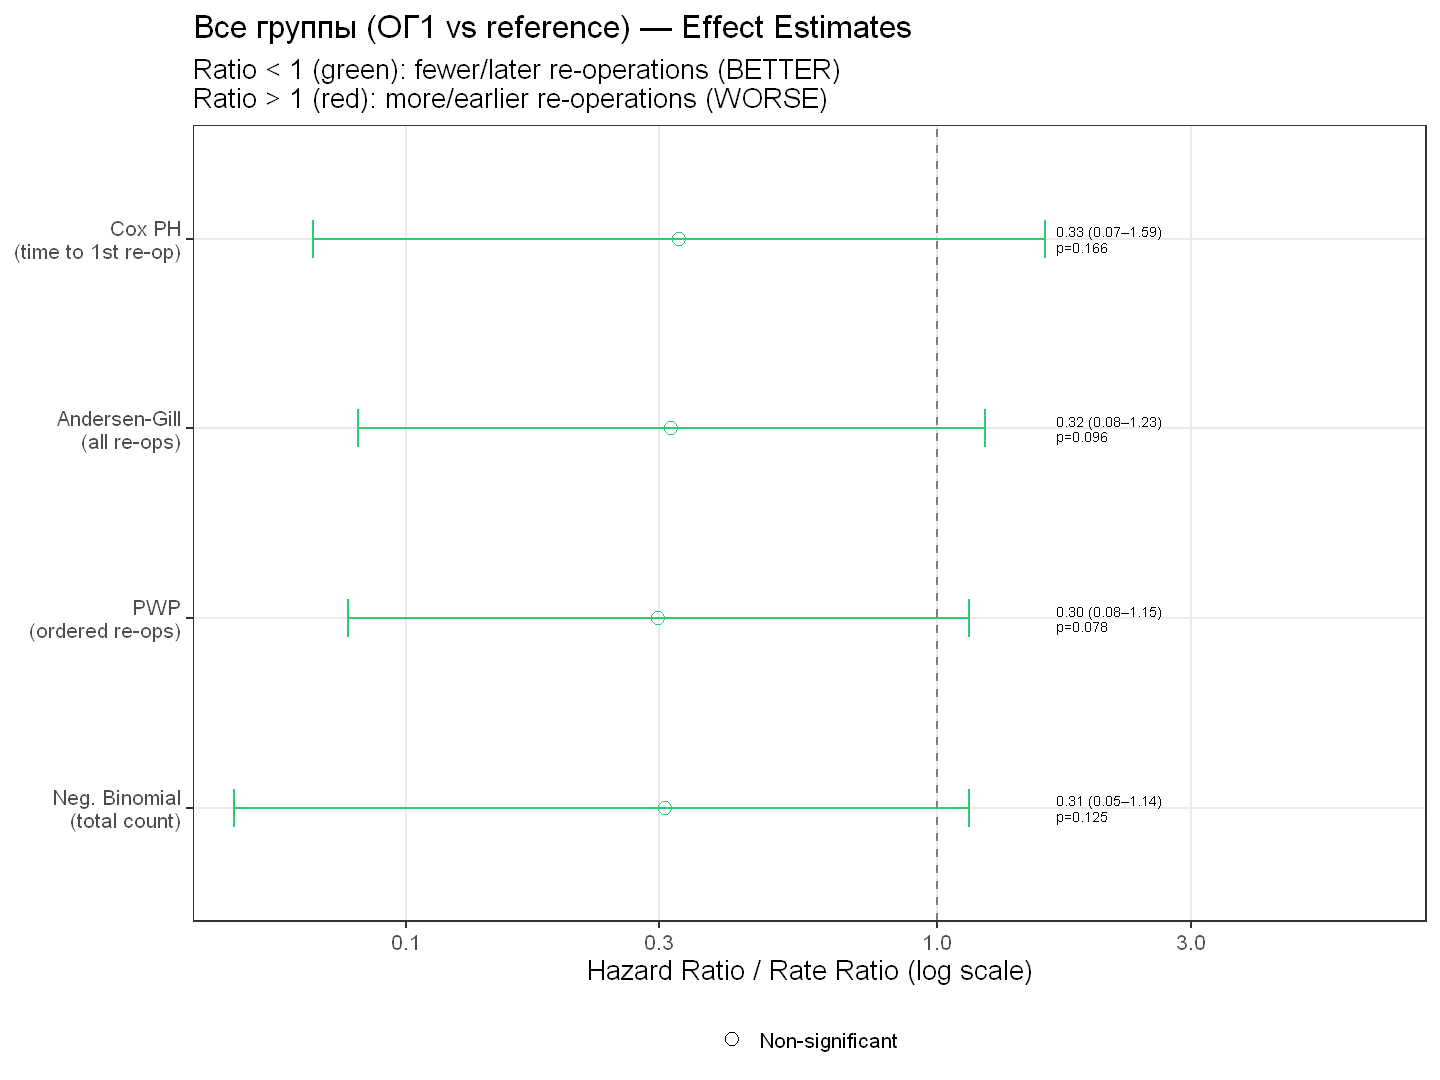

In [91]:
# All models report a ratio (HR or RR) relative to the reference group.
#   ratio < 1  →  group has FEWER / LATER re-operations  (better)
#   ratio > 1  →  group has MORE  / EARLIER re-operations (worse)

# ---- Helper: extract HR/CI/p from a coxph or glm model ----
extract_hr <- function(fit, coef_row = 1) {
  s <- summary(fit)
  ci <- exp(confint(fit))
  if ("conf.int" %in% names(s)) {
    hr <- s$conf.int[coef_row, 1]
    lo <- s$conf.int[coef_row, 3]
    hi <- s$conf.int[coef_row, 4]
    pv <- s$coefficients[coef_row, ncol(s$coefficients)]
  } else {
    hr <- exp(s$coefficients[coef_row, 1])
    lo <- ci[coef_row, 1]
    hi <- ci[coef_row, 2]
    pv <- s$coefficients[coef_row, 4]
  }
  list(est = hr, lo = lo, hi = hi, p = pv)
}

# ---- Helper: extract NB rate ratio (first group coefficient) ----
extract_nb <- function(nb_model) {
  s <- summary(nb_model)
  ci <- exp(confint(nb_model))
  grp_rows <- grep("^group", rownames(s$coefficients))
  if (length(grp_rows) == 0) stop("No 'group' coefficient found in NB model")
  rname <- rownames(s$coefficients)[grp_rows[1]]
  list(
    est   = exp(s$coefficients[rname, 1]),
    lo    = ci[rname, 1],
    hi    = ci[rname, 2],
    p     = s$coefficients[rname, 4],
    label = sub("^group", "", rname)
  )
}

# ---- Helper: build a forest plot ----
make_forest_plot <- function(cox_e, ag_e, pwp_e, nb_e, title_str) {
  model_labels <- c(
    "Cox PH\n(time to 1st re-op)",
    "Andersen-Gill\n(all re-ops)",
    "PWP\n(ordered re-ops)",
    "Neg. Binomial\n(total count)"
  )
  fdf <- tibble::tibble(
    Model    = factor(model_labels, levels = rev(model_labels)),
    Estimate = c(cox_e$est, ag_e$est, pwp_e$est, nb_e$est),
    Lower    = c(cox_e$lo, ag_e$lo, pwp_e$lo, nb_e$lo),
    Upper    = c(cox_e$hi, ag_e$hi, pwp_e$hi, nb_e$hi),
    P        = c(cox_e$p, ag_e$p, pwp_e$p, nb_e$p)
  ) |>
    dplyr::mutate(
      label = sprintf(
        "%.2f (%.2f\u2013%.2f)\np=%s",
        Estimate, Lower, Upper,
        ifelse(P < 0.001, "<0.001", sprintf("%.3f", P))
      ),
      sig = ifelse(P < 0.05, "Significant", "Non-significant"),
      colour = ifelse(Estimate < 1, "#2ECC71", "#E74C3C")
    )

  ggplot2::ggplot(fdf, aes(x = Estimate, y = Model, xmin = Lower, xmax = Upper)) +
    ggplot2::geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50") +
    ggplot2::geom_errorbarh(aes(colour = colour), height = 0.2, linewidth = 0.8) +
    ggplot2::geom_point(aes(colour = colour, shape = sig), size = 3.5) +
    ggplot2::geom_text(aes(x = max(Upper) * 1.05, label = label),
      hjust = 0, size = 3, lineheight = 0.9
    ) +
    ggplot2::scale_colour_identity() +
    ggplot2::scale_shape_manual(values = c("Significant" = 16, "Non-significant" = 1)) +
    ggplot2::scale_x_continuous(
      expand = ggplot2::expansion(mult = c(0.05, 0.45)),
      trans  = "log10"
    ) +
    labs(
      title    = title_str,
      subtitle = "Ratio < 1 (green): fewer/later re-operations (BETTER)\nRatio > 1 (red): more/earlier re-operations (WORSE)",
      x        = "Hazard Ratio / Rate Ratio (log scale)",
      y        = NULL,
      shape    = NULL
    ) +
    ggplot2::theme_bw(base_size = 16) +
    theme(
      legend.position = "bottom",
      panel.grid.minor = element_blank()
    )
}

# ---- Все группы: extract estimates ----
cox_e <- extract_hr(cox_fit)
ag_e <- extract_hr(ag_fit)
pwp_e <- extract_hr(pwp_fit)
nb_e <- extract_nb(nb_fit)

forest_plot <- make_forest_plot(
  cox_e, ag_e, pwp_e, nb_e,
  title_str = sprintf(
    "Все группы (%s vs reference) \u2014 Effect Estimates",
    nb_e$label
  )
)
print(forest_plot)


#### ОГ1+ОГ2 vs КГ

Waiting for profiling to be done...



`height` was translated to `width`.


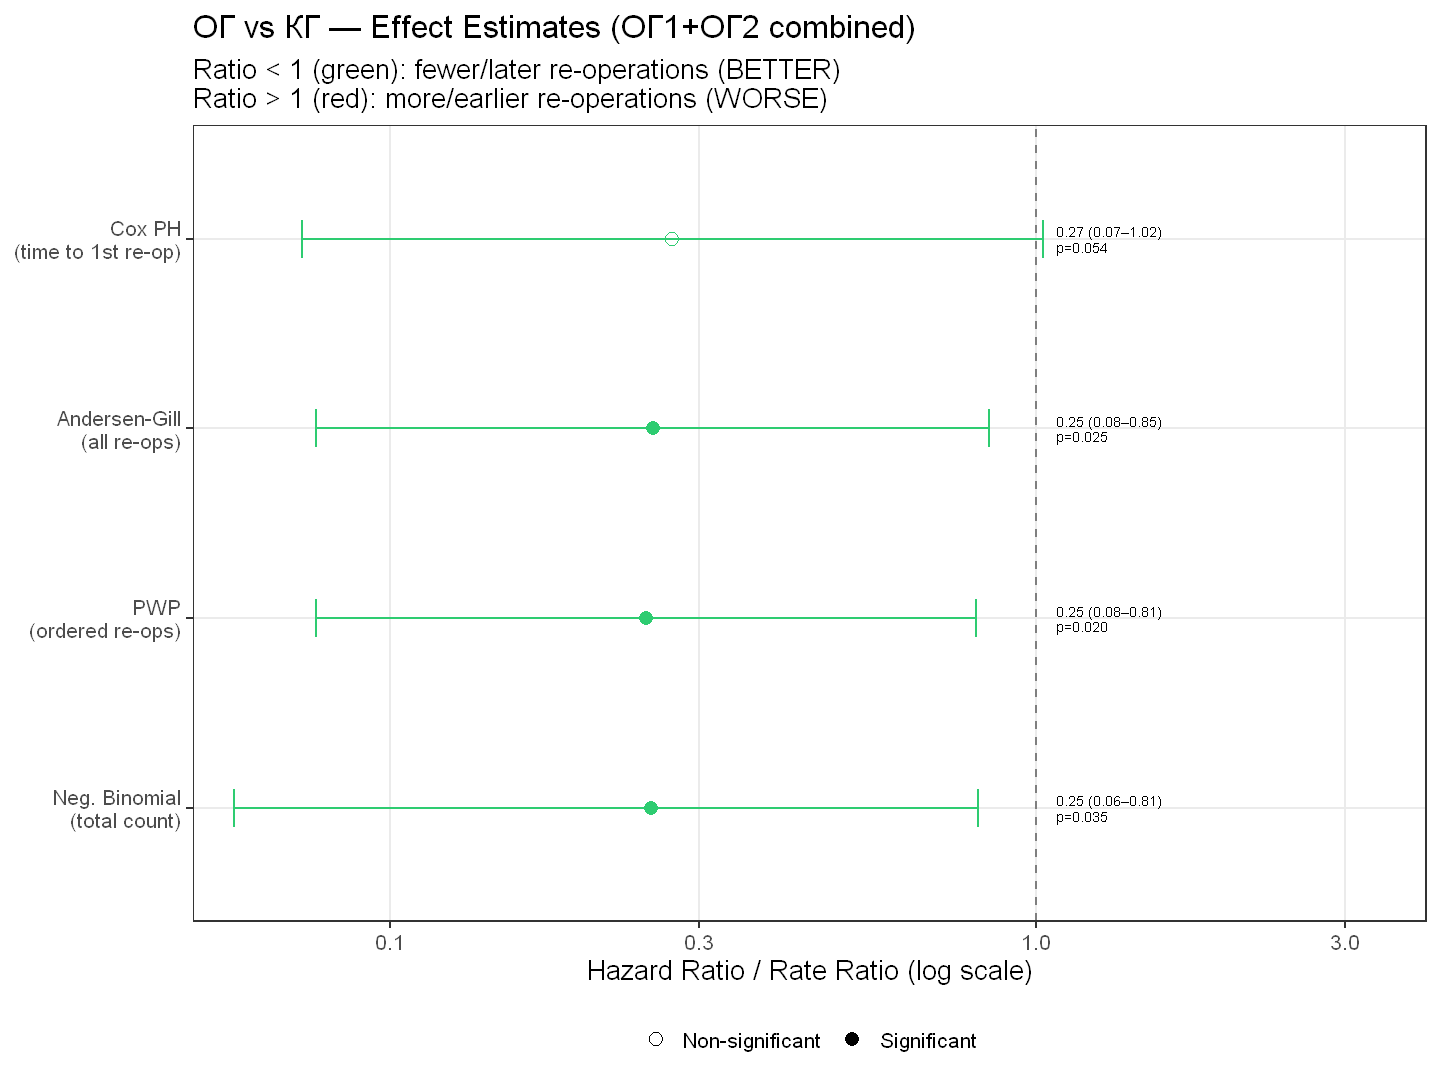

In [92]:
# ---- ОГ combined: extract estimates ----
cox_e_og <- extract_hr(cox_fit_og)
ag_e_og <- extract_hr(ag_fit_og)
pwp_e_og <- extract_hr(pwp_fit_og)
nb_e_og <- extract_nb(nb_fit_og)

forest_plot_og <- make_forest_plot(
  cox_e_og, ag_e_og, pwp_e_og, nb_e_og,
  title_str = sprintf(
    "%s vs \u041a\u0413 \u2014 Effect Estimates (\u041e\u04131+\u041e\u04132 combined)",
    nb_e_og$label
  )
)
print(forest_plot_og)


## GROUP COMPARISON SUMMARY 

### Все группы

In [93]:
# ---- Helper: interpret a single ratio ----
interpret <- function(label, est, lo, hi, p, ref, grp, unit = "повторные операции") {
  direction <- if (est < 1) "МЕНЬШЕ" else "БОЛЬШЕ"
  verdict <- if (est < 1) "ЛУЧШЕ" else "ХУЖЕ"
  sig_str <- if (p < 0.05) {
    sprintf("(p=%.4f, статистически значимо)", p)
  } else {
    sprintf("(p=%.4f, статистически незначимо)", p)
  }
  pct <- abs(1 - est) * 100
  cat(sprintf(
    "  %-35s  HR/RR = %.2f (95%% ДИ %.2f\u2013%.2f)\n    \u2192 %s имеет %.1f%% %s %s чем %s  [%s]  %s\n\n",
    label, est, lo, hi, grp, pct, direction, unit, ref, verdict, sig_str
  ))
}

# ---- Helper: print verdict block ----
print_verdict <- function(ests_list) {
  all_ests <- sapply(ests_list, `[[`, "est")
  any_sig <- any(sapply(ests_list, `[[`, "p") < 0.05)
  all_same <- all(all_ests < 1) || all(all_ests > 1)
  cat("--- ОБЩЕЕ ЗАКЛЮЧЕНИЕ ---\n")
  if (all_same && any_sig) {
    dir <- if (all(all_ests < 1)) "МЕНЬШЕ" else "БОЛЬШЕ"
    cat(sprintf("  Все модели последовательно показывают одно направление (%s повторные операции)\n  и как минимум один результат статистически значим.\n", dir))
  } else if (all_same && !any_sig) {
    dir <- if (all(all_ests < 1)) "МЕНЬШЕ" else "БОЛЬШЕ"
    cat(sprintf("  Все модели указывают в одном направлении (%s повторные операции)\n  но ни один результат не достигает статистической значимости.\n  Рассмотрите возможность увеличения размера выборки.\n", dir))
  } else {
    cat("  Результаты непоследовательны между моделями.\n")
    cat("  Проверьте предположения моделей и качество данных.\n")
  }
}

# ---- Все группы ----
km_med <- surv_median(km_fit)
cat("--- Время до 1-й повторной операции (медианы Kaplan-Meier) ---\n")
for (i in seq_len(nrow(km_med))) {
  cat(sprintf(
    "  %s:  медиана = %.1f дней  (95%% ДИ %.1f\u2013%.1f)\n",
    km_med$strata[i], km_med$median[i],
    km_med$lower[i], km_med$upper[i]
  ))
}
p_lr <- pchisq(logrank$chisq, df = length(logrank$n) - 1, lower.tail = FALSE)
cat(sprintf(
  "  Log-rank p-value: %.4f  %s\n\n",
  p_lr,
  ifelse(p_lr < 0.05,
    "\u2192 Группы статистически значимо различаются.",
    "\u2192 Статистически значимых различий нет."
  )
))

ref_all <- levels(first_reop_df$group)[1]
grp_all <- nb_e$label
cat(sprintf("--- Оценка эффекта (опорная группа: %s) ---\n", ref_all))
interpret("Cox PH (время до 1-й повторной операции)", cox_e$est, cox_e$lo, cox_e$hi, cox_e$p, ref_all, grp_all)
interpret("Andersen-Gill (все повторные операции)", ag_e$est, ag_e$lo, ag_e$hi, ag_e$p, ref_all, grp_all)
interpret("PWP (упорядоченные повторные операции)", pwp_e$est, pwp_e$lo, pwp_e$hi, pwp_e$p, ref_all, grp_all)
interpret("Neg. Binomial (общее количество)", nb_e$est, nb_e$lo, nb_e$hi, nb_e$p, ref_all, grp_all,
  unit = "повторные операции за единицу времени"
)
print_verdict(list(cox_e, ag_e, pwp_e, nb_e))


--- Время до 1-й повторной операции (медианы Kaplan-Meier) ---


  group=КГ:  медиана = NA дней  (95% ДИ 968.0–NA)
  group=ОГ1:  медиана = NA дней  (95% ДИ NA–NA)
  group=ОГ2:  медиана = NA дней  (95% ДИ NA–NA)


  Log-rank p-value: 0.1177  → Статистически значимых различий нет.



--- Оценка эффекта (опорная группа: КГ) ---


  Cox PH (время до 1-й повторной операции)  HR/RR = 0.33 (95% ДИ 0.07–1.59)
    → ОГ1 имеет 67.4% МЕНЬШЕ повторные операции чем КГ  [ЛУЧШЕ]  (p=0.1664, статистически незначимо)



  Andersen-Gill (все повторные операции)  HR/RR = 0.32 (95% ДИ 0.08–1.23)
    → ОГ1 имеет 68.4% МЕНЬШЕ повторные операции чем КГ  [ЛУЧШЕ]  (p=0.0962, статистически незначимо)



  PWP (упорядоченные повторные операции)  HR/RR = 0.30 (95% ДИ 0.08–1.15)
    → ОГ1 имеет 70.1% МЕНЬШЕ повторные операции чем КГ  [ЛУЧШЕ]  (p=0.0780, статистически незначимо)



  Neg. Binomial (общее количество)  HR/RR = 0.31 (95% ДИ 0.05–1.14)
    → ОГ1 имеет 69.3% МЕНЬШЕ повторные операции за единицу времени чем КГ  [ЛУЧШЕ]  (p=0.1249, статистически незначимо)



--- ОБЩЕЕ ЗАКЛЮЧЕНИЕ ---
  Все модели указывают в одном направлении (МЕНЬШЕ повторные операции)
  но ни один результат не достигает статистической значимости.
  Рассмотрите возможность увеличения размера выборки.


#### ОГ1+ОГ2 vs КГ

In [94]:
# ---- ОГ1+ОГ2 vs КГ ----
km_med_og <- surv_median(km_fit_og)
cat("--- Время до 1-й повторной операции (медианы Kaplan-Meier) ---\n")
for (i in seq_len(nrow(km_med_og))) {
  cat(sprintf(
    "  %s:  медиана = %.1f дней  (95%% ДИ %.1f\u2013%.1f)\n",
    km_med_og$strata[i], km_med_og$median[i],
    km_med_og$lower[i], km_med_og$upper[i]
  ))
}
p_lr_og <- pchisq(logrank_og$chisq, df = length(logrank_og$n) - 1, lower.tail = FALSE)
cat(sprintf(
  "  Log-rank p-value: %.4f  %s\n\n",
  p_lr_og,
  ifelse(p_lr_og < 0.05,
    "\u2192 Группы статистически значимо различаются.",
    "\u2192 Статистически значимых различий нет."
  )
))

ref_og <- levels(first_reop_df_og$group)[1]
grp_og <- nb_e_og$label
cat(sprintf("--- Оценка эффекта (опорная группа: %s) ---\n", ref_og))
interpret("Cox PH (время до 1-й повторной операции)", cox_e_og$est, cox_e_og$lo, cox_e_og$hi, cox_e_og$p, ref_og, grp_og)
interpret("Andersen-Gill (все повторные операции)", ag_e_og$est, ag_e_og$lo, ag_e_og$hi, ag_e_og$p, ref_og, grp_og)
interpret("PWP (упорядоченные повторные операции)", pwp_e_og$est, pwp_e_og$lo, pwp_e_og$hi, pwp_e_og$p, ref_og, grp_og)
interpret("Neg. Binomial (общее количество)", nb_e_og$est, nb_e_og$lo, nb_e_og$hi, nb_e_og$p, ref_og, grp_og,
  unit = "повторные операции за единицу времени"
)
print_verdict(list(cox_e_og, ag_e_og, pwp_e_og, nb_e_og))


--- Время до 1-й повторной операции (медианы Kaplan-Meier) ---


  group=КГ:  медиана = NA дней  (95% ДИ 968.0–NA)
  group=ОГ:  медиана = NA дней  (95% ДИ NA–NA)


  Log-rank p-value: 0.0396  → Группы статистически значимо различаются.



--- Оценка эффекта (опорная группа: КГ) ---


  Cox PH (время до 1-й повторной операции)  HR/RR = 0.27 (95% ДИ 0.07–1.02)
    → ОГ имеет 72.7% МЕНЬШЕ повторные операции чем КГ  [ЛУЧШЕ]  (p=0.0539, статистически незначимо)



  Andersen-Gill (все повторные операции)  HR/RR = 0.25 (95% ДИ 0.08–0.85)
    → ОГ имеет 74.5% МЕНЬШЕ повторные операции чем КГ  [ЛУЧШЕ]  (p=0.0254, статистически значимо)



  PWP (упорядоченные повторные операции)  HR/RR = 0.25 (95% ДИ 0.08–0.81)
    → ОГ имеет 75.1% МЕНЬШЕ повторные операции чем КГ  [ЛУЧШЕ]  (p=0.0204, статистически значимо)



  Neg. Binomial (общее количество)  HR/RR = 0.25 (95% ДИ 0.06–0.81)
    → ОГ имеет 74.6% МЕНЬШЕ повторные операции за единицу времени чем КГ  [ЛУЧШЕ]  (p=0.0352, статистически значимо)



--- ОБЩЕЕ ЗАКЛЮЧЕНИЕ ---
  Все модели последовательно показывают одно направление (МЕНЬШЕ повторные операции)
  и как минимум один результат статистически значим.


# FOLLOW UP TIME HARD CUT-OFF: 3 YEARS

## Cut follow-up at 3 years

In [95]:
# ---- 3-year hard cut-off censoring ----
# All re-operations occurring AFTER this threshold are treated as censored.
cutoff_3y <- 3 * 365.25 # 1095.75 days

# --- first_reop_df / first_reop_df_og ---
# (wide format: one row per patient, time to first re-op)
first_reop_df <- first_reop_df |>
  dplyr::mutate(
    event_first = ifelse(time_first > cutoff_3y, 0L, event_first),
    time_first  = pmin(time_first, cutoff_3y)
  )

first_reop_df_og <- first_reop_df_og |>
  dplyr::mutate(
    event_first = ifelse(time_first > cutoff_3y, 0L, event_first),
    time_first  = pmin(time_first, cutoff_3y)
  )

# --- patient_df / patient_df_og ---
# (counts of re-ops + follow-up time; used in Negative Binomial regression)
censor_patient <- function(df, cut) {
  df |>
    dplyr::mutate(
      reop1_in = reop1 == 1 & !is.na(date_reoperation1) &
        days_diff(date_operation, date_reoperation1) <= cut,
      reop2_in = reop2 == 1 & !is.na(date_reoperation2) &
        days_diff(date_operation, date_reoperation2) <= cut,
      n_reops = as.integer(reop1_in) + as.integer(reop2_in),
      followup = pmin(followup, cut)
    ) |>
    select(-reop1_in, -reop2_in)
}

patient_df <- censor_patient(patient_df, cutoff_3y)
patient_df_og <- censor_patient(patient_df_og, cutoff_3y)

# --- long_df / long_df_og ---
# (counting-process format; used in Andersen-Gill, PWP, MCF)
censor_long <- function(df, cut) {
  df |>
    filter(tstart < cut) |>
    dplyr::mutate(
      status = ifelse(tstop > cut, 0L, status),
      tstop  = pmin(tstop, cut)
    )
}

long_df <- censor_long(long_df, cutoff_3y)
long_df_og <- censor_long(long_df_og, cutoff_3y)

# head(first_reop_df, n=50)


## Beeswarm plots: Follow-up times (3-year cut-off)
Visualize follow-up times for all patients, by group, and by combined ОГ1+ОГ2 vs КГ.

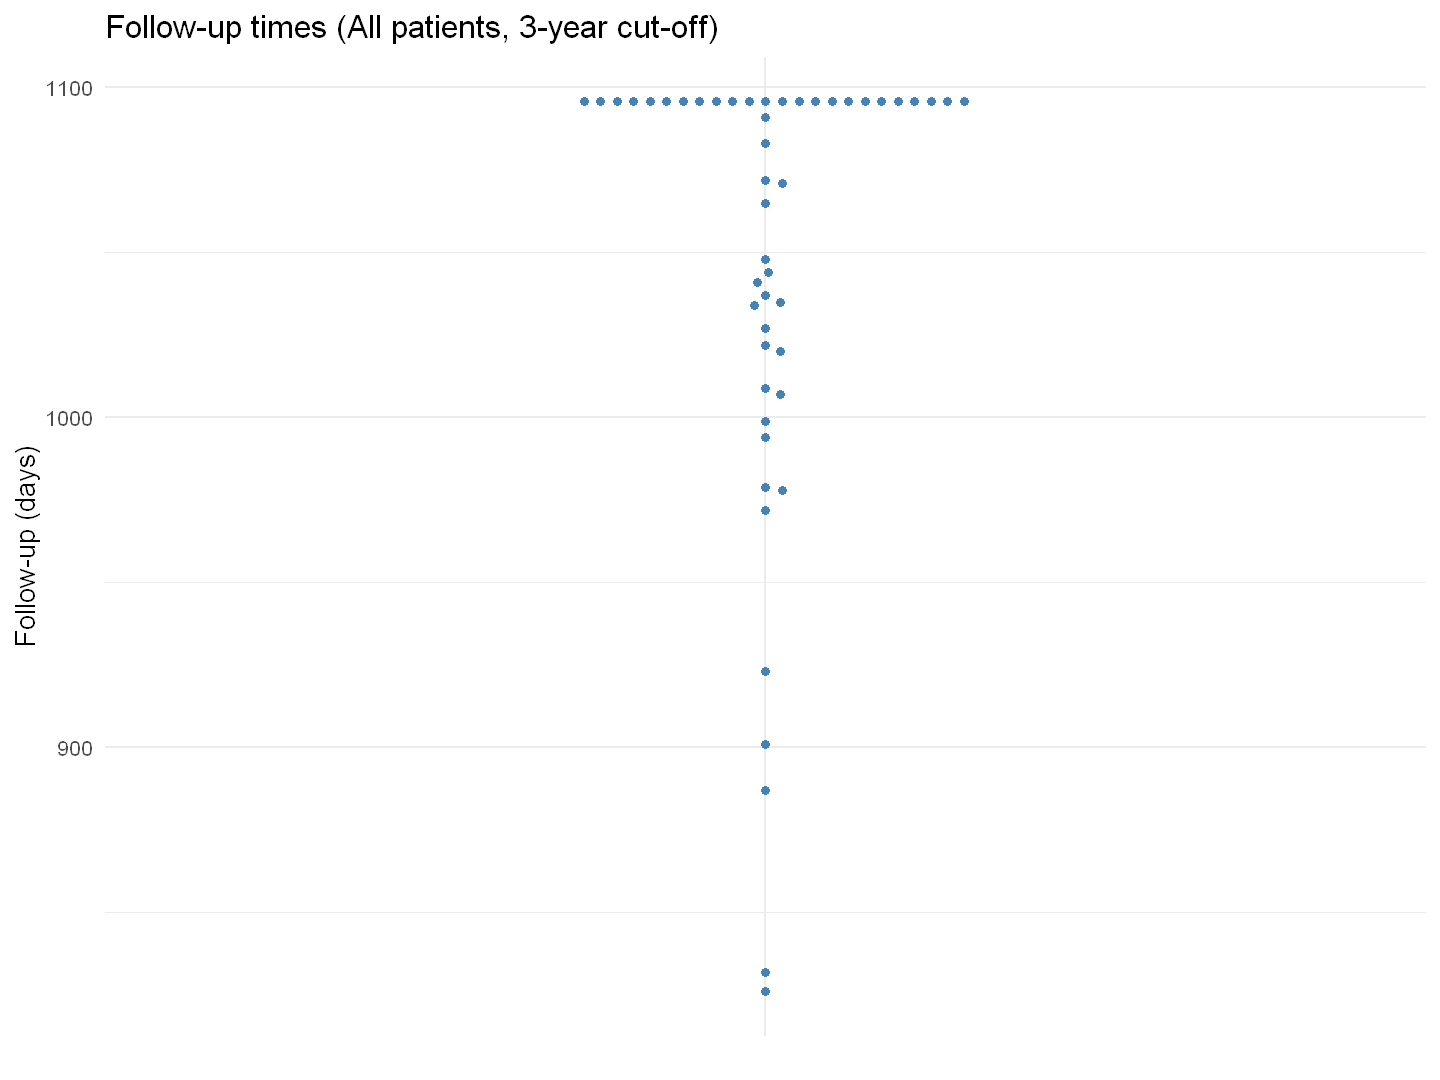

In [96]:
# 1. Beeswarm: All patients (follow-up, 3-year cut-off)
library(ggbeeswarm)
ggplot(patient_df, aes(x = "", y = followup)) +
     geom_beeswarm(cex = 1.5, size = 2, priority = "density", color = "steelblue") +
     labs(
          title = "Follow-up times (All patients, 3-year cut-off)",
          y = "Follow-up (days)", x = NULL
     ) +
     theme_minimal(base_size = 16)


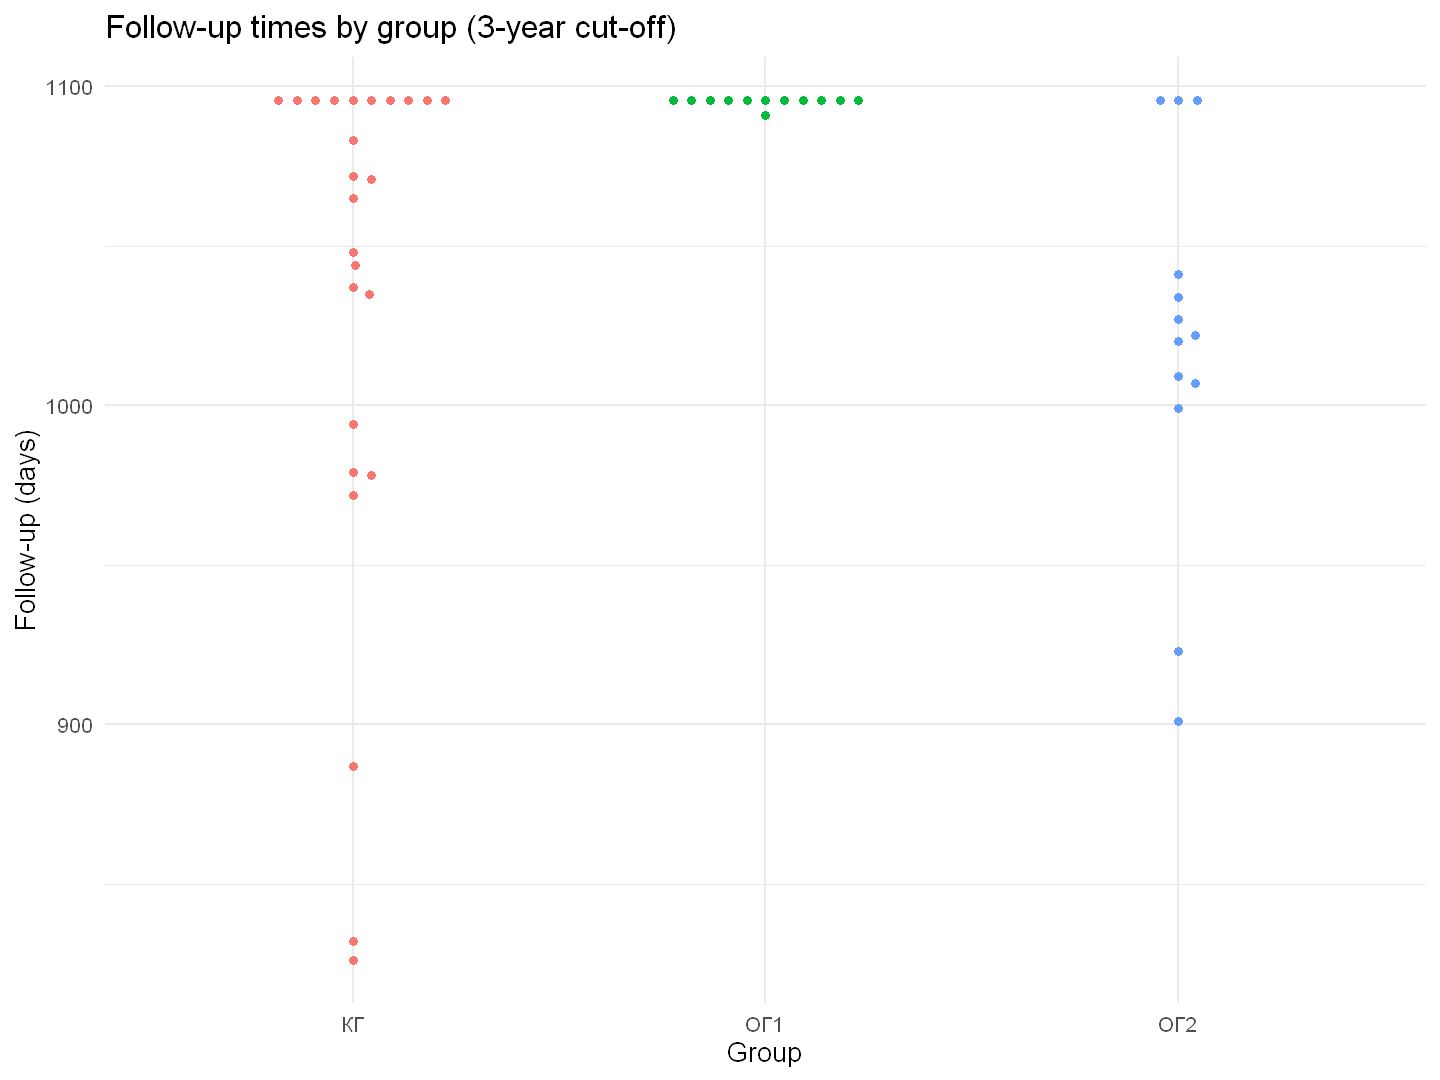

In [97]:
# 2. Beeswarm: By group (follow-up, 3-year cut-off)
ggplot(patient_df, aes(x = group, y = followup, color = group)) +
     geom_beeswarm(cex = 1.5, size = 2, priority = "density") +
     labs(
          title = "Follow-up times by group (3-year cut-off)",
          y = "Follow-up (days)", x = "Group"
     ) +
     theme_minimal(base_size = 16) +
     theme(legend.position = "none")


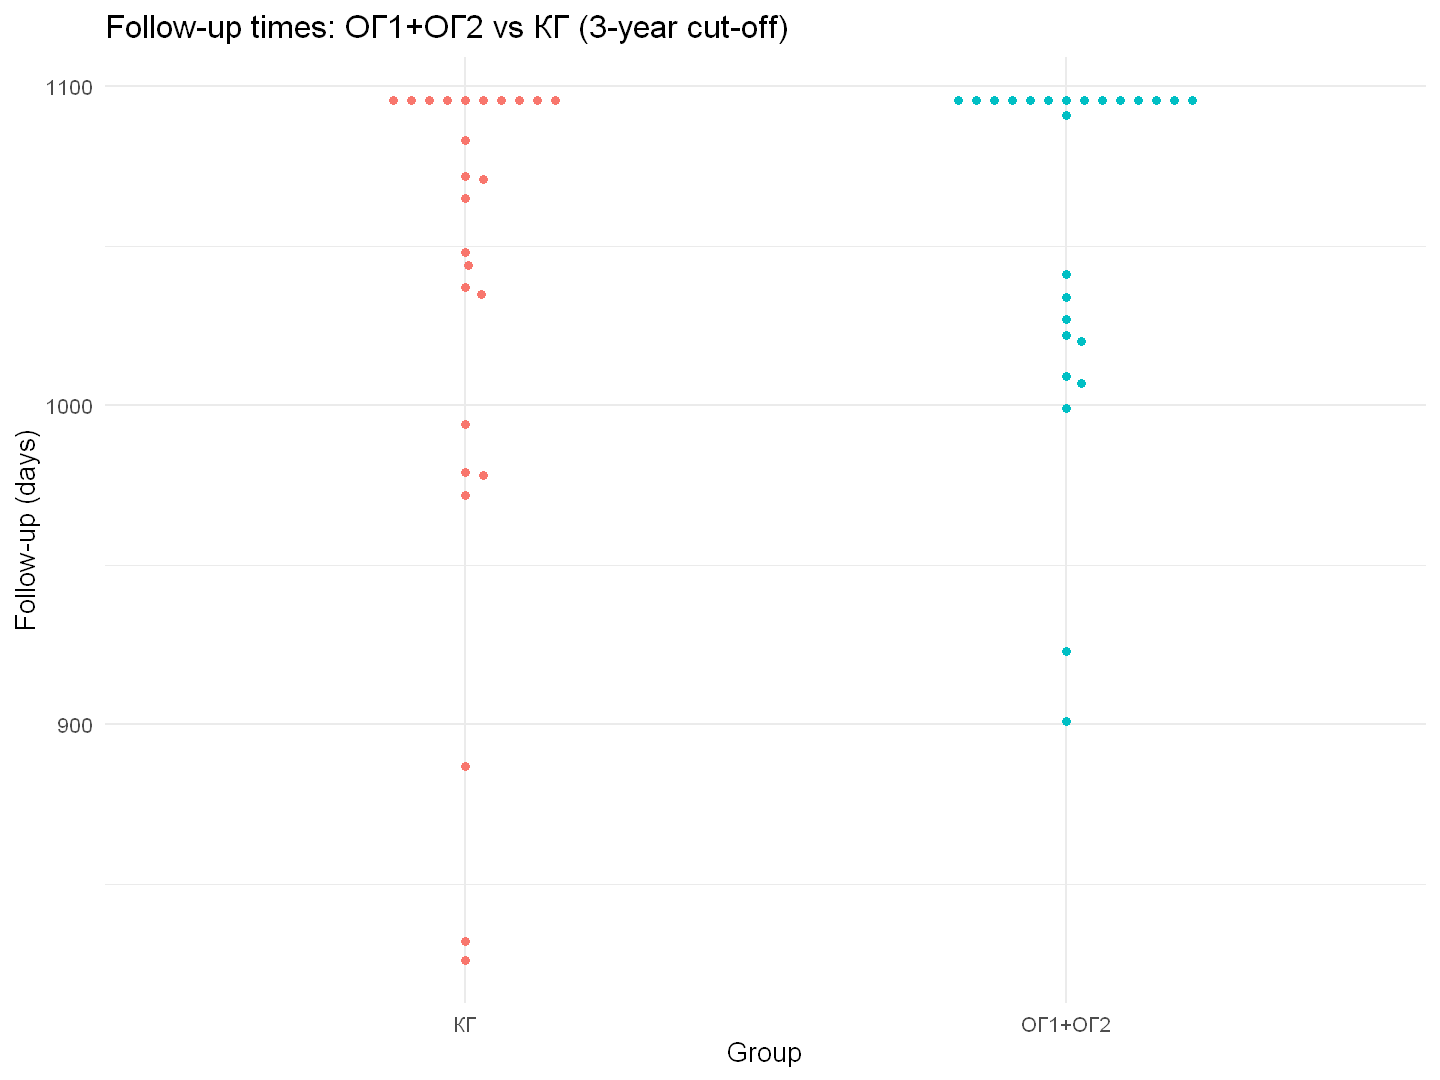

In [98]:
# 3. Beeswarm: ОГ1+ОГ2 vs КГ (follow-up, 3-year cut-off)
patient_df$group_combined <- ifelse(patient_df$group %in% c("ОГ1", "ОГ2"), "ОГ1+ОГ2", "КГ")
ggplot(patient_df, aes(x = group_combined, y = followup, color = group_combined)) +
     geom_beeswarm(cex = 1.5, size = 2, priority = "density") +
     labs(
          title = "Follow-up times: ОГ1+ОГ2 vs КГ (3-year cut-off)",
          y = "Follow-up (days)", x = "Group"
     ) +
     theme_minimal(base_size = 16) +
     theme(legend.position = "none")


## Follow-up time description

Длительность наблюдения -- это количество дней с момента индексной операции до даты окончания исследования (административное цензурирование).

### Все группы

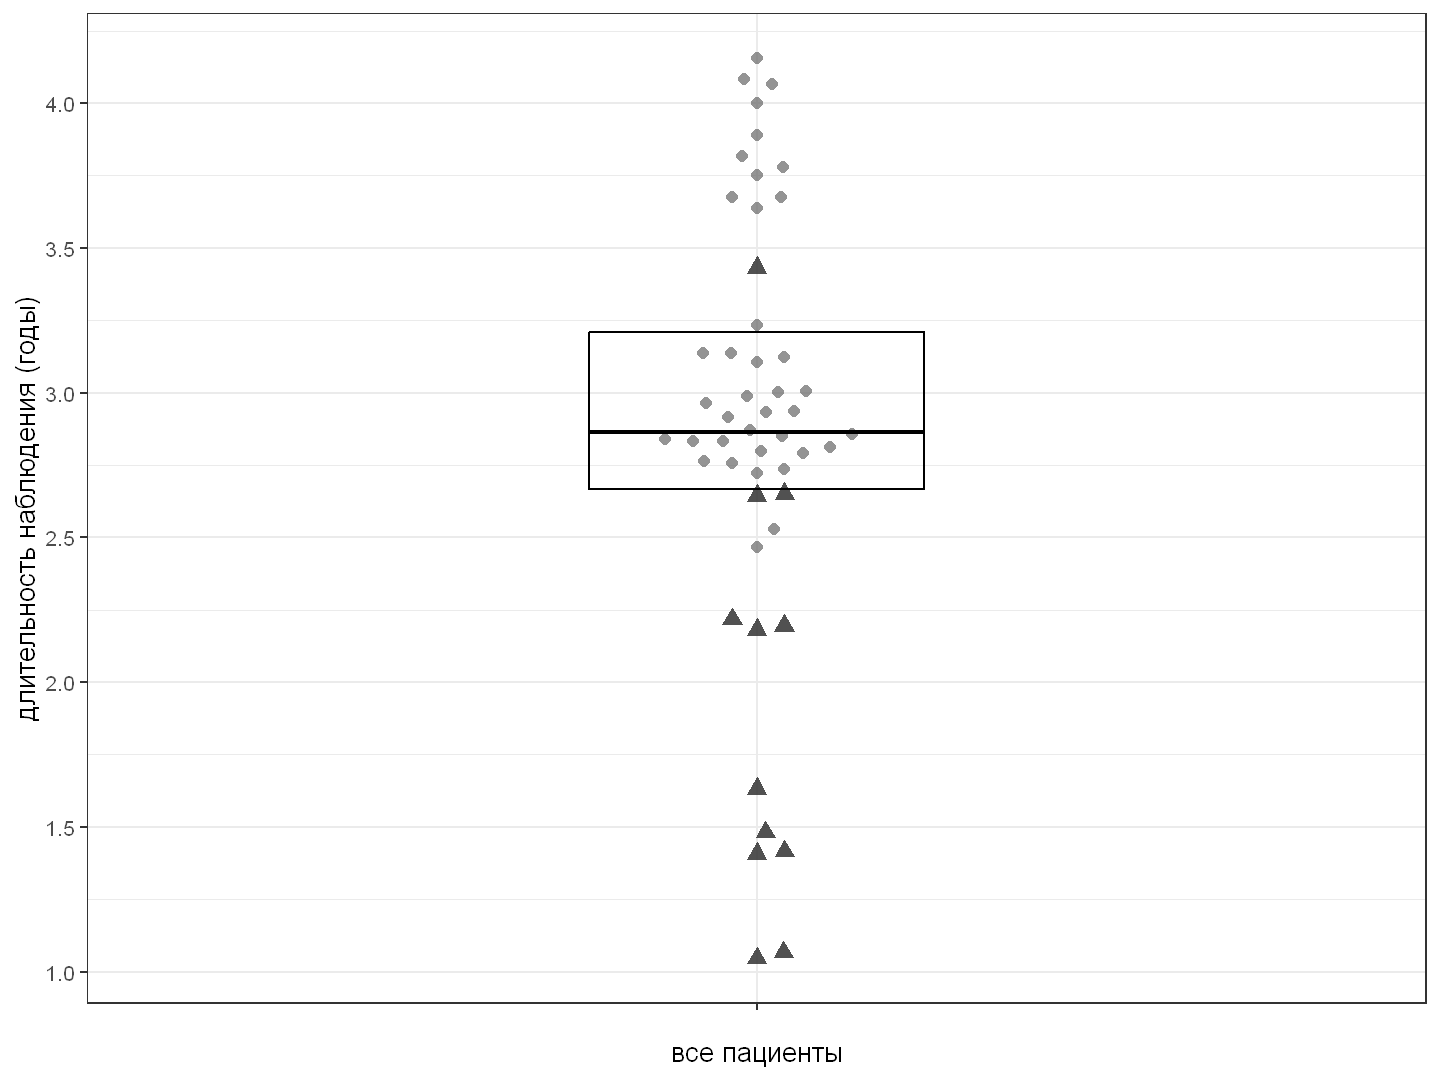

In [99]:
# ---- Follow-up time: beeswarm — all patients ----

y_breaks <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_all <- ggplot(fup_all_df, aes(x = "", y = fup_years)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 3.0, shape = 16, alpha = 0.7, colour = "grey40"
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 4, shape = 17, alpha = 0.85, colour = "grey20"
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "все пациенты",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_all)

# head(fup_all_df, n=50)


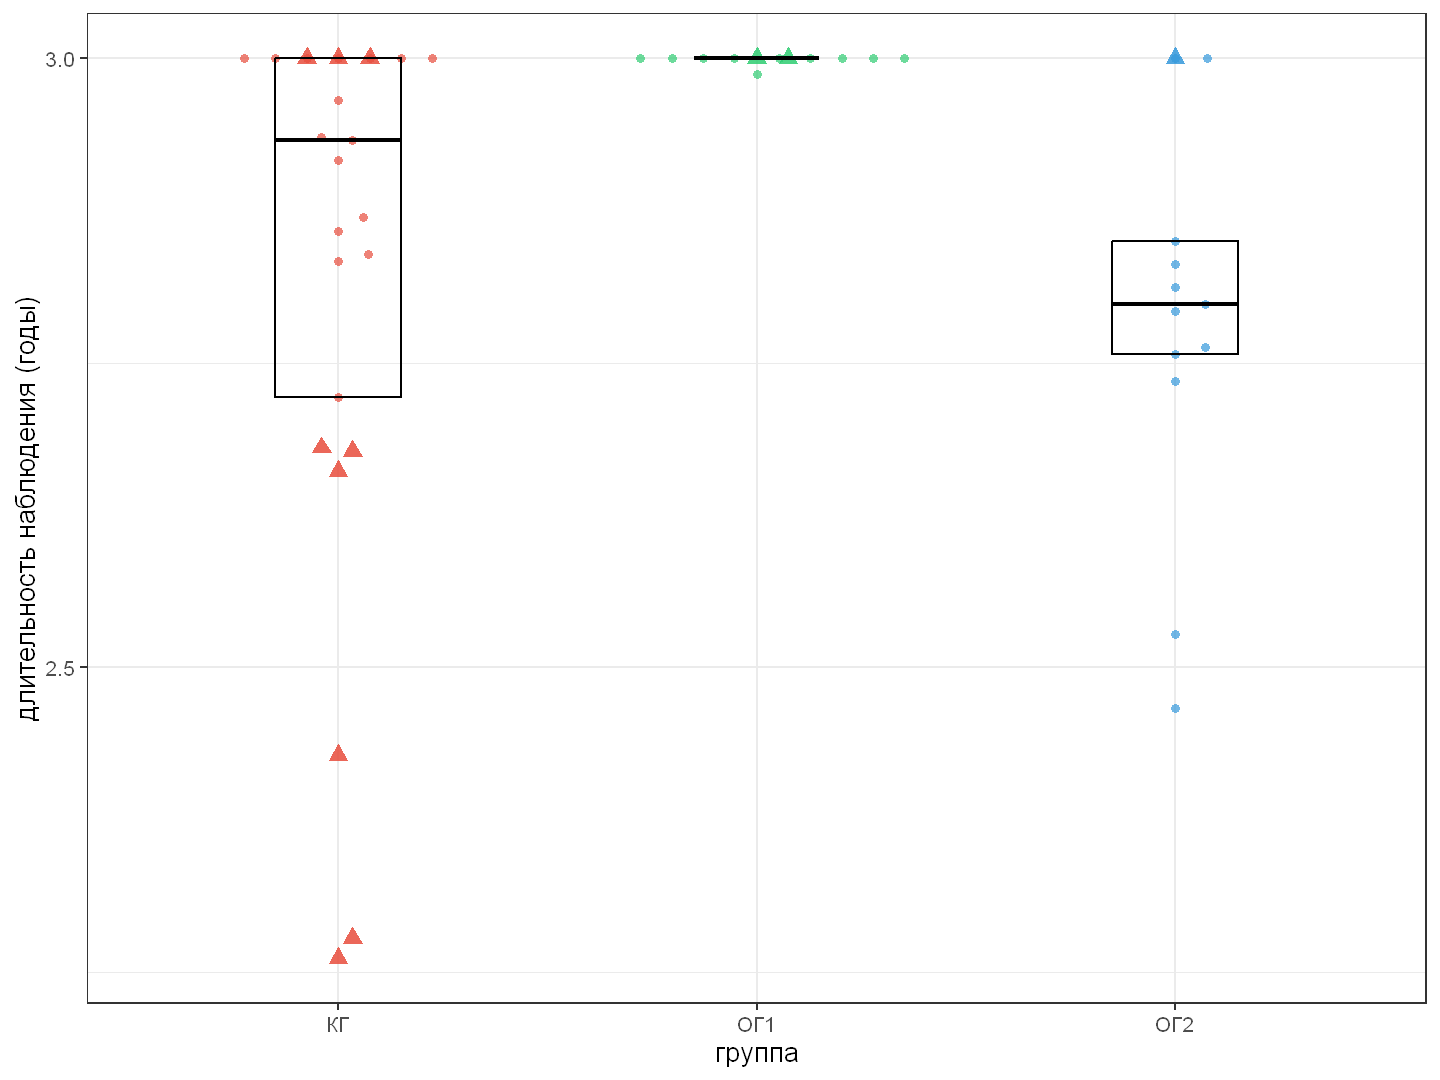

In [100]:
# ---- Follow-up time: beeswarm — by group ----

fup_grp_df <- patient_df |>
  dplyr::mutate(fup_years = followup / 365.25)

fup_beeswarm_grp <- ggplot(fup_grp_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette, guide = "none") +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "группа",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_grp)


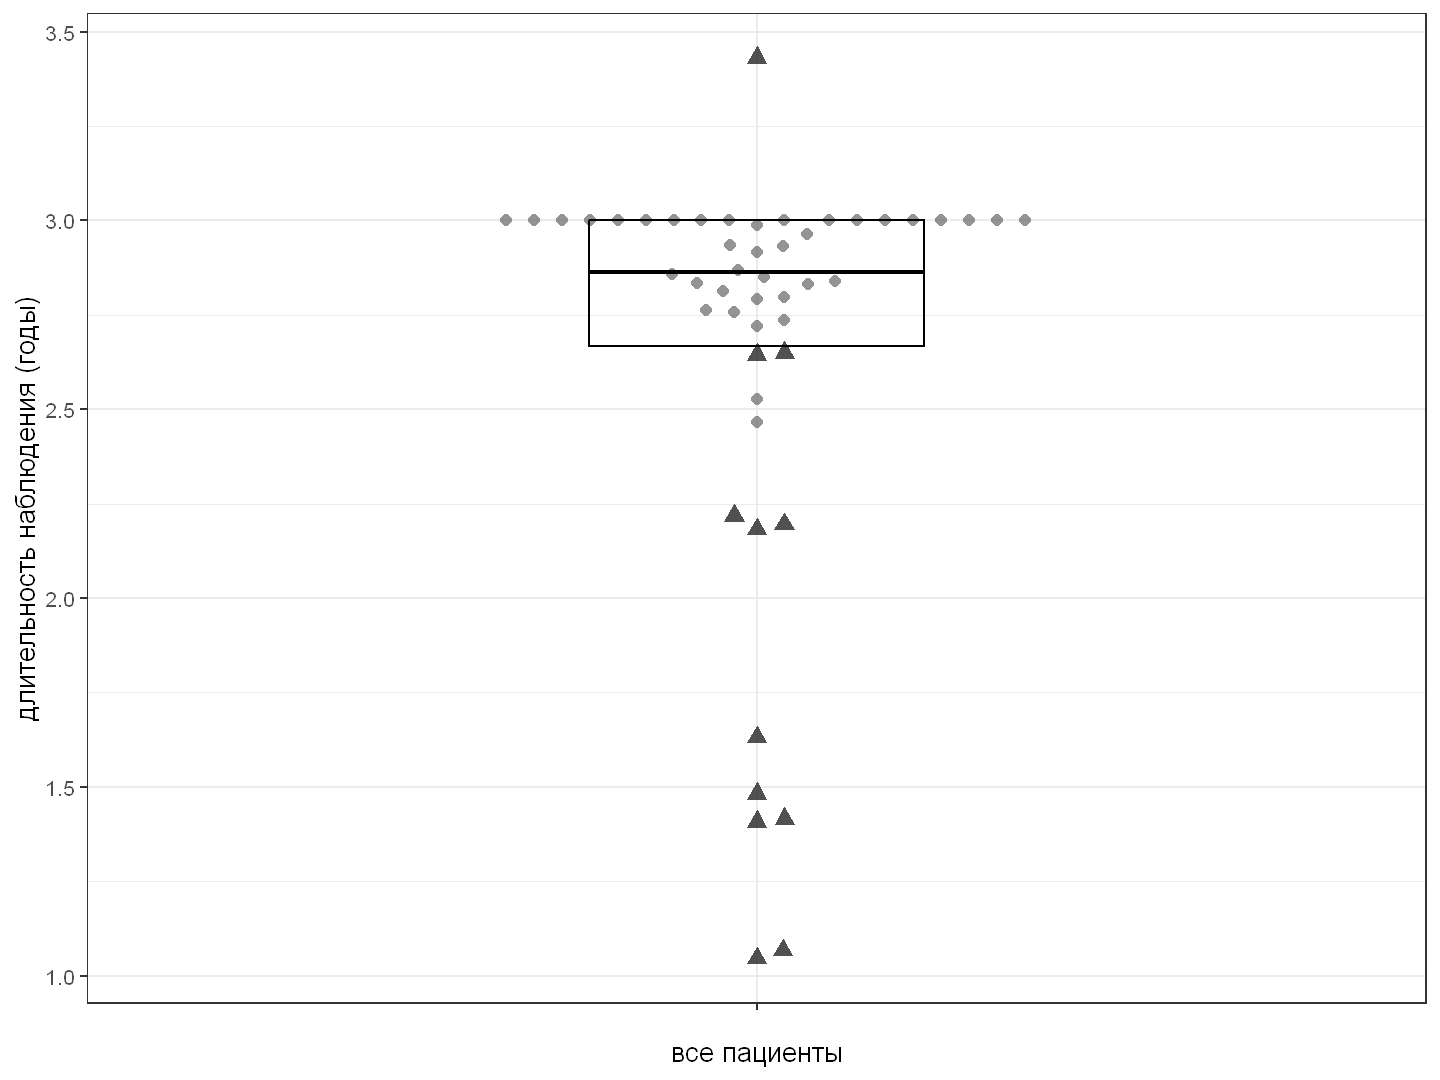

In [101]:
# ---- Reoperation times: beeswarm — all patients ----
# One point per reoperation event; shape distinguishes 1st vs 2nd reoperation.
# Patients who never had a reoperation are NOT plotted (nothing to show).

# ---- Follow-up time: beeswarm — all patients ----

fup_all_df <- patient_df |>
  dplyr::mutate(fup_years = ifelse(reop1 == 1, days_diff(date_operation, date_reoperation1) / 365.25, followup / 365.25))

y_breaks <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_all <- ggplot(fup_all_df, aes(x = "", y = fup_years)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 3.0, shape = 16, alpha = 0.7, colour = "grey40"
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 4, shape = 17, alpha = 0.85, colour = "grey20"
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "все пациенты",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_all)


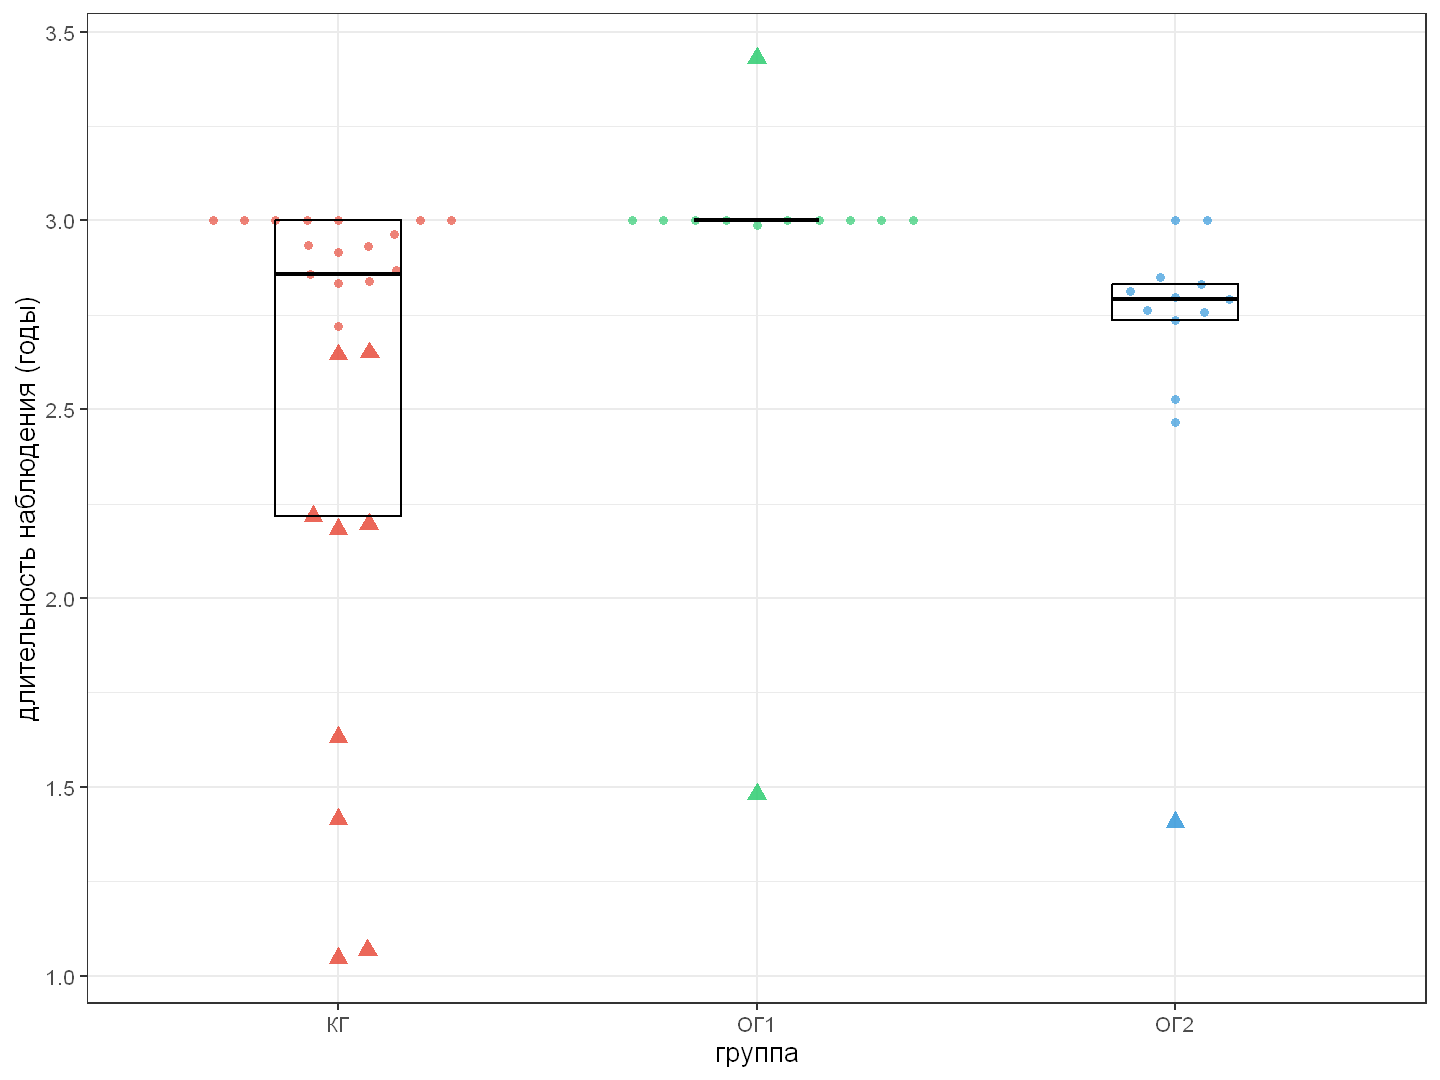

In [102]:
# ---- Reoperation times: beeswarm — by group (all groups) ----
# One point per reoperation event; shape distinguishes 1st vs 2nd reoperation.

fup_all_df <- patient_df |>
  dplyr::mutate(fup_years = ifelse(reop1 == 1, days_diff(date_operation, date_reoperation1) / 365.25, followup / 365.25))


y_breaks_reop <- seq(0, ceiling(max(fup_all_df$fup_years)), by = 0.5)

fup_beeswarm_grp <- ggplot(fup_all_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette, guide = "none") +
  scale_y_continuous(breaks = y_breaks) +
  labs(
    x        = "группа",
    y        = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)


print(fup_beeswarm_grp)


#### ОГ1+ОГ2 vs КГ — длительность наблюдения

In [103]:
# ---- Follow-up time: basic statistics — ОГ combined ----
cat("=== Follow-up time (days) — ОГ combined vs КГ ===\n")
patient_df_og |>
  group_by(group) |>
  summarise(fup_stats(followup), .groups = "drop") |>
  print()


=== Follow-up time (days) — ОГ combined vs КГ ===


# A tibble: 2 × 9
  group     n  mean    sd median    q1    q3   min   max
  <fct> <int> <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>
1 КГ       25 1035.  82.1  1071    994 1096.   826 1096.
2 ОГ       25 1057.  56.6  1096.  1022 1096.   901 1096.


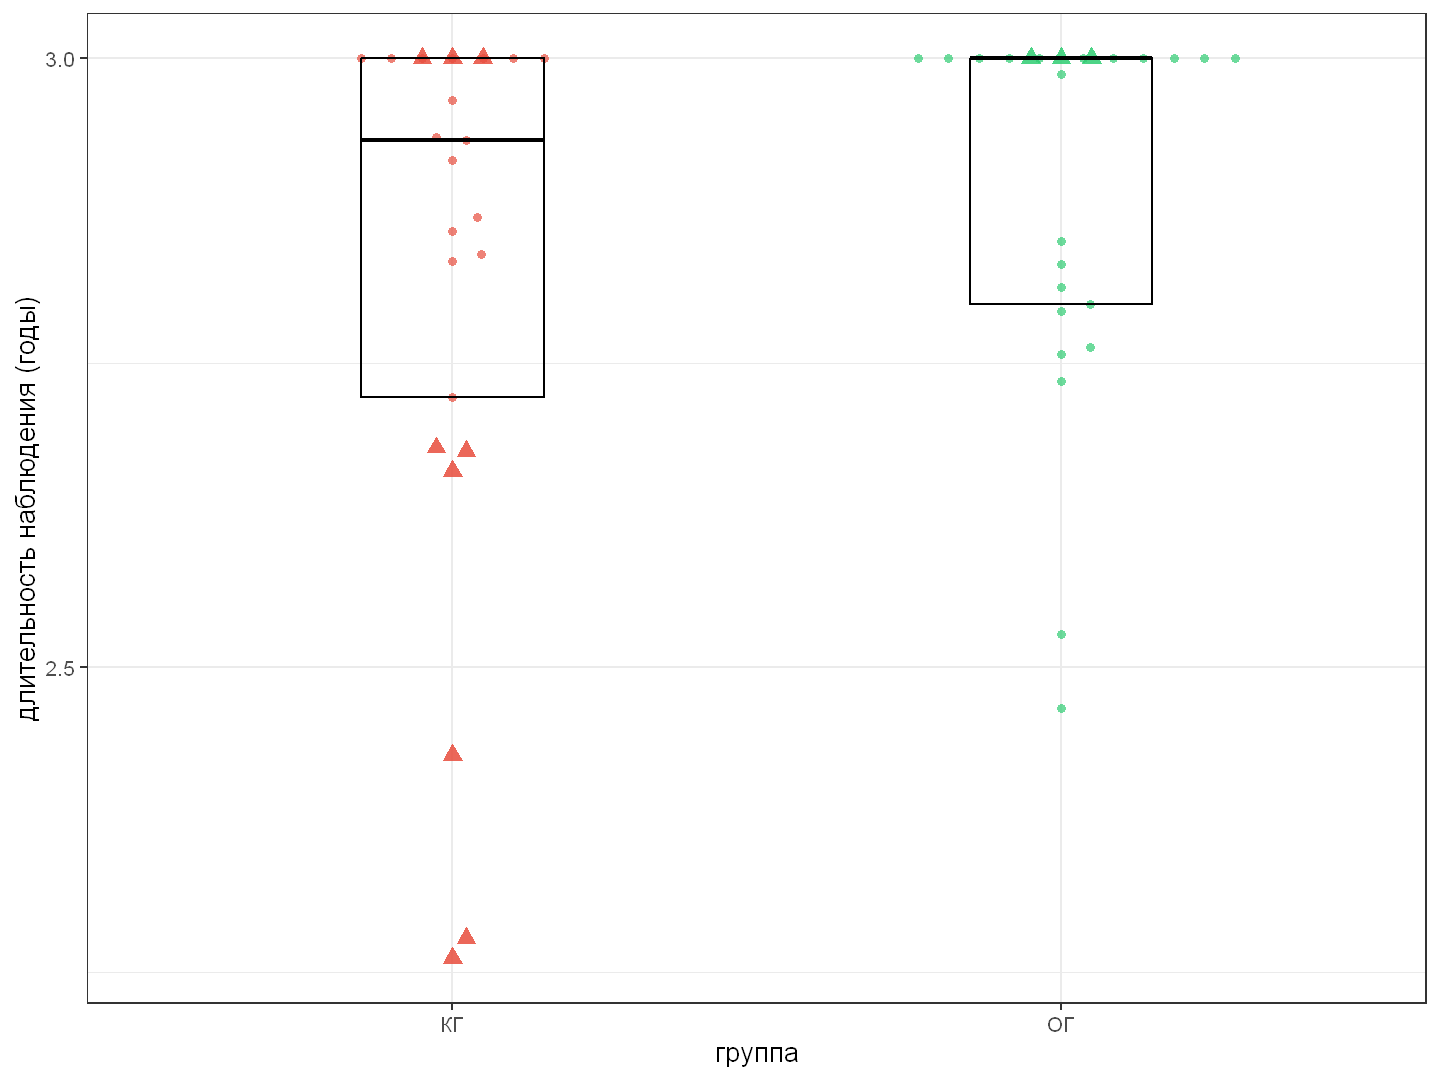

In [104]:
# ---- Follow-up time: beeswarm — ОГ combined vs КГ ----
fup_og_df <- patient_df_og |>
  dplyr::mutate(fup_years = followup / 365.25)

y_breaks_og <- seq(0, ceiling(max(fup_og_df$fup_years)), by = 0.5)

fup_beeswarm_og <- ggplot(fup_og_df, aes(x = group, y = fup_years, colour = group)) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 0 & reop2 == 0),
    cex = 2.5, size = 2.0, shape = 16, alpha = 0.7
  ) +
  geom_beeswarm(
    data = ~ subset(., reop1 == 1 | reop2 == 1),
    cex = 2.5, size = 3.8, shape = 17, alpha = 0.85
  ) +
  stat_summary(
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette_og, guide = "none") +
  scale_y_continuous(breaks = y_breaks_og) +
  labs(
    x = "группа",
    y = "длительность наблюдения (годы)"
  ) +
  theme_bw(base_size = 16)

print(fup_beeswarm_og)


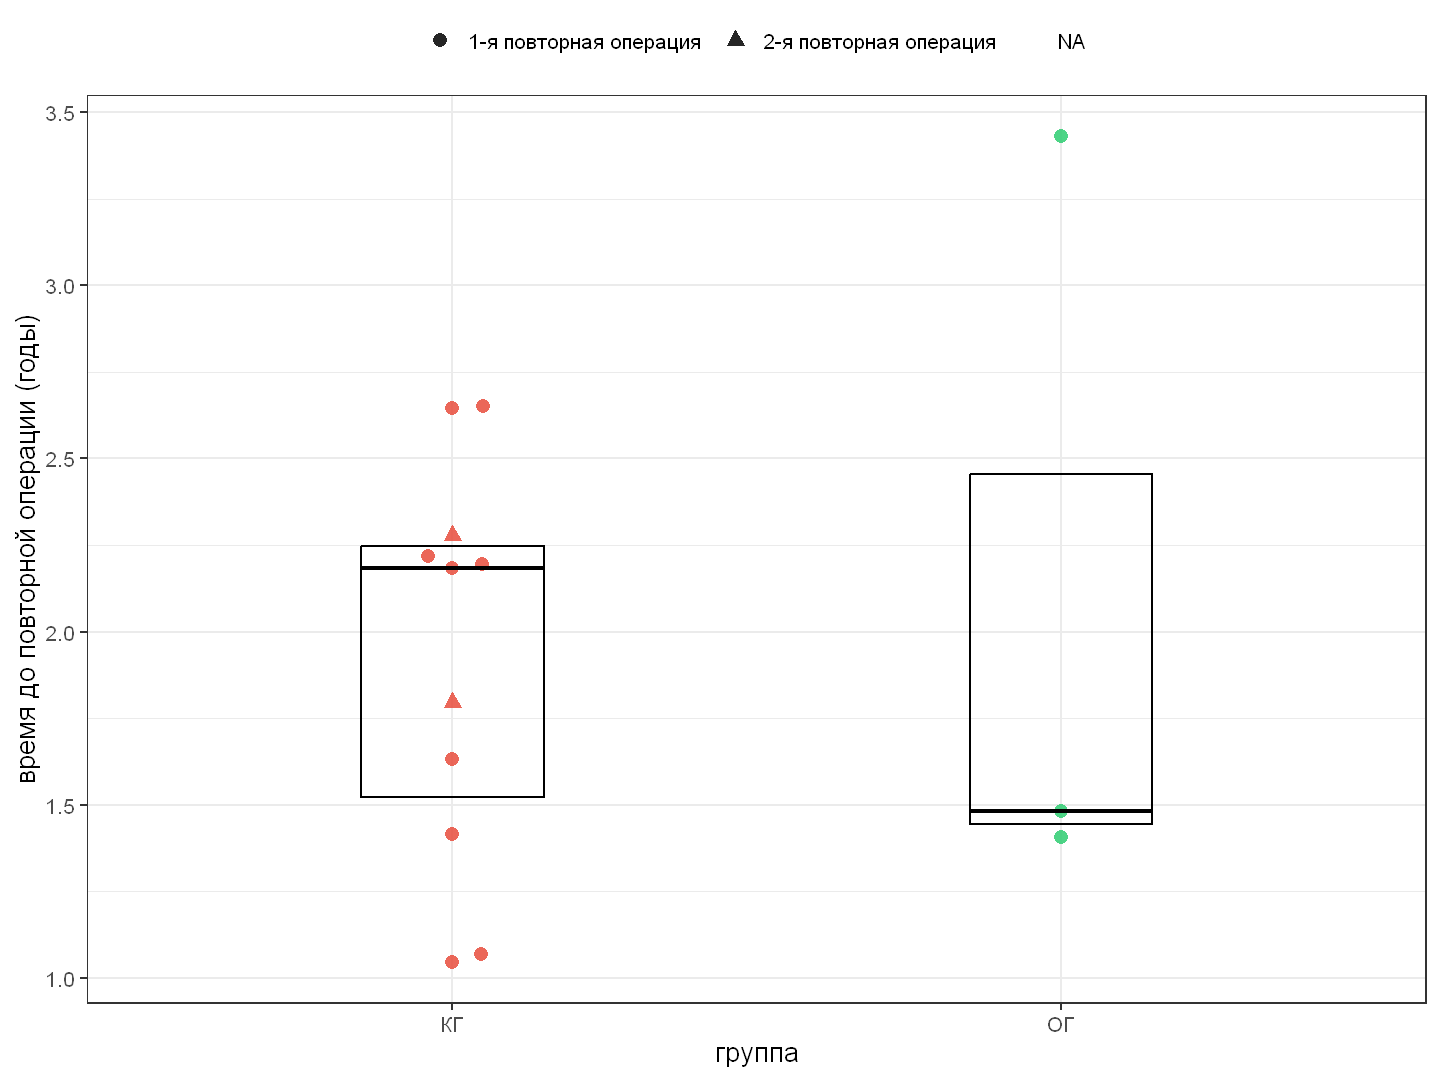

In [105]:
# ---- Reoperation times: beeswarm — ОГ combined vs КГ ----

reop_times_og_df <- bind_rows(
  patient_df_og |>
    filter(reop1 == 1) |>
    transmute(
      id, group,
      reop_year = days_diff(date_operation, date_reoperation1) / 365.25,
      reop_num = "1-я повторная операция"
    ),
  patient_df_og |>
    filter(reop2 == 1) |>
    transmute(
      id, group,
      reop_year = days_diff(date_operation, date_reoperation2) / 365.25,
      reop_num = "2-я повторная операция"
    )
) |>
  dplyr::mutate(reop_num = factor(reop_num,
    levels = c(
      "1-я повторная операция",
      "2-я повторная операция"
    )
  ))

# y axis breaks

y_breaks_reop_og <- seq(0, ceiling(max(reop_times_og_df$reop_year)), by = 0.5)


reop_beeswarm_og <- ggplot(
  reop_times_og_df,
  aes(
    x = group, y = reop_year,
    colour = group, shape = reop_num
  )
) +
  geom_beeswarm(cex = 2.5, size = 3.5, alpha = 0.85) +
  stat_summary(
    aes(group = group),
    fun.data = median_hilow, fun.args = list(conf.int = 0.5),
    geom = "crossbar", width = 0.3, linewidth = 0.6,
    colour = "black", fatten = 2
  ) +
  scale_colour_manual(values = group_palette_og, guide = "none") +
  scale_shape_manual(
    values = c(
      "1-я повторная операция" = 16,
      "2-я повторная операция" = 17
    ),
    name = NULL
  ) +
  scale_y_continuous(breaks = y_breaks_reop_og) +
  labs(
    x = "группа",
    y = "время до повторной операции (годы)"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(reop_beeswarm_og)


In [106]:
first_reop_df <- patient_df |>
  dplyr::mutate(
    time_first = ifelse(
      reop1 == 1,
      days_diff(date_operation, date_reoperation1),
      followup
    ),
    event_first = as.integer(reop1 == 1)
  )
head(first_reop_df)


id,group,age,sex,ill_dur,polyps,allergy_dust,allergy_plants,allergy_mites,allergy_animals,⋯,sinuses,followup,reop1,date_reoperation1,reop2,date_reoperation2,n_reops,group_combined,time_first,event_first
<chr>,<fct>,<int>,<chr>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<date>,<dbl>,<date>,<int>,<chr>,<dbl>,<int>
1,ОГ1,48,муж.,10,3,нет,нет,нет,нет,⋯,4,1095.75,0,NA,0,NA,0,ОГ1+ОГ2,1095.75,0
2,ОГ1,32,муж.,20,1,нет,да,нет,нет,⋯,2,1095.75,0,NA,0,NA,0,ОГ1+ОГ2,1095.75,0
4,ОГ1,50,муж.,15,3,нет,нет,нет,нет,⋯,8,1095.75,0,NA,0,NA,0,ОГ1+ОГ2,1095.75,0
5,ОГ1,28,муж.,8,7,да,да,нет,да,⋯,4,1095.75,1,2023-07-13,0,NA,1,ОГ1+ОГ2,541.00,1
6,ОГ1,37,муж.,8,3,нет,нет,нет,нет,⋯,1,1095.75,0,NA,0,NA,0,ОГ1+ОГ2,1095.75,0
7,ОГ1,23,жен.,8,2,нет,да,нет,да,⋯,8,1095.75,0,NA,0,NA,0,ОГ1+ОГ2,1095.75,0


In [107]:
# ---- 2a (Part 2): Wide format — ОГ1+ОГ2 combined ----
first_reop_df_og <- patient_df_og |>
  dplyr::mutate(
    time_first = ifelse(
      reop1 == 1,
      days_diff(date_operation, date_reoperation1),
      followup
    ),
    event_first = as.integer(reop1 == 1)
  )
head(first_reop_df_og)


id,group,age,sex,ill_dur,polyps,allergy_dust,allergy_plants,allergy_mites,allergy_animals,⋯,date_operation,sinuses,followup,reop1,date_reoperation1,reop2,date_reoperation2,n_reops,time_first,event_first
<chr>,<fct>,<int>,<chr>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,⋯,<date>,<dbl>,<dbl>,<dbl>,<date>,<dbl>,<date>,<int>,<dbl>,<int>
1,ОГ,48,муж.,10,3,нет,нет,нет,нет,⋯,2021-11-25,4,1095.75,0,NA,0,NA,0,1095.75,0
2,ОГ,32,муж.,20,1,нет,да,нет,нет,⋯,2022-01-21,2,1095.75,0,NA,0,NA,0,1095.75,0
4,ОГ,50,муж.,15,3,нет,нет,нет,нет,⋯,2021-12-22,8,1095.75,0,NA,0,NA,0,1095.75,0
5,ОГ,28,муж.,8,7,да,да,нет,да,⋯,2022-01-18,4,1095.75,1,2023-07-13,0,NA,1,541.00,1
6,ОГ,37,муж.,8,3,нет,нет,нет,нет,⋯,2022-03-02,1,1095.75,0,NA,0,NA,0,1095.75,0
7,ОГ,23,жен.,8,2,нет,да,нет,да,⋯,2022-03-29,8,1095.75,0,NA,0,NA,0,1095.75,0


In [108]:
# ---- 2b. Long (counting process) format: one row per event interval ----
# Format:  id | group | tstart | tstop | status | event_num
# Used for: Andersen-Gill, PWP, MCF
make_long_format <- function(df) {
  rows <- vector("list", nrow(df))

  for (i in seq_len(nrow(df))) {
    pid <- df$id[i]
    grp <- as.character(df$group[i])
    fup <- df$followup[i]

    # Event times in days from index operation
    et <- numeric(0)
    if (df$reop1[i] == 1) et <- c(et, days_diff(df$date_operation[i], df$date_reoperation1[i]))
    if (df$reop2[i] == 1) et <- c(et, days_diff(df$date_operation[i], df$date_reoperation2[i]))
    et <- sort(et)

    if (length(et) == 0) {
      # No events: single censored interval [0, followup)
      rows[[i]] <- tibble::tibble(
        id        = pid,
        group     = grp,
        tstart    = 0,
        tstop     = fup,
        status    = 0L,
        event_num = 1L
      )
    } else {
      times <- c(0, et, fup)
      n_int <- length(times) - 1
      rows[[i]] <- tibble::tibble(
        id        = pid,
        group     = grp,
        tstart    = times[1:n_int],
        tstop     = times[2:(n_int + 1)],
        status    = c(rep(1L, length(et)), 0L),
        event_num = seq_len(n_int)
      )
    }
  }

  dplyr::bind_rows(rows) |>
    dplyr::mutate(group = factor(group))
}


In [109]:
# ---- Build long-format datasets for Part 1 and Part 2 ----
long_df <- make_long_format(patient_df)
long_df_og <- make_long_format(patient_df_og)

cat(sprintf("long_df rows:    %d  |  events: %d\n", nrow(long_df), sum(long_df$status)))
cat(sprintf("long_df_og rows: %d  |  events: %d\n", nrow(long_df_og), sum(long_df_og$status)))


long_df rows:    64  |  events: 14


long_df_og rows: 64  |  events: 14


## 1. KAPLAN-MEIER + LOG-RANK  (time to first re-operation)

### Все группы

Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

           n events median 0.95LCL 0.95UCL
group=КГ  25      9     NA     968      NA
group=ОГ1 12      2   1253      NA      NA
group=ОГ2 13      1     NA      NA      NA



Log-rank test:


Call:
survdiff(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

           N Observed Expected (O-E)^2/E (O-E)^2/V
group=КГ  25        9     5.23     2.719      5.19
group=ОГ1 12        2     3.83     0.878      1.60
group=ОГ2 13        1     2.94     1.277      1.74

 Chisq= 5.2  on 2 degrees of freedom, p= 0.07 


Log-rank p-value: 0.0747


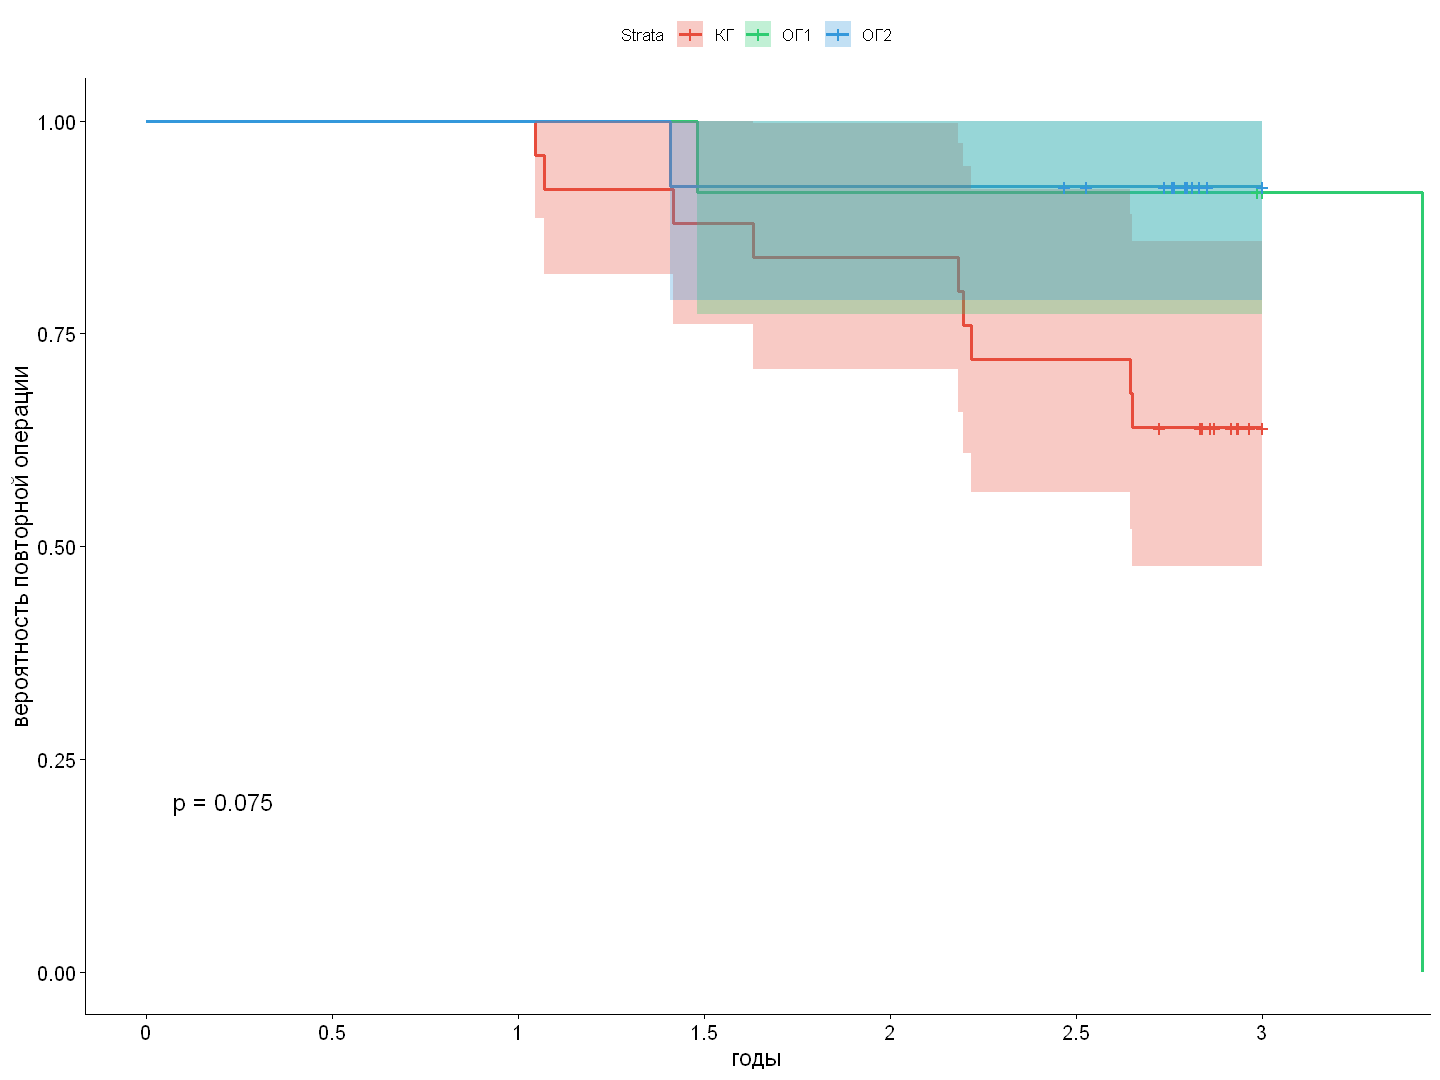

In [110]:
km_fit <- survfit(Surv(time_first, event_first) ~ group, data = first_reop_df)
print(km_fit)

# Log-rank test
logrank <- survdiff(Surv(time_first, event_first) ~ group, data = first_reop_df)
cat("\nLog-rank test:\n")
print(logrank)

# P-value
p_logrank <- pchisq(logrank$chisq, df = length(logrank$n) - 1, lower.tail = FALSE)
cat(sprintf("Log-rank p-value: %.4f\n", p_logrank))

# Plot
km_plot <- ggsurvplot(
  km_fit,
  data           = first_reop_df,
  pval           = TRUE,
  conf.int       = TRUE,
  risk.table     = FALSE,
  palette        = group_palette,
  xlab           = "годы",
  ylab           = "вероятность повторной операции",
  legend.labs    = group_levels,
  break.time.by  = six_months_days, # tick every 0.5 years
  xscale         = 365.25 # convert day values to year labels
)

print(km_plot)


In [111]:
# Survival estimates at every 6 months (half-year intervals)
half_year_times <- seq(six_months_days,
    max(first_reop_df$time_first, na.rm = TRUE),
    by = six_months_days
)
km_summary <- summary(km_fit, times = half_year_times, extend = TRUE)
print(km_summary)


Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

                group=КГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0     1.00  0.0000        1.000        1.000
  365     25       0     1.00  0.0000        1.000        1.000
  548     22       3     0.88  0.0650        0.761        1.000
  730     21       1     0.84  0.0733        0.708        0.997
  913     18       3     0.72  0.0898        0.564        0.919
 1096      7       2     0.64  0.0960        0.477        0.859

                group=ОГ1 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     12       0    1.000  0.0000        1.000            1
  365     12       0    1.000  0.0000        1.000            1
  548     11       1    0.917  0.0798        0.773            1
  730     11       0    0.917  0.0798        0.773            1
  913     11       0    0.917  0.0798        0.773            1
 1096     10       0    0.91

#### ОГ1+ОГ2 vs КГ

Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

          n events median 0.95LCL 0.95UCL
group=КГ 25      9     NA     968      NA
group=ОГ 25      3   1253      NA      NA



Log-rank test:


Call:
survdiff(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

          N Observed Expected (O-E)^2/E (O-E)^2/V
group=КГ 25        9     5.23      2.72      5.19
group=ОГ 25        3     6.77      2.10      5.19

 Chisq= 5.2  on 1 degrees of freedom, p= 0.02 


Log-rank p-value: 0.0227


Call: survfit(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

                group=КГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0     1.00  0.0000        1.000        1.000
  365     25       0     1.00  0.0000        1.000        1.000
  548     22       3     0.88  0.0650        0.761        1.000
  730     21       1     0.84  0.0733        0.708        0.997
  913     18       3     0.72  0.0898        0.564        0.919
 1096      7       2     0.64  0.0960        0.477        0.859

                group=ОГ 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
  183     25       0     1.00  0.0000         1.00            1
  365     25       0     1.00  0.0000         1.00            1
  548     23       2     0.92  0.0543         0.82            1
  730     23       0     0.92  0.0543         0.82            1
  913     22       0     0.92  0.0543         0.82            1
 1096     12       0     0

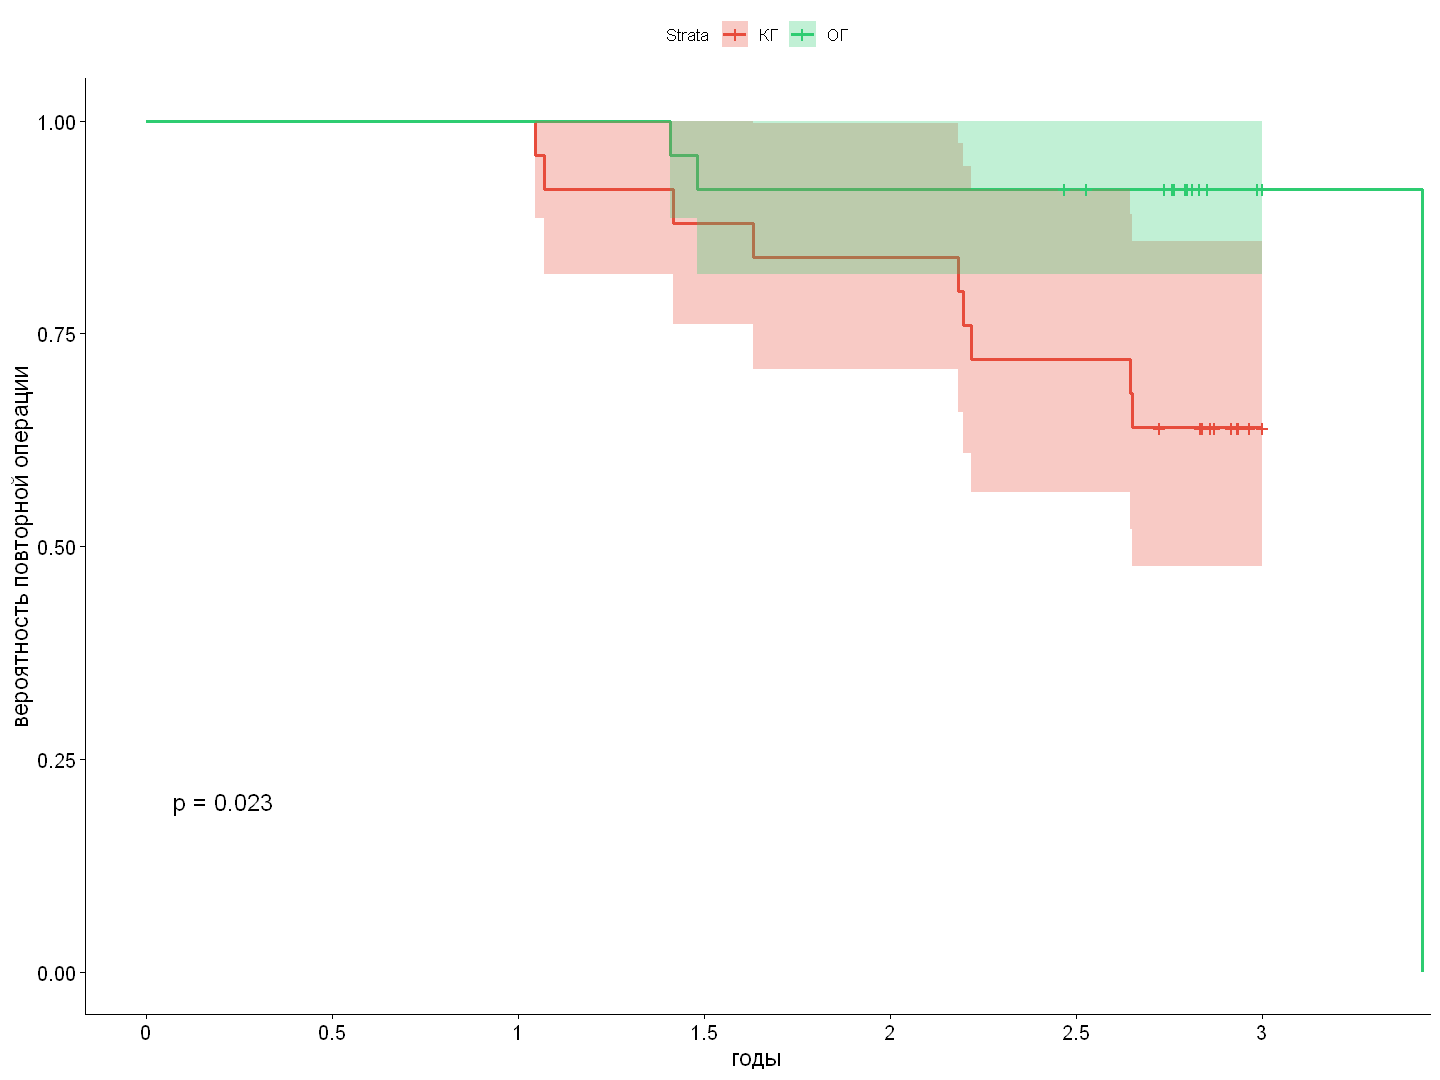

In [112]:
km_fit_og <- survfit(Surv(time_first, event_first) ~ group, data = first_reop_df_og)
print(km_fit_og)

logrank_og <- survdiff(Surv(time_first, event_first) ~ group, data = first_reop_df_og)
cat("\nLog-rank test:\n")
print(logrank_og)

p_logrank_og <- pchisq(logrank_og$chisq, df = length(logrank_og$n) - 1, lower.tail = FALSE)
cat(sprintf("Log-rank p-value: %.4f\n", p_logrank_og))

km_plot_og <- ggsurvplot(
  km_fit_og,
  data           = first_reop_df_og,
  pval           = TRUE,
  conf.int       = TRUE,
  risk.table     = FALSE,
  palette        = group_palette_og,
  xlab           = "годы",
  ylab           = "вероятность повторной операции",
  legend.labs    = group_levels_og,
  break.time.by  = six_months_days,
  xscale         = 365.25
)
print(km_plot_og)

half_year_times_og <- seq(six_months_days,
  max(first_reop_df_og$time_first, na.rm = TRUE),
  by = six_months_days
)
print(summary(km_fit_og, times = half_year_times_og, extend = TRUE))


## 2. COX PROPORTIONAL HAZARDS  (time to first re-operation)


### 2.1  Unadjusted group only


#### Все группы

In [113]:
cox_fit <- coxph(Surv(time_first, event_first) ~ group, data = first_reop_df)
cat("\nCox PH model summary (group only):\n")
print(summary(cox_fit))



Cox PH model summary (group only):


Call:
coxph(formula = Surv(time_first, event_first) ~ group, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.5867    0.2046   1.0544 -1.505    0.132
groupОГ2 -1.6211    0.1977   1.0542 -1.538    0.124

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2046      4.888   0.02590     1.616
groupОГ2    0.1977      5.059   0.02504     1.561

Concordance= 0.67  (se = 0.07 )
Likelihood ratio test= 5.54  on 2 df,   p=0.06
Wald test            = 4.21  on 2 df,   p=0.1
Score (logrank) test = 5.19  on 2 df,   p=0.07




Test of PH assumption:


        chisq df    p
group  0.0378  1 0.85
GLOBAL 0.0378  1 0.85


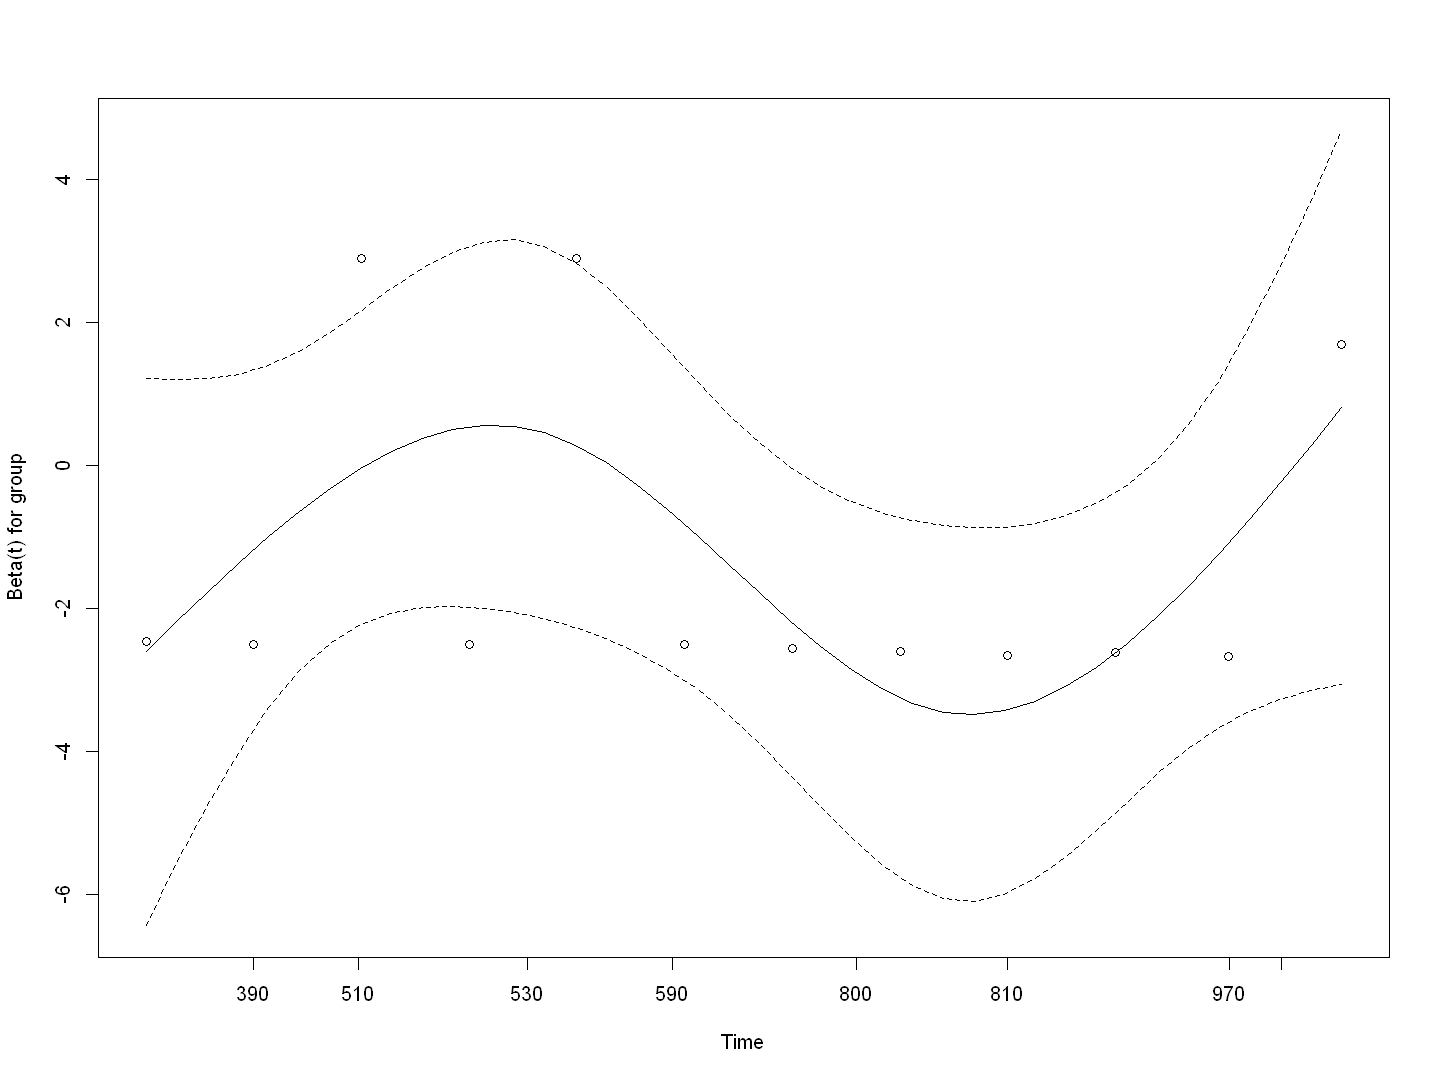

In [114]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption:\n")
ph_test <- cox.zph(cox_fit_og)
print(ph_test)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test)


#### ОГ1+ОГ2 vs КГ

In [115]:
cox_fit_og <- coxph(Surv(time_first, event_first) ~ group, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group only):\n")
print(summary(cox_fit_og))



Cox PH model summary — ОГ combined (group only):


Call:
coxph(formula = Surv(time_first, event_first) ~ group, data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.6041    0.2011   0.7820 -2.051   0.0402 *
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2011      4.973   0.04342    0.9311

Concordance= 0.67  (se = 0.067 )
Likelihood ratio test= 5.54  on 1 df,   p=0.02
Wald test            = 4.21  on 1 df,   p=0.04
Score (logrank) test = 5.19  on 1 df,   p=0.02




Test of PH assumption:


       chisq df    p
group   1.13  1 0.29
GLOBAL  1.13  1 0.29


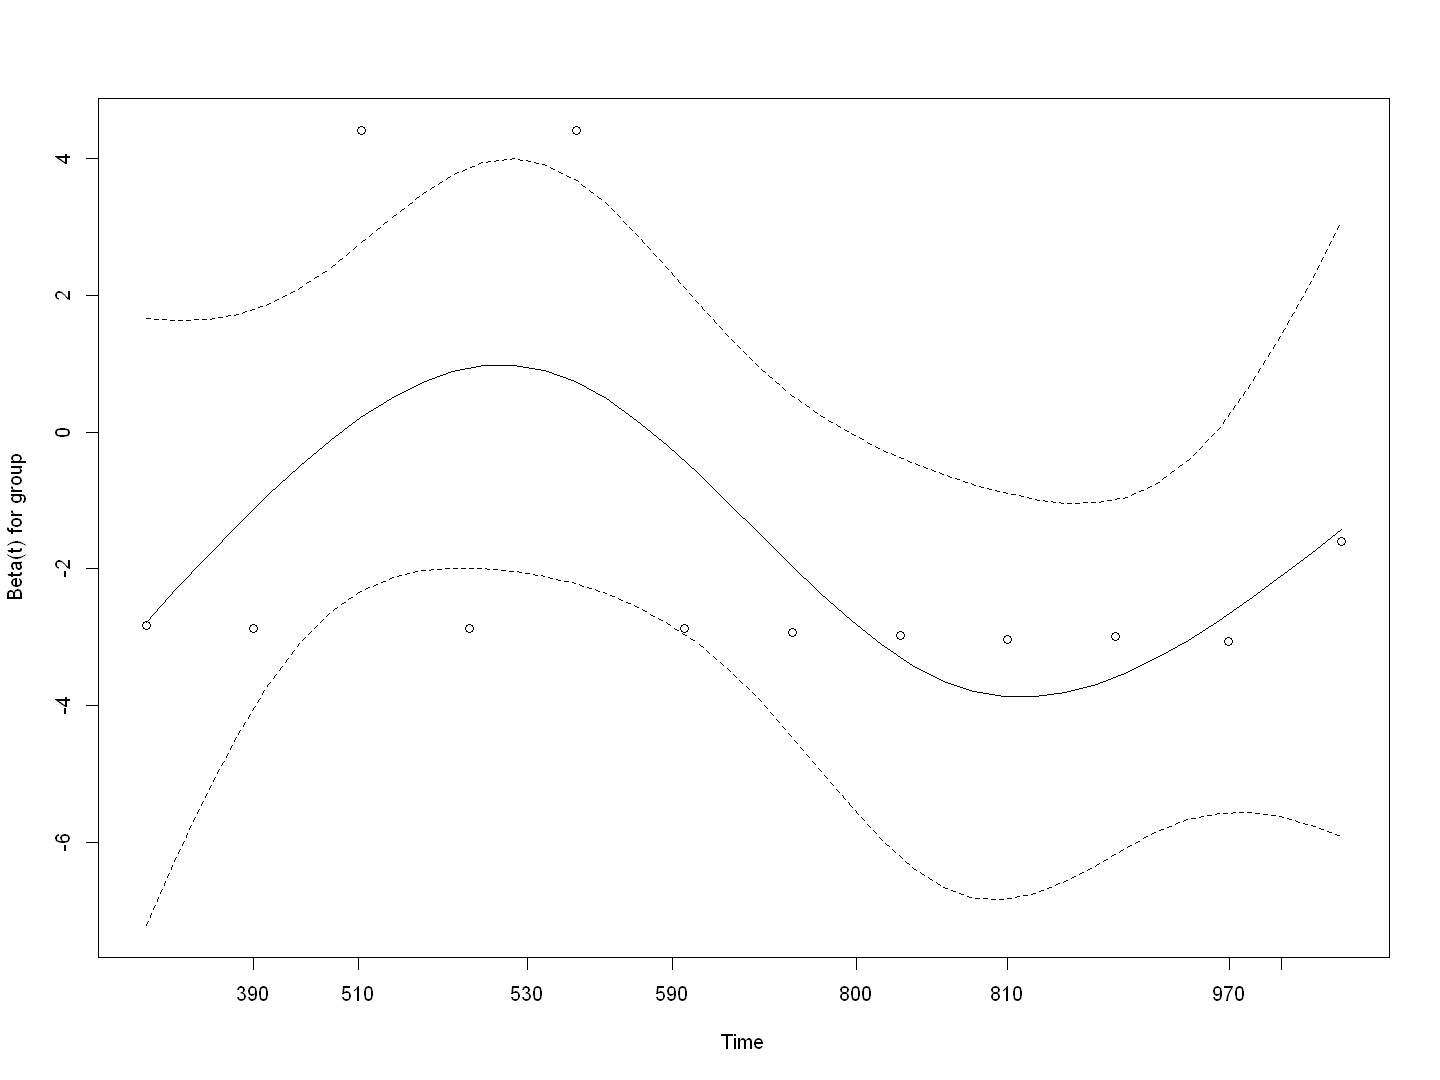

In [116]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption:\n")
ph_test <- cox.zph(cox_fit_og)
print(ph_test)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test)


### 2.2  Adjusted — group + оперированные пазухи (sinuses)


#### Все группы

In [117]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + sinuses, data = first_reop_df)
cat("\nCox PH model summary (group + sinuses):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + sinuses):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sinuses, 
    data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ1 -2.0303    0.1313   1.0793 -1.881    0.060 .
groupОГ2 -1.1242    0.3249   1.1072 -1.015    0.310  
sinuses  -0.2557    0.7743   0.1365 -1.873    0.061 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.1313      7.616   0.01583     1.089
groupОГ2    0.3249      3.078   0.03709     2.846
sinuses     0.7743      1.291   0.59254     1.012

Concordance= 0.758  (se = 0.065 )
Likelihood ratio test= 9.14  on 3 df,   p=0.03
Wald test            = 8.13  on 3 df,   p=0.04
Score (logrank) test = 9.42  on 3 df,   p=0.02




Test of PH assumption (Schoenfeld residuals):


         chisq df    p
group   1.4672  2 0.48
sinuses 0.0511  1 0.82
GLOBAL  1.6951  3 0.64


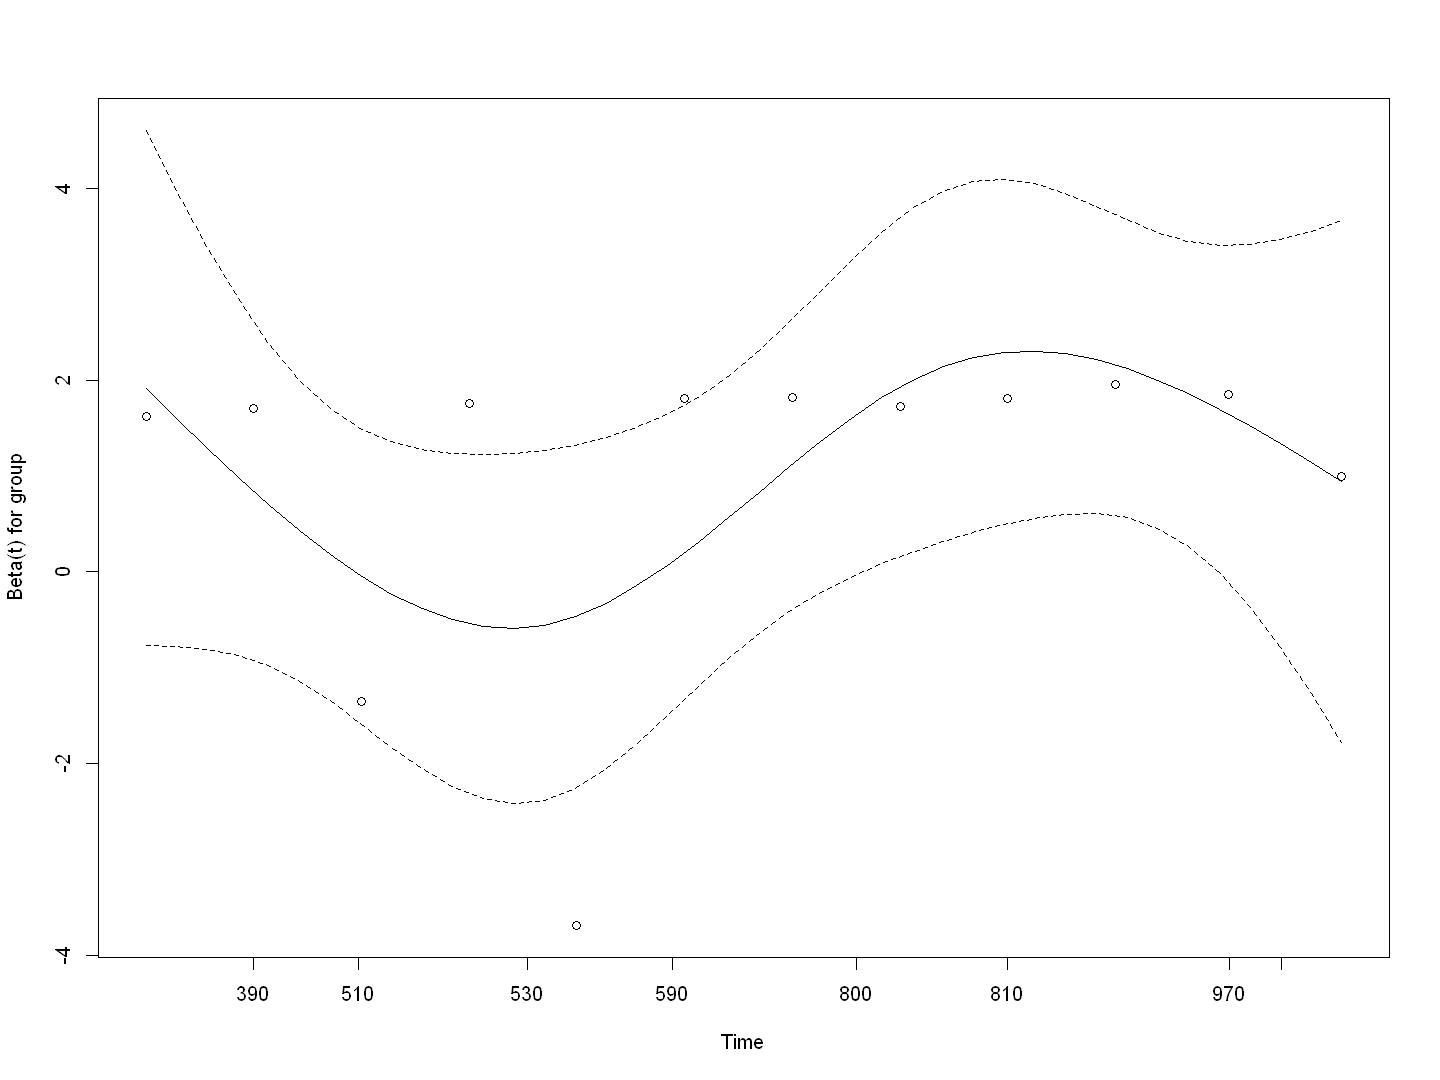

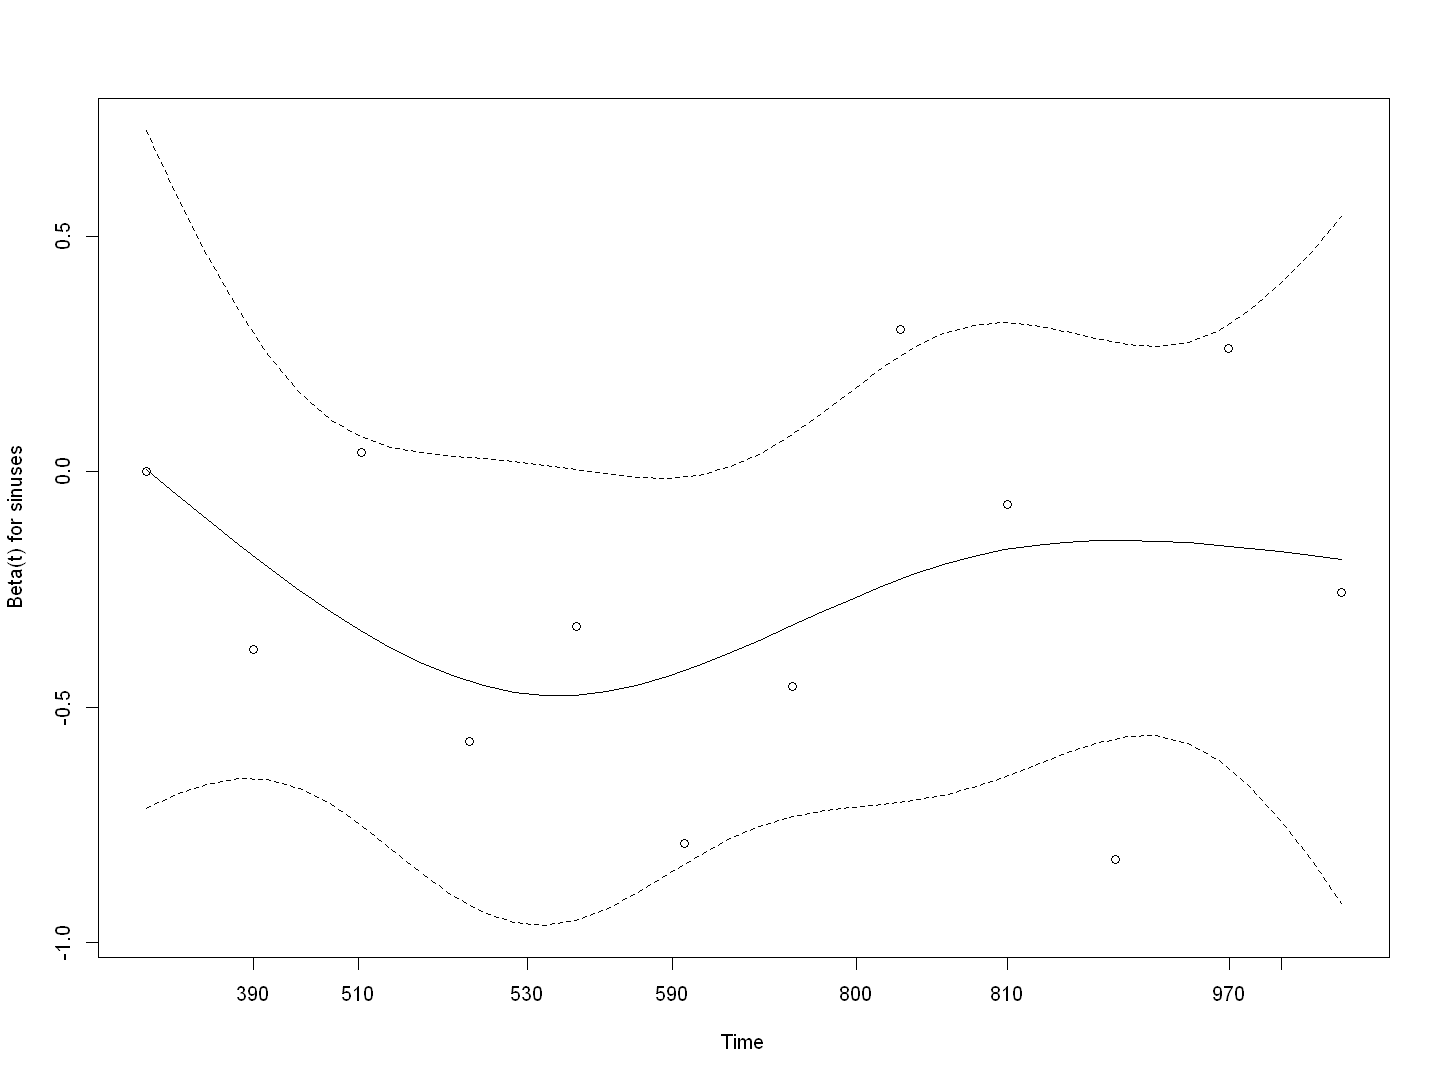

In [118]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [119]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + sinuses, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + sinuses):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + sinuses):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sinuses, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.6636    0.1895   0.7846 -2.120   0.0340 *
sinuses -0.2276    0.7964   0.1261 -1.804   0.0712 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.1895      5.278   0.04071    0.8818
sinuses    0.7964      1.256   0.62200    1.0198

Concordance= 0.753  (se = 0.069 )
Likelihood ratio test= 8.79  on 2 df,   p=0.01
Wald test            = 7.26  on 2 df,   p=0.03
Score (logrank) test = 8.46  on 2 df,   p=0.01




Test of PH assumption:


         chisq df    p
group   1.2983  1 0.25
sinuses 0.0579  1 0.81
GLOBAL  1.3208  2 0.52


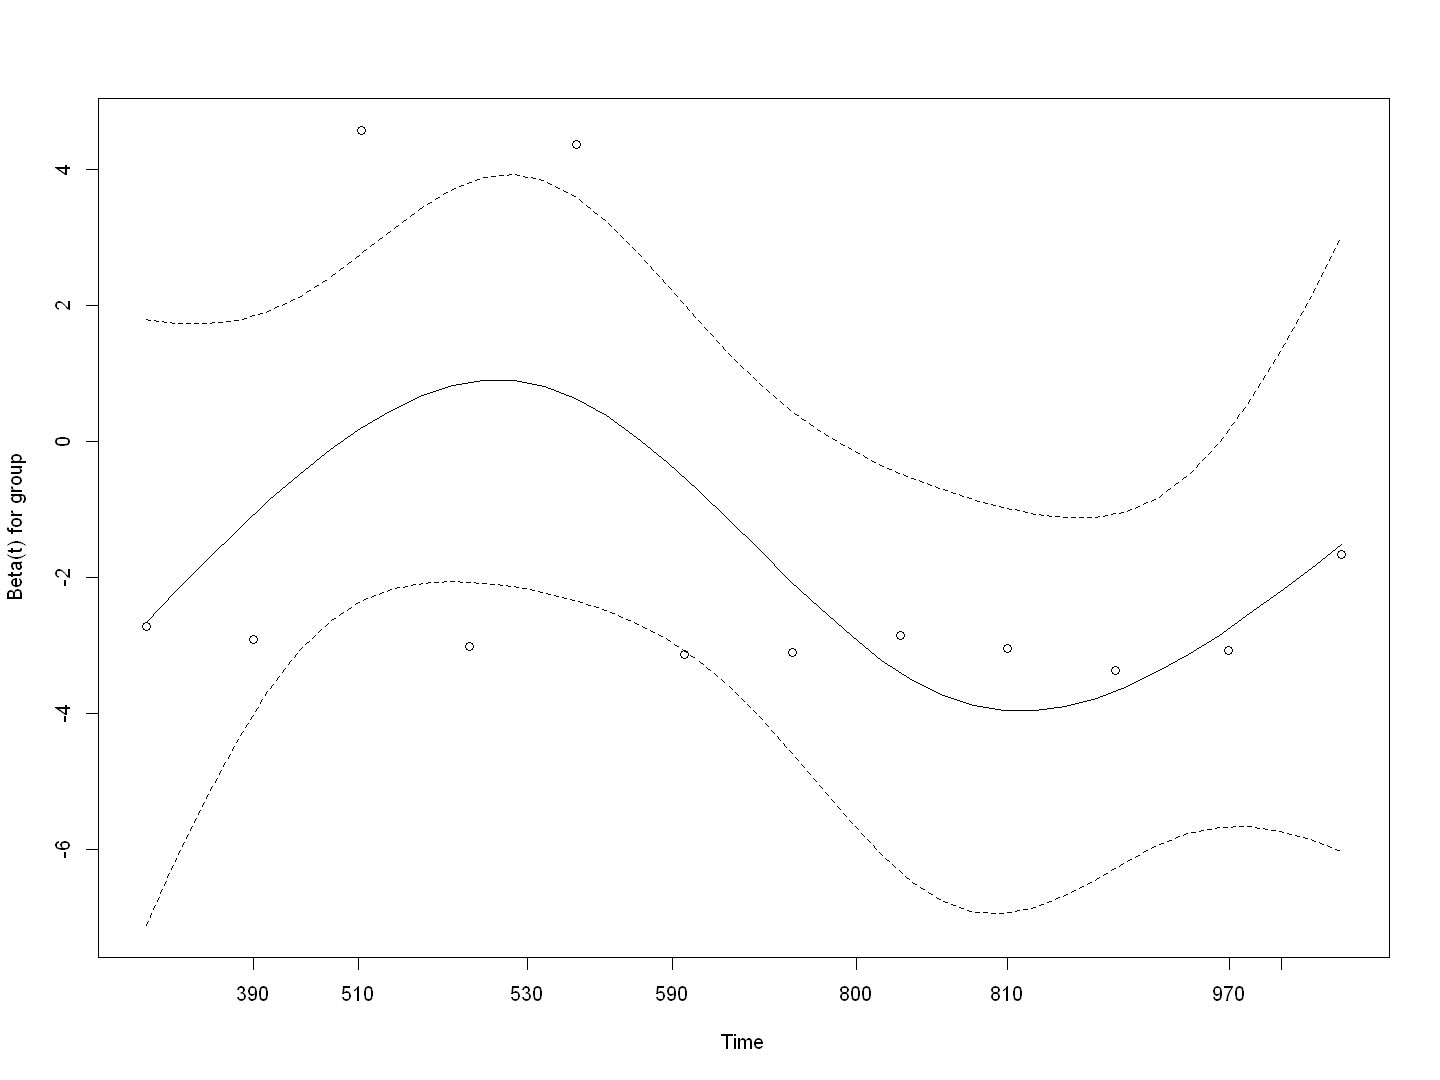

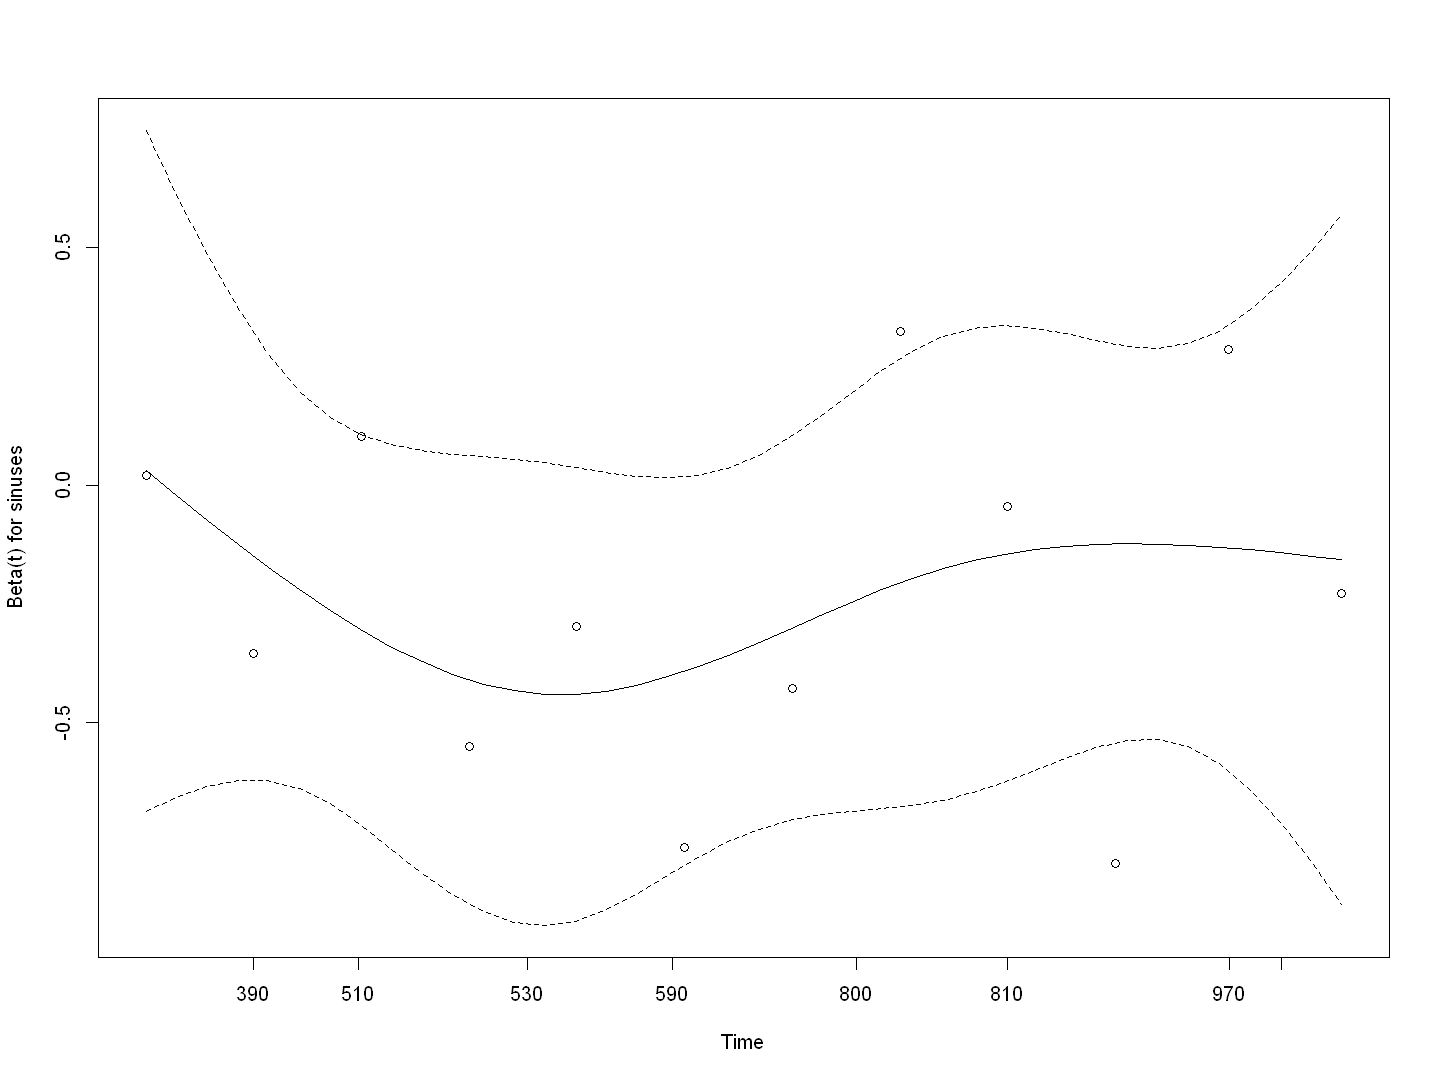

In [120]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + возраст


#### Все группы

In [121]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + age, data = first_reop_df)
cat("\nCox PH model summary (group + age):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + age):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + age, 
    data = first_reop_df)

  n= 50, number of events= 12 

             coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.63796   0.19438  1.05550 -1.552    0.121
groupОГ2 -1.68003   0.18637  1.05530 -1.592    0.111
age      -0.02146   0.97877  0.02345 -0.915    0.360

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.1944      5.145   0.02456     1.538
groupОГ2    0.1864      5.366   0.02356     1.474
age         0.9788      1.022   0.93480     1.025

Concordance= 0.693  (se = 0.067 )
Likelihood ratio test= 6.39  on 3 df,   p=0.09
Wald test            = 5.1  on 3 df,   p=0.2
Score (logrank) test = 6.11  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group  1.268  2 0.53
age    0.388  1 0.53
GLOBAL 1.744  3 0.63


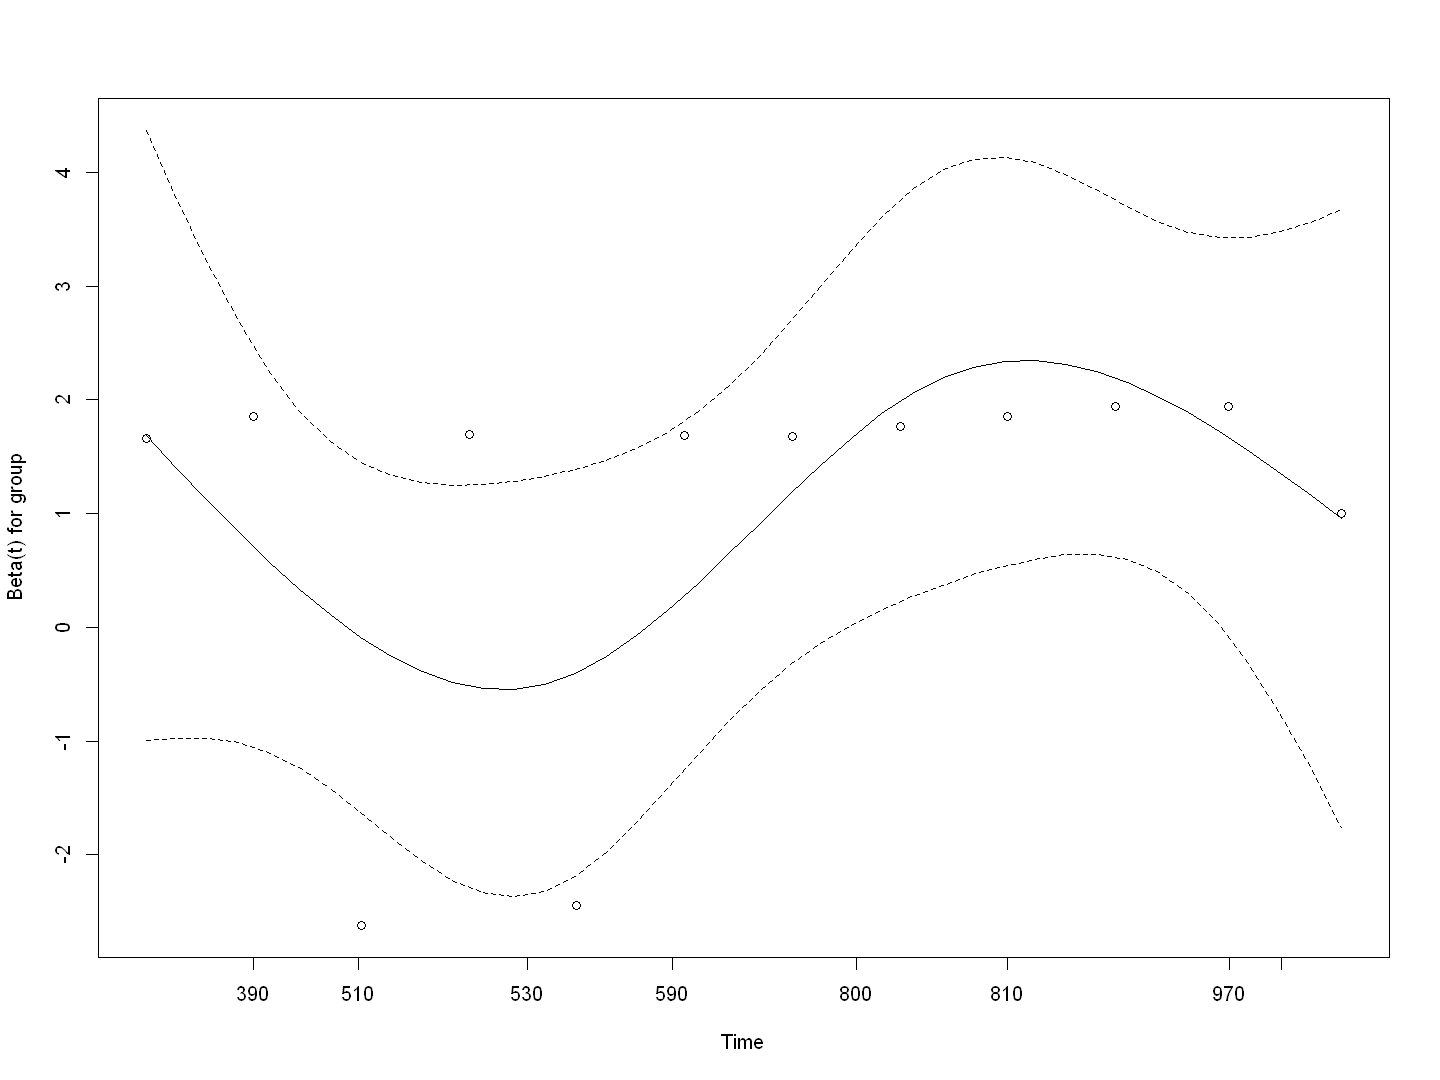

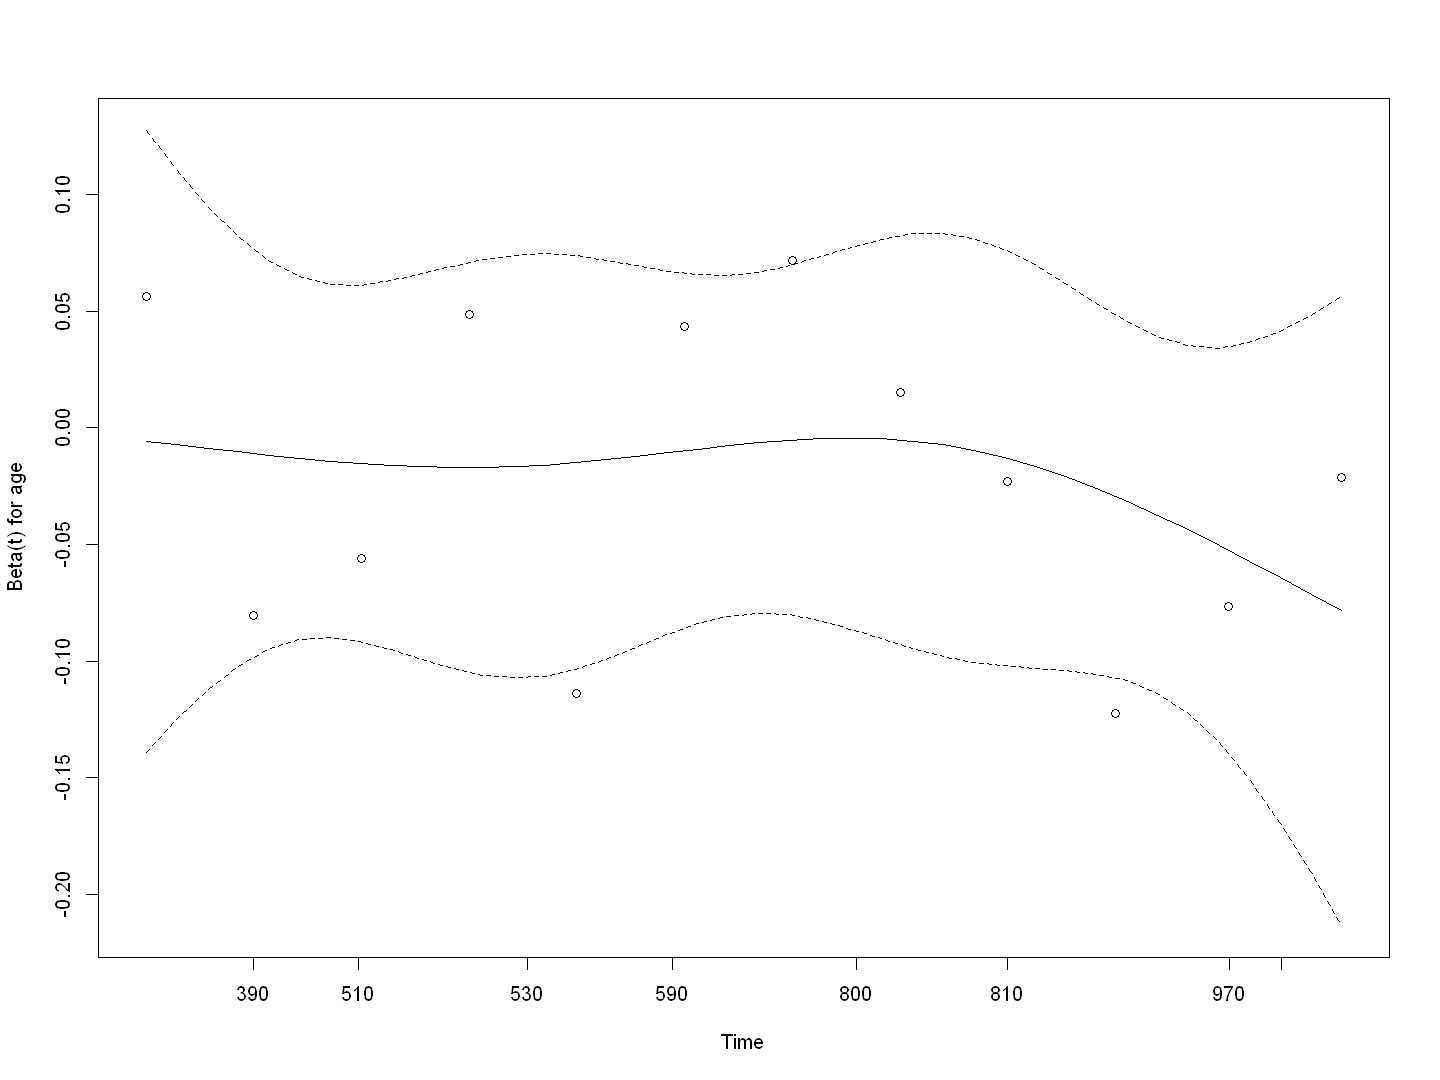

In [122]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [123]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + age, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + age):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + age):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + age, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.65922   0.19029  0.78341 -2.118   0.0342 *
age     -0.02146   0.97877  0.02346 -0.915   0.3604  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.1903      5.255   0.04098    0.8836
age        0.9788      1.022   0.93479    1.0248

Concordance= 0.695  (se = 0.067 )
Likelihood ratio test= 6.39  on 2 df,   p=0.04
Wald test            = 5.1  on 2 df,   p=0.08
Score (logrank) test = 6.11  on 2 df,   p=0.05




Test of PH assumption:


       chisq df    p
group  1.078  1 0.30
age    0.388  1 0.53
GLOBAL 1.557  2 0.46


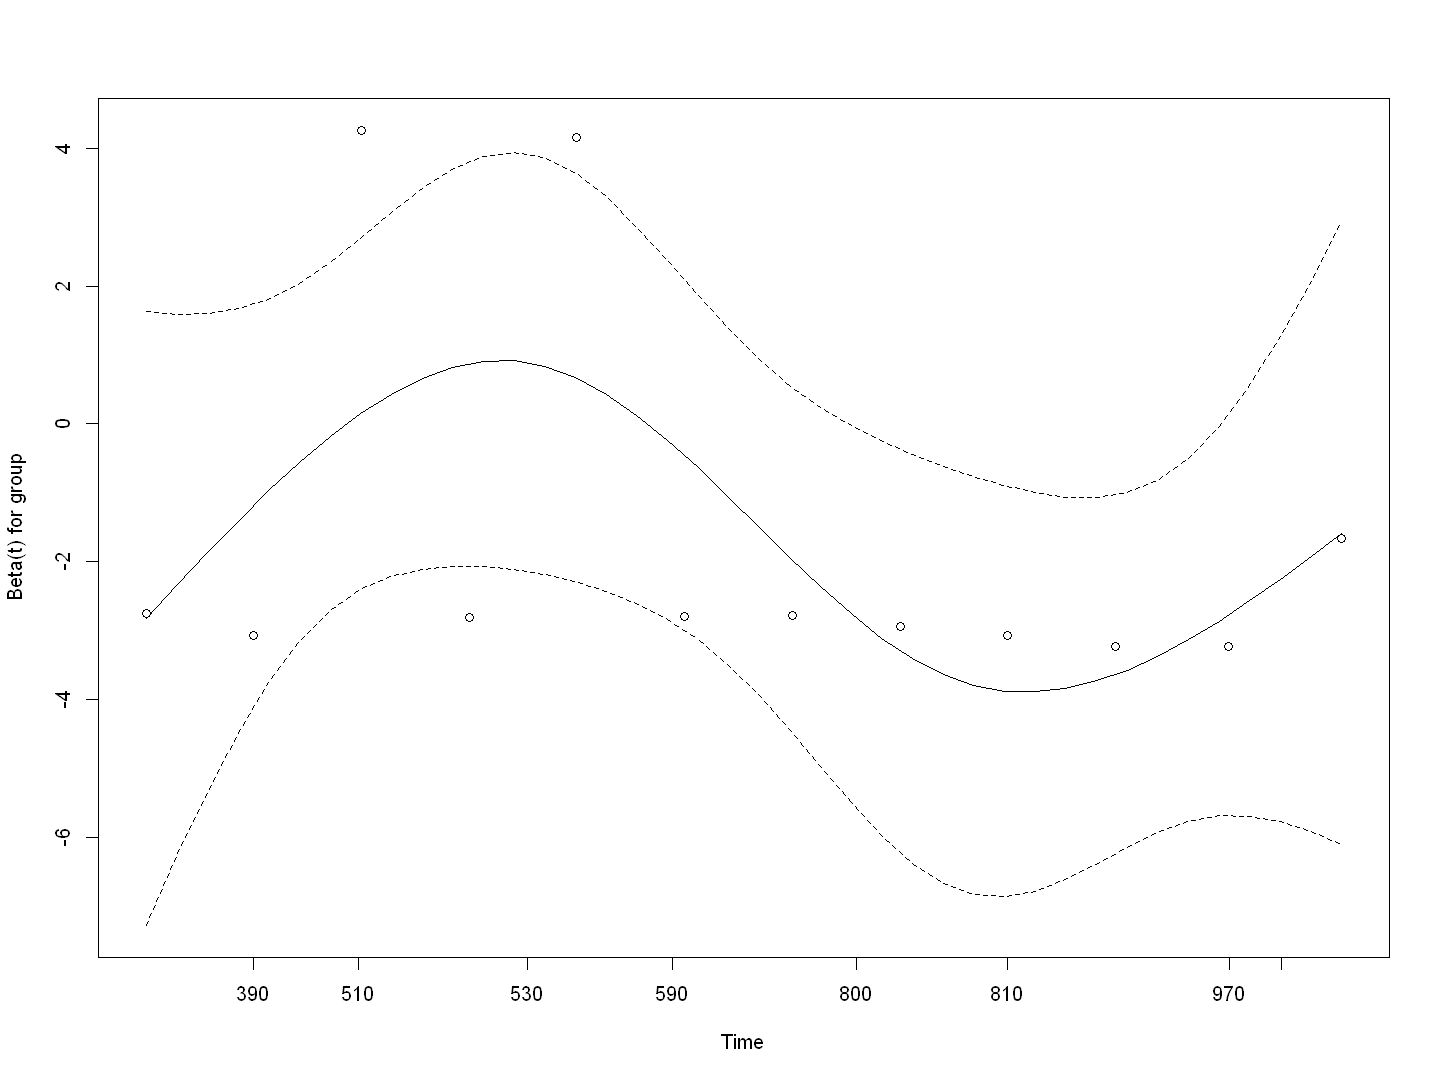

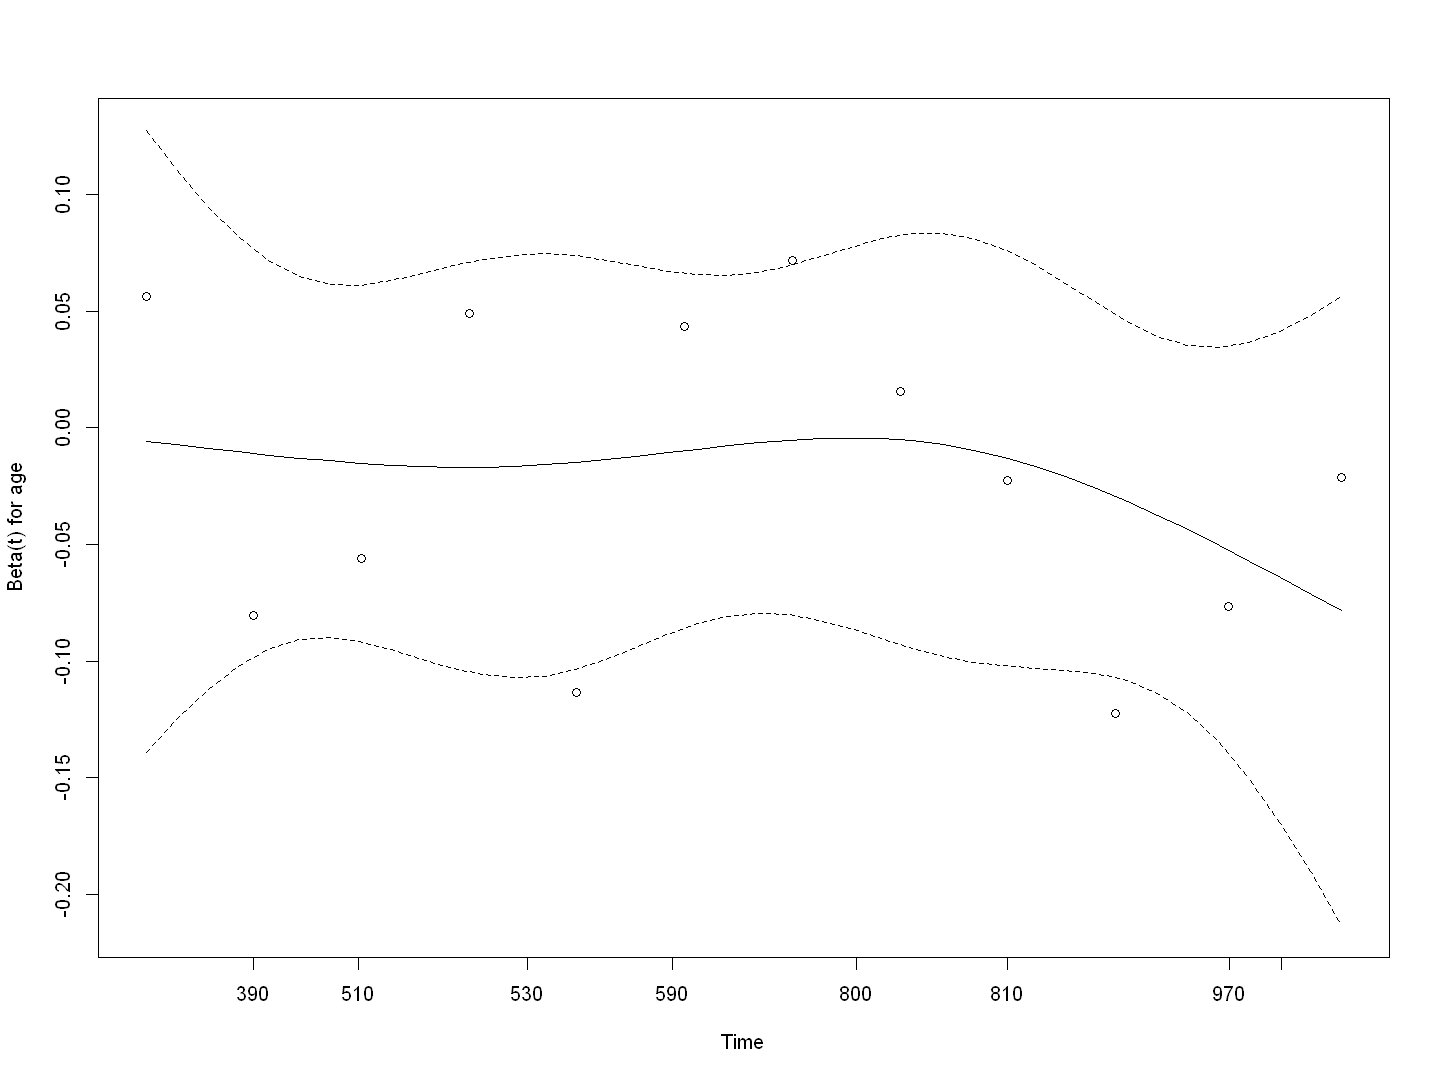

In [124]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + пол


#### Все группы

In [125]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + sex, data = first_reop_df)
cat("\nCox PH model summary (group + sex):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + sex):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sex, 
    data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.4906    0.2252   1.0575 -1.409    0.159
groupОГ2 -1.6100    0.1999   1.0547 -1.527    0.127
sexмуж.  -0.8804    0.4146   0.6102 -1.443    0.149

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2252      4.440   0.02834     1.790
groupОГ2    0.1999      5.003   0.02529     1.580
sexмуж.     0.4146      2.412   0.12539     1.371

Concordance= 0.725  (se = 0.088 )
Likelihood ratio test= 7.51  on 3 df,   p=0.06
Wald test            = 6.31  on 3 df,   p=0.1
Score (logrank) test = 7.5  on 3 df,   p=0.06




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group   1.51  2 0.47
sex     2.64  1 0.10
GLOBAL  4.32  3 0.23


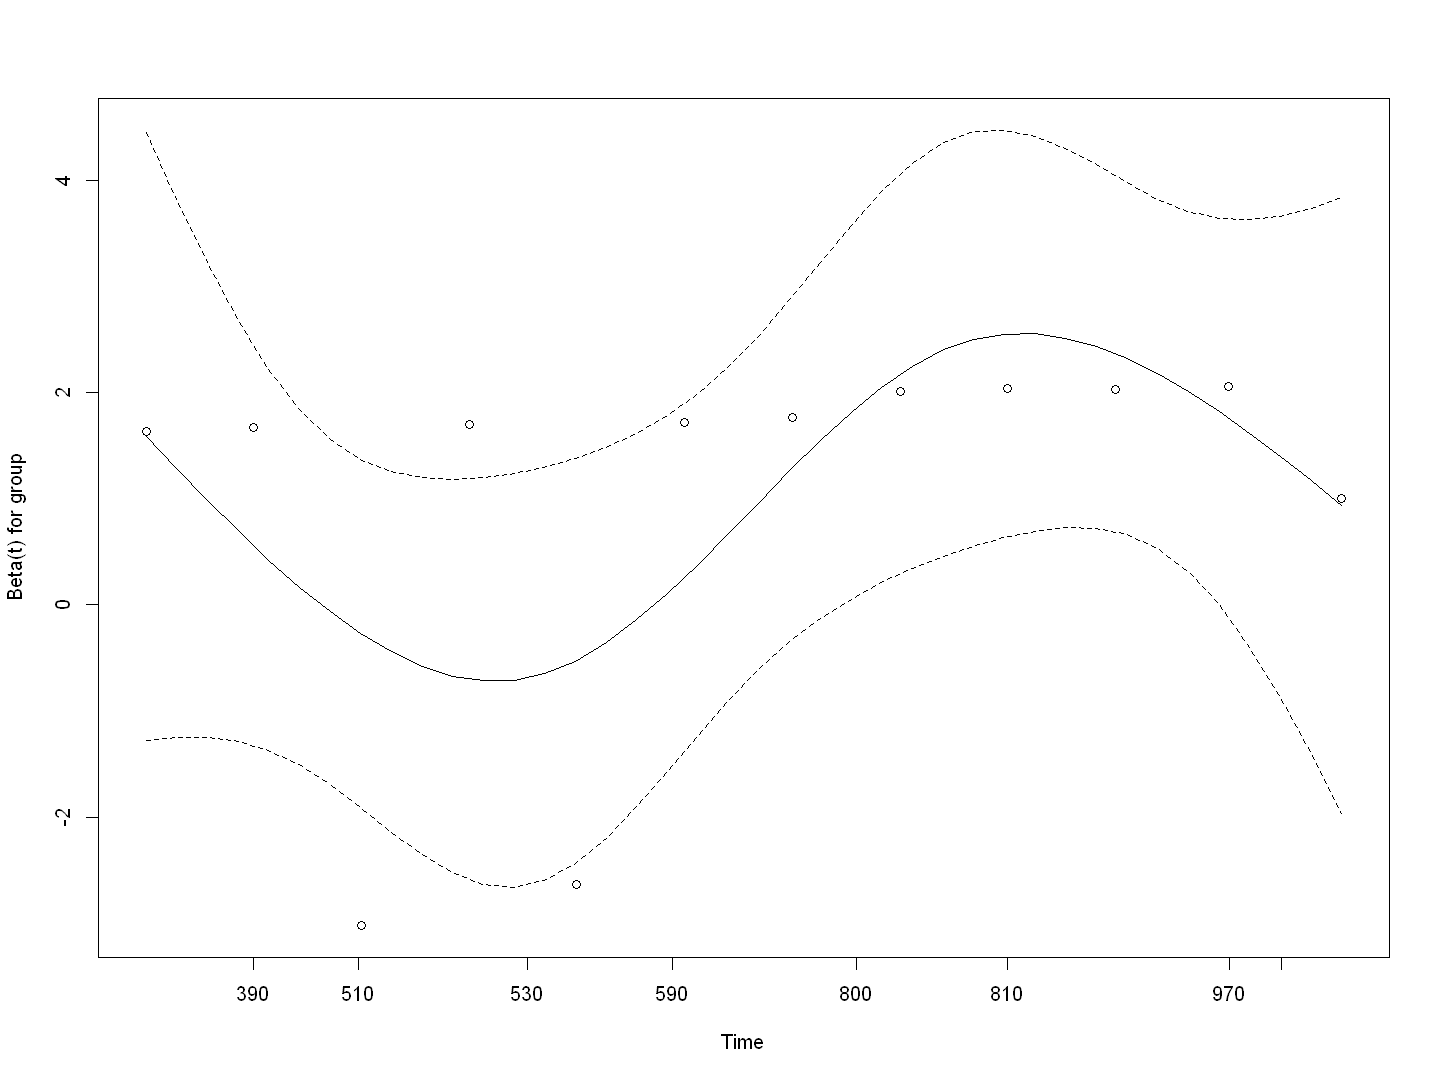

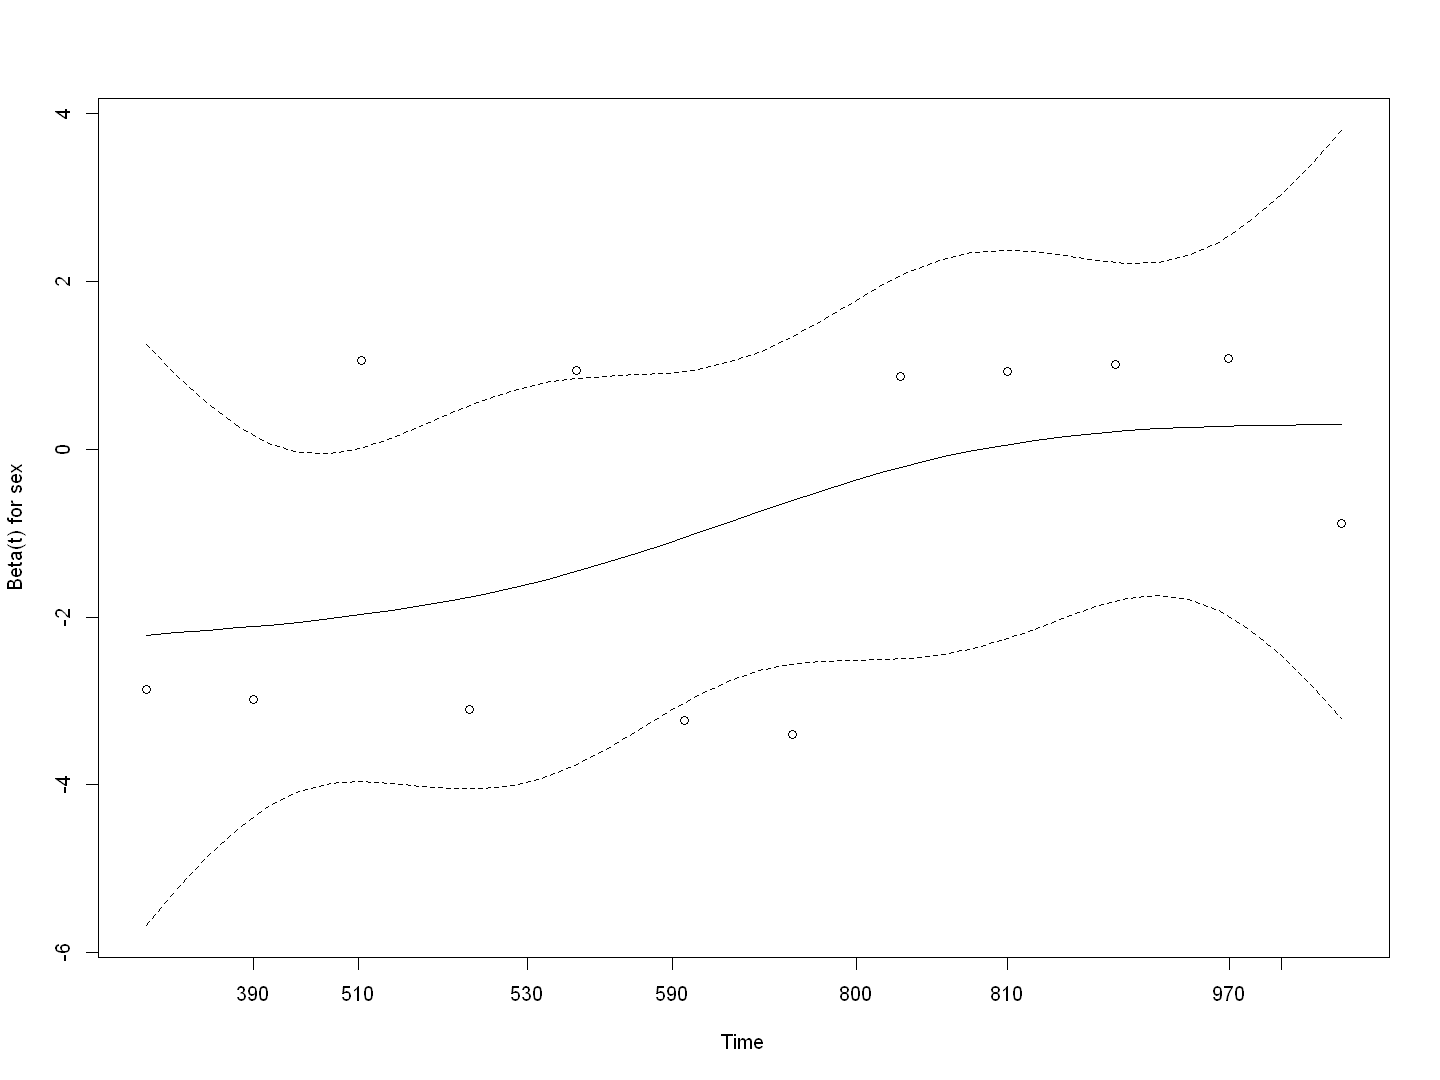

In [126]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [127]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + sex, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + sex):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + sex):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + sex, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.5523    0.2118   0.7835 -1.981   0.0476 *
sexмуж. -0.8779    0.4157   0.6094 -1.441   0.1497  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.2118      4.722   0.04559    0.9836
sexмуж.    0.4157      2.406   0.12590    1.3723

Concordance= 0.726  (se = 0.085 )
Likelihood ratio test= 7.51  on 2 df,   p=0.02
Wald test            = 6.3  on 2 df,   p=0.04
Score (logrank) test = 7.49  on 2 df,   p=0.02




Test of PH assumption:


       chisq df    p
group   1.31  1 0.25
sex     2.64  1 0.10
GLOBAL  4.19  2 0.12


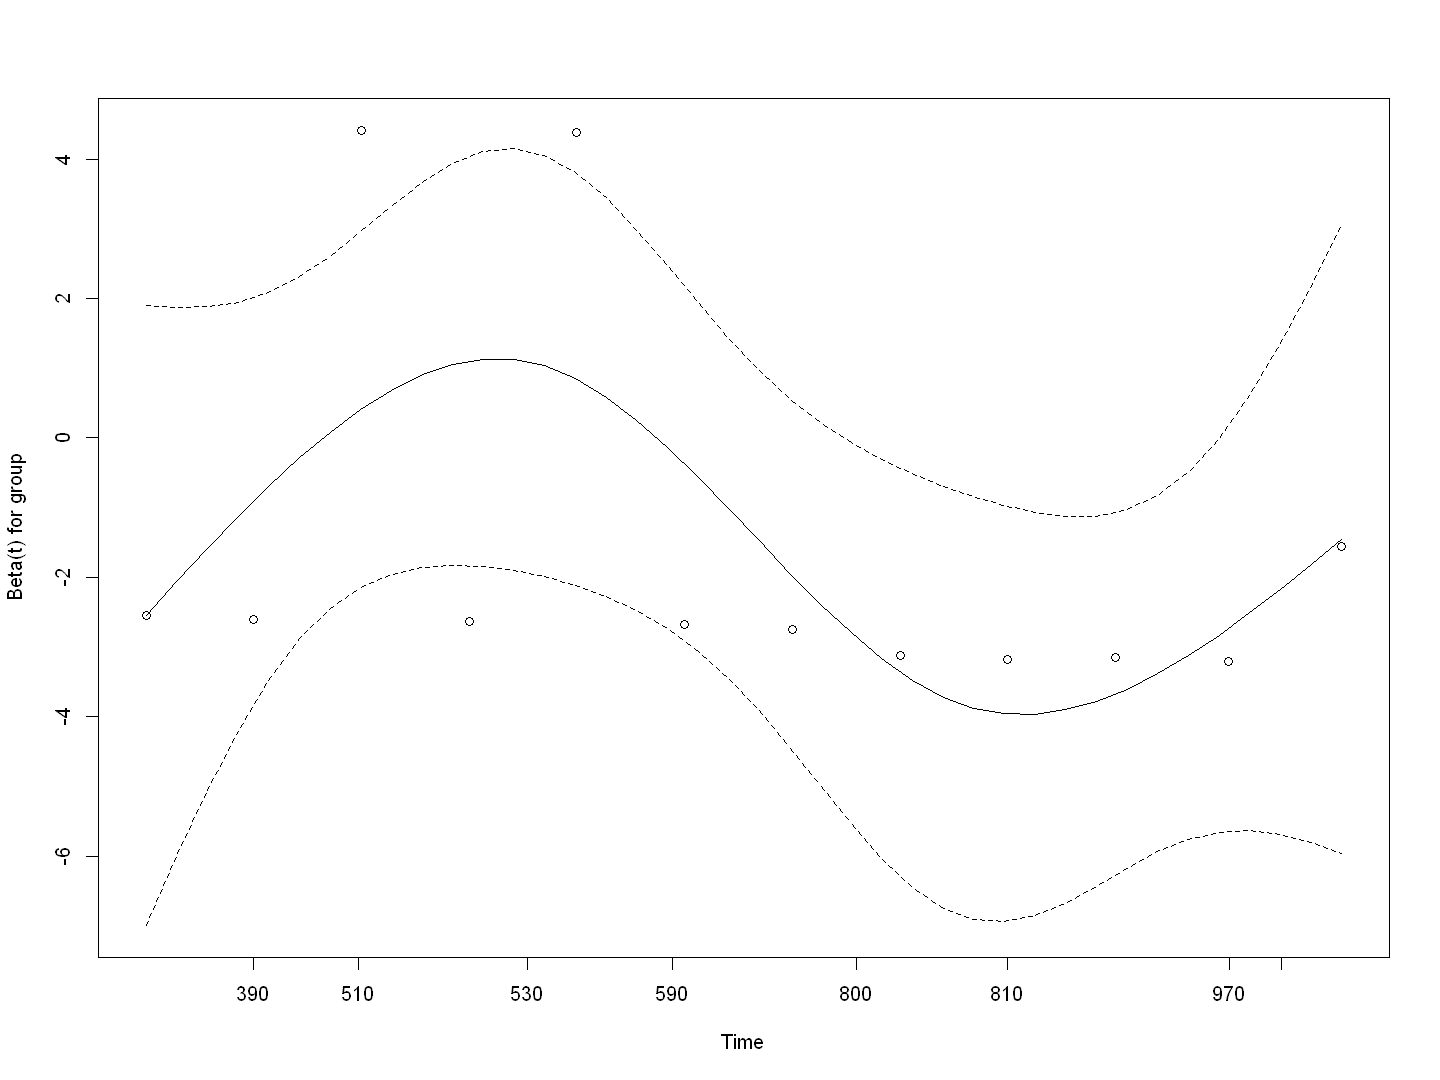

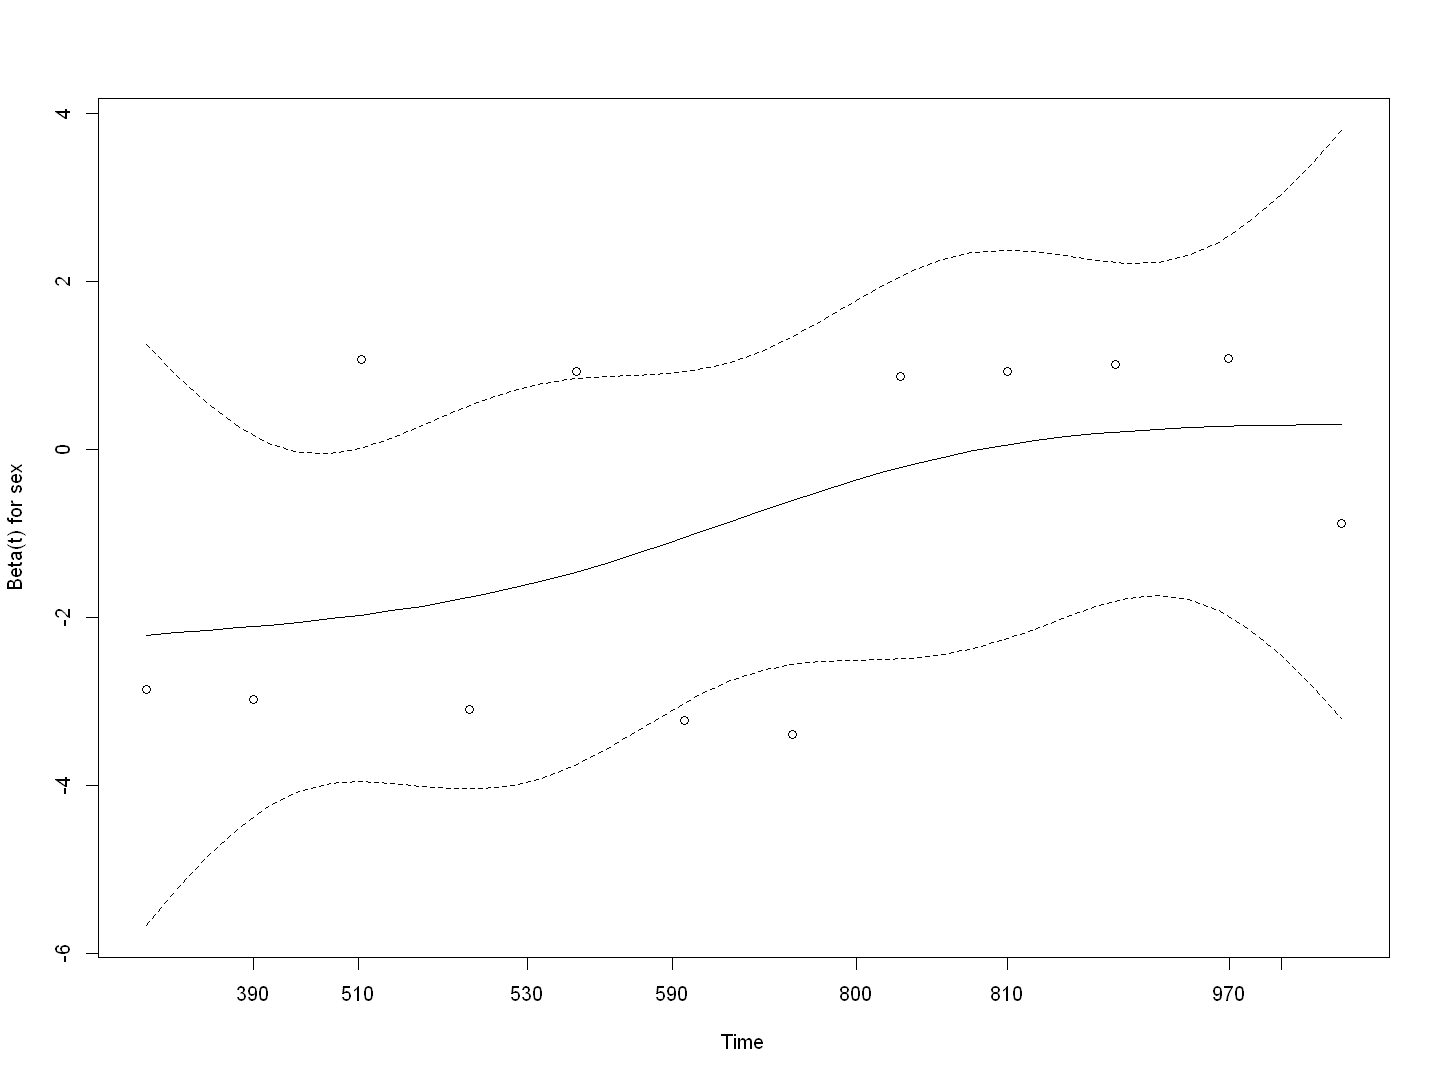

In [128]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + длительность заболевания


#### Все группы

In [129]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + ill_dur, data = first_reop_df)
cat("\nCox PH model summary (group + ill_dur):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + ill_dur):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + ill_dur, 
    data = first_reop_df)

  n= 50, number of events= 12 

             coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.65890   0.19035  1.07174 -1.548    0.122
groupОГ2 -1.63167   0.19560  1.05472 -1.547    0.122
ill_dur   0.01843   1.01860  0.04980  0.370    0.711

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.1903     5.2535   0.02330     1.555
groupОГ2    0.1956     5.1124   0.02475     1.546
ill_dur     1.0186     0.9817   0.92387     1.123

Concordance= 0.683  (se = 0.093 )
Likelihood ratio test= 5.68  on 3 df,   p=0.1
Wald test            = 4.34  on 3 df,   p=0.2
Score (logrank) test = 5.33  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


        chisq df    p
group   1.333  2 0.51
ill_dur 0.682  1 0.41
GLOBAL  2.234  3 0.53


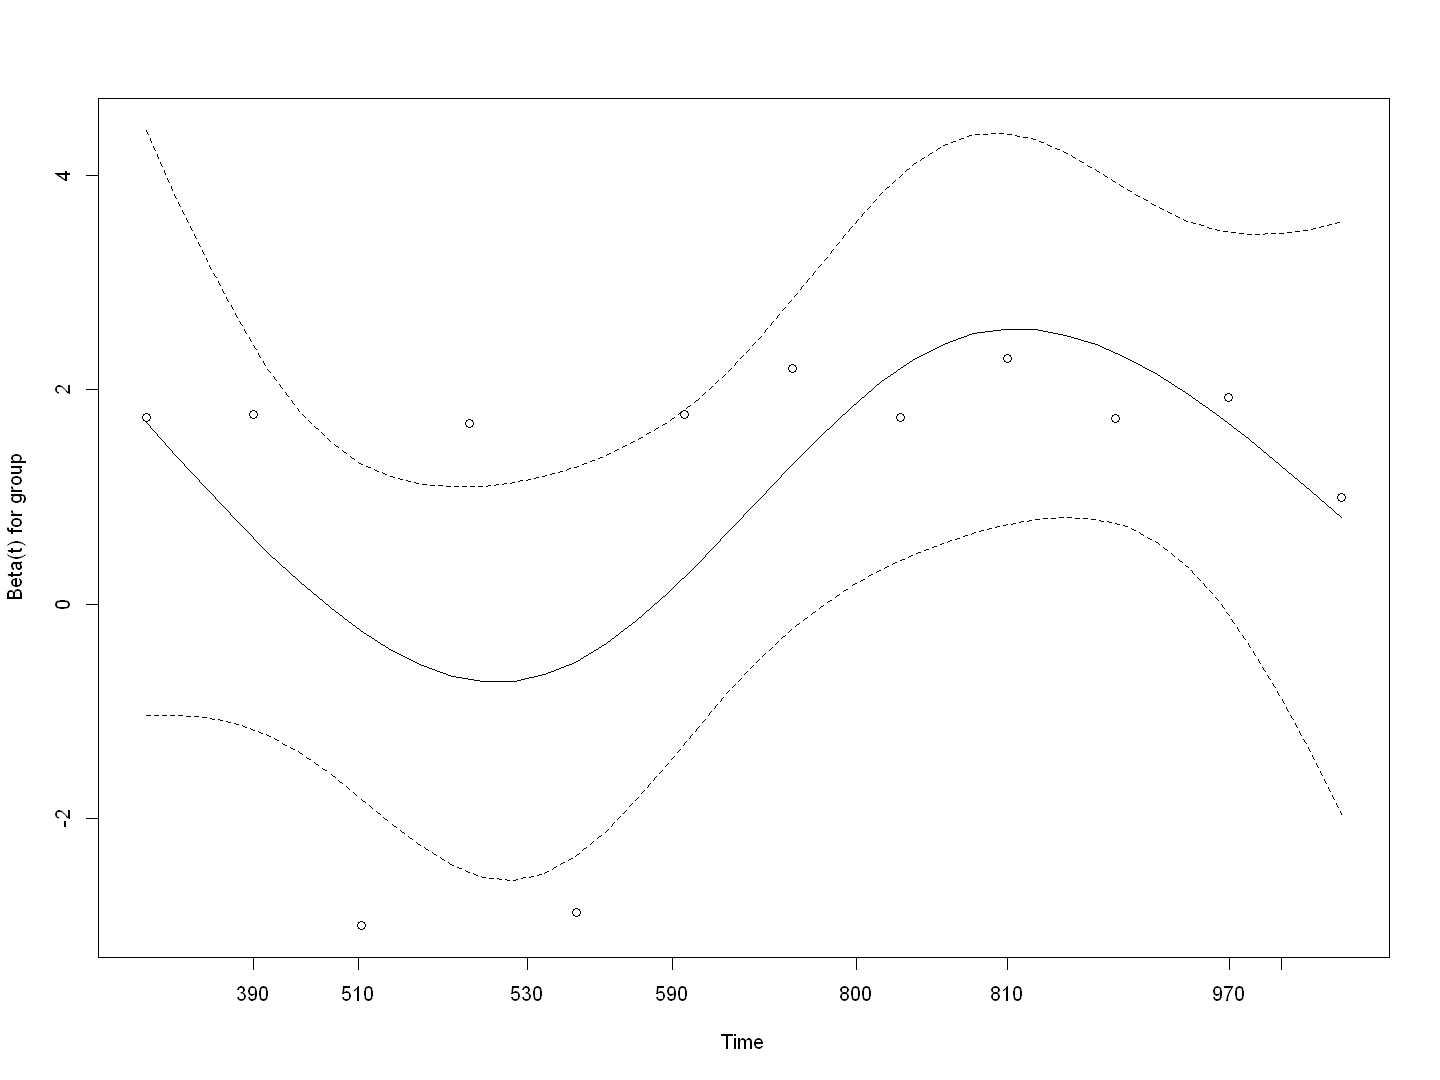

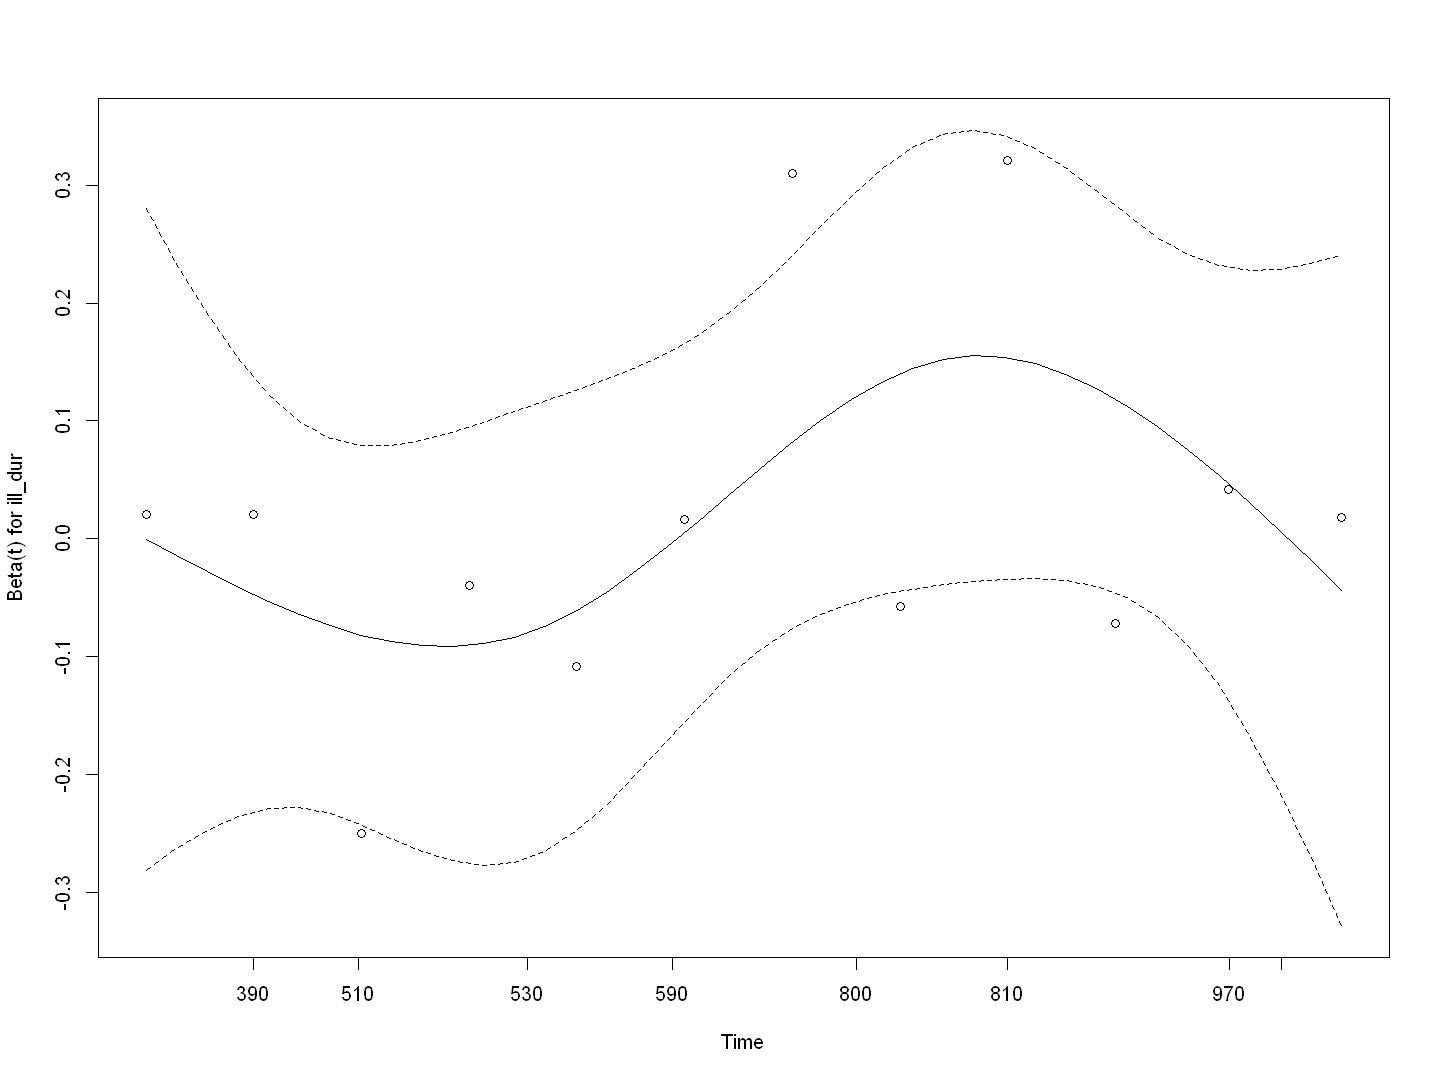

In [130]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [131]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + ill_dur, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + ill_dur):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + ill_dur):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + ill_dur, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.64513   0.19299  0.78999 -2.082   0.0373 *
ill_dur  0.01832   1.01849  0.04951  0.370   0.7113  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ     0.193     5.1817   0.04103    0.9078
ill_dur     1.018     0.9818   0.92431    1.1223

Concordance= 0.683  (se = 0.093 )
Likelihood ratio test= 5.67  on 2 df,   p=0.06
Wald test            = 4.34  on 2 df,   p=0.1
Score (logrank) test = 5.32  on 2 df,   p=0.07




Test of PH assumption:


        chisq df    p
group   1.151  1 0.28
ill_dur 0.682  1 0.41
GLOBAL  2.143  2 0.34


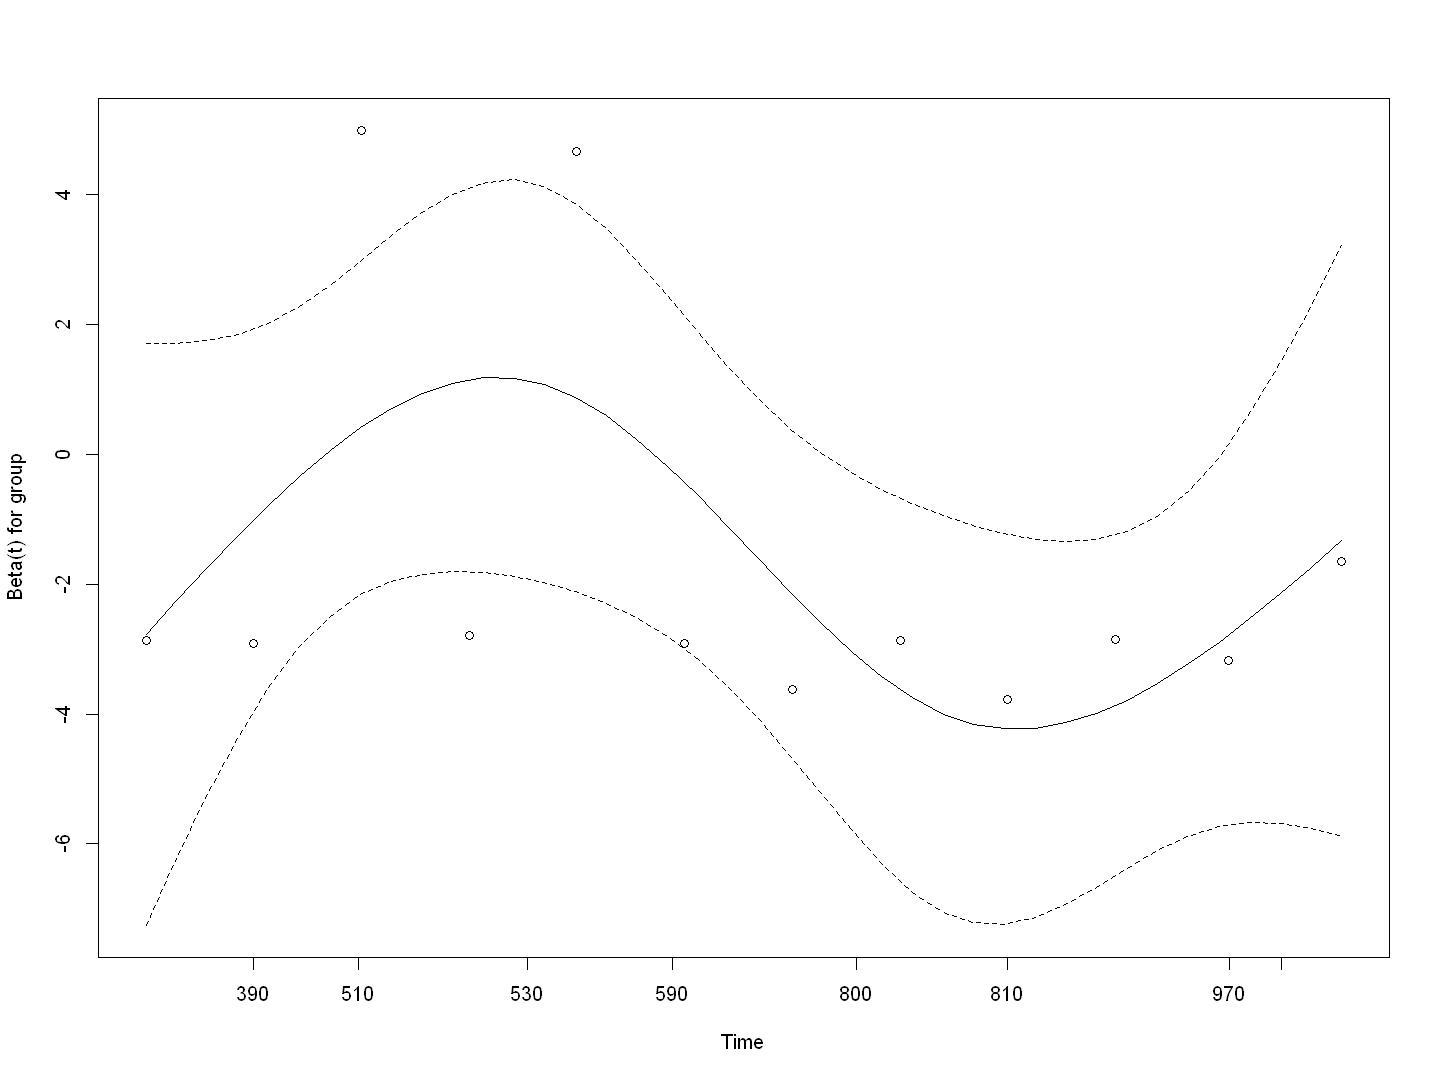

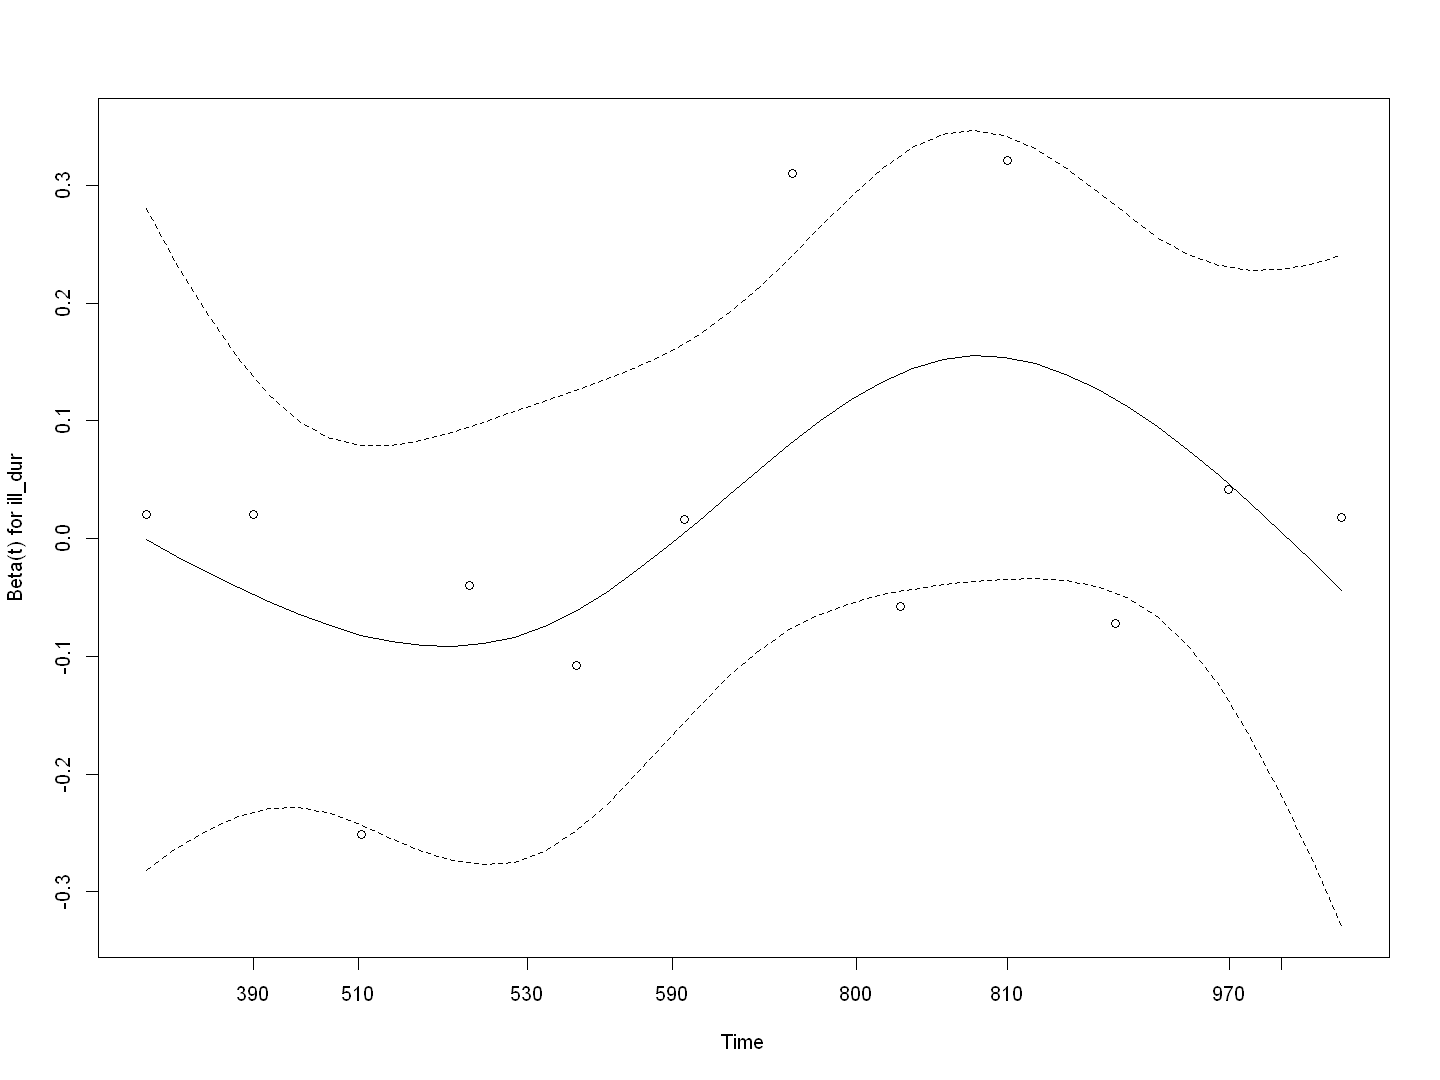

In [132]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + удаление полипов в анамнезе (polyps)


#### Все группы

In [133]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + polyps, data = first_reop_df)
cat("\nCox PH model summary (group + polyps):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + polyps):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + polyps, 
    data = first_reop_df)

  n= 50, number of events= 12 

             coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.56435   0.20922  1.05617 -1.481    0.139
groupОГ2 -1.59514   0.20288  1.05621 -1.510    0.131
polyps    0.06866   1.07108  0.13149  0.522    0.602

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.2092     4.7795    0.0264     1.658
groupОГ2    0.2029     4.9290    0.0256     1.608
polyps      1.0711     0.9336    0.8277     1.386

Concordance= 0.704  (se = 0.075 )
Likelihood ratio test= 5.79  on 3 df,   p=0.1
Wald test            = 4.53  on 3 df,   p=0.2
Score (logrank) test = 5.55  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


        chisq df    p
group  1.2985  2 0.52
polyps 0.0234  1 0.88
GLOBAL 1.3027  3 0.73


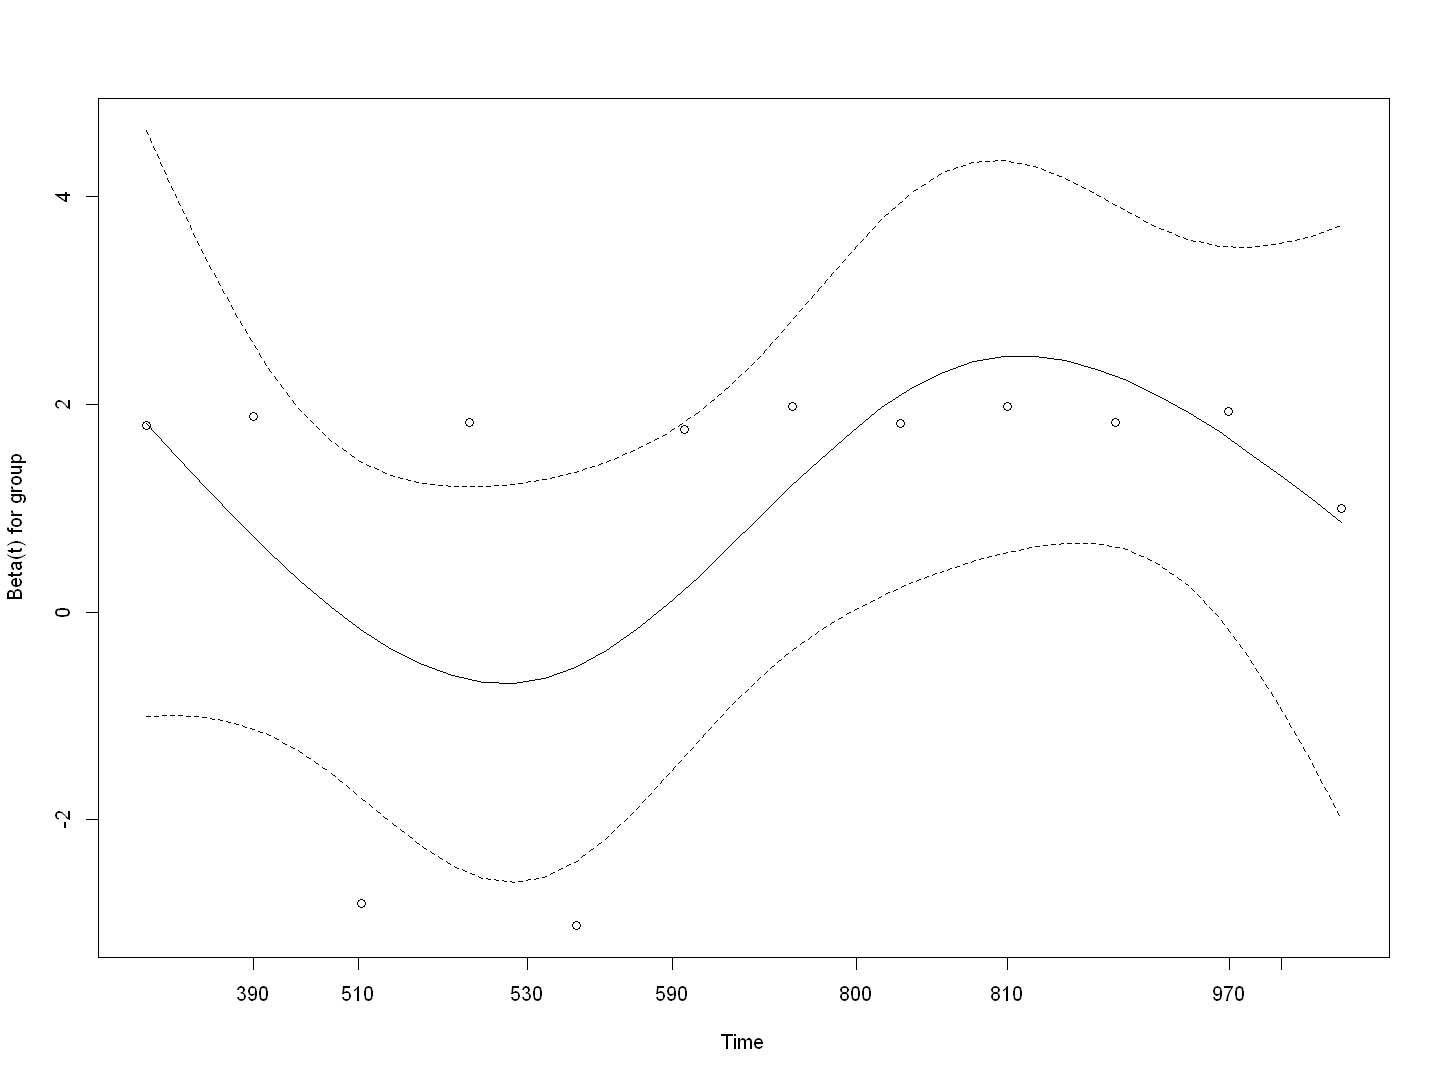

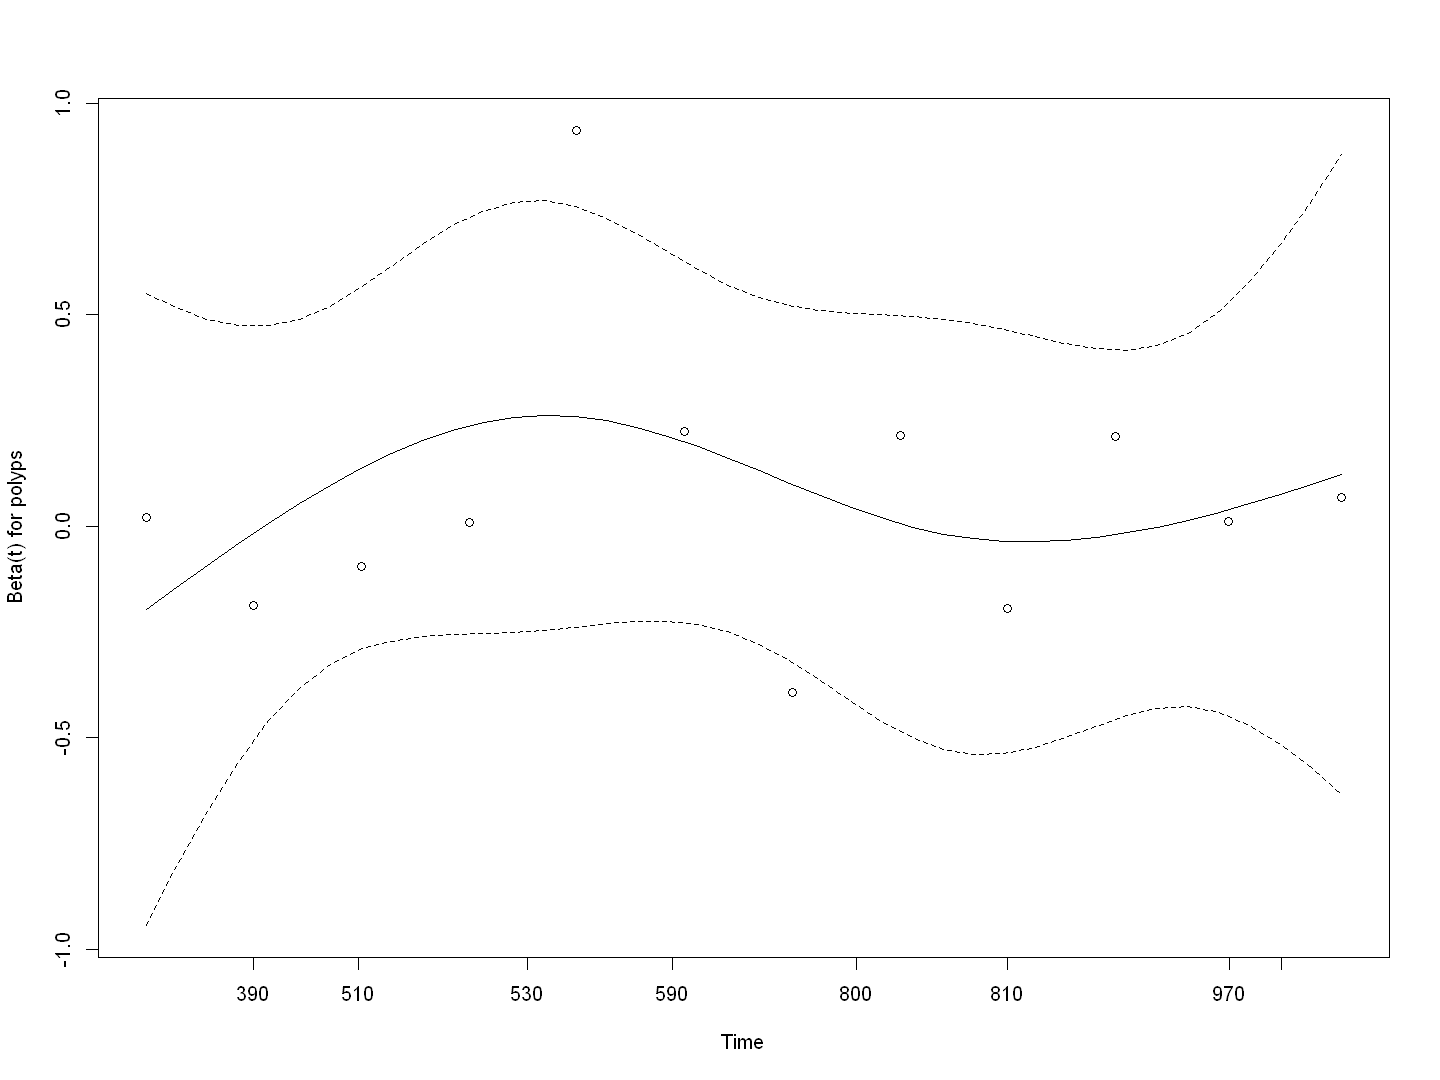

In [134]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [135]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + polyps, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + polyps):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + polyps):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + polyps, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.57986   0.20600  0.78448 -2.014    0.044 *
polyps   0.06867   1.07108  0.13148  0.522    0.601  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ     0.206     4.8543   0.04427    0.9586
polyps      1.071     0.9336   0.82777    1.3859

Concordance= 0.708  (se = 0.072 )
Likelihood ratio test= 5.79  on 2 df,   p=0.06
Wald test            = 4.53  on 2 df,   p=0.1
Score (logrank) test = 5.55  on 2 df,   p=0.06




Test of PH assumption:


        chisq df    p
group  1.1056  1 0.29
polyps 0.0233  1 0.88
GLOBAL 1.1103  2 0.57


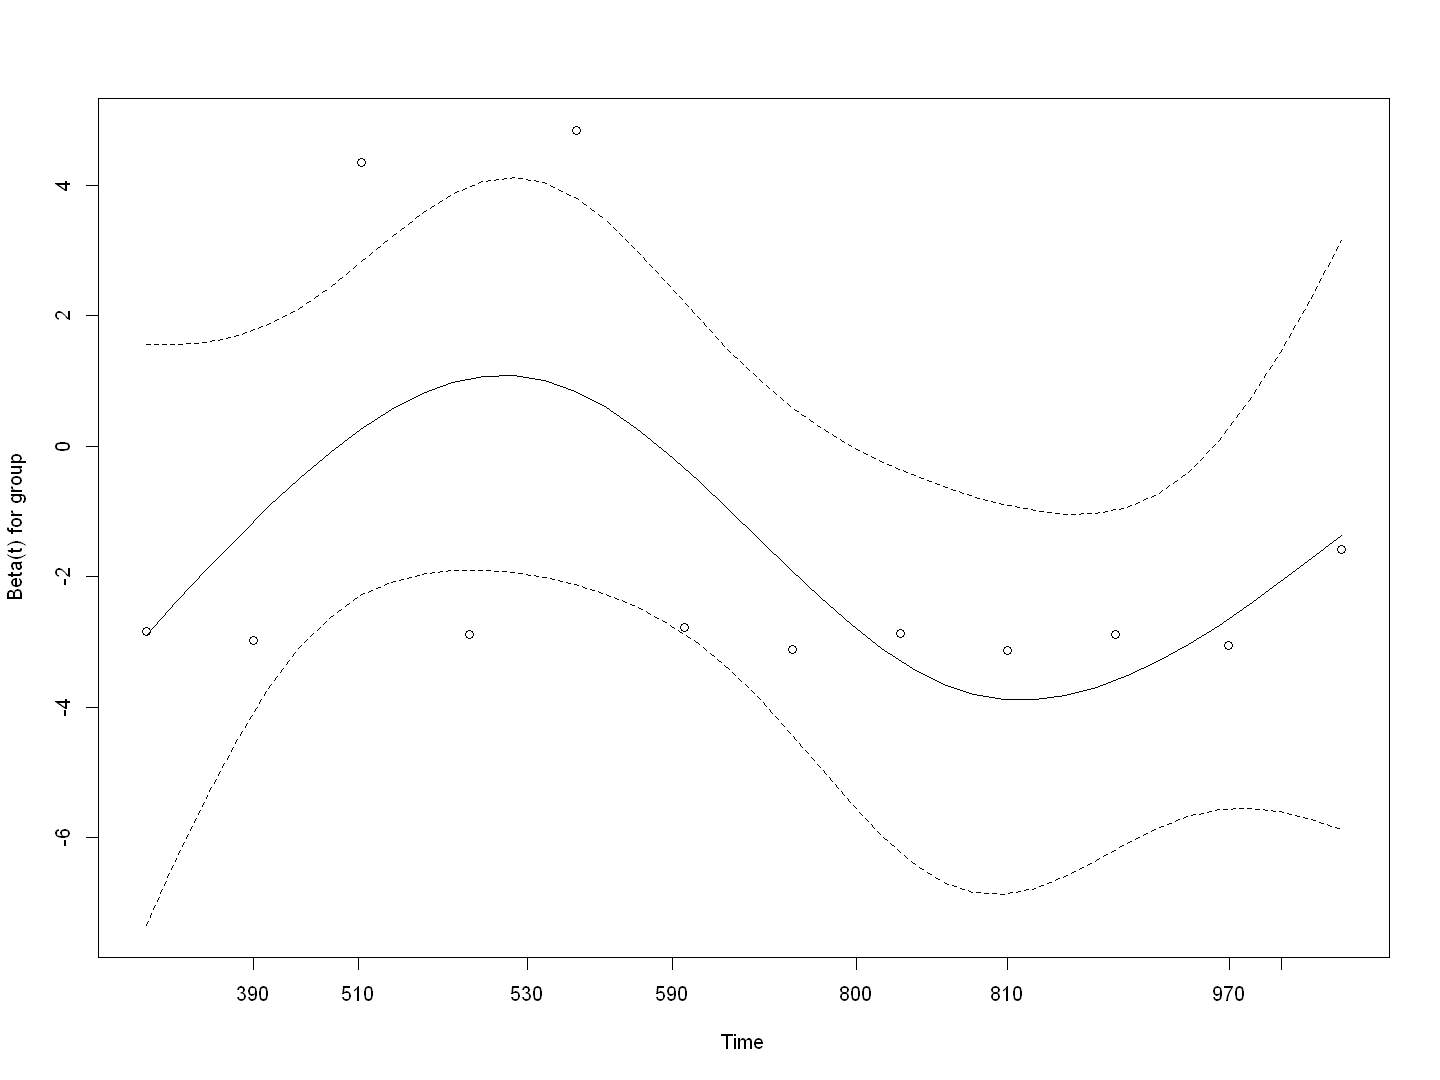

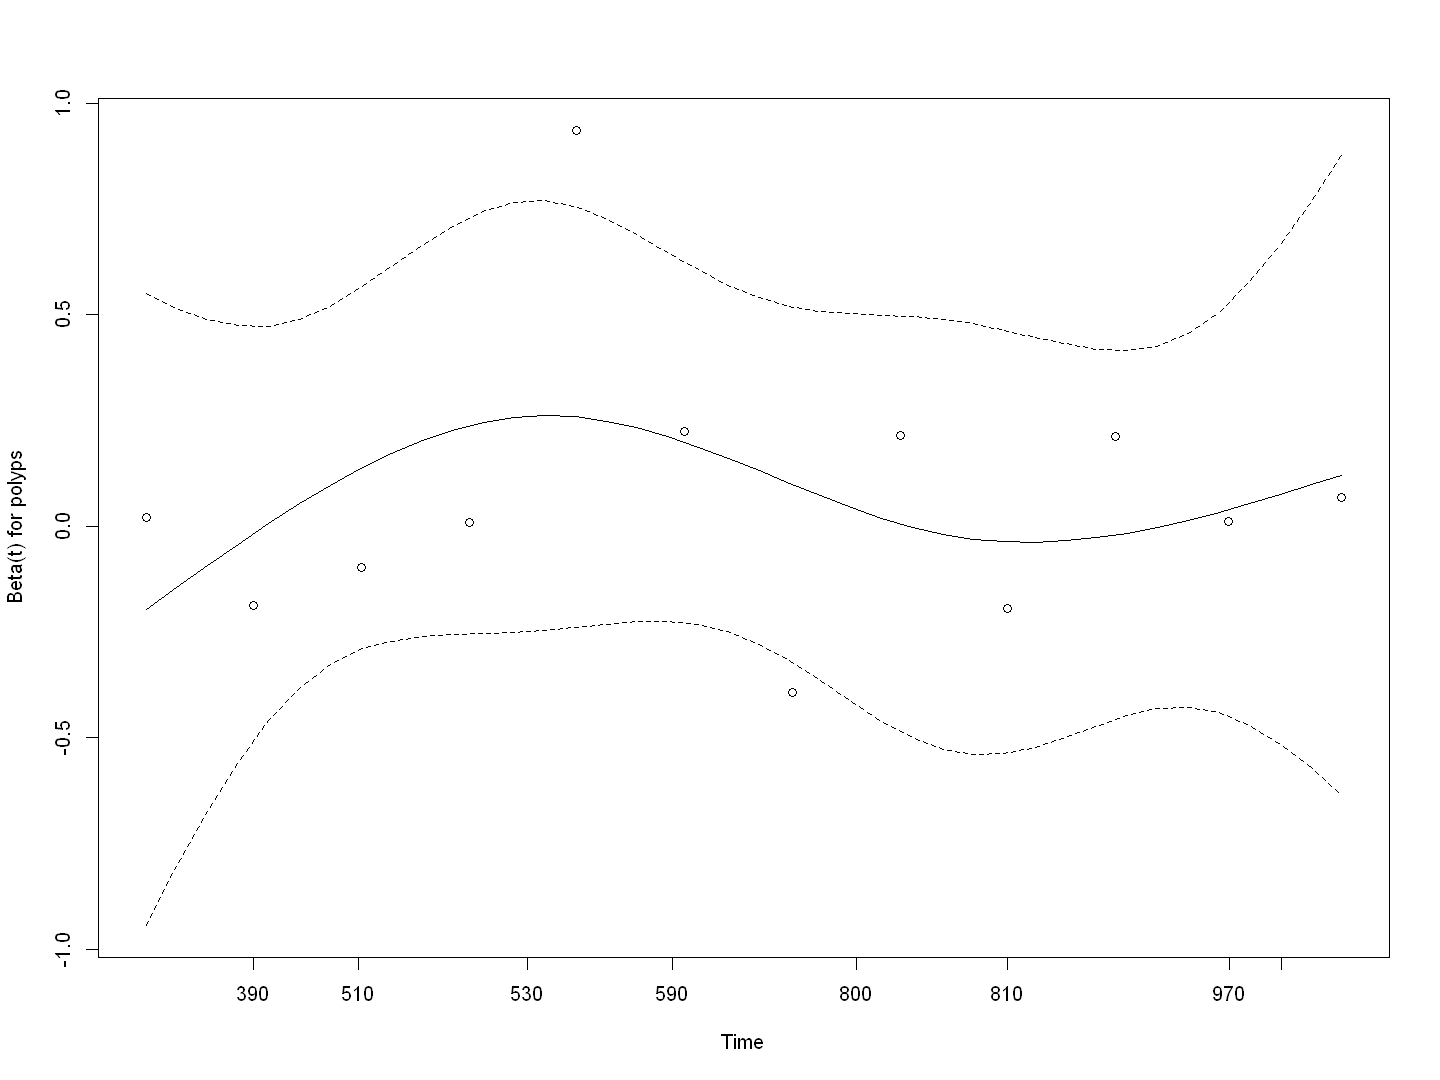

In [136]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + аллергия.домашняя пыль


#### Все группы

In [137]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + allergy_dust, data = first_reop_df)
cat("\nCox PH model summary (group + allergy_dust):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + allergy_dust):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_dust, 
    data = first_reop_df)

  n= 50, number of events= 12 

                   coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1        -1.5253    0.2175   1.0605 -1.438    0.150
groupОГ2        -1.5789    0.2062   1.0570 -1.494    0.135
allergy_dustнет -0.5172    0.5962   0.7888 -0.656    0.512

                exp(coef) exp(-coef) lower .95 upper .95
groupОГ1           0.2175      4.597   0.02722     1.739
groupОГ2           0.2062      4.850   0.02597     1.637
allergy_dustнет    0.5962      1.677   0.12704     2.798

Concordance= 0.674  (se = 0.07 )
Likelihood ratio test= 5.93  on 3 df,   p=0.1
Wald test            = 4.7  on 3 df,   p=0.2
Score (logrank) test = 5.76  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


             chisq df    p
group         1.27  2 0.53
allergy_dust  0.32  1 0.57
GLOBAL        1.47  3 0.69


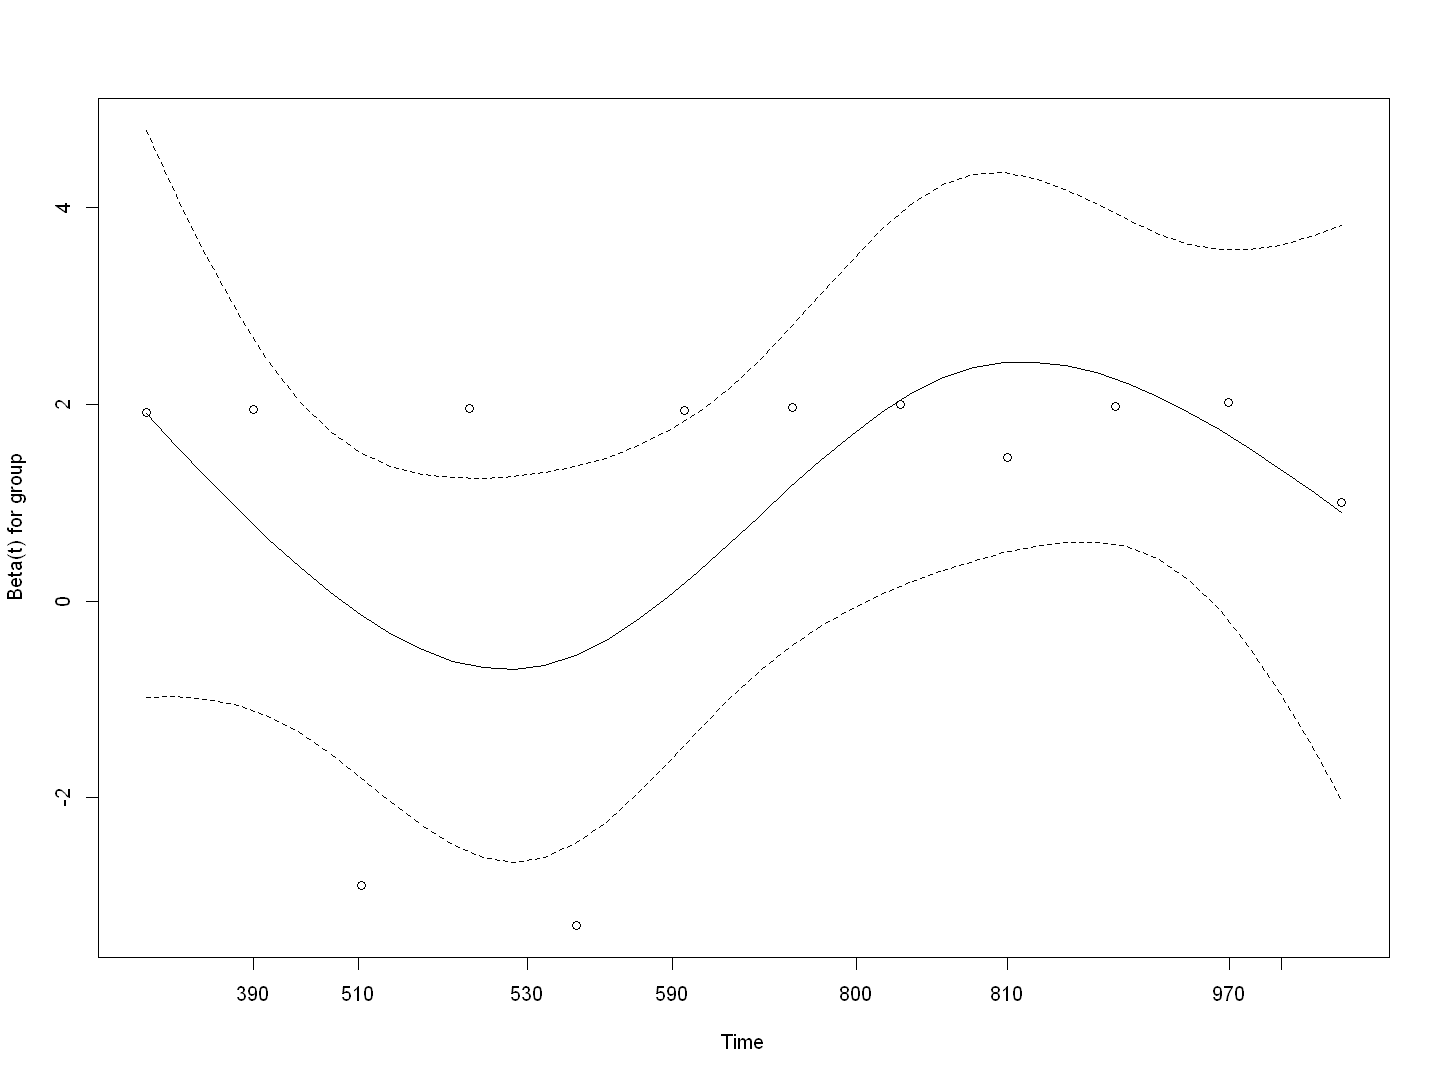

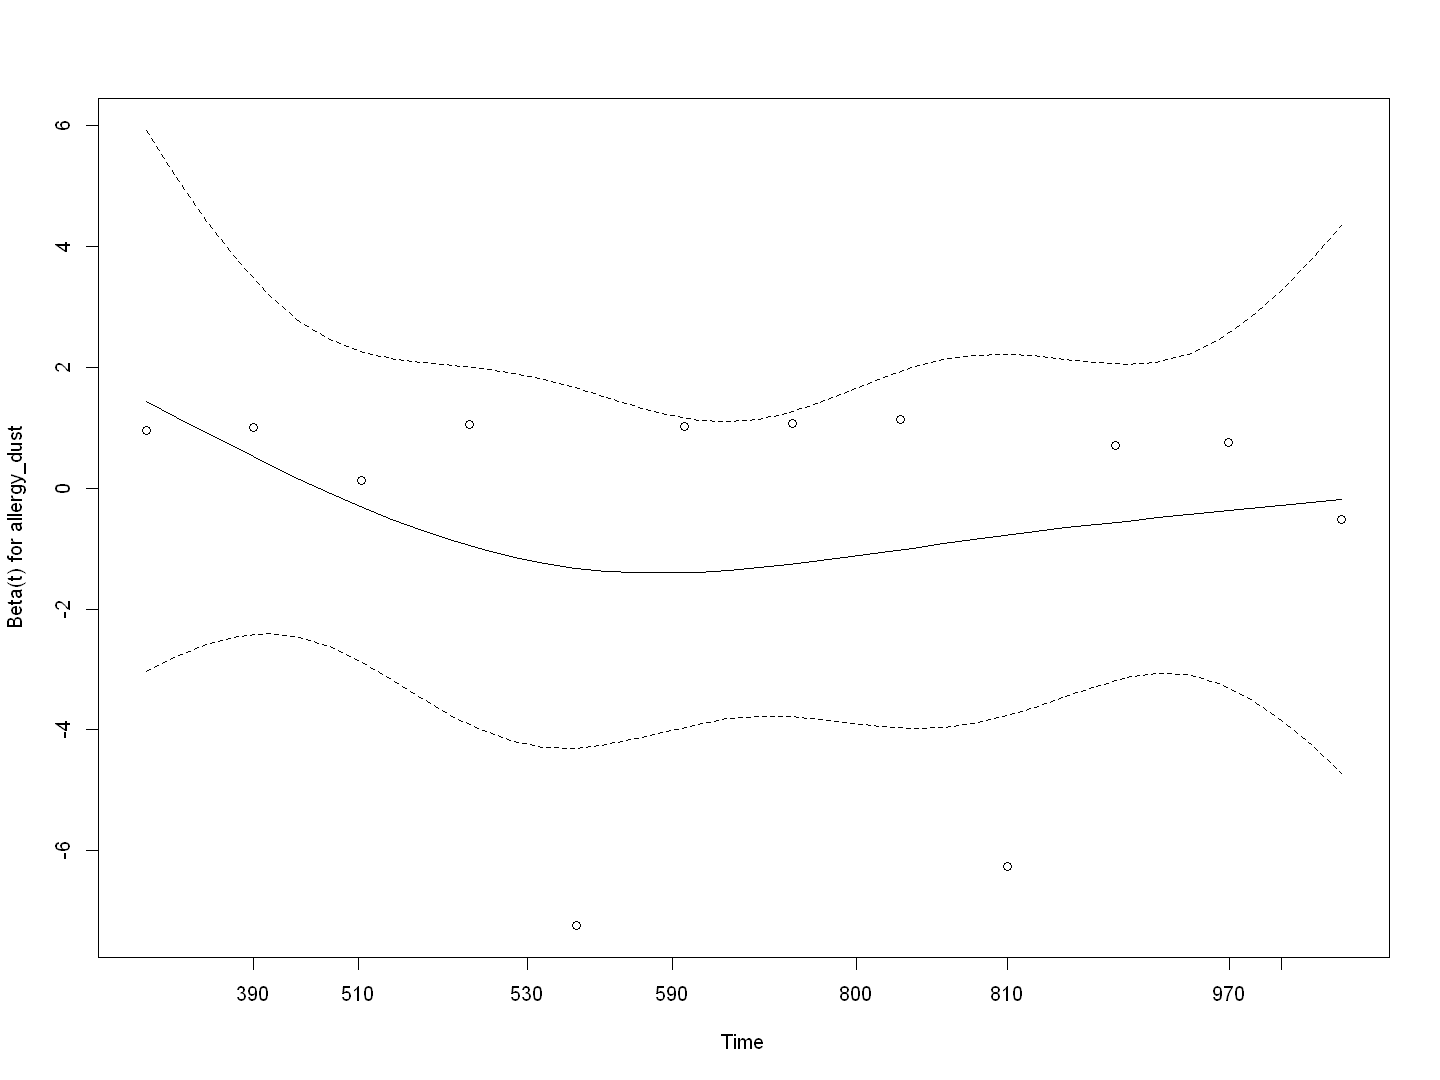

In [138]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [139]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + allergy_dust, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + allergy_dust):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + allergy_dust):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_dust, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                   coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ         -1.5526    0.2117   0.7876 -1.971   0.0487 *
allergy_dustнет -0.5165    0.5966   0.7885 -0.655   0.5125  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                exp(coef) exp(-coef) lower .95 upper .95
groupОГ            0.2117      4.724   0.04522    0.9911
allergy_dustнет    0.5966      1.676   0.12722    2.7981

Concordance= 0.684  (se = 0.063 )
Likelihood ratio test= 5.93  on 2 df,   p=0.05
Wald test            = 4.69  on 2 df,   p=0.1
Score (logrank) test = 5.75  on 2 df,   p=0.06




Test of PH assumption:


             chisq df    p
group         1.08  1 0.30
allergy_dust  0.32  1 0.57
GLOBAL        1.27  2 0.53


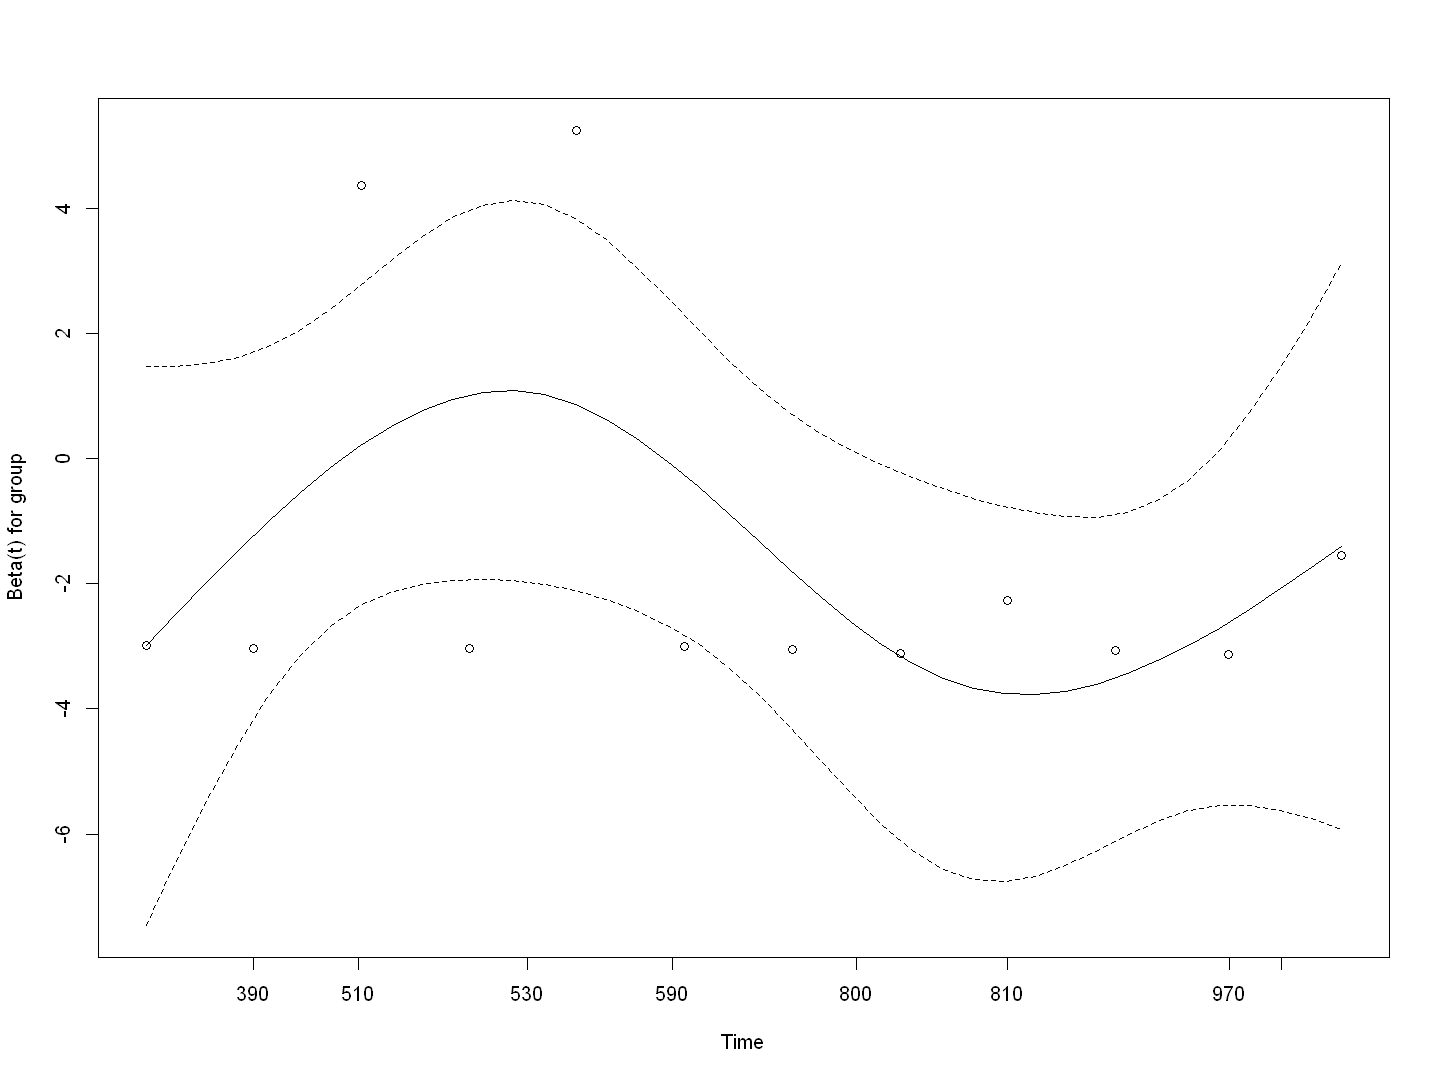

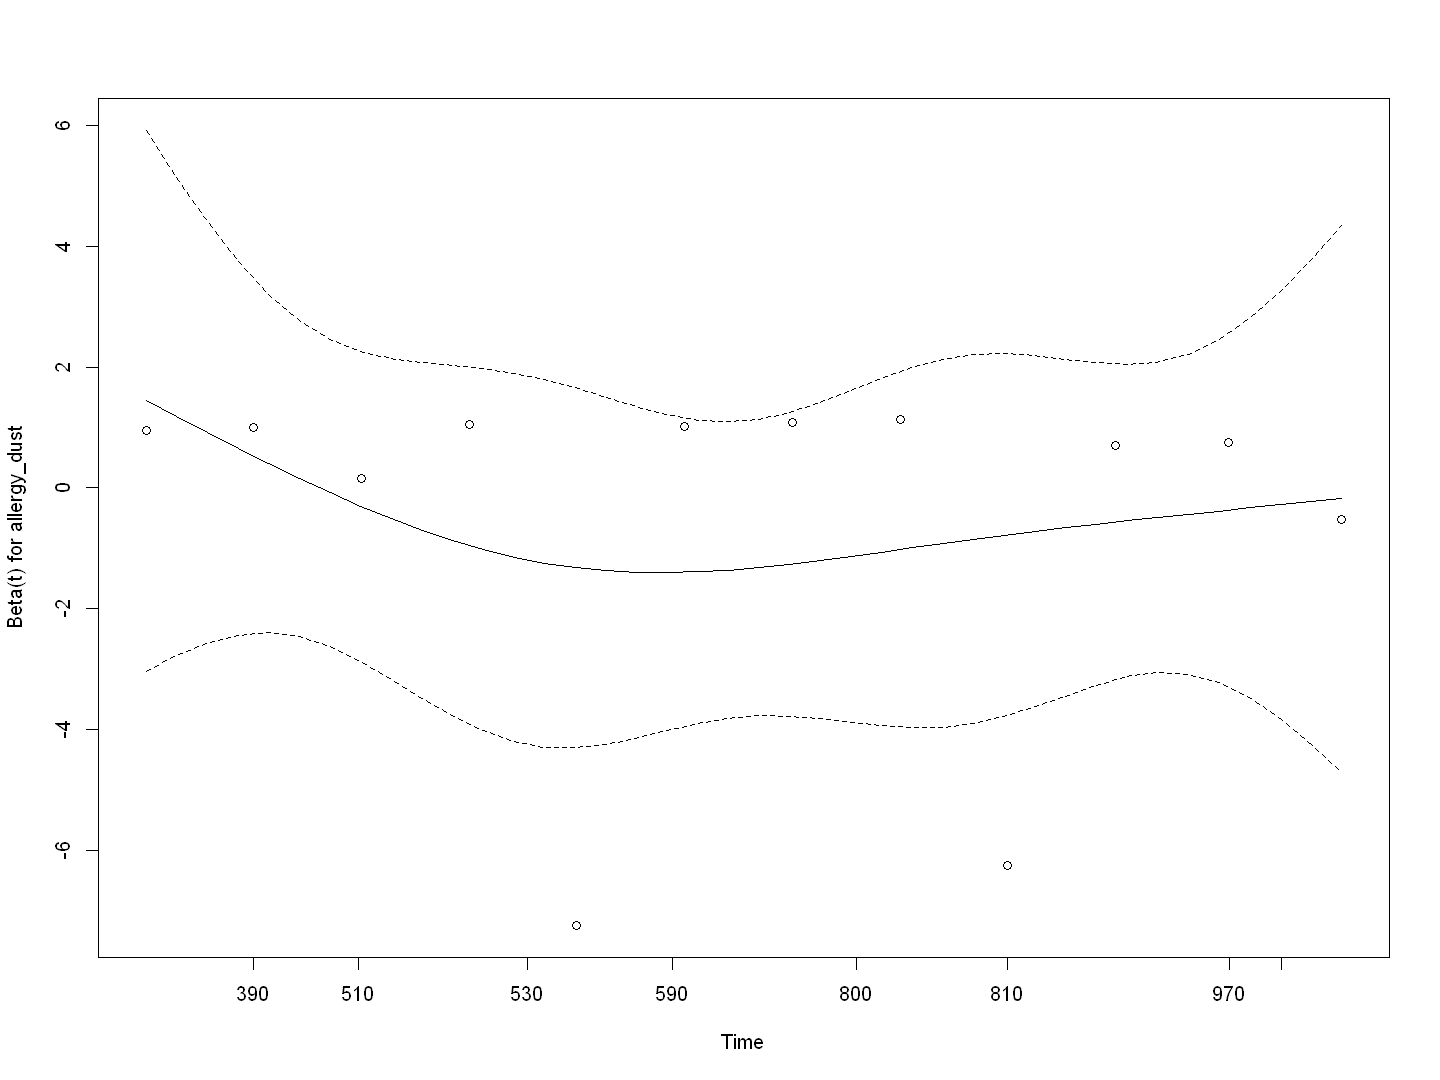

In [140]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + аллергия.растения


#### Все группы

In [141]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + allergy_plants, data = first_reop_df)
cat("\nCox PH model summary (group + allergy_plants):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + allergy_plants):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_plants, 
    data = first_reop_df)

  n= 50, number of events= 12 

                     coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1          -1.6579    0.1905   1.0673 -1.553    0.120
groupОГ2          -1.7048    0.1818   1.0718 -1.591    0.112
allergy_plantsнет -0.3159    0.7291   0.6949 -0.455    0.649

                  exp(coef) exp(-coef) lower .95 upper .95
groupОГ1             0.1905      5.248   0.02352     1.543
groupОГ2             0.1818      5.500   0.02225     1.486
allergy_plantsнет    0.7291      1.372   0.18676     2.847

Concordance= 0.685  (se = 0.06 )
Likelihood ratio test= 5.74  on 3 df,   p=0.1
Wald test            = 4.39  on 3 df,   p=0.2
Score (logrank) test = 5.36  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


               chisq df    p
group          1.289  2 0.52
allergy_plants 0.192  1 0.66
GLOBAL         1.324  3 0.72


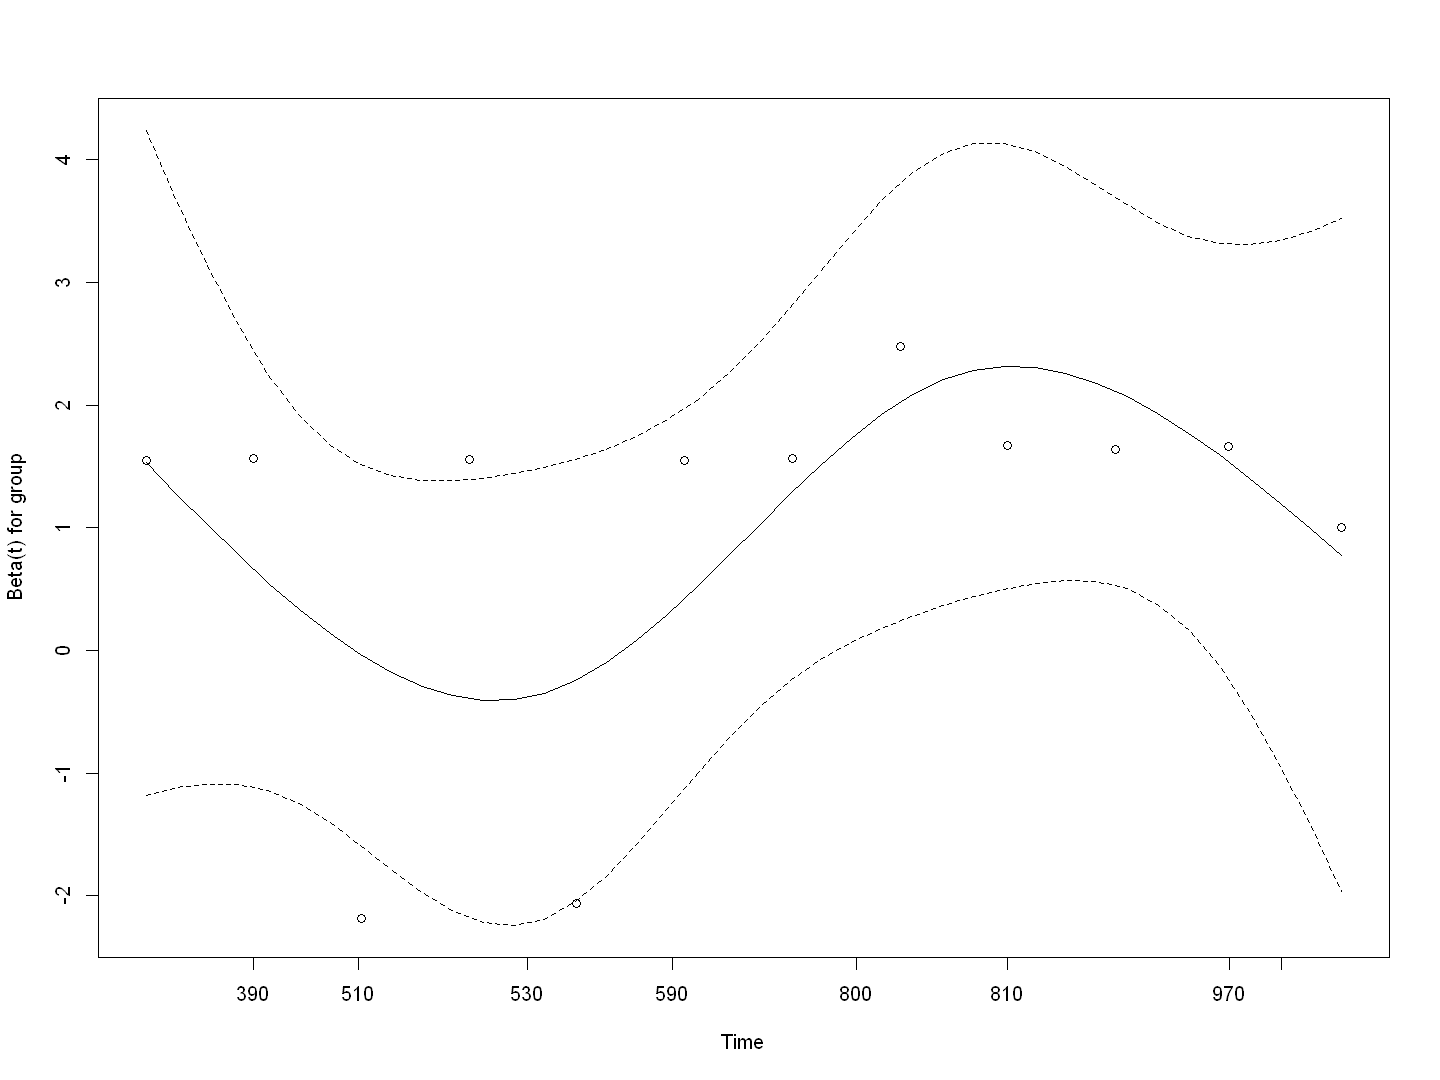

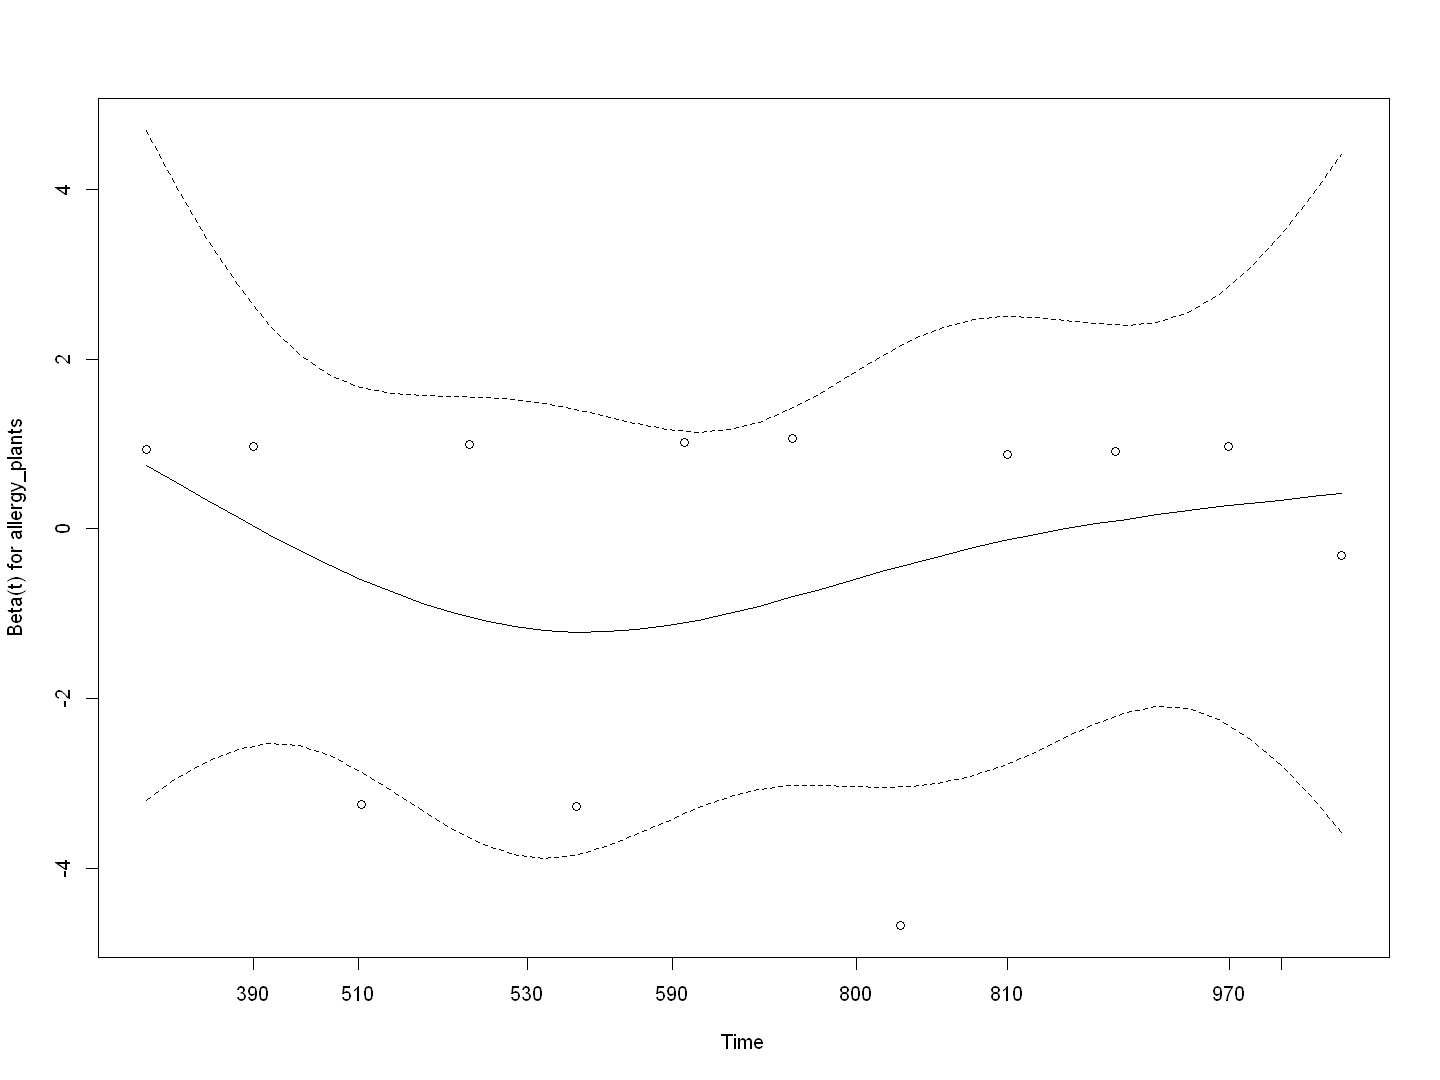

In [142]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [143]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + allergy_plants, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + allergy_plants):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + allergy_plants):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_plants, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                     coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ           -1.6815    0.1861   0.8023 -2.096   0.0361 *
allergy_plantsнет -0.3155    0.7295   0.6949 -0.454   0.6498  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                  exp(coef) exp(-coef) lower .95 upper .95
groupОГ              0.1861      5.374   0.03862    0.8968
allergy_plantsнет    0.7295      1.371   0.18687    2.8475

Concordance= 0.685  (se = 0.059 )
Likelihood ratio test= 5.74  on 2 df,   p=0.06
Wald test            = 4.39  on 2 df,   p=0.1
Score (logrank) test = 5.36  on 2 df,   p=0.07




Test of PH assumption:


               chisq df    p
group          1.104  1 0.29
allergy_plants 0.192  1 0.66
GLOBAL         1.143  2 0.56


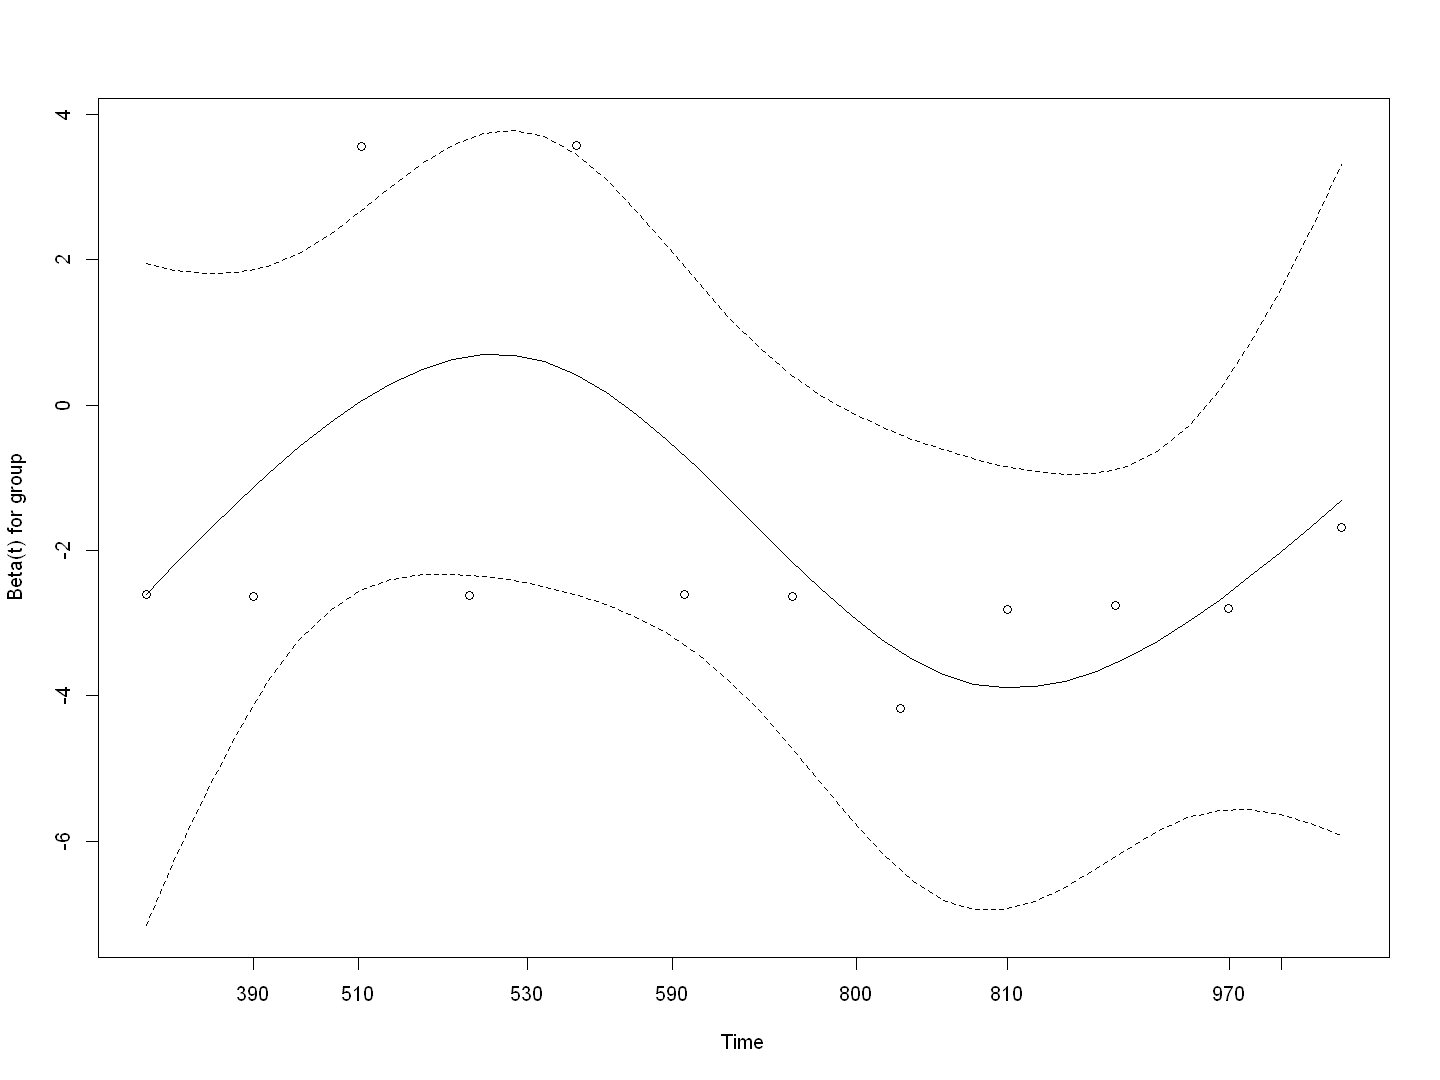

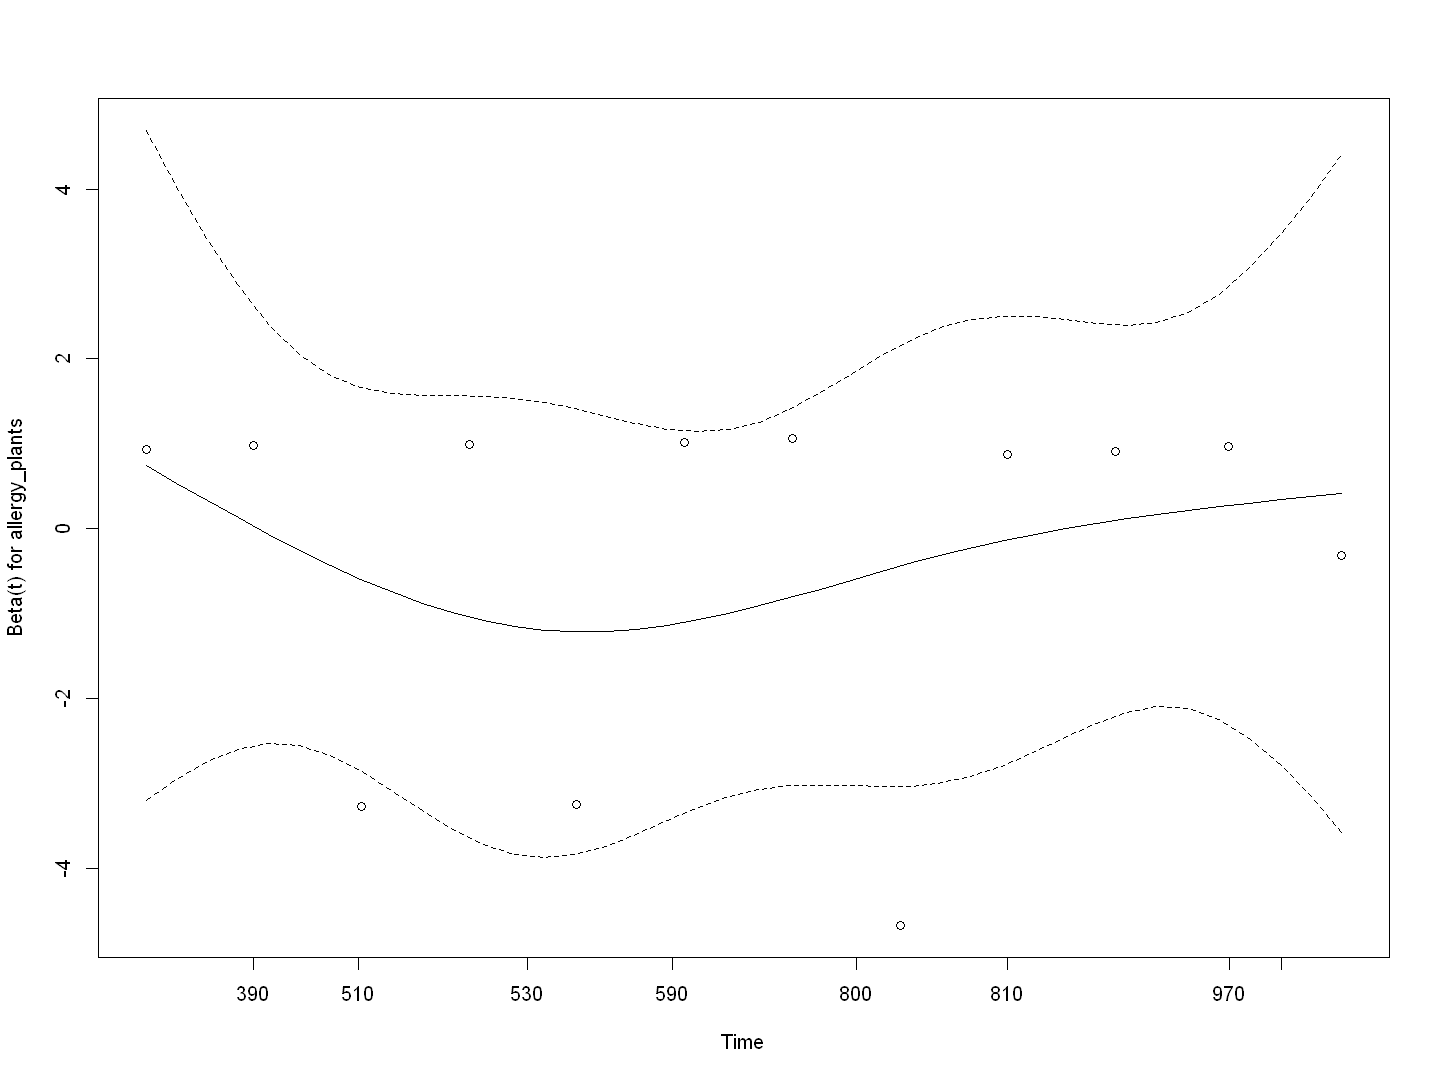

In [144]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + аллергия.животные


#### Все группы

In [145]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + allergy_animals, data = first_reop_df)
cat("\nCox PH model summary (group + allergy_animals):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + allergy_animals):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_animals, 
    data = first_reop_df)

  n= 50, number of events= 12 

                      coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1           -1.6871    0.1851   1.0838 -1.557    0.120
groupОГ2           -1.5899    0.2039   1.0575 -1.503    0.133
allergy_animalsнет -0.5102    0.6004   1.0838 -0.471    0.638

                   exp(coef) exp(-coef) lower .95 upper .95
groupОГ1              0.1851      5.404   0.02212     1.548
groupОГ2              0.2039      4.903   0.02567     1.621
allergy_animalsнет    0.6004      1.666   0.07177     5.023

Concordance= 0.689  (se = 0.058 )
Likelihood ratio test= 5.74  on 3 df,   p=0.1
Wald test            = 4.41  on 3 df,   p=0.2
Score (logrank) test = 5.37  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


                chisq df    p
group           1.291  2 0.52
allergy_animals 0.145  1 0.70
GLOBAL          1.438  3 0.70


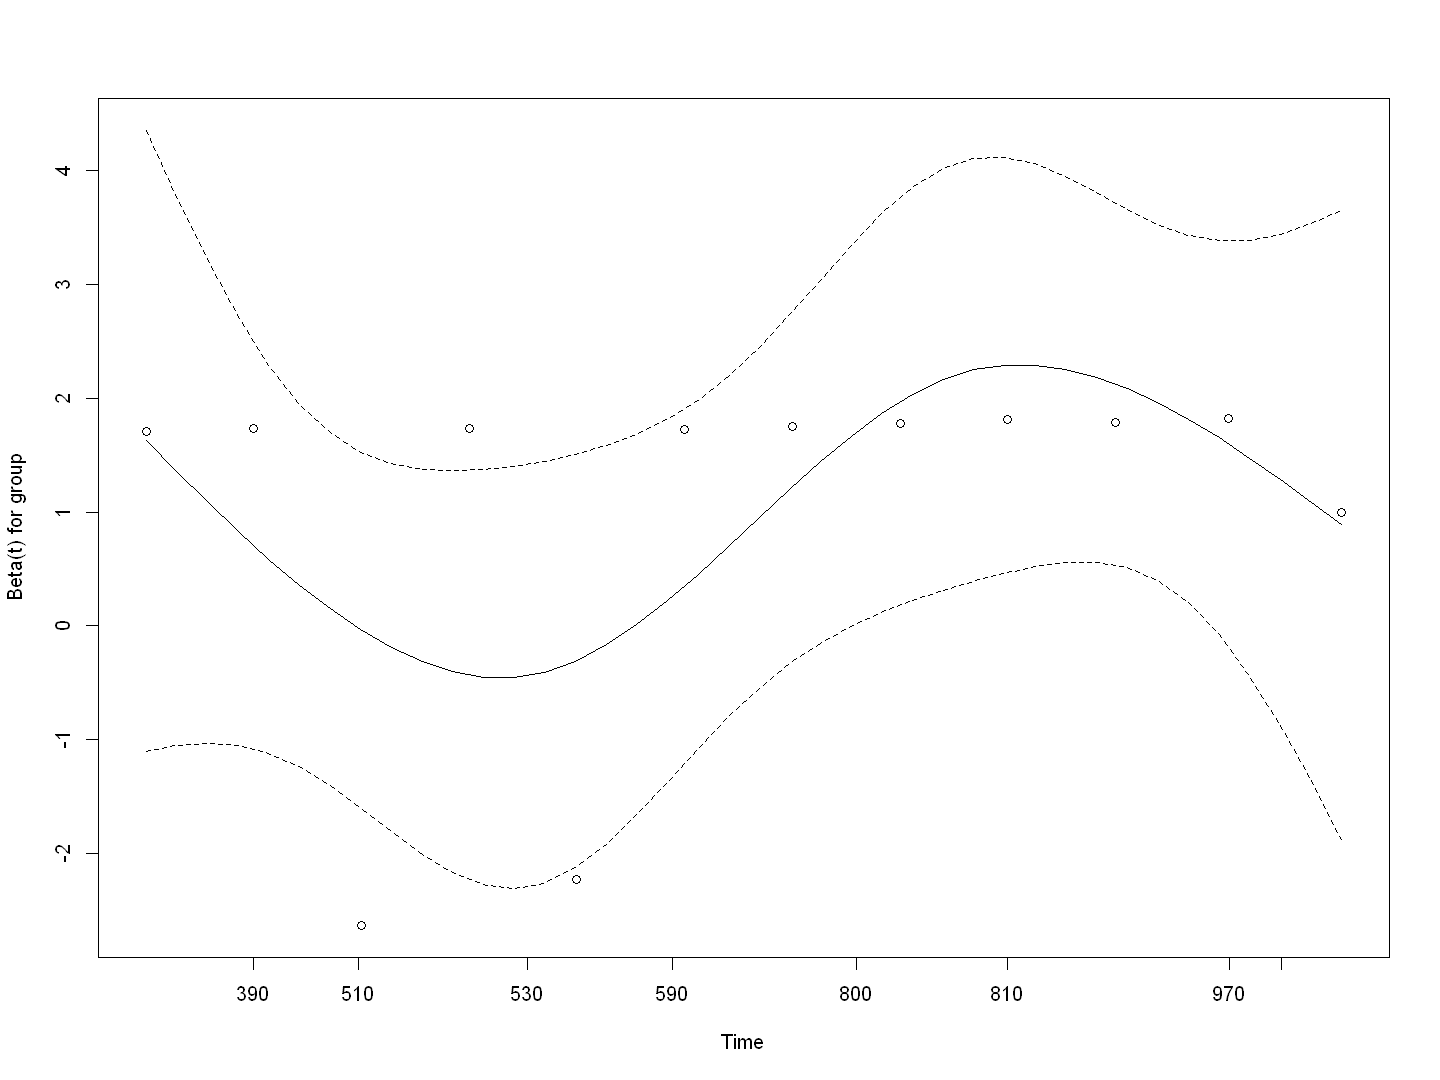

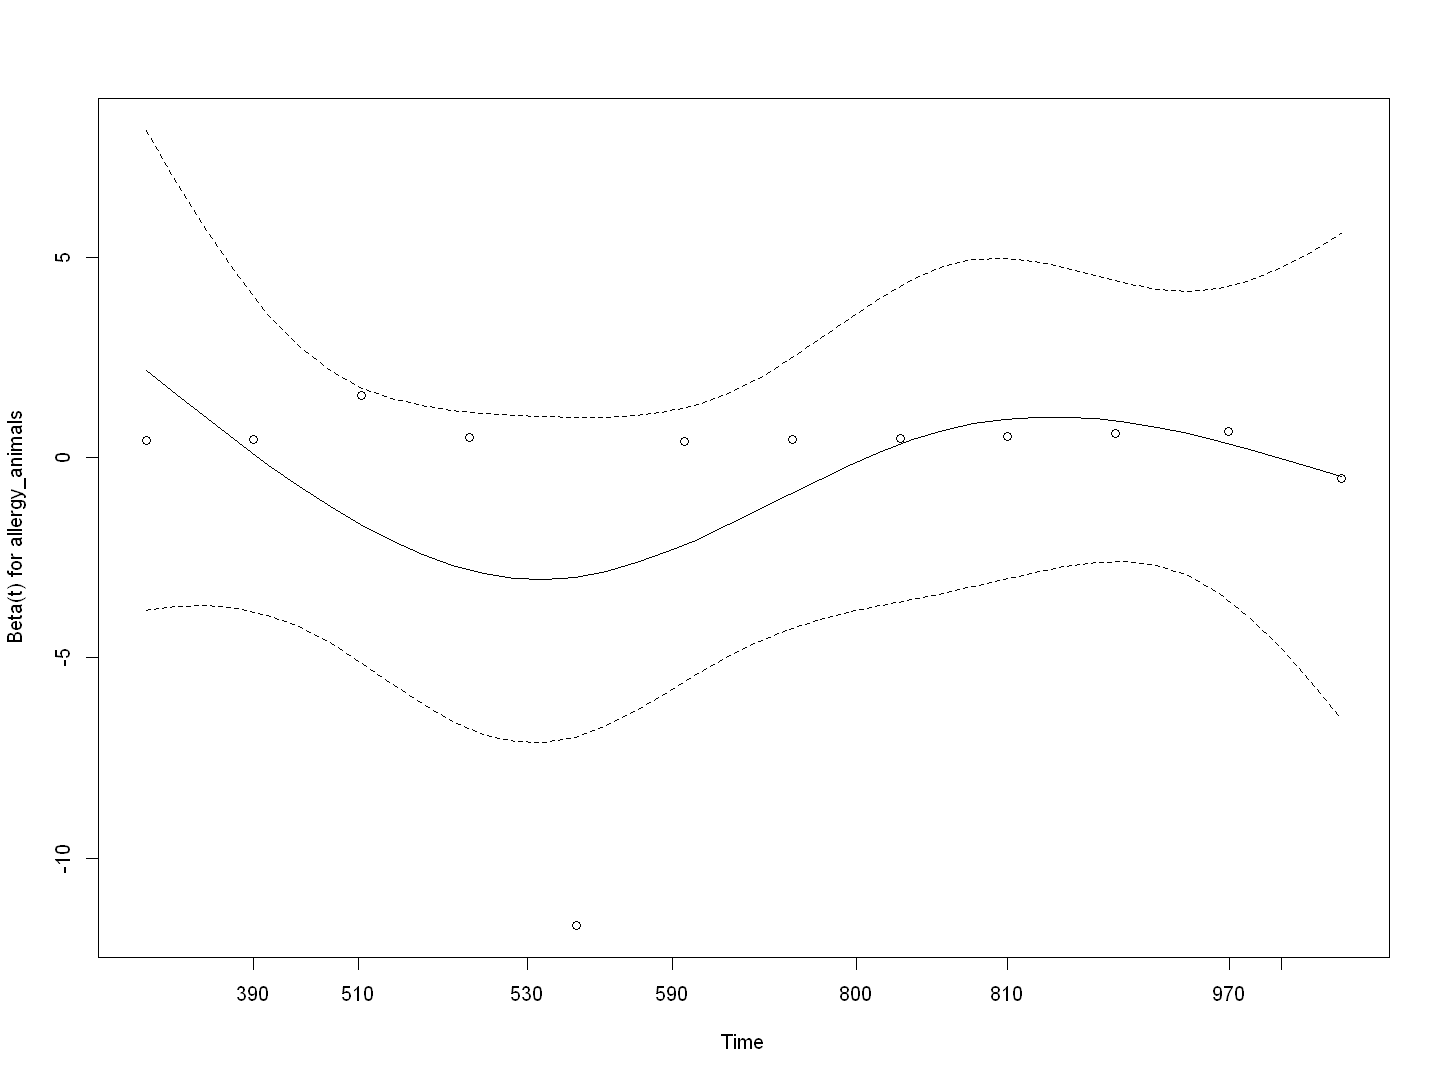

In [146]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [147]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + allergy_animals, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + allergy_animals):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + allergy_animals):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + allergy_animals, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                      coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ            -1.6382    0.1943   0.7869 -2.082   0.0374 *
allergy_animalsнет -0.4936    0.6104   1.0557 -0.468   0.6401  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                   exp(coef) exp(-coef) lower .95 upper .95
groupОГ               0.1943      5.146   0.04156    0.9085
allergy_animalsнет    0.6104      1.638   0.07709    4.8335

Concordance= 0.679  (se = 0.063 )
Likelihood ratio test= 5.73  on 2 df,   p=0.06
Wald test            = 4.39  on 2 df,   p=0.1
Score (logrank) test = 5.36  on 2 df,   p=0.07




Test of PH assumption:


                chisq df    p
group           1.099  1 0.29
allergy_animals 0.144  1 0.70
GLOBAL          1.166  2 0.56


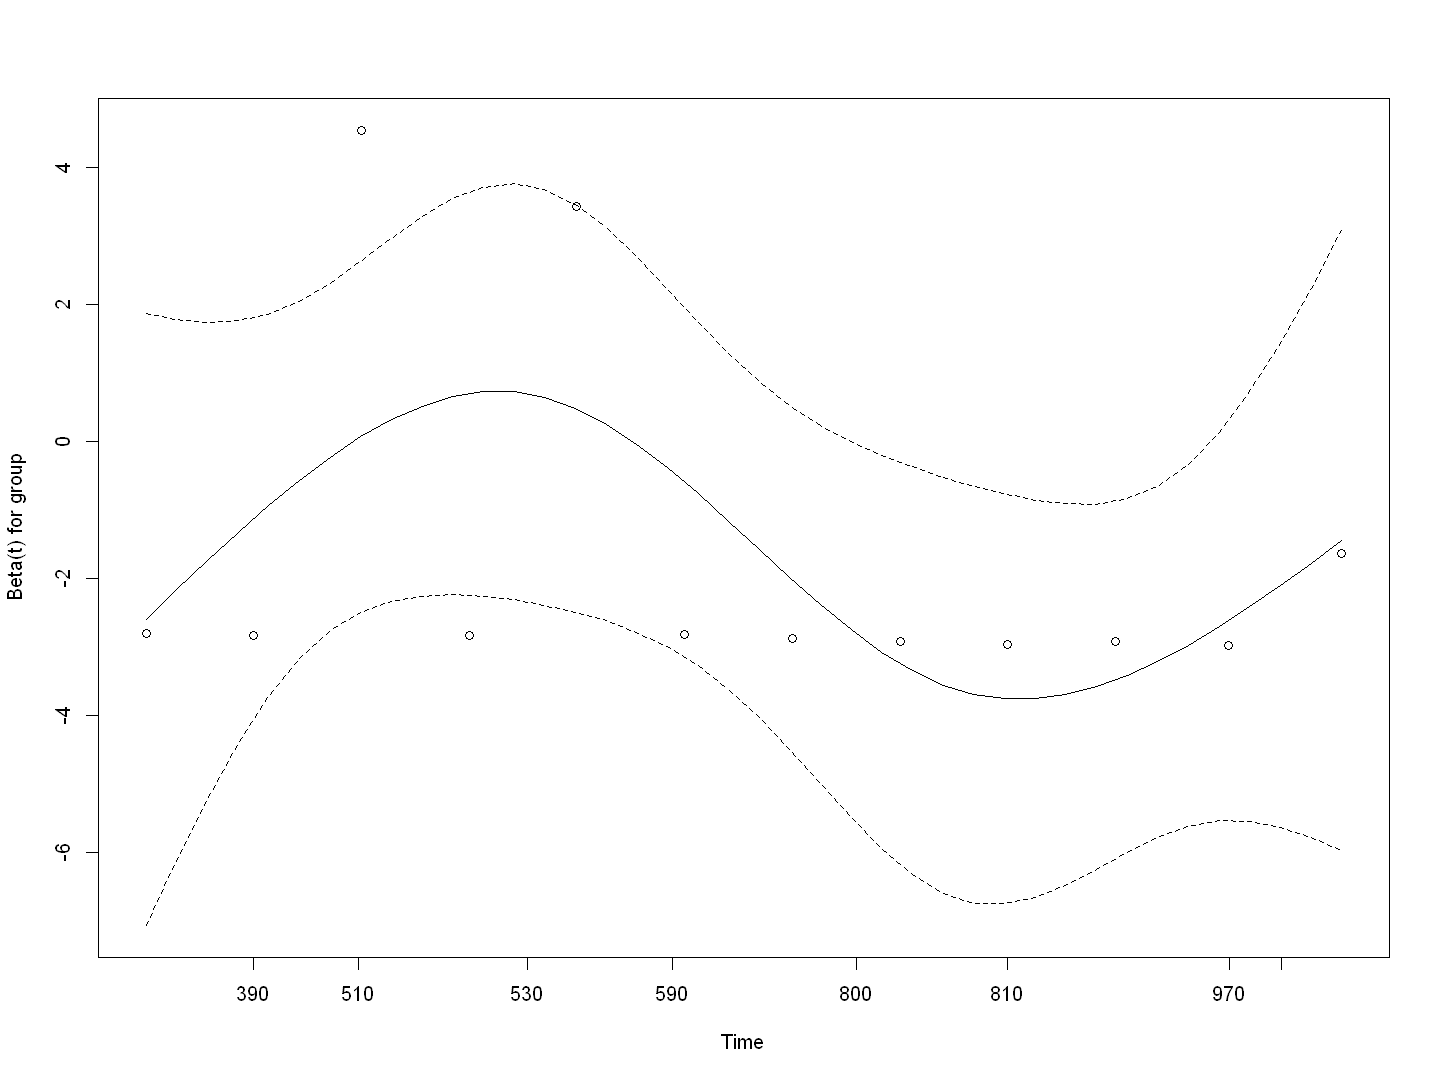

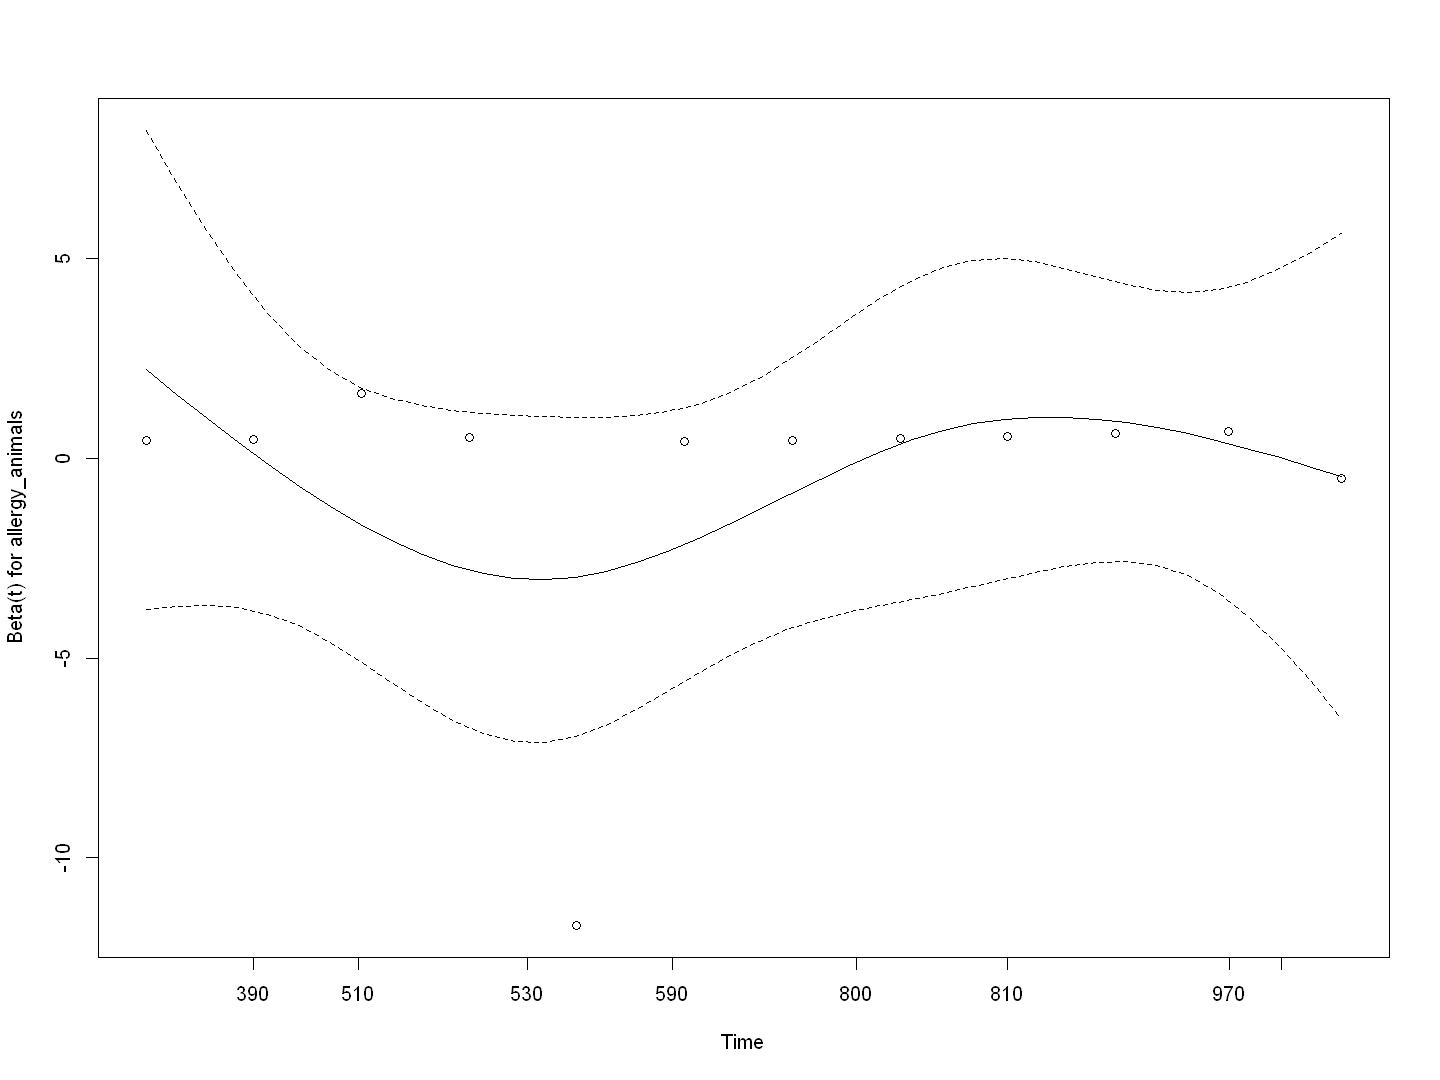

In [148]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + хронический ринит


#### Все группы

In [149]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + chronic_rhinitis, data = first_reop_df)
cat("\nCox PH model summary (group + chronic_rhinitis):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + chronic_rhinitis):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + chronic_rhinitis, 
    data = first_reop_df)

  n= 50, number of events= 12 

                       coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1            -1.5306    0.2164   1.0560 -1.450    0.147
groupОГ2            -1.6327    0.1954   1.0543 -1.549    0.121
chronic_rhinitisнет  0.7726    2.1653   1.0507  0.735    0.462

                    exp(coef) exp(-coef) lower .95 upper .95
groupОГ1               0.2164     4.6212   0.02732     1.714
groupОГ2               0.1954     5.1177   0.02475     1.543
chronic_rhinitisнет    2.1653     0.4618   0.27617    16.977

Concordance= 0.693  (se = 0.068 )
Likelihood ratio test= 6.21  on 3 df,   p=0.1
Wald test            = 4.72  on 3 df,   p=0.2
Score (logrank) test = 5.73  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


                 chisq df    p
group             1.32  2 0.52
chronic_rhinitis  0.11  1 0.74
GLOBAL            1.43  3 0.70


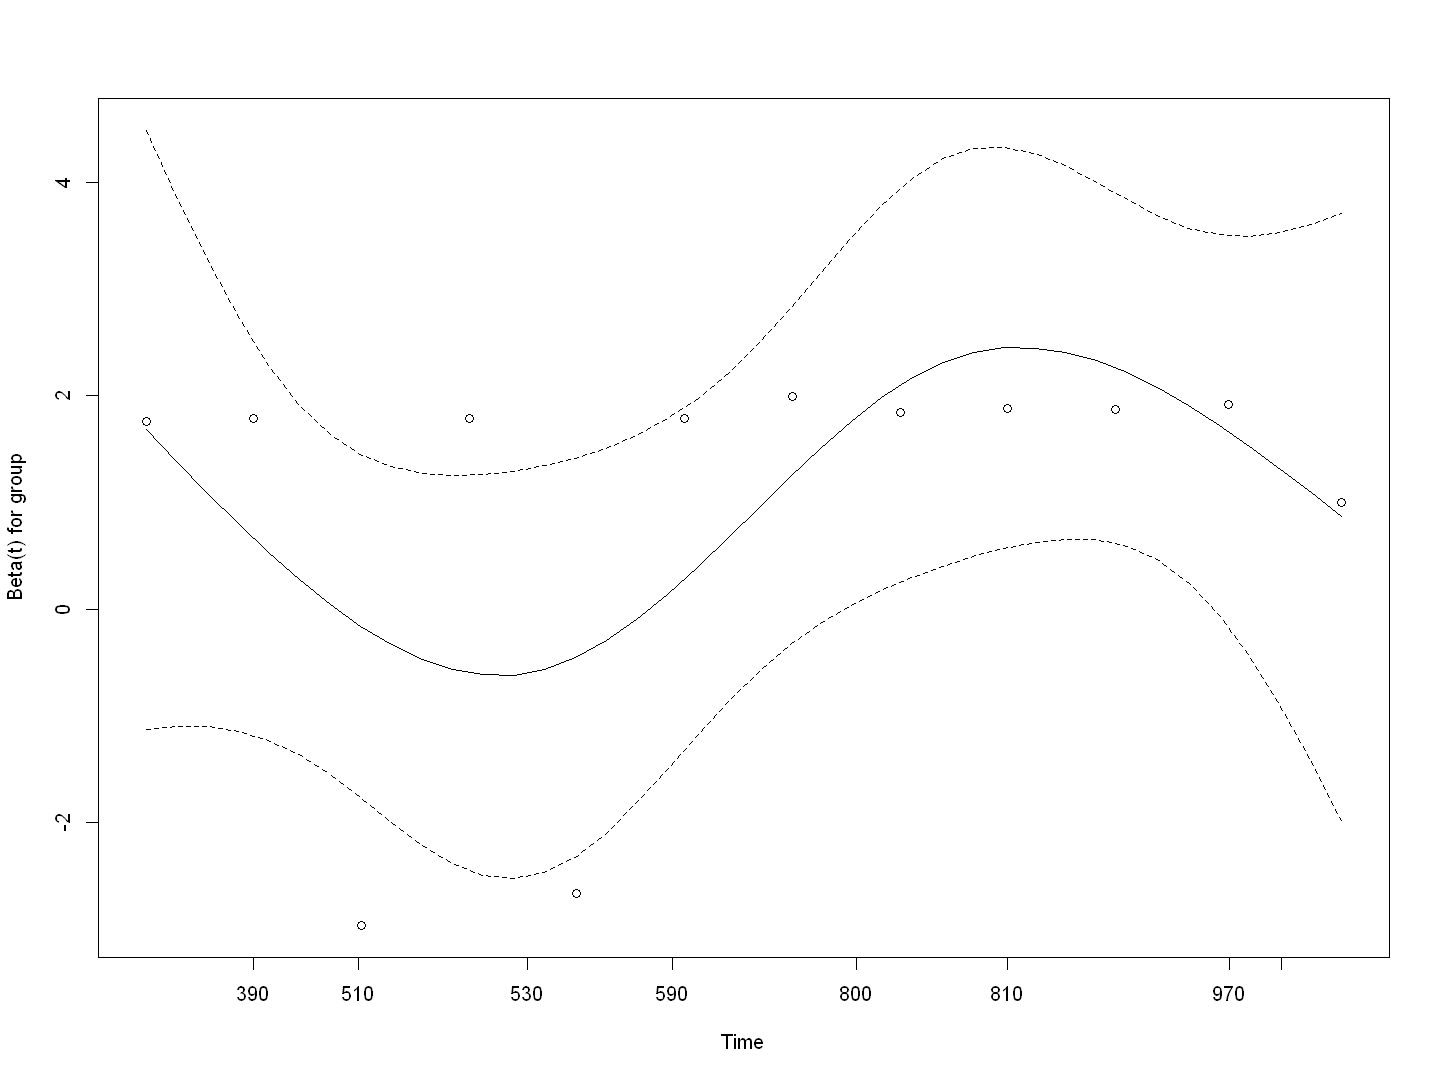

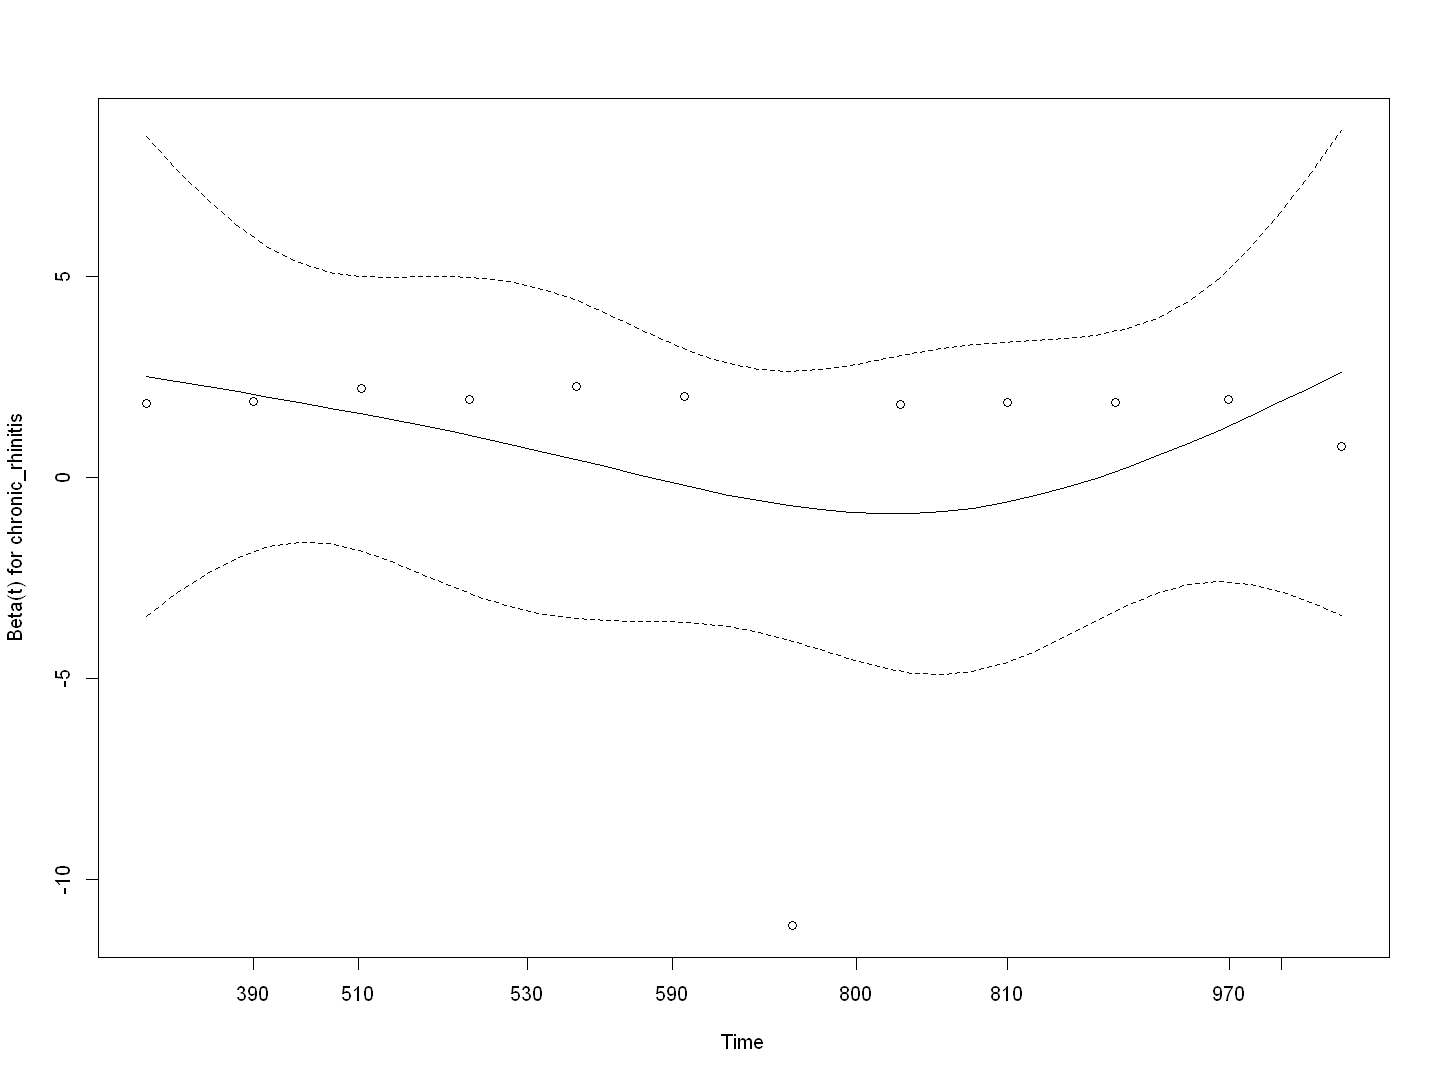

In [150]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [151]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + chronic_rhinitis, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + chronic_rhinitis):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + chronic_rhinitis):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + chronic_rhinitis, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                       coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ             -1.5831    0.2053   0.7823 -2.024    0.043 *
chronic_rhinitisнет  0.7689    2.1574   1.0494  0.733    0.464  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                    exp(coef) exp(-coef) lower .95 upper .95
groupОГ                0.2053     4.8698   0.04432    0.9514
chronic_rhinitisнет    2.1574     0.4635   0.27586   16.8714

Concordance= 0.692  (se = 0.066 )
Likelihood ratio test= 6.2  on 2 df,   p=0.04
Wald test            = 4.72  on 2 df,   p=0.09
Score (logrank) test = 5.72  on 2 df,   p=0.06




Test of PH assumption:


                 chisq df    p
group             1.13  1 0.29
chronic_rhinitis  0.11  1 0.74
GLOBAL            1.25  2 0.53


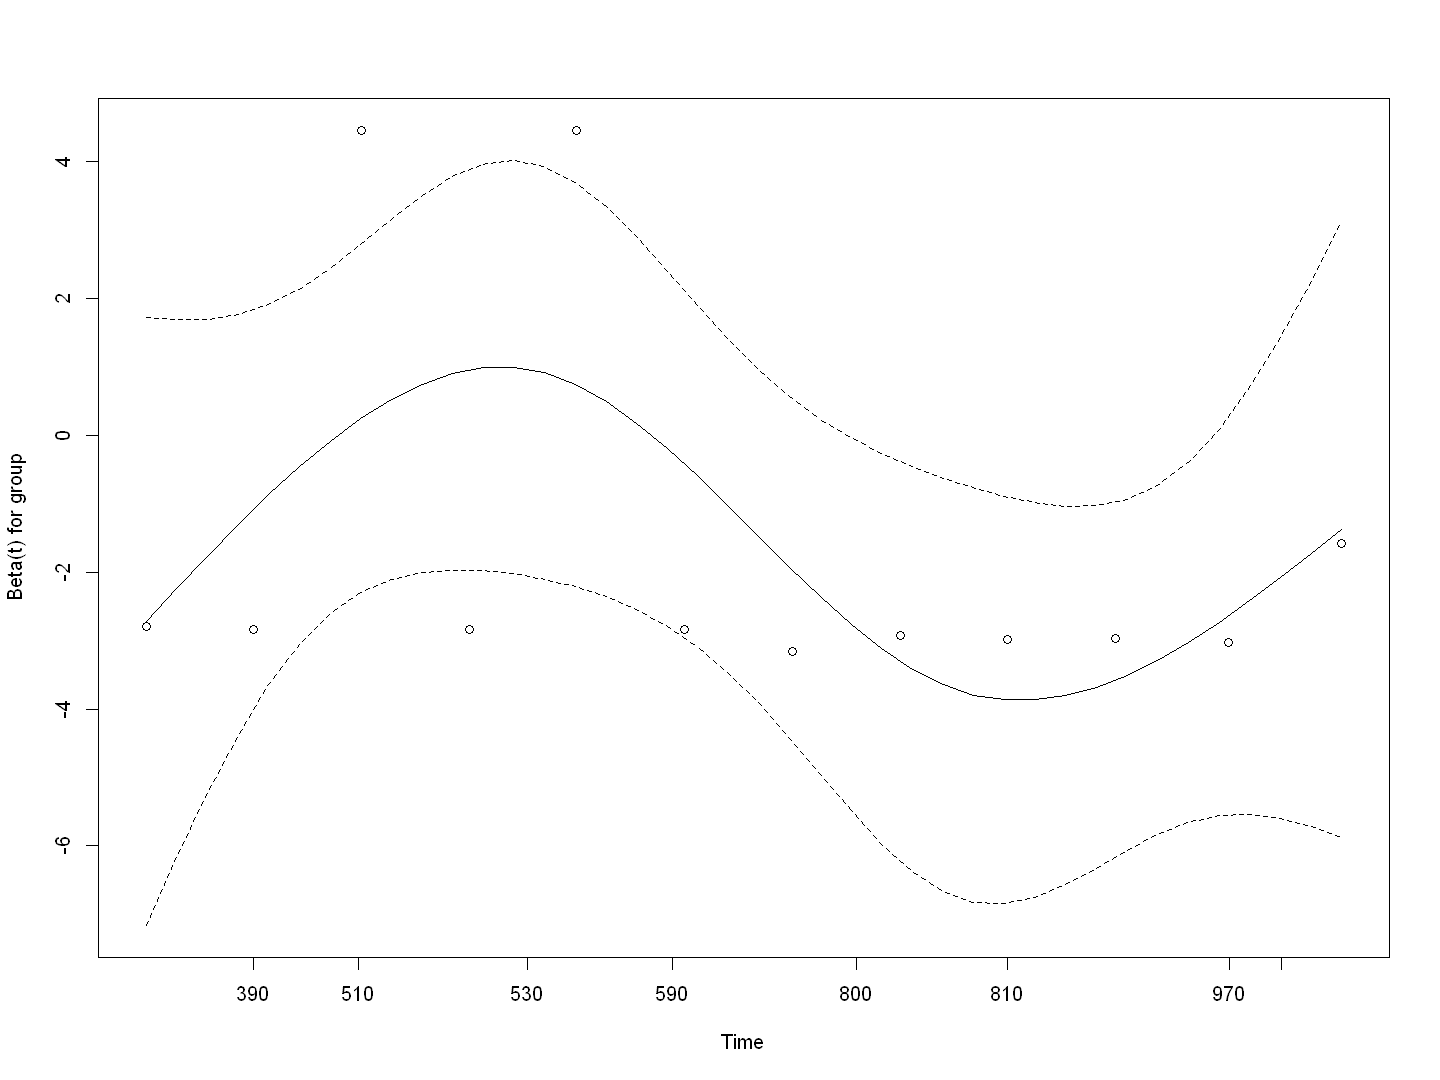

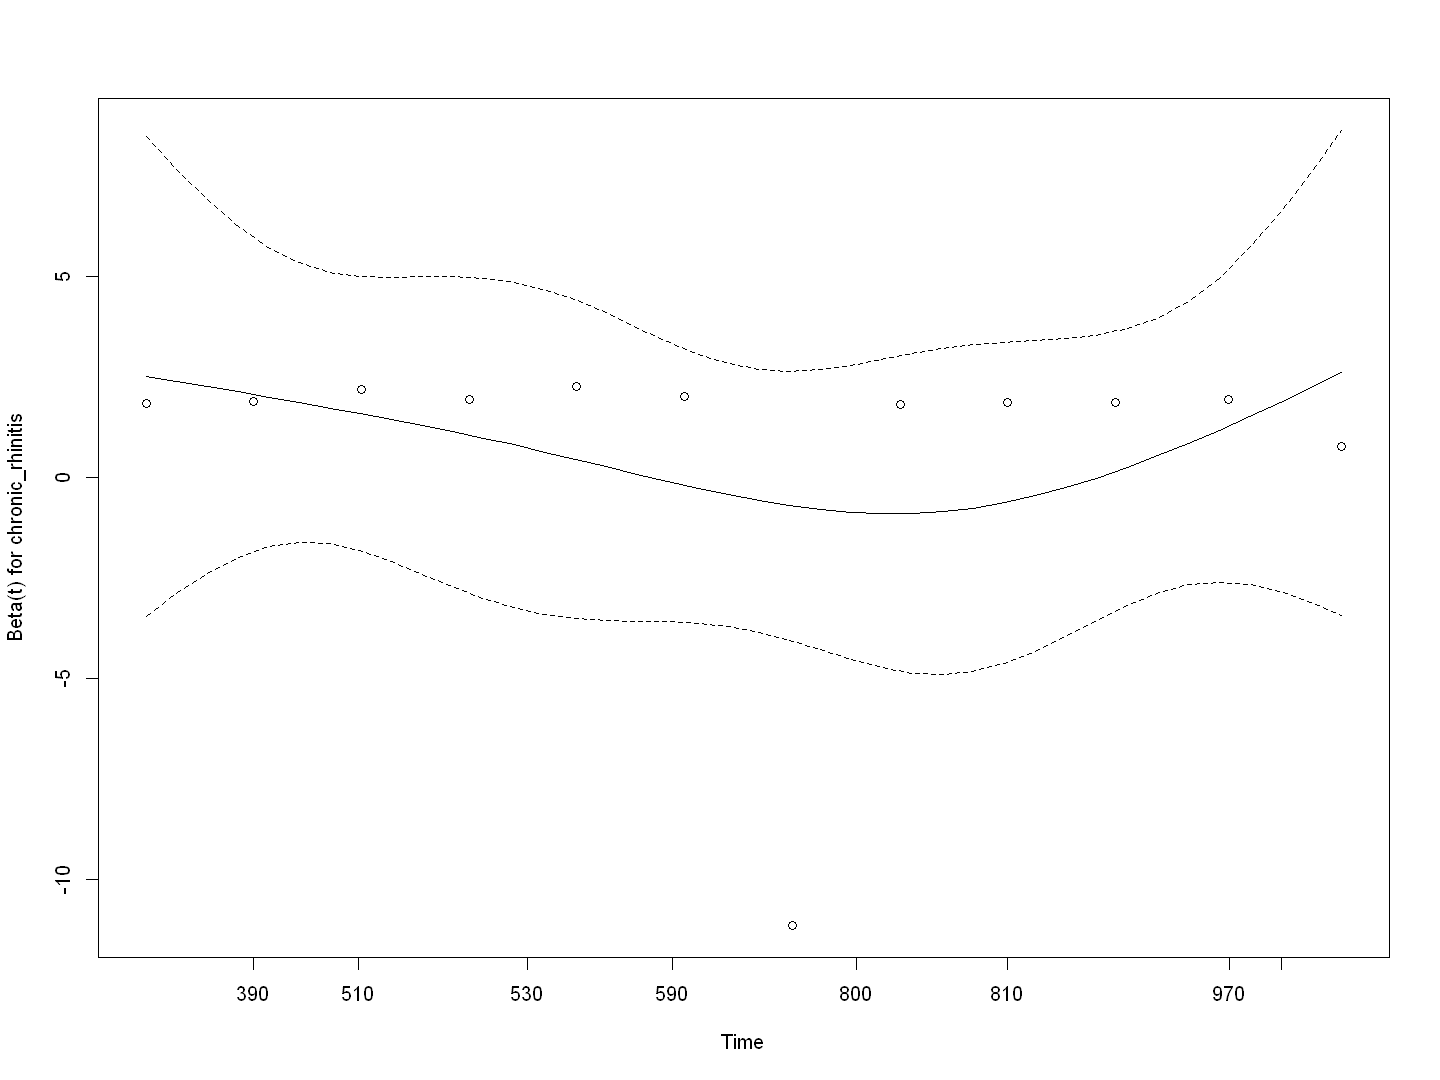

In [152]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + АР


#### Все группы

In [153]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + AR, data = first_reop_df)
cat("\nCox PH model summary (group + AR):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + AR):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + AR, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1 -1.6348    0.1950   1.0582 -1.545    0.122
groupОГ2 -1.6830    0.1858   1.0603 -1.587    0.112
ARнет    -0.3575    0.6994   0.6327 -0.565    0.572

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.1950      5.128   0.02451     1.551
groupОГ2    0.1858      5.382   0.02326     1.485
ARнет       0.6994      1.430   0.20240     2.417

Concordance= 0.689  (se = 0.06 )
Likelihood ratio test= 5.85  on 3 df,   p=0.1
Wald test            = 4.52  on 3 df,   p=0.2
Score (logrank) test = 5.49  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


        chisq df    p
group  1.2873  2 0.53
AR     0.0495  1 0.82
GLOBAL 1.4391  3 0.70


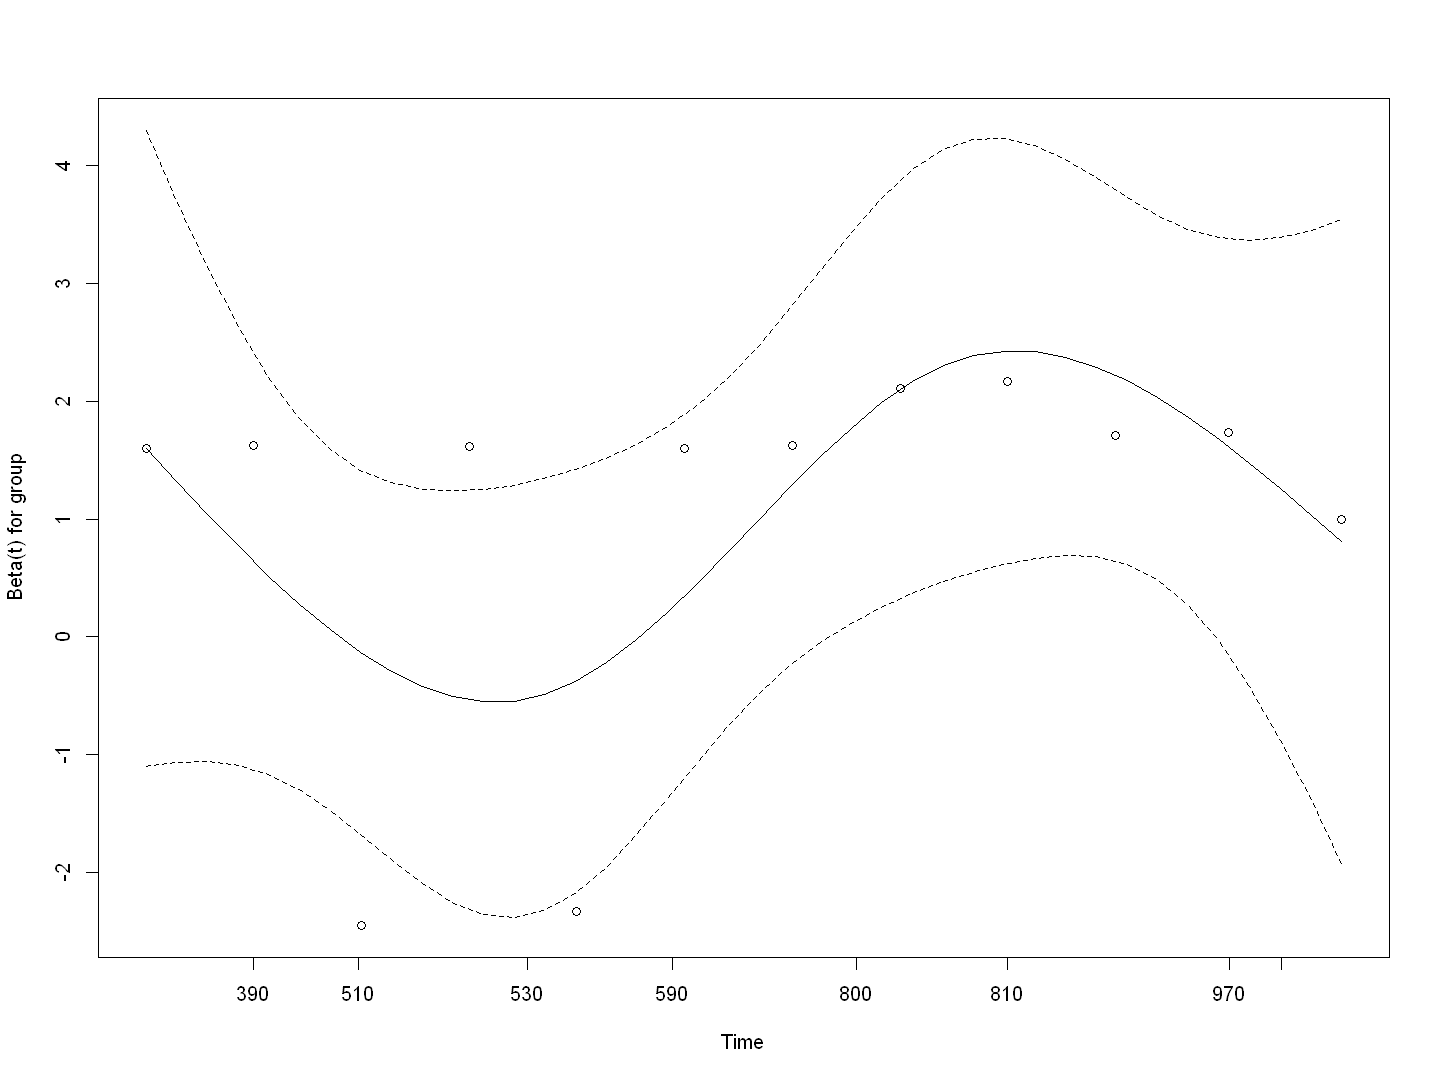

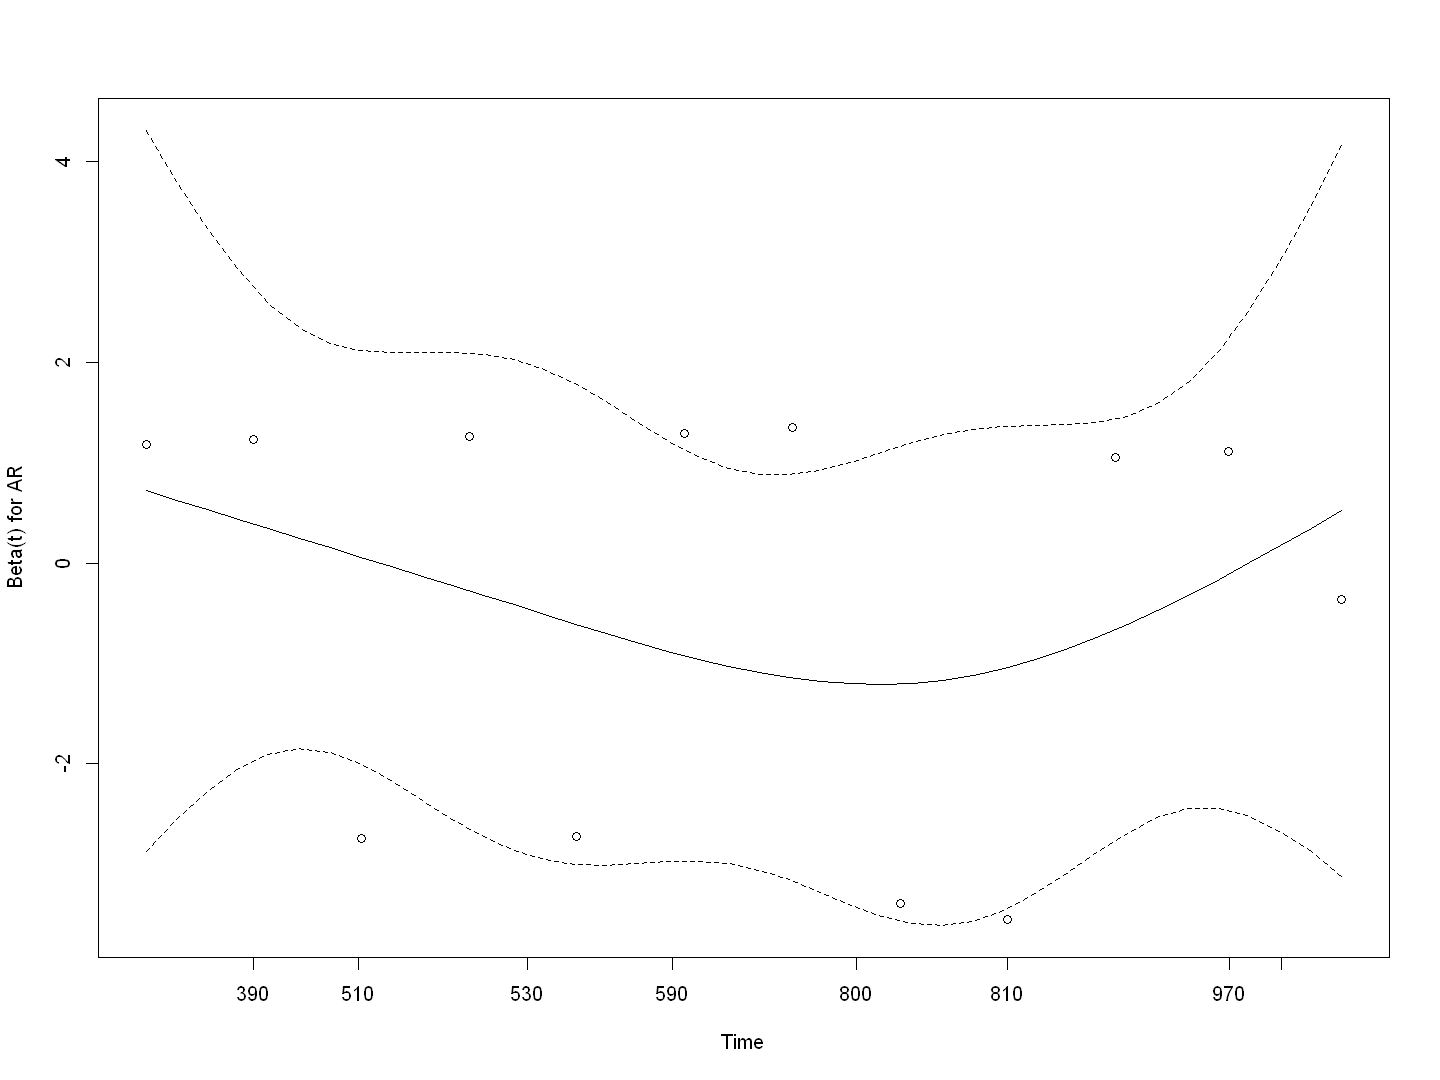

In [154]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [155]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + AR, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + AR):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + AR):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + AR, data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.6591    0.1903   0.7885 -2.104   0.0354 *
ARнет   -0.3572    0.6997   0.6326 -0.565   0.5724  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.1903      5.255   0.04058    0.8926
ARнет      0.6997      1.429   0.20250    2.4174

Concordance= 0.689  (se = 0.059 )
Likelihood ratio test= 5.85  on 2 df,   p=0.05
Wald test            = 4.51  on 2 df,   p=0.1
Score (logrank) test = 5.49  on 2 df,   p=0.06




Test of PH assumption:


        chisq df    p
group  1.1031  1 0.29
AR     0.0495  1 0.82
GLOBAL 1.2488  2 0.54


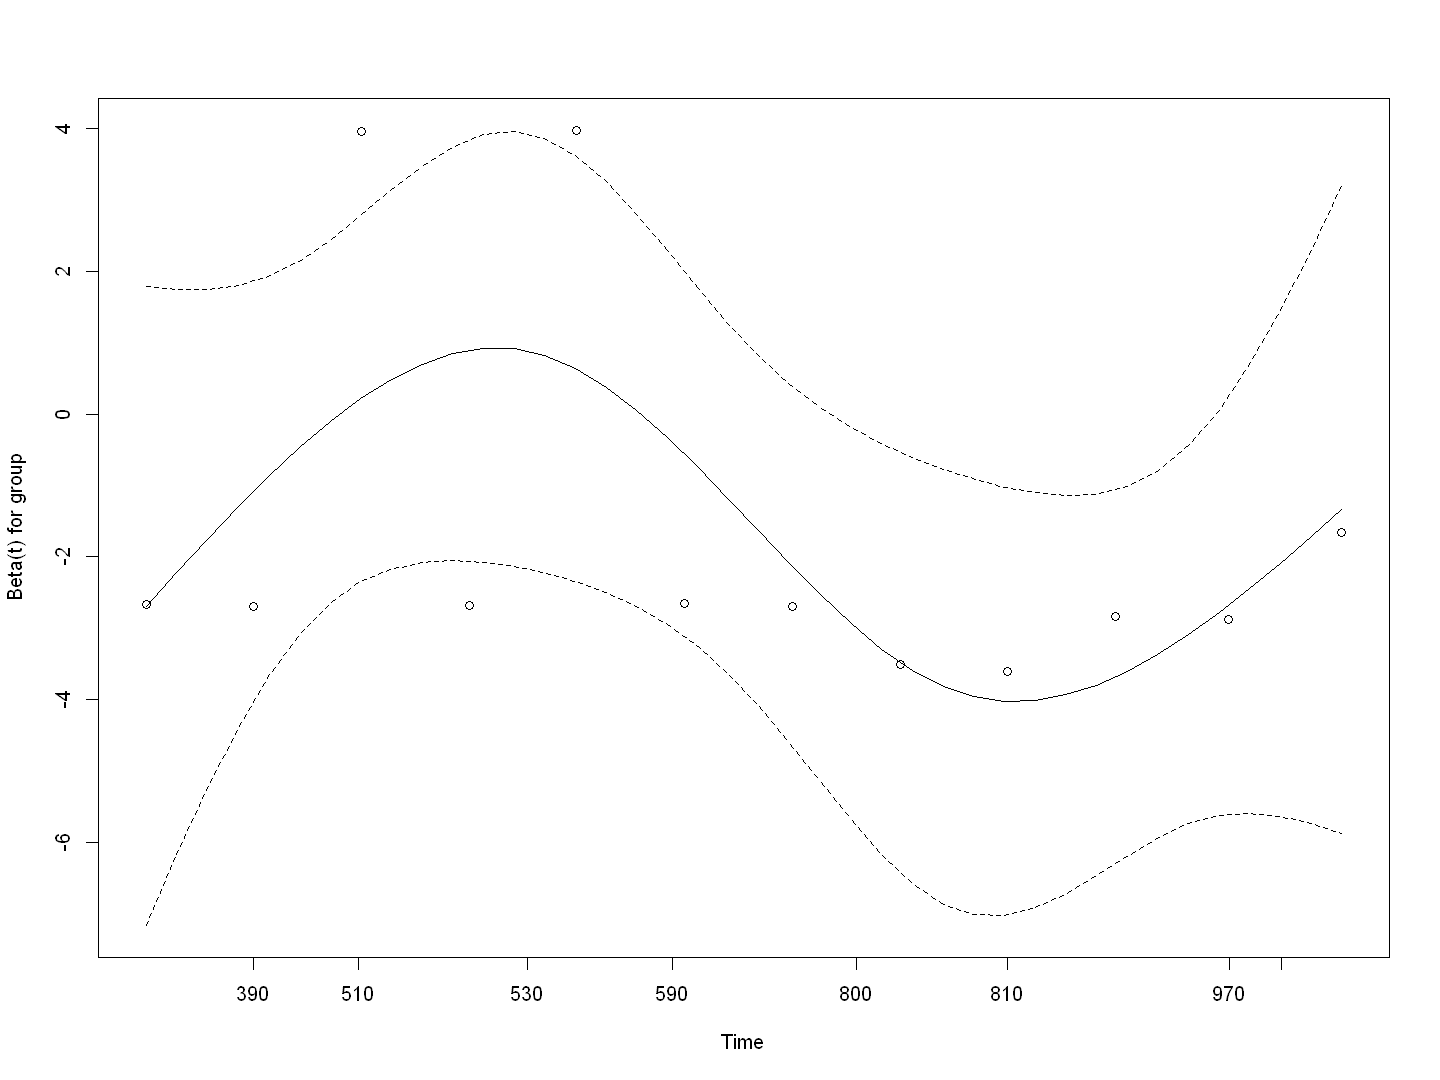

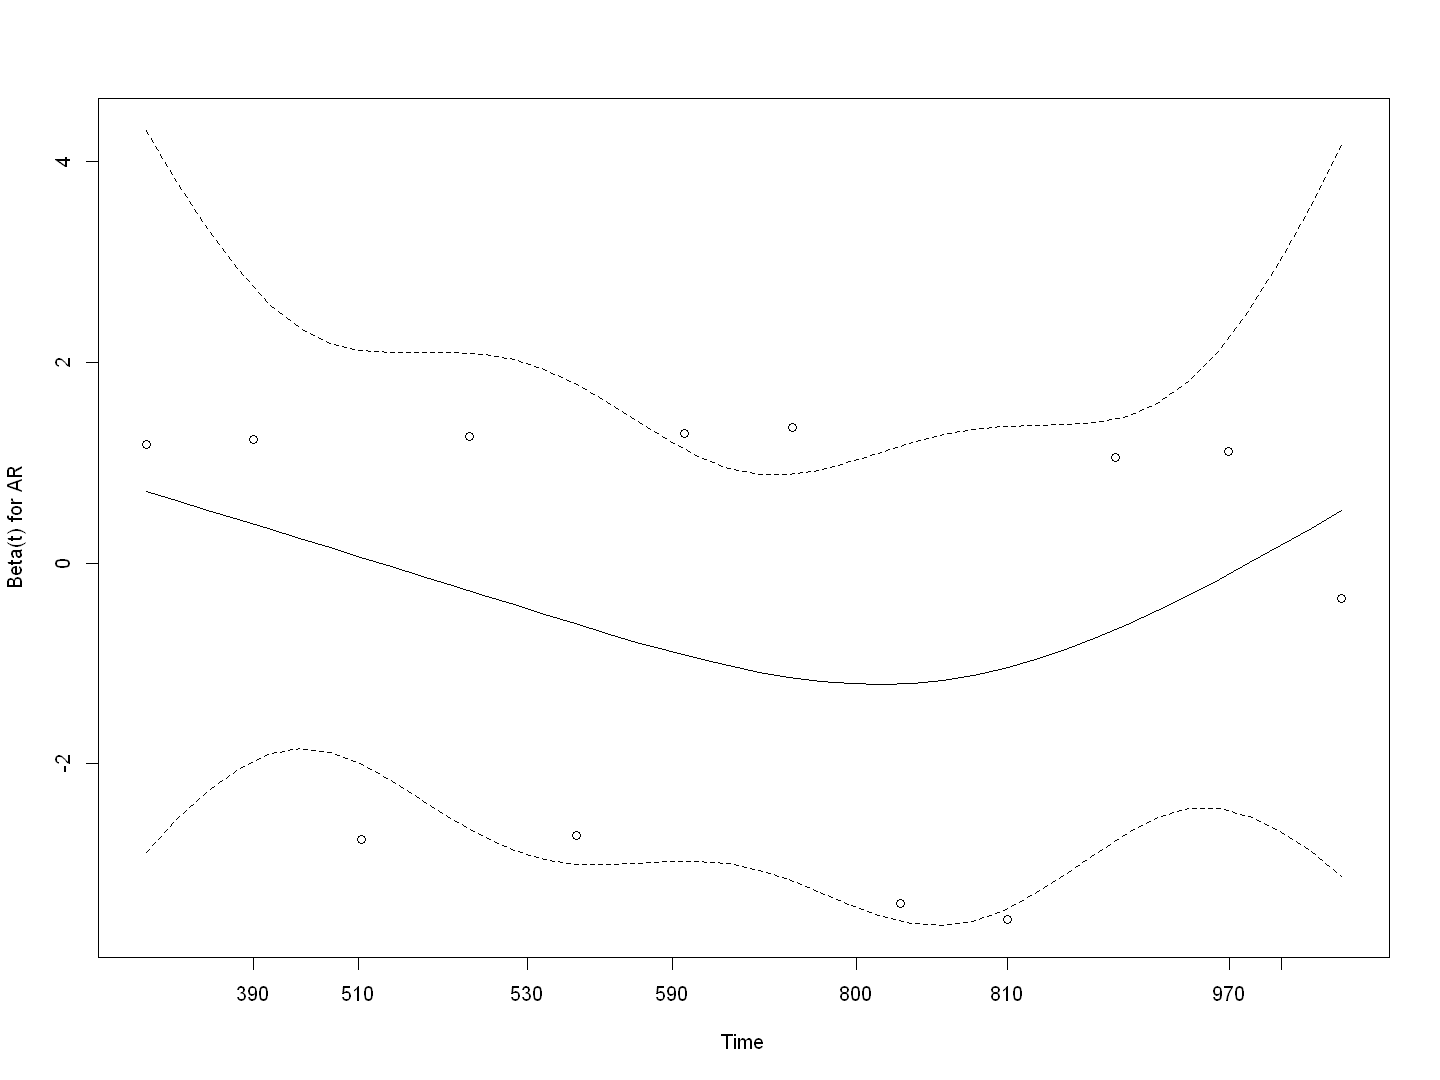

In [156]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + БА


#### Все группы

In [157]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + BA, data = first_reop_df)
cat("\nCox PH model summary (group + BA):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + BA):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + BA, data = first_reop_df)

  n= 50, number of events= 12 

            coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ1 -1.7335    0.1767   1.0575 -1.639   0.1012  
groupОГ2 -1.6007    0.2018   1.0543 -1.518   0.1290  
BAнет    -1.1346    0.3216   0.6085 -1.865   0.0622 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

         exp(coef) exp(-coef) lower .95 upper .95
groupОГ1    0.1767      5.660   0.02223     1.404
groupОГ2    0.2018      4.957   0.02555     1.593
BAнет       0.3216      3.110   0.09757     1.060

Concordance= 0.743  (se = 0.063 )
Likelihood ratio test= 8.96  on 3 df,   p=0.03
Wald test            = 7.69  on 3 df,   p=0.05
Score (logrank) test = 8.94  on 3 df,   p=0.03




Test of PH assumption (Schoenfeld residuals):


       chisq df    p
group   1.27  2 0.53
BA      1.92  1 0.17
GLOBAL  3.13  3 0.37


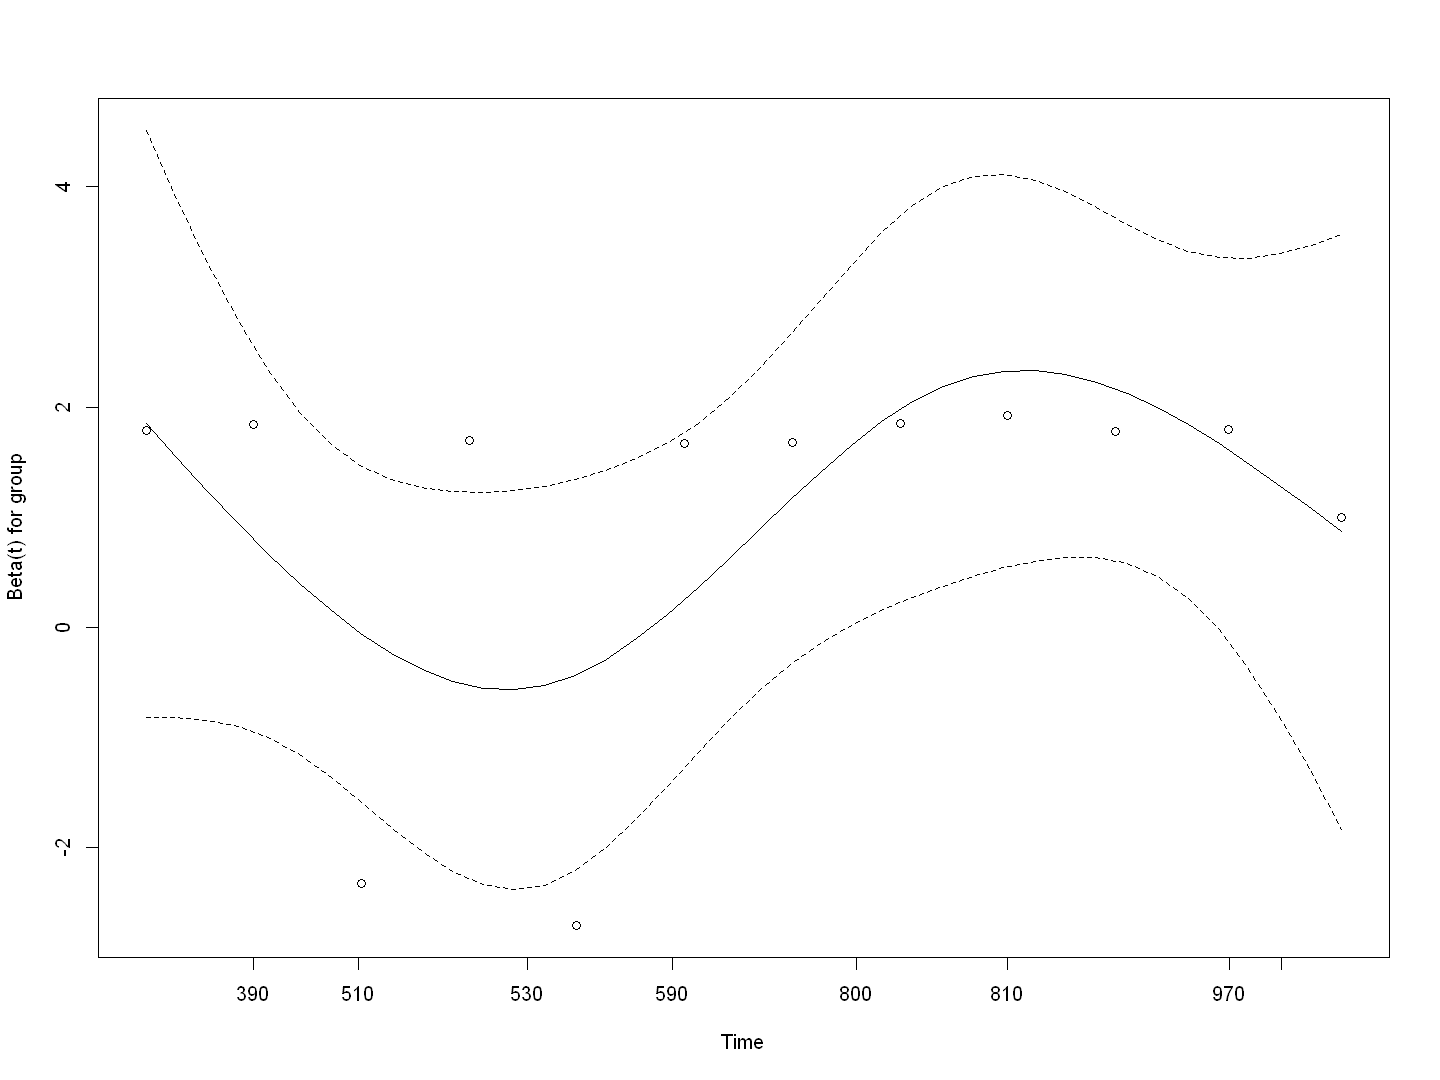

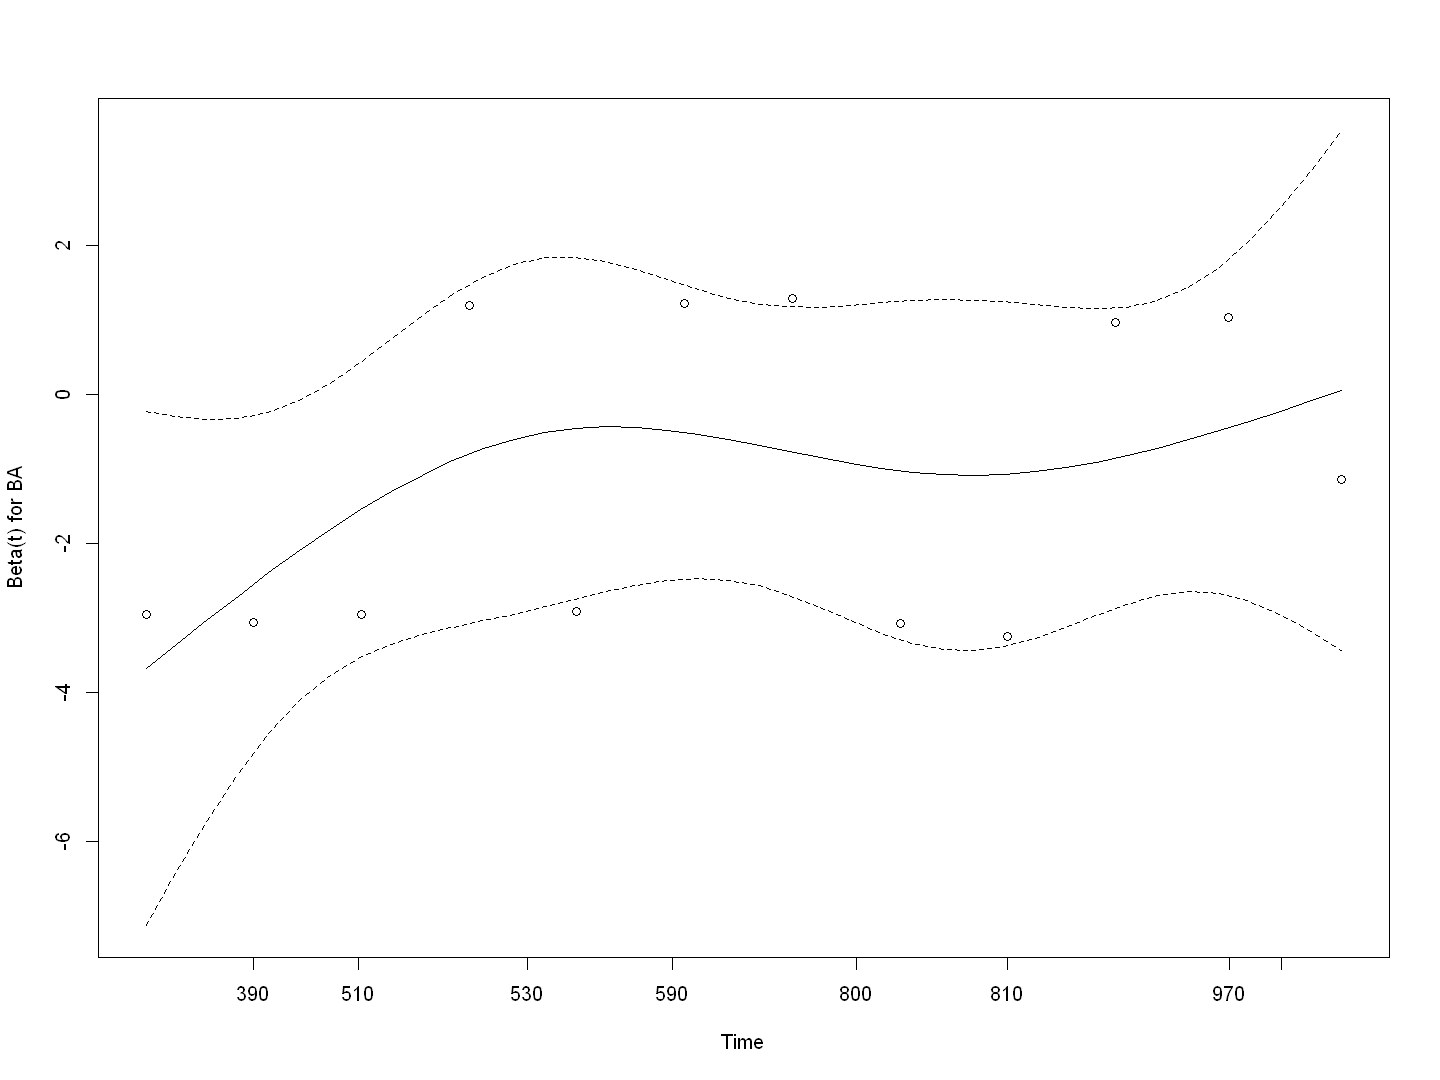

In [158]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [159]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + BA, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + BA):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + BA):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + BA, data = first_reop_df_og)

  n= 50, number of events= 12 

           coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ -1.6690    0.1884   0.7829 -2.132   0.0330 *
BAнет   -1.1310    0.3227   0.6073 -1.862   0.0626 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

        exp(coef) exp(-coef) lower .95 upper .95
groupОГ    0.1884      5.307   0.04062     0.874
BAнет      0.3227      3.099   0.09814     1.061

Concordance= 0.741  (se = 0.064 )
Likelihood ratio test= 8.95  on 2 df,   p=0.01
Wald test            = 7.66  on 2 df,   p=0.02
Score (logrank) test = 8.91  on 2 df,   p=0.01




Test of PH assumption:


       chisq df    p
group   1.10  1 0.29
BA      1.92  1 0.17
GLOBAL  2.87  2 0.24


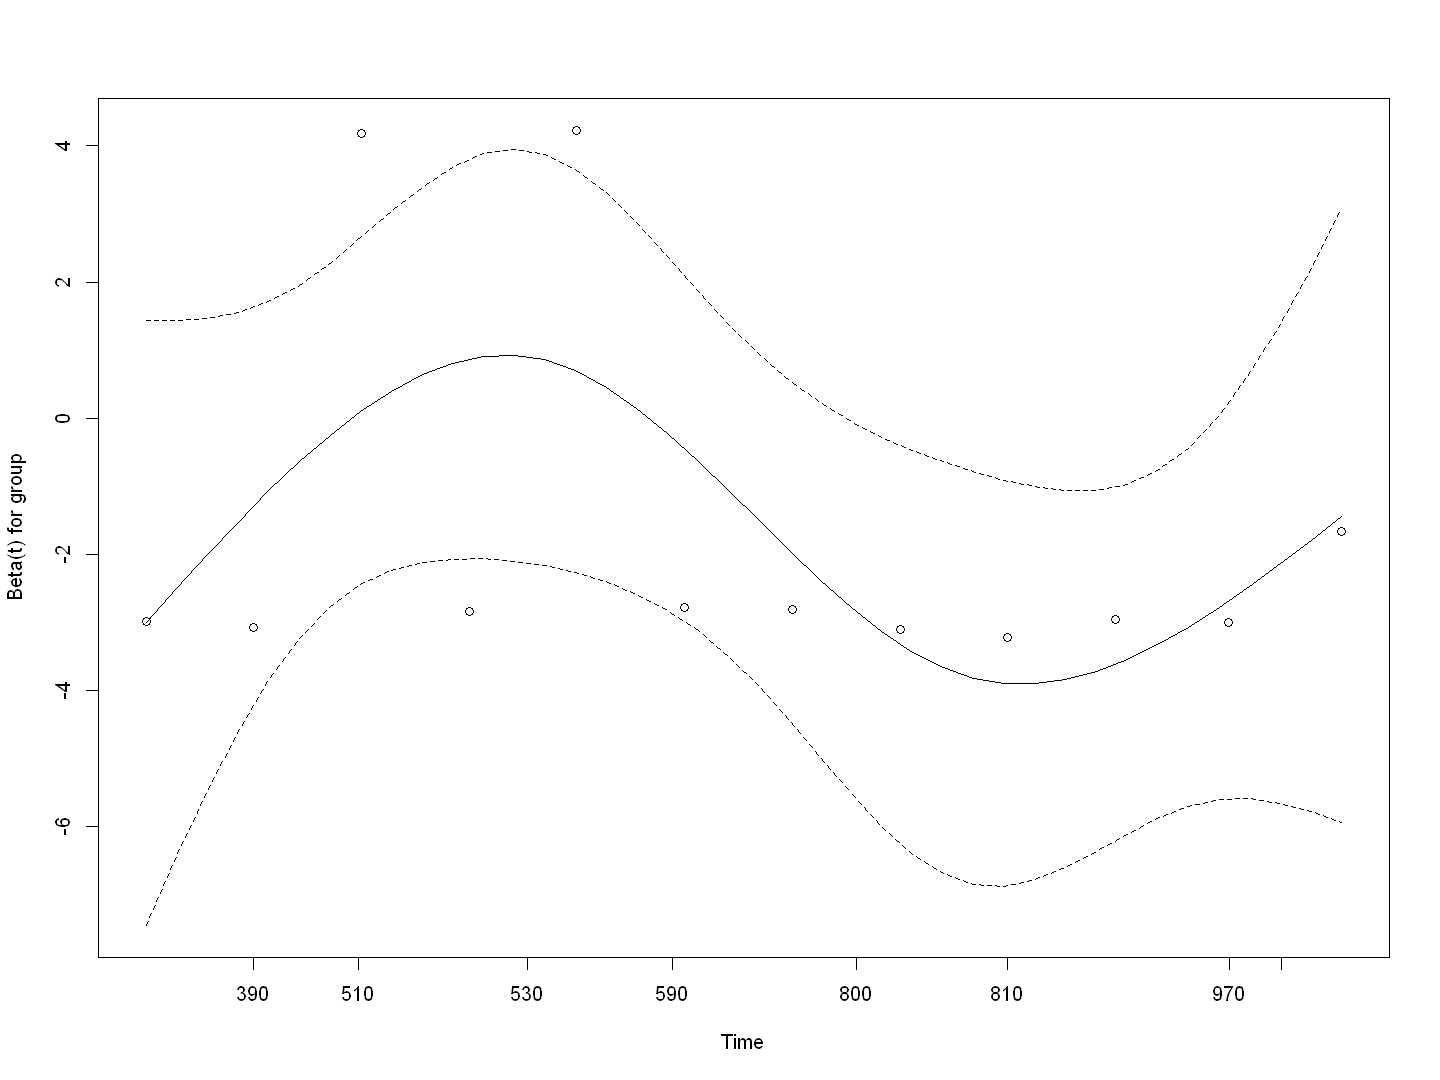

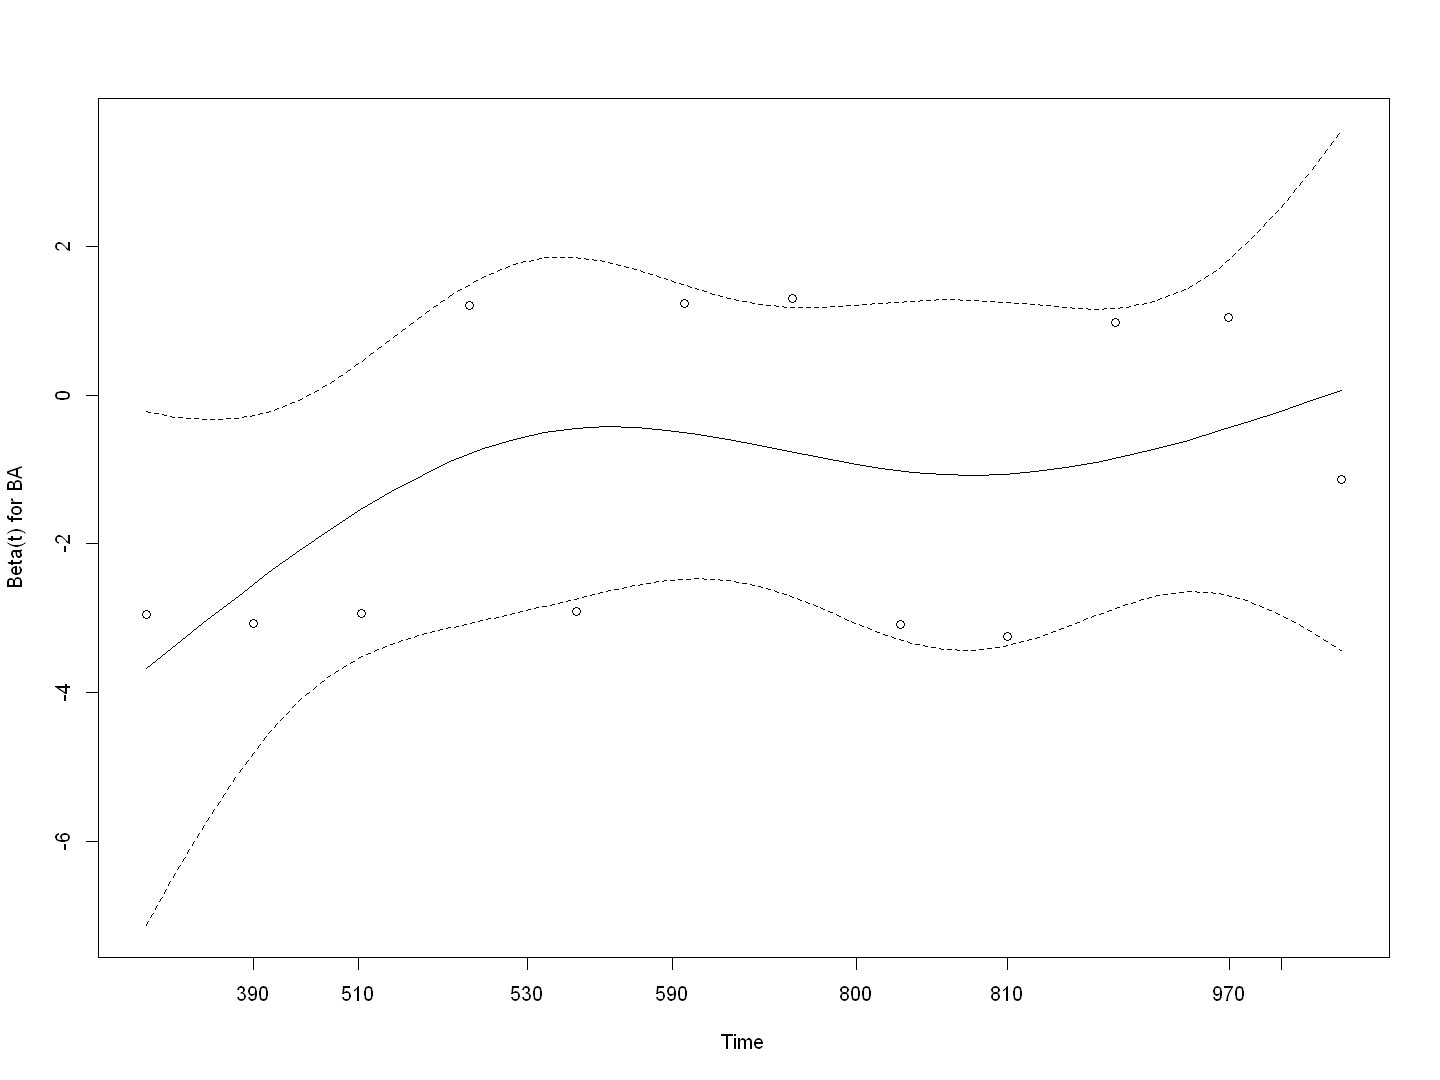

In [160]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


### 2.2  Adjusted — group + искривление носовой перегородки


#### Все группы

In [161]:
cox_fit_adj <- coxph(Surv(time_first, event_first) ~ group + nasal_septum_deviation, data = first_reop_df)
cat("\nCox PH model summary (group + nasal_septum_deviation):\n")
print(summary(cox_fit_adj))



Cox PH model summary (group + nasal_septum_deviation):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + nasal_septum_deviation, 
    data = first_reop_df)

  n= 50, number of events= 12 

                             coef exp(coef) se(coef)      z Pr(>|z|)
groupОГ1                  -1.6096    0.2000   1.0562 -1.524    0.128
groupОГ2                  -1.6129    0.1993   1.0545 -1.530    0.126
nasal_septum_deviationнет -0.2675    0.7653   0.6786 -0.394    0.693

                          exp(coef) exp(-coef) lower .95 upper .95
groupОГ1                     0.2000      5.001   0.02523     1.585
groupОГ2                     0.1993      5.017   0.02523     1.574
nasal_septum_deviationнет    0.7653      1.307   0.20240     2.894

Concordance= 0.684  (se = 0.059 )
Likelihood ratio test= 5.69  on 3 df,   p=0.1
Wald test            = 4.36  on 3 df,   p=0.2
Score (logrank) test = 5.34  on 3 df,   p=0.1




Test of PH assumption (Schoenfeld residuals):


                       chisq df    p
group                  1.291  2 0.52
nasal_septum_deviation 0.429  1 0.51
GLOBAL                 1.698  3 0.64


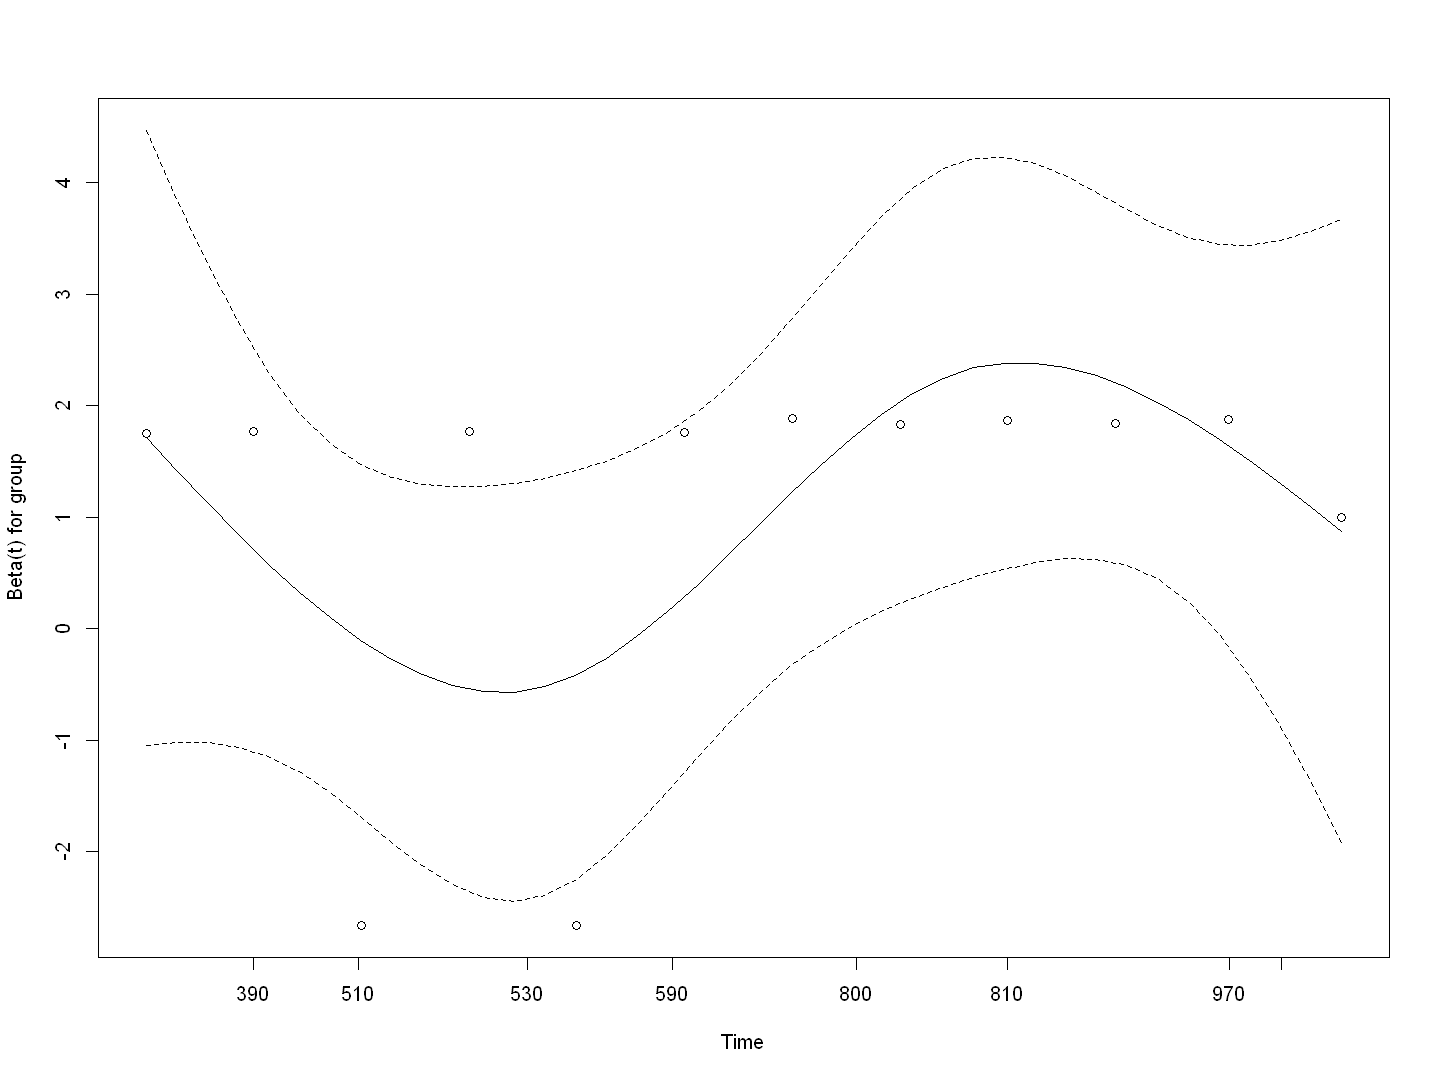

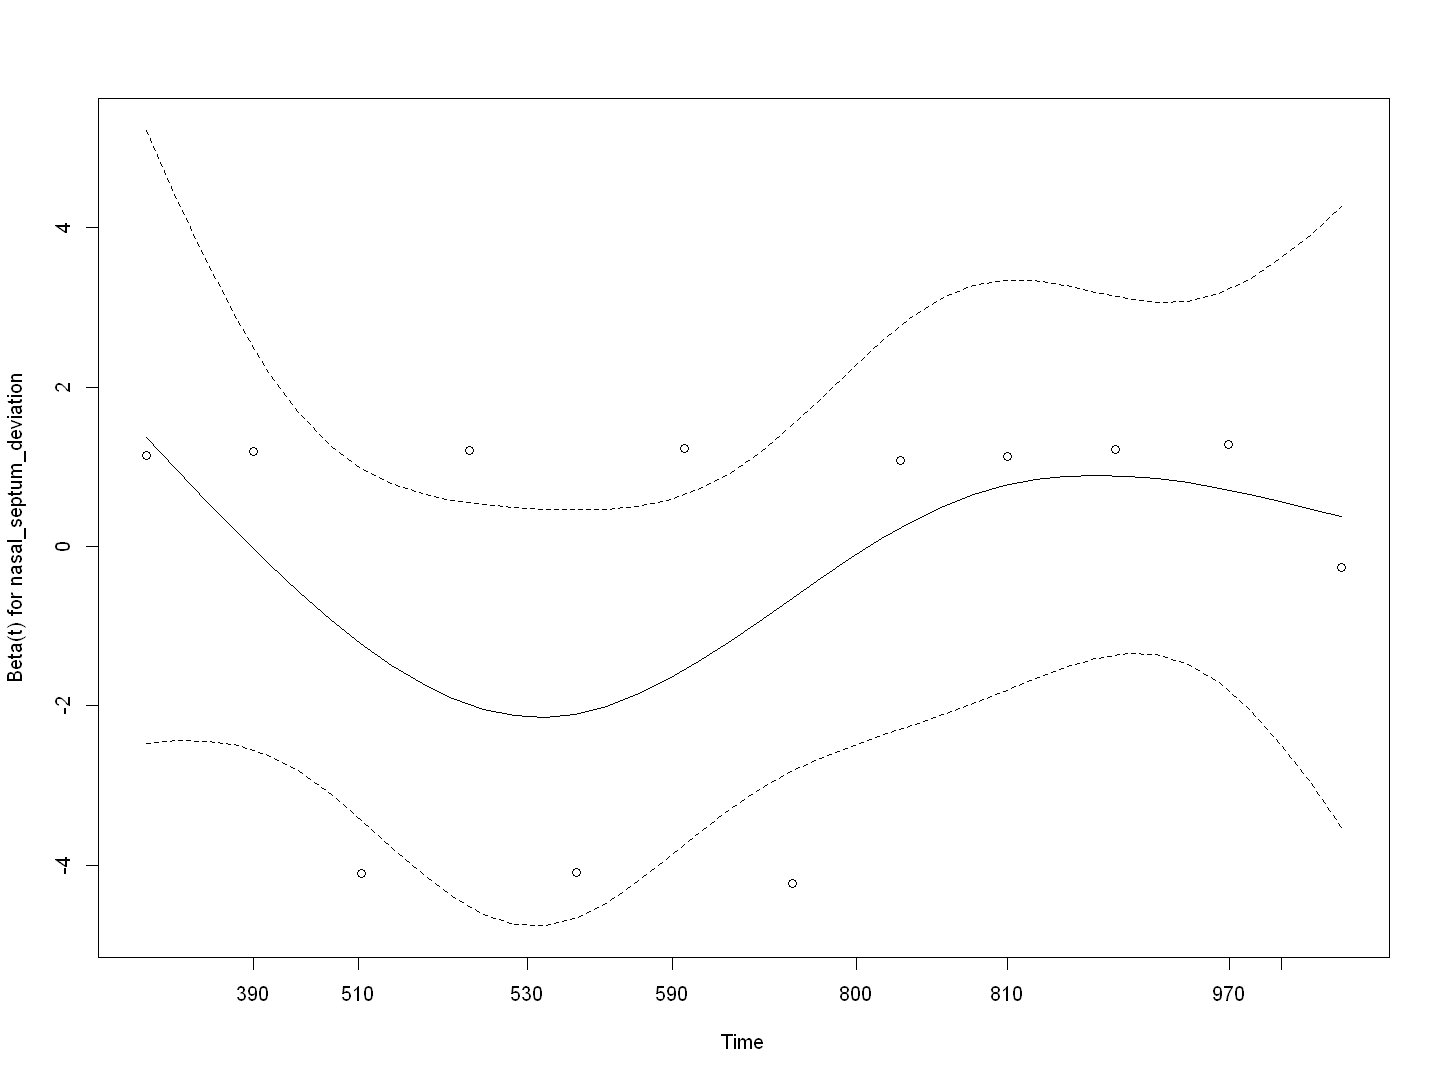

In [162]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(cox_fit_adj)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [163]:
cox_fit_adj_og <- coxph(Surv(time_first, event_first) ~ group + nasal_septum_deviation, data = first_reop_df_og)
cat("\nCox PH model summary — ОГ combined (group + nasal_septum_deviation):\n")
print(summary(cox_fit_adj_og))



Cox PH model summary — ОГ combined (group + nasal_septum_deviation):


Call:
coxph(formula = Surv(time_first, event_first) ~ group + nasal_septum_deviation, 
    data = first_reop_df_og)

  n= 50, number of events= 12 

                             coef exp(coef) se(coef)      z Pr(>|z|)  
groupОГ                   -1.6112    0.1996   0.7822 -2.060   0.0394 *
nasal_septum_deviationнет -0.2676    0.7652   0.6774 -0.395   0.6928  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                          exp(coef) exp(-coef) lower .95 upper .95
groupОГ                      0.1996      5.009    0.0431    0.9248
nasal_septum_deviationнет    0.7652      1.307    0.2028    2.8867

Concordance= 0.686  (se = 0.058 )
Likelihood ratio test= 5.69  on 2 df,   p=0.06
Wald test            = 4.36  on 2 df,   p=0.1
Score (logrank) test = 5.34  on 2 df,   p=0.07




Test of PH assumption:


                       chisq df    p
group                  1.107  1 0.29
nasal_septum_deviation 0.429  1 0.51
GLOBAL                 1.486  2 0.48


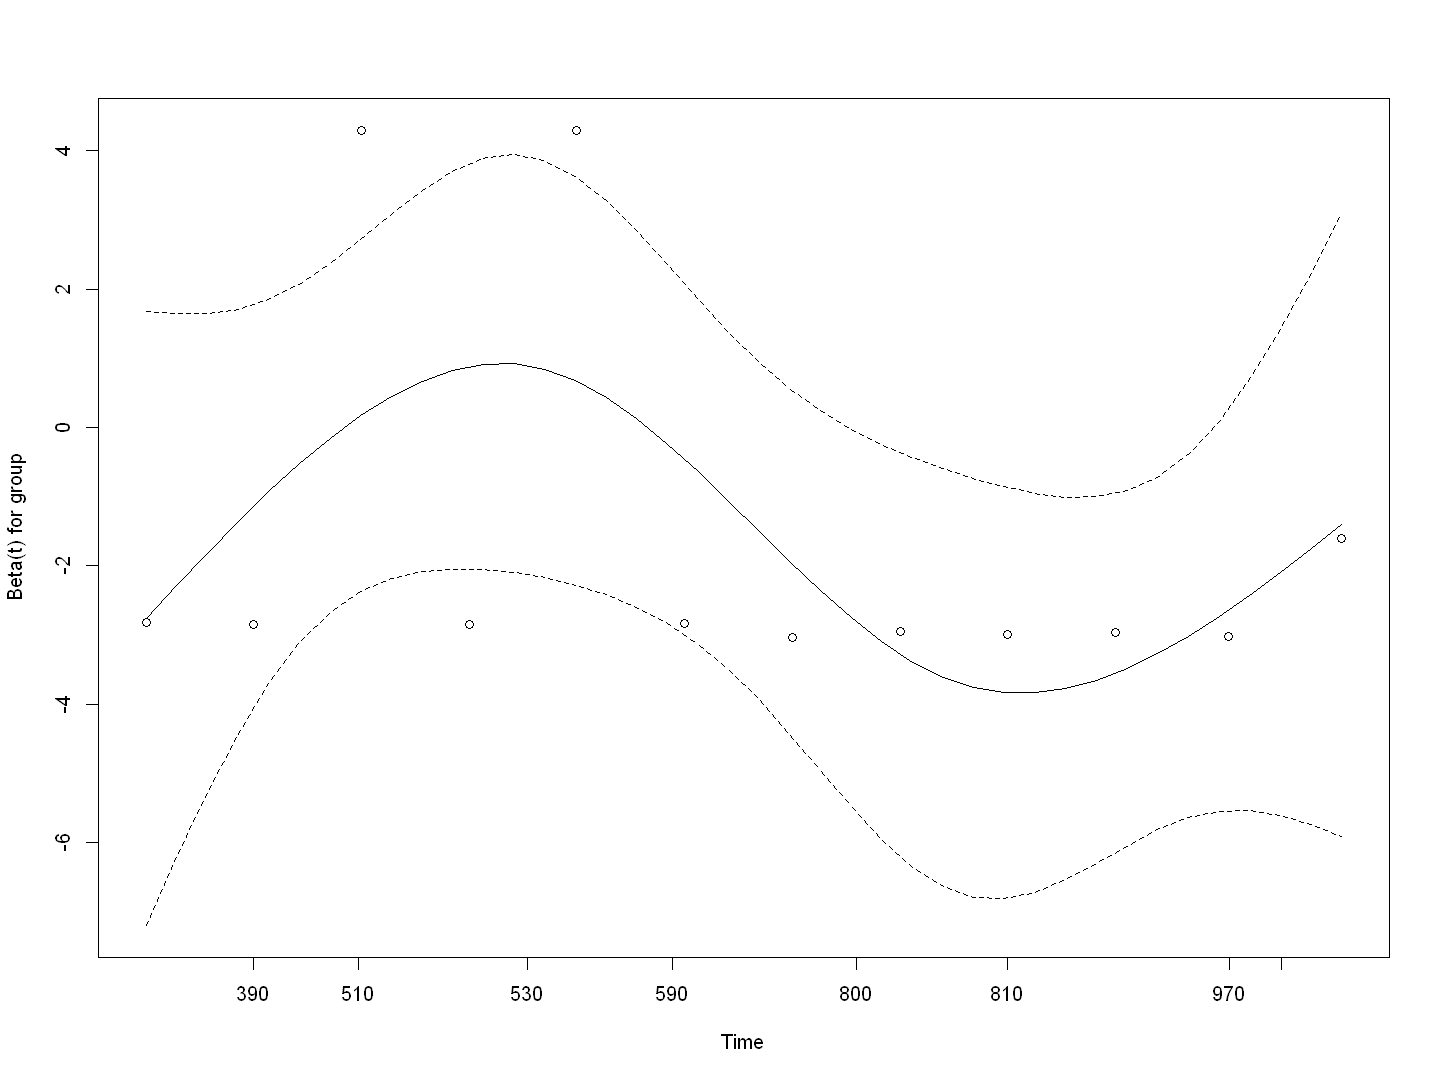

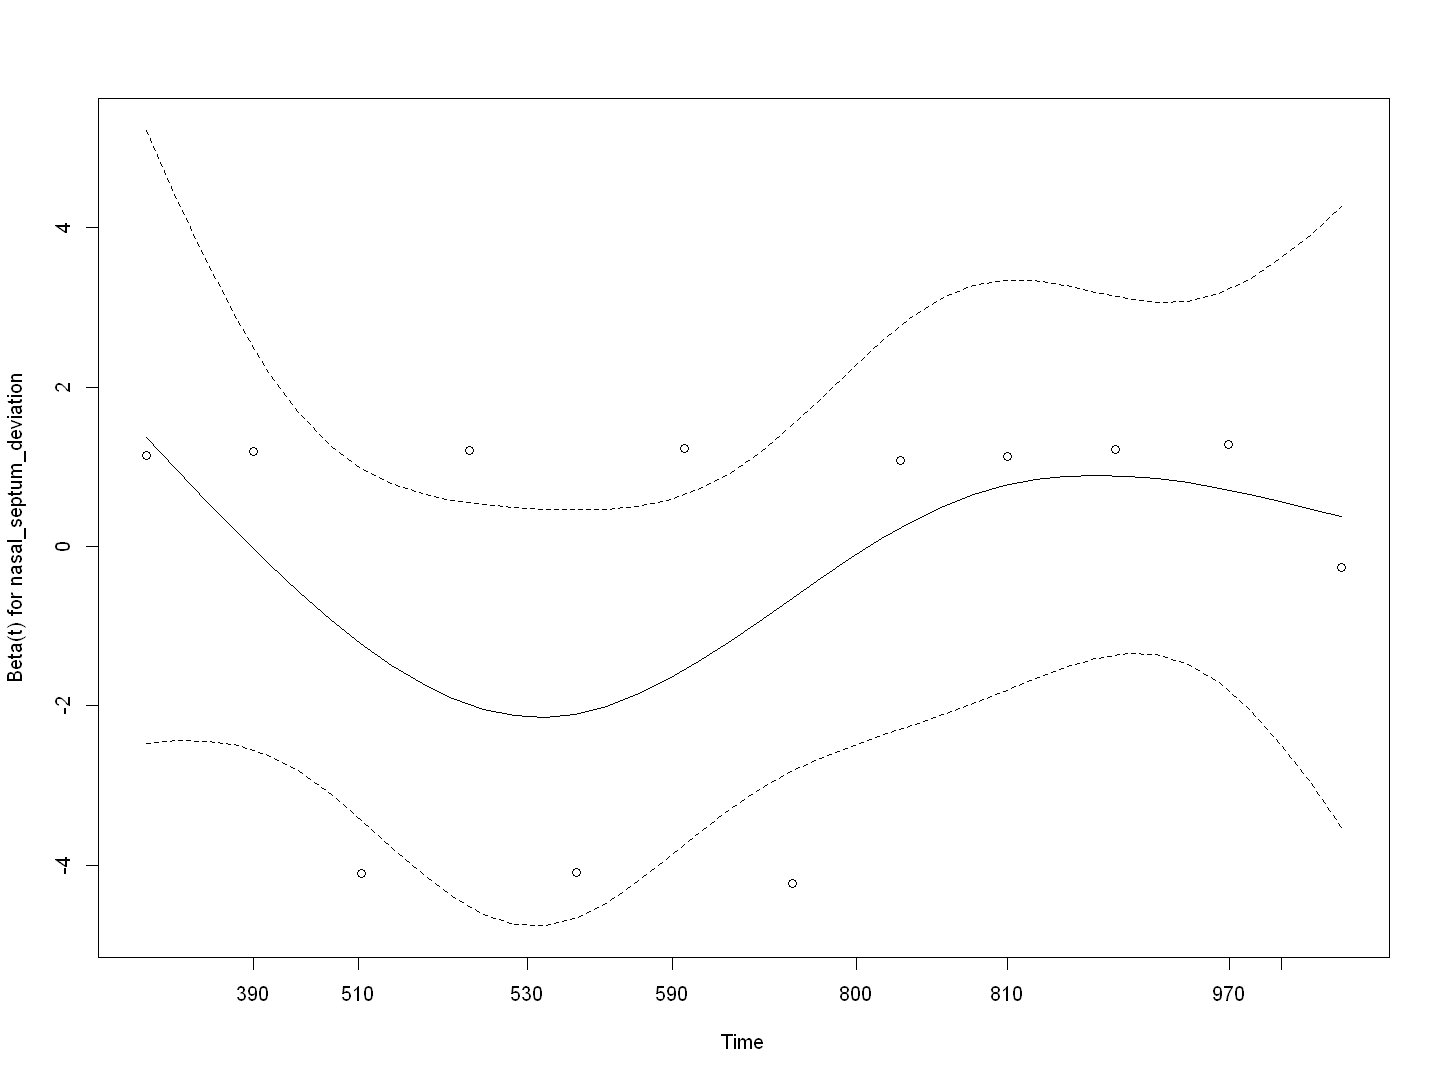

In [164]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(cox_fit_adj_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


## 2.3 Cox summary table — all models in one figure

In [165]:
# Narrowed focus: Baseline and first 2 parameters for both group setups
adj_params <- c(
    "", "sinuses", "age", "sex", "ill_dur", "polyps", "allergy_dust", "allergy_plants", "allergy_animals",
    "chronic_rhinitis", "AR", "BA", "nasal_septum_deviation"
)

process_model <- function(formula_str, label, data) {
    tryCatch(
        {
            m <- coxph(as.formula(formula_str), data = data)
            s <- summary(m)
            ph <- cox.zph(m)
            cat(sprintf("\n[%s]\n", label))
            for (i in 1:nrow(s$coefficients)) {
                v <- rownames(s$coefficients)[i]
                cat(sprintf(
                    "%s|%.3f|%.3f|[%.3f; %.3f]|%.3f|%.3f\n",
                    v, s$conf.int[i, 1], 1 / s$conf.int[i, 1], s$conf.int[i, 3], s$conf.int[i, 4], s$coefficients[i, 5],
                    ifelse(grepl("group", v), ph$table[1, 3], ph$table[2, 3])
                ))
            }
        },
        error = function(e) cat(paste(label, " error: ", e$message, "\n"))
    )
    cat(sprintf(
        "Конкордантность -- %.3f\n",
        s$concordance[1]
    ))
    cat(sprintf(
        "Тест макс. правдоподобия -- %.3f\n",
        s$logtest[3]
    ))
    cat(sprintf(
        "Пропорциональность -- %.3f\n",
        ph$table[nrow(ph$table), 3]
    ))
}


### 2.1  Unadjusted group only


In [166]:
# Narrowed focus: Baseline and first 2 parameters for both group setups
cat("параметр | ОР | ООР | OP 95%ДИ | p-Wald | PH\n")

for (p in adj_params[1:length(adj_params)]) {
    additional_parameter <- ifelse(p == "", "group", paste("group +", p))
    process_model(paste("Surv(time_first, event_first) ~ ", additional_parameter), additional_parameter, first_reop_df)
}


параметр | ОР | ООР | OP 95%ДИ | p-Wald | PH



[group]
groupОГ1|0.205|4.888|[0.026; 1.616]|0.132|0.519
groupОГ2|0.198|5.059|[0.025; 1.561]|0.124|0.519
Конкордантность -- 0.670
Тест макс. правдоподобия -- 0.063
Пропорциональность -- 0.519

[group + sinuses]
groupОГ1|0.131|7.616|[0.016; 1.089]|0.060|0.480
groupОГ2|0.325|3.078|[0.037; 2.846]|0.310|0.480
sinuses|0.774|1.291|[0.593; 1.012]|0.061|0.821
Конкордантность -- 0.758
Тест макс. правдоподобия -- 0.027
Пропорциональность -- 0.638

[group + age]
groupОГ1|0.194|5.145|[0.025; 1.538]|0.121|0.531
groupОГ2|0.186|5.366|[0.024; 1.474]|0.111|0.531
age|0.979|1.022|[0.935; 1.025]|0.360|0.533
Конкордантность -- 0.693
Тест макс. правдоподобия -- 0.094
Пропорциональность -- 0.627

[group + sex]
groupОГ1|0.225|4.440|[0.028; 1.790]|0.159|0.471
groupОГ2|0.200|5.003|[0.025; 1.580]|0.127|0.471
sexмуж.|0.415|2.412|[0.125; 1.371]|0.149|0.104
Конкордантность -- 0.725
Тест макс. правдоподобия -- 0.057
Пропорциональность -- 0.228

[group + ill_dur]
groupОГ1|0.190|5.254|[0.023; 1.555]|0.122|0.513
groupО

In [167]:
results <- data.frame()

for (p in adj_params) {
    label <- ifelse(p == "", "group", paste("group +", p))
    formula_str <- paste("Surv(time_first, event_first) ~ ", label)
    m <- coxph(as.formula(formula_str), data = first_reop_df)
    if (p == "") {
        base_model <- m
        p_anova <- NA
    } else {
        compare_models <- anova(base_model, m)
        p_anova <- compare_models$"Pr(>|Chi|)"[2]
    }
    s <- summary(m)

    # Extract exp(coef) for 'group'
    # In my case 'group' is always the first coefficient if unadjusted or adj by one param
    group_row <- grep("group", rownames(s$coefficients))[1]
    parameter_row <- grep(p, rownames(s$coefficients))[1]

    results <- rbind(results, data.frame(
        Parameter = label,
        Exp_Coef_Group = s$coefficients[group_row, "exp(coef)"],
        Inv_Exp_Coef_Group = 1 / s$coefficients[group_row, "exp(coef)"],
        Wald_Group = s$coefficients[group_row, "Pr(>|z|)"],
        Exp_Coef_Param = s$coefficients[parameter_row, "exp(coef)"],
        Inv_Exp_Coef_Param = 1 / s$coefficients[parameter_row, "exp(coef)"],
        Wald_Param = s$coefficients[parameter_row, "Pr(>|z|)"],
        Concordance = s$concordance[1],
        P_LRT = s$logtest[3],
        P_ANOVA = p_anova
    ))
}

options(width = 160)
results_fmt <- results

results_fmt$Exp_Coef_Group <- signif(results_fmt$Exp_Coef_Group, 3)
results_fmt$Inv_Exp_Coef_Group <- signif(results_fmt$Inv_Exp_Coef_Group, 2)
results_fmt$Wald_Group <- signif(results_fmt$Wald_Group, 4)
results_fmt$Exp_Coef_Param <- signif(results_fmt$Exp_Coef_Param, 3)
results_fmt$Inv_Exp_Coef_Param <- signif(results_fmt$Inv_Exp_Coef_Param, 2)
results_fmt$Wald_Param <- signif(results_fmt$Wald_Param, 4)
results_fmt$Concordance <- signif(results_fmt$Concordance, 2)
results_fmt$P_LRT <- signif(results_fmt$P_LRT, 3)
results_fmt$P_ANOVA <- signif(results_fmt$P_ANOVA, 3)

print(results_fmt)


                         Parameter Exp_Coef_Group Inv_Exp_Coef_Group Wald_Group Exp_Coef_Param Inv_Exp_Coef_Param Wald_Param Concordance  P_LRT P_ANOVA
C                            group          0.205                4.9    0.13240          0.205               4.90    0.13240        0.67 0.0626      NA
C1                 group + sinuses          0.131                7.6    0.05996          0.774               1.30    0.06104        0.76 0.0275  0.0577
C2                     group + age          0.194                5.1    0.12070          0.979               1.00    0.36030        0.69 0.0942  0.3570
C3                     group + sex          0.225                4.4    0.15870          0.415               2.40    0.14910        0.72 0.0572  0.1600
C4                 group + ill_dur          0.190                5.3    0.12170          1.020               0.98    0.71130        0.68 0.1290  0.7140
C5                  group + polyps          0.209                4.8    0.13860         

### 2.2  Adjusted


In [168]:
# Narrowed focus: Baseline and first 2 parameters for both group setups
cat("параметр | ОР | ООР | OP 95%ДИ | p-Wald | PH\n")

for (p in adj_params[1:length(adj_params)]) {
    additional_parameter <- ifelse(p == "", "group", paste("group +", p))
    process_model(paste("Surv(time_first, event_first) ~ ", additional_parameter), additional_parameter, first_reop_df_og)
}


параметр | ОР | ООР | OP 95%ДИ | p-Wald | PH



[group]
groupОГ|0.201|4.973|[0.043; 0.931]|0.040|0.288
Конкордантность -- 0.670
Тест макс. правдоподобия -- 0.019
Пропорциональность -- 0.288

[group + sinuses]
groupОГ|0.189|5.278|[0.041; 0.882]|0.034|0.255
sinuses|0.796|1.256|[0.622; 1.020]|0.071|0.810
Конкордантность -- 0.753
Тест макс. правдоподобия -- 0.012
Пропорциональность -- 0.517

[group + age]
groupОГ|0.190|5.255|[0.041; 0.884]|0.034|0.299
age|0.979|1.022|[0.935; 1.025]|0.360|0.533
Конкордантность -- 0.695
Тест макс. правдоподобия -- 0.041
Пропорциональность -- 0.459

[group + sex]
groupОГ|0.212|4.722|[0.046; 0.984]|0.048|0.252
sexмуж.|0.416|2.406|[0.126; 1.372]|0.150|0.104
Конкордантность -- 0.726
Тест макс. правдоподобия -- 0.023
Пропорциональность -- 0.123

[group + ill_dur]
groupОГ|0.193|5.182|[0.041; 0.908]|0.037|0.283
ill_dur|1.018|0.982|[0.924; 1.122]|0.711|0.409
Конкордантность -- 0.683
Тест макс. правдоподобия -- 0.059
Пропорциональность -- 0.342

[group + polyps]
groupОГ|0.206|4.854|[0.044; 0.959]|0.044|0.293
poly

In [ ]:
results <- data.frame()

for (p in adj_params) {
    label <- ifelse(p == "", "group", paste("group +", p))
    formula_str <- paste("Surv(time_first, event_first) ~ ", label)
    m <- coxph(as.formula(formula_str), data = first_reop_df_og)
    if (p == "") {
        base_model <- m
        p_anova <- NA
    } else {
        compare_models <- anova(base_model, m)
        p_anova <- compare_models$"Pr(>|Chi|)"[2]
    }
    s <- summary(m)

    # Extract exp(coef) for 'group'
    # In my case 'group' is always the first coefficient if unadjusted or adj by one param
    group_row <- grep("group", rownames(s$coefficients))[1]
    parameter_row <- grep(p, rownames(s$coefficients))[1]

    results <- rbind(results, data.frame(
        Parameter = label,
        Exp_Coef_Group = s$coefficients[group_row, "exp(coef)"],
        Inv_Exp_Coef_Group = 1 / s$coefficients[group_row, "exp(coef)"],
        Wald_Group = s$coefficients[group_row, "Pr(>|z|)"],
        Exp_Coef_Param = s$coefficients[parameter_row, "exp(coef)"],
        Inv_Exp_Coef_Param = 1 / s$coefficients[parameter_row, "exp(coef)"],
        Wald_Param = s$coefficients[parameter_row, "Pr(>|z|)"],
        Concordance = s$concordance[1],
        P_LRT = s$logtest[3],
        P_ANOVA = p_anova
    ))
}

options(width = 160)
results_fmt <- results

results_fmt$Exp_Coef_Group <- signif(results_fmt$Exp_Coef_Group, 3)
results_fmt$Inv_Exp_Coef_Group <- signif(results_fmt$Inv_Exp_Coef_Group, 2)
results_fmt$Wald_Group <- signif(results_fmt$Wald_Group, 4)
results_fmt$Exp_Coef_Param <- signif(results_fmt$Exp_Coef_Param, 3)
results_fmt$Inv_Exp_Coef_Param <- signif(results_fmt$Inv_Exp_Coef_Param, 2)
results_fmt$Wald_Param <- signif(results_fmt$Wald_Param, 4)
results_fmt$Concordance <- signif(results_fmt$Concordance, 2)
results_fmt$P_LRT <- signif(results_fmt$P_LRT, 3)
results_fmt$P_ANOVA <- signif(results_fmt$P_ANOVA, 3)

print(results_fmt)


## 3. ANDERSEN-GILL MODEL  (all re-operations, independent increments)

### Все группы

In [ ]:
# Assumes each event interval is independent (like multiple independent subjects)
# Uses (tstart, tstop] counting process notation

ag_fit <- coxph(
  Surv(tstart, tstop, status) ~ group + cluster(id),
  data   = long_df,
  method = "efron"
)
cat("\nAndersen-Gill model summary:\n")
print(summary(ag_fit))
cat("  HR > 1 means Group B has HIGHER re-op rate than Group A\n")
cat("  HR < 1 means Group B has LOWER  re-op rate (protective)\n")


In [ ]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(ag_fit)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


#### ОГ1+ОГ2 vs КГ

In [ ]:
ag_fit_og <- coxph(
  Surv(tstart, tstop, status) ~ group + cluster(id),
  data   = long_df_og,
  method = "efron"
)
cat("\nAndersen-Gill model summary — ОГ combined:\n")
print(summary(ag_fit_og))


In [ ]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(ag_fit_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


## 4. PRENTICE-WILLIAMS-PETERSON (PWP) MODEL  (ordered recurring events)

### Все группы

In [ ]:
# Conditions on prior event â€” models k-th re-operation separately.
# stratify by event number so each stratum gets its own baseline hazard.

# Limit to events 1-3 (small strata beyond that)
pwp_df <- long_df |>
  filter(event_num <= 3) |>
  dplyr::mutate(strata = factor(event_num))

pwp_fit <- coxph(
  Surv(tstart, tstop, status) ~ group + strata(strata) + cluster(id),
  data   = pwp_df,
  method = "efron"
)
cat("\nPWP model summary:\n")
print(summary(pwp_fit))


In [ ]:
# Test PH assumption (Schoenfeld residuals)
cat("\nTest of PH assumption (Schoenfeld residuals):\n")
ph_test_adj <- cox.zph(pwp_fit)
print(ph_test_adj)
# p > 0.05 → PH assumption not violated

# Plot Schoenfeld residuals for PH test
plot(ph_test_adj)


In [ ]:
# Per-stratum (per event number) analysis
cat("\nPer-event-number HRs:\n")
for (k in 1:3) {
  df_k <- long_df |> filter(event_num == k)
  if (sum(df_k$status) < 5) next # skip if too few events
  fit_k <- coxph(Surv(tstart, tstop, status) ~ group + cluster(id), data = df_k)
  s <- summary(fit_k)
  hr <- round(s$conf.int[1, 1], 3)
  lo <- round(s$conf.int[1, 3], 3)
  hi <- round(s$conf.int[1, 4], 3)
  pv <- round(s$coefficients[1, 5], 4)
  cat(sprintf(
    "  Event %d: HR = %.3f (95%% CI %.3fâ€“%.3f), p = %.4f\n",
    k, hr, lo, hi, pv
  ))
}


#### ОГ1+ОГ2 vs КГ

In [ ]:
pwp_df_og <- long_df_og |>
  filter(event_num <= 3) |>
  dplyr::mutate(strata = factor(event_num))

pwp_fit_og <- coxph(
  Surv(tstart, tstop, status) ~ group + strata(strata) + cluster(id),
  data   = pwp_df_og,
  method = "efron"
)
cat("\nPWP model summary — ОГ combined:\n")
print(summary(pwp_fit_og))


In [ ]:
# Plot Schoenfeld residuals for PH test (OG combined)
cat("\nTest of PH assumption:\n")
ph_test_adj_og <- cox.zph(pwp_fit_og)
print(ph_test_adj_og)
# Plot Schoenfeld residuals for PH test (OG combined)
plot(ph_test_adj_og)


In [ ]:
cat("\nPer-event-number HRs — ОГ combined:\n")
for (k in 1:3) {
  df_k <- long_df_og |> filter(event_num == k)
  if (sum(df_k$status) < 5) next
  fit_k <- coxph(Surv(tstart, tstop, status) ~ group + cluster(id), data = df_k)
  s <- summary(fit_k)
  hr <- round(s$conf.int[1, 1], 3)
  lo <- round(s$conf.int[1, 3], 3)
  hi <- round(s$conf.int[1, 4], 3)
  pv <- round(s$coefficients[1, 5], 4)
  cat(sprintf("  Event %d: HR = %.3f (95%% CI %.3f\u2013%.3f), p = %.4f\n", k, hr, lo, hi, pv))
}


## 5. NEGATIVE BINOMIAL REGRESSION  (total re-operation count)

### Все группы

In [ ]:
# offset(log(followup)) accounts for different observation lengths

nb_fit <- glm.nb(
  n_reops ~ group + offset(log(followup)),
  data = patient_df
)
cat("\nNegative Binomial model summary:\n")
print(summary(nb_fit))

# Rate ratio with CIs
rr <- exp(coef(nb_fit))
rr_ci <- exp(confint(nb_fit))
cat("\nRate Ratios (relative to Group A):\n")
print(cbind(RR = round(rr, 3), round(rr_ci, 3)))

cat(sprintf(
  "\nGroup B has %.1f%% %s re-operations per unit time compared to Group A\n",
  abs(1 - rr["groupB"]) * 100,
  ifelse(rr["groupB"] < 1, "fewer", "more")
))


#### ОГ1+ОГ2 vs КГ

In [ ]:
nb_fit_og <- glm.nb(
  n_reops ~ group + offset(log(followup)),
  data = patient_df_og
)
cat("\nNegative Binomial model summary — ОГ combined:\n")
print(summary(nb_fit_og))

rr_og <- exp(coef(nb_fit_og))
rr_ci_og <- exp(confint(nb_fit_og))
cat("\nRate Ratios (ОГ vs КГ):\n")
print(cbind(RR = round(rr_og, 3), round(rr_ci_og, 3)))


## 6. MEAN CUMULATIVE FUNCTION (MCF)

### Все группы

In [ ]:
# Uses the Nelson-Aalen estimator applied to recurring events.
# survfit() with id= argument computes the MCF.
# NOTE: Use long_df (already censored at 3 years)
mcf_fit <- survfit(
  Surv(tstart, tstop, status) ~ group,
  data = long_df, # <--- censored at 3 years
  id   = id # identifies subject; cumhaz gives the MCF for recurring events
)

# Extract MCF data for all groups dynamically
mcf_data <- bind_rows(lapply(seq_along(group_levels), function(i) {
  tibble(
    time  = mcf_fit[i]$time,
    mcf   = mcf_fit[i]$cumhaz,
    lower = mcf_fit[i]$cumhaz - 1.96 * mcf_fit[i]$std.err,
    upper = mcf_fit[i]$cumhaz + 1.96 * mcf_fit[i]$std.err,
    group = group_levels[i]
  )
}))

mcf_plot <- ggplot(mcf_data, aes(x = time, y = mcf, color = group, fill = group)) +
  geom_step(linewidth = 1) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  scale_color_manual(values = group_palette) +
  scale_fill_manual(values = group_palette) +
  scale_x_continuous(
    limits       = c(0, NA),
    breaks       = seq(0, max(mcf_data$time), by = six_months_days),
    labels       = function(x) round(x / 365.25, 1),
    minor_breaks = NULL,
    expand       = expansion(mult = c(0, 0.02))
  ) +
  labs(
    # title    = "Среднее значение кумулятивной функции (MCF) повторных операций",
    # subtitle = "Ожидаемое кумулятивное количество повторных операций на пациента с течением времени",
    x        = "годы",
    y        = "Риск повторных операций",
    color    = "Группа",
    fill     = "Группа"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(mcf_plot)


#### ОГ1+ОГ2 vs КГ

In [ ]:
# MCF for ОГ1+ОГ2 vs КГ using follow-up time cut at 3 years
# NOTE: Use long_df_og (already censored at 3 years)
mcf_fit_og <- survfit(
  Surv(tstart, tstop, status) ~ group,
  data = long_df_og, # <--- censored at 3 years
  id   = id
)

mcf_data_og <- bind_rows(lapply(seq_along(group_levels_og), function(i) {
  tibble(
    time  = mcf_fit_og[i]$time,
    mcf   = mcf_fit_og[i]$cumhaz,
    lower = mcf_fit_og[i]$cumhaz - 1.96 * mcf_fit_og[i]$std.err,
    upper = mcf_fit_og[i]$cumhaz + 1.96 * mcf_fit_og[i]$std.err,
    group = group_levels_og[i]
  )
}))

mcf_plot_og <- ggplot(mcf_data_og, aes(x = time, y = mcf, color = group, fill = group)) +
  geom_step(linewidth = 1) +
  geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.15, color = NA) +
  scale_color_manual(values = group_palette_og) +
  scale_fill_manual(values = group_palette_og) +
  scale_x_continuous(
    limits       = c(0, NA),
    breaks       = seq(0, max(mcf_data_og$time), by = six_months_days),
    labels       = function(x) round(x / 365.25, 1),
    minor_breaks = NULL,
    expand       = expansion(mult = c(0, 0.02))
  ) +
  labs(
    x     = "годы",
    y     = "Риск повторных операций",
    color = "Группа",
    fill  = "Группа"
  ) +
  theme_bw(base_size = 16) +
  theme(legend.position = "top")

print(mcf_plot_og)


## FOREST PLOT — all effect estimates in one figure

### Все группы

In [ ]:
# All models report a ratio (HR or RR) relative to the reference group.
#   ratio < 1  →  group has FEWER / LATER re-operations  (better)
#   ratio > 1  →  group has MORE  / EARLIER re-operations (worse)

# ---- Helper: extract HR/CI/p from a coxph or glm model ----
extract_hr <- function(fit, coef_row = 1) {
  s <- summary(fit)
  ci <- exp(confint(fit))
  if ("conf.int" %in% names(s)) {
    hr <- s$conf.int[coef_row, 1]
    lo <- s$conf.int[coef_row, 3]
    hi <- s$conf.int[coef_row, 4]
    pv <- s$coefficients[coef_row, ncol(s$coefficients)]
  } else {
    hr <- exp(s$coefficients[coef_row, 1])
    lo <- ci[coef_row, 1]
    hi <- ci[coef_row, 2]
    pv <- s$coefficients[coef_row, 4]
  }
  list(est = hr, lo = lo, hi = hi, p = pv)
}

# ---- Helper: extract NB rate ratio (first group coefficient) ----
extract_nb <- function(nb_model) {
  s <- summary(nb_model)
  ci <- exp(confint(nb_model))
  grp_rows <- grep("^group", rownames(s$coefficients))
  if (length(grp_rows) == 0) stop("No 'group' coefficient found in NB model")
  rname <- rownames(s$coefficients)[grp_rows[1]]
  list(
    est   = exp(s$coefficients[rname, 1]),
    lo    = ci[rname, 1],
    hi    = ci[rname, 2],
    p     = s$coefficients[rname, 4],
    label = sub("^group", "", rname)
  )
}

# ---- Helper: build a forest plot ----
make_forest_plot <- function(cox_e, ag_e, pwp_e, nb_e, title_str) {
  model_labels <- c(
    "Cox PH\n(время до 1-й повторной операции)",
    "Andersen-Gill\n(все повторные операции)",
    "PWP\n(упорядоченные повторные операции)",
    "Neg. Binomial\n(общее количество)"
  )
  fdf <- tibble(
    Model    = factor(model_labels, levels = rev(model_labels)),
    Estimate = c(cox_e$est, ag_e$est, pwp_e$est, nb_e$est),
    Lower    = c(cox_e$lo, ag_e$lo, pwp_e$lo, nb_e$lo),
    Upper    = c(cox_e$hi, ag_e$hi, pwp_e$hi, nb_e$hi),
    P        = c(cox_e$p, ag_e$p, pwp_e$p, nb_e$p)
  ) |>
    dplyr::mutate(
      label = sprintf(
        "%.2f (%.2f\u2013%.2f)\np=%s",
        Estimate, Lower, Upper,
        ifelse(P < 0.001, "<0.001", sprintf("%.3f", P))
      ),
      sig = ifelse(P < 0.05, "Significant", "Non-significant"),
      colour = ifelse(Estimate < 1, "#2ECC71", "#E74C3C")
    )

  ggplot2::ggplot(fdf, aes(x = Estimate, y = Model, xmin = Lower, xmax = Upper)) +
    geom_vline(xintercept = 1, linetype = "dashed", colour = "grey50") +
    geom_errorbarh(aes(colour = colour), height = 0.2, linewidth = 0.8) +
    geom_point(aes(colour = colour, shape = sig), size = 3.5) +
    geom_text(aes(x = max(Upper) * 1.05, label = label),
      hjust = 0, size = 3, lineheight = 0.9
    ) +
    scale_colour_identity() +
    scale_shape_manual(values = c("Significant" = 16, "Non-significant" = 1)) +
    scale_x_continuous(
      expand = expansion(mult = c(0.05, 0.45)),
      trans  = "log10"
    ) +
    labs(
      title    = title_str,
      subtitle = "Отношение < 1 (зелёный цвет): меньше/позднее повторные операции (ЛУЧШЕ)\nОтношение > 1 (красный цвет): больше/раннее повторные операции (ХУЖЕ)",
      x        = "Отношение рисков / Отношение долей (логарифмическая шкала)",
      y        = NULL,
      shape    = NULL
    ) +
    theme_bw(base_size = 16) +
    theme(
      legend.position = "bottom",
      panel.grid.minor = element_blank()
    )
}

# ---- Все группы: extract estimates ----
cox_e <- extract_hr(cox_fit)
ag_e <- extract_hr(ag_fit)
pwp_e <- extract_hr(pwp_fit)
nb_e <- extract_nb(nb_fit)

forest_plot <- make_forest_plot(
  cox_e, ag_e, pwp_e, nb_e,
  title_str = sprintf(
    "Все группы (%s vs опорная группа) \u2014 Оценка эффекта (%s vs опорная группа) \u2014 Effect Estimates",
    nb_e$label, nb_e$label
  )
)
print(forest_plot)


#### ОГ1+ОГ2 vs КГ

In [ ]:
# ---- ОГ combined: extract estimates ----
cox_e_og <- extract_hr(cox_fit_og)
ag_e_og <- extract_hr(ag_fit_og)
pwp_e_og <- extract_hr(pwp_fit_og)
nb_e_og <- extract_nb(nb_fit_og)

forest_plot_og <- make_forest_plot(
  cox_e_og, ag_e_og, pwp_e_og, nb_e_og,
  title_str = sprintf(
    "%s vs \u041a\u0413 \u2014 Оценнка эффекта (ОГ1+ОГ2)",
    nb_e_og$label
  )
)
print(forest_plot_og)


## GROUP COMPARISON SUMMARY 

### Все группы

In [ ]:
# ---- Helper: interpret a single ratio ----
interpret <- function(label, est, lo, hi, p, ref, grp, unit = "повторные операции") {
  direction <- if (est < 1) "МЕНЬШЕ" else "БОЛЬШЕ"
  verdict <- if (est < 1) "ЛУЧШЕ" else "ХУЖЕ"
  sig_str <- if (p < 0.05) {
    sprintf("(p=%.4f, статистически значимо)", p)
  } else {
    sprintf("(p=%.4f, статистически незначимо)", p)
  }
  pct <- abs(1 - est) * 100
  cat(sprintf(
    "  %-35s  HR/RR = %.2f (95%% ДИ %.2f\u2013%.2f)\n    \u2192 %s имеет %.1f%% %s %s чем %s  [%s]  %s\n\n",
    label, est, lo, hi, grp, pct, direction, unit, ref, verdict, sig_str
  ))
}

# ---- Helper: print verdict block ----
print_verdict <- function(ests_list) {
  all_ests <- sapply(ests_list, `[[`, "est")
  any_sig <- any(sapply(ests_list, `[[`, "p") < 0.05)
  all_same <- all(all_ests < 1) || all(all_ests > 1)
  cat("--- ОБЩЕЕ ЗАКЛЮЧЕНИЕ ---\n")
  if (all_same && any_sig) {
    dir <- if (all(all_ests < 1)) "МЕНЬШЕ" else "БОЛЬШЕ"
    cat(sprintf("  Все модели последовательно показывают одно направление (%s повторные операции)\n  и как минимум один результат статистически значим.\n", dir))
  } else if (all_same && !any_sig) {
    dir <- if (all(all_ests < 1)) "МЕНЬШЕ" else "БОЛЬШЕ"
    cat(sprintf("  Все модели указывают в одном направлении (%s повторные операции)\n  но ни один результат не достигает статистической значимости.\n  Рассмотрите возможность увеличения размера выборки.\n", dir))
  } else {
    cat("  Результаты непоследовательны между моделями.\n")
    cat("  Проверьте предположения моделей и качество данных.\n")
  }
}

# ---- Все группы ----
km_med <- surv_median(km_fit)
cat("--- Время до 1-й повторной операции (медианы Kaplan-Meier) ---\n")
for (i in seq_len(nrow(km_med))) {
  cat(sprintf(
    "  %s:  медиана = %.1f дней  (95%% ДИ %.1f\u2013%.1f)\n",
    km_med$strata[i], km_med$median[i],
    km_med$lower[i], km_med$upper[i]
  ))
}
p_lr <- pchisq(logrank$chisq, df = length(logrank$n) - 1, lower.tail = FALSE)
cat(sprintf(
  "  Log-rank p-value: %.4f  %s\n\n",
  p_lr,
  ifelse(p_lr < 0.05,
    "\u2192 Группы статистически значимо различаются.",
    "\u2192 Статистически значимых различий нет."
  )
))

ref_all <- levels(first_reop_df$group)[1]
grp_all <- nb_e$label
cat(sprintf("--- Оценка эффекта (опорная группа: %s) ---\n", ref_all))
interpret("Cox PH (время до 1-й повторной операции)", cox_e$est, cox_e$lo, cox_e$hi, cox_e$p, ref_all, grp_all)
interpret("Andersen-Gill (все повторные операции)", ag_e$est, ag_e$lo, ag_e$hi, ag_e$p, ref_all, grp_all)
interpret("PWP (упорядоченные повторные операции)", pwp_e$est, pwp_e$lo, pwp_e$hi, pwp_e$p, ref_all, grp_all)
interpret("Neg. Binomial (общее количество)", nb_e$est, nb_e$lo, nb_e$hi, nb_e$p, ref_all, grp_all,
  unit = "повторные операции за единицу времени"
)
print_verdict(list(cox_e, ag_e, pwp_e, nb_e))


#### ОГ1+ОГ2 vs КГ

In [ ]:
# ---- ОГ1+ОГ2 vs КГ ----
km_med_og <- surv_median(km_fit_og)
cat("--- Время до 1-й повторной операции (медианы Kaplan-Meier) ---\n")
for (i in seq_len(nrow(km_med_og))) {
  cat(sprintf(
    "  %s:  медиана = %.1f дней  (95%% ДИ %.1f\u2013%.1f)\n",
    km_med_og$strata[i], km_med_og$median[i],
    km_med_og$lower[i], km_med_og$upper[i]
  ))
}
p_lr_og <- pchisq(logrank_og$chisq, df = length(logrank_og$n) - 1, lower.tail = FALSE)
cat(sprintf(
  "  Log-rank p-value: %.4f  %s\n\n",
  p_lr_og,
  ifelse(p_lr_og < 0.05,
    "\u2192 Группы статистически значимо различаются.",
    "\u2192 Статистически значимых различий нет."
  )
))

ref_og <- levels(first_reop_df_og$group)[1]
grp_og <- nb_e_og$label
cat(sprintf("--- Оценка эффекта (опорная группа: %s) ---\n", ref_og))
interpret("Cox PH (время до 1-й повторной операции)", cox_e_og$est, cox_e_og$lo, cox_e_og$hi, cox_e_og$p, ref_og, grp_og)
interpret("Andersen-Gill (все повторные операции)", ag_e_og$est, ag_e_og$lo, ag_e_og$hi, ag_e_og$p, ref_og, grp_og)
interpret("PWP (упорядоченные повторные операции)", pwp_e_og$est, pwp_e_og$lo, pwp_e_og$hi, pwp_e_og$p, ref_og, grp_og)
interpret("Neg. Binomial (общее количество)", nb_e_og$est, nb_e_og$lo, nb_e_og$hi, nb_e_og$p, ref_og, grp_og,
  unit = "повторные операции за единицу времени"
)
print_verdict(list(cox_e_og, ag_e_og, pwp_e_og, nb_e_og))
